<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
بارگذاری کتابخانه های مورد نیاز و آماده سازی محیط

In [2]:
from __future__ import annotations

import logging
import platform
import random
import sys
from pathlib import Path
import matplotlib
import matplotlib as plt
import numpy as np
import pandas as pd

import sys

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("housing-market-project")

In [3]:
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DATA_DIR = DATA_DIR / "interim"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_RAW_DIR = FIGURES_DIR / "raw"
FIGURES_CLEANED_DIR = FIGURES_DIR / "cleaned"
TABLES_RAW_DIR = TABLES_DIR / "raw"
TABLES_CLEANED_DIR = TABLES_DIR / "cleaned"
MAPS_DIR = OUTPUT_DIR / "maps"

for directory in (
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_RAW_DIR,
    FIGURES_CLEANED_DIR,
    TABLES_RAW_DIR,
    TABLES_CLEANED_DIR,
    MAPS_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

logger.info("Python: %s", sys.version.split()[0])
logger.info("Platform: %s", platform.platform())
logger.info("pandas: %s", pd.__version__)
logger.info("numpy: %s", np.__version__)
logger.info("matplotlib: %s", matplotlib.__version__)
logger.info("Random seed: %s", RANDOM_SEED)
logger.info("Project root: %s", PROJECT_ROOT)

2026-08-13 23:42:05,339 | INFO | Python: 3.12.3
2026-08-13 23:42:05,342 | INFO | Platform: Windows-11-10.0.26200-SP0
2026-08-13 23:42:05,344 | INFO | pandas: 2.2.2
2026-08-13 23:42:05,346 | INFO | numpy: 1.26.4
2026-08-13 23:42:05,348 | INFO | matplotlib: 3.11.0
2026-08-13 23:42:05,349 | INFO | Random seed: 42
2026-08-13 23:42:05,351 | INFO | Project root: C:\Users\asus\Downloads\iran_housing_market_intelligence


In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

HOUSING_PALETTE_CATEGORICAL = [
    "#1F3B4D", "#C1633B", "#4C8577", "#D9A441", "#7A6C8F", "#8C8C8C",
]
HOUSING_PALETTE_SEQUENTIAL = sns.light_palette("#C1633B", as_cmap=True)
HOUSING_PALETTE_DIVERGING = sns.diverging_palette(160, 20, s=60, l=45, as_cmap=True)

CITY_COLOR_MAP = {
    "tehran": "#1F3B4D",
    "mashhad": "#C1633B",
    "isfahan": "#4C8577",
    "karaj": "#D9A441",
} 

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": "#FAF7F2",
        "axes.facecolor": "#FAF7F2",
        "axes.edgecolor": "#8C8C8C",
        "axes.grid.axis": "y",
        "grid.color": "#E5DED3",
        "grid.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "Vazirmatn",  
    }
)


def fa(text: str) -> str:
    """Reshape and reorder Persian/Arabic text for correct rendering in matplotlib."""
    return get_display(arabic_reshaper.reshape(text))


In [5]:
from matplotlib import font_manager
font_manager.fontManager.addfont("Vazirmatn-Regular.ttf")
mpl.rcParams["font.family"] = "Vazirmatn"

<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
بارگذاری داده دیوار

In [7]:
from datasets import load_dataset

DATASET_ID = "divarofficial/real_estate_ads"
DEVELOPMENT_SAMPLE_SIZE = 50_000
LOAD_FULL_DATASET = True

if LOAD_FULL_DATASET:
    dataset = load_dataset(DATASET_ID, split="train")
    df_raw = dataset.to_pandas()
    logger.info("Loaded full dataset with %d rows.", len(df_raw))
else:
    try:
        streamed_dataset = load_dataset(
            DATASET_ID,
            split="train",
            streaming=True,
        )
        sample_records = list(streamed_dataset.take(DEVELOPMENT_SAMPLE_SIZE))
        df_raw = pd.DataFrame.from_records(sample_records)
        logger.warning(
            "Loaded a development sample of %d rows. "
            "Do not use this ordered sample for final market estimates.",
            len(df_raw),
        )
       
    except Exception as exc:
        logger.exception("Streaming sample failed: %s", exc)
        raise RuntimeError(
            "Dataset loading failed. Verify network access, dataset availability, "
            "and the installed version of the datasets package."
        ) from exc

display(df_raw.head())

2026-08-13 23:42:09,613 | INFO | TensorFlow version 2.19.0 available.
2026-08-13 23:42:11,489 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/divarofficial/real_estate_ads/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-08-13 23:42:11,491 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-08-13 23:42:11,769 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/divarofficial/real_estate_ads/e9446ee97b8e6eb9bd62bdfd7548f1bc8973be85/README.md "HTTP/1.1 200 OK"
2026-08-13 23:42:12,075 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/divarofficial/real_estate_ads/resolve/e9446ee97b8e6eb9bd62bdfd7548f1bc8973be85/real_estate_ads.py "HTTP/1.1 404 Not Found"
2026-08-13 23:42:13,099 | INFO | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/divarofficial/real_estate_ads/divarofficial/real_estate_ad

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,None,NaN,...,None,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,None,NaN,...,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,None,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,None,NaN,None,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,None,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,None,NaN,...,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
تحلیل های آماری و بررسی داده

In [9]:
df_raw.shape

(1000000, 60)

In [10]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cat2_slug                   1000000 non-null  object 
 1   cat3_slug                   999999 non-null   object 
 2   city_slug                   999998 non-null   object 
 3   neighborhood_slug           437139 non-null   object 
 4   created_at_month            1000000 non-null  object 
 5   user_type                   288882 non-null   object 
 6   description                 1000000 non-null  object 
 7   title                       999946 non-null   object 
 8   rent_mode                   352994 non-null   object 
 9   rent_value                  351322 non-null   float64
 10  rent_to_single              19 non-null       float64
 11  rent_type                   103961 non-null   object 
 12  price_mode                  573606 non-null   object 
 13

In [11]:
df_raw.describe()

,rent_value,rent_to_single,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,3.513220e+05,19.000000,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,4.102299e+10,0.947368,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,3.807534e+12,0.229416,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,1.111110e+05,1.000000,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,5.000000e+06,1.000000,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,1.200000e+07,1.000000,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,1.000000e+15,1.000000,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>بررسی توزیع و نوع داده</b>
</font>
</h4>

In [13]:
def dataframe_profile(frame: pd.DataFrame) -> pd.DataFrame:
    """Generate a profile of DataFrame columns, missingness, uniqueness, and memory usage.

    Args:
        frame: Input DataFrame to profile.

    Returns:
        A DataFrame containing one row per input column, sorted by missing rate
        and memory usage in descending order.
    """
    row_count = len(frame)
    profile = pd.DataFrame({
        "column": frame.columns,
        "dtype": [str(dtype) for dtype in frame.dtypes],
        "missing_count": frame.isna().sum().to_numpy(),
        "unique_count": frame.nunique(dropna=True).to_numpy(),
        "memory_bytes": [frame[c].memory_usage(deep=True) for c in frame.columns],
    })
    profile["missing_rate"] = profile["missing_count"] / row_count
    return profile.sort_values(by=["missing_rate", "memory_bytes"], ascending=[False, False]).reset_index(drop=True)

raw_profile = dataframe_profile(df_raw)
pd.set_option("display.max_rows", 70)
display(raw_profile)

,column,dtype,missing_count,unique_count,memory_bytes,missing_rate
0,rent_to_single,float64,999981,2,8000132,0.999981
1,cost_per_extra_person,float64,989759,218,8000132,0.989759
2,rent_price_on_special_days,float64,989537,379,8000132,0.989537
3,rent_price_at_weekends,float64,986449,416,8000132,0.986449
4,rent_price_on_regular_days,float64,981932,500,8000132,0.981932
5,extra_person_capacity,object,975991,31,24628099,0.975991
6,property_type,object,972943,5,24853112,0.972943
7,has_sauna,object,971521,2,24341880,0.971521
8,has_jacuzzi,object,971272,2,24344868,0.971272
9,has_pool,object,970610,2,24352812,0.970610


In [14]:
exact_dup_count = df_raw.duplicated(keep=False).sum()
print(f"Exact duplicate rows: {exact_dup_count} ({exact_dup_count/len(df_raw):.2%})")

Exact duplicate rows: 0 (0.00%)


In [15]:
LOW_CARD_THRESHOLD = 20
MED_CARD_THRESHOLD = 200

profile_lookup = raw_profile.set_index("column")

numeric_cols_all = [
    c for c in df_raw.columns
    if pd.api.types.is_numeric_dtype(df_raw[c])
]
object_cols_all = [
    c for c in df_raw.columns
    if df_raw[c].dtype == "object"
]

low_card_object_cols = [
    c for c in object_cols_all
    if profile_lookup.loc[c, "unique_count"] <= LOW_CARD_THRESHOLD
]
mid_card_object_cols = [
    c for c in object_cols_all
    if LOW_CARD_THRESHOLD < profile_lookup.loc[c, "unique_count"] <= MED_CARD_THRESHOLD
]
high_card_object_cols = [
    c for c in object_cols_all
    if profile_lookup.loc[c, "unique_count"] > MED_CARD_THRESHOLD
]

logger.info(
    "Numeric columns: %d -> %s",
    len(numeric_cols_all),
    numeric_cols_all,
)
logger.info(
    "Low-cardinality categorical columns (<= %d): %d -> %s",
    LOW_CARD_THRESHOLD,
    len(low_card_object_cols),
    low_card_object_cols,
)
logger.info(
    "Mid-cardinality categorical columns (%d-%d): %d -> %s",
    LOW_CARD_THRESHOLD + 1,
    MED_CARD_THRESHOLD,
    len(mid_card_object_cols),
    mid_card_object_cols,
)
logger.info(
    "High-cardinality / free-text columns (>%d): %d -> %s",
    MED_CARD_THRESHOLD,
    len(high_card_object_cols),
    high_card_object_cols,
)

total_check = (
    len(numeric_cols_all)
    + len(low_card_object_cols)
    + len(mid_card_object_cols)
    + len(high_card_object_cols)
)

logger.info(
    "Column coverage check: %d columns covered (expected=%d)",
    total_check,
    len(df_raw.columns),
)

assert total_check == len(df_raw.columns), (
    f"A column is missing from the coverage check: "
    f"covered={total_check}, expected={len(df_raw.columns)}"
)

2026-08-13 23:42:59,763 | INFO | Numeric columns: 18 -> ['rent_value', 'rent_to_single', 'price_value', 'credit_value', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'land_size', 'building_size', 'regular_person_capacity', 'cost_per_extra_person', 'rent_price_on_regular_days', 'rent_price_on_special_days', 'rent_price_at_weekends', 'location_latitude', 'location_longitude', 'location_radius']
2026-08-13 23:42:59,769 | INFO | Low-cardinality categorical columns (<= 20): 33 -> ['cat2_slug', 'cat3_slug', 'user_type', 'rent_mode', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'has_business_deed', 'rooms_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'has_security_guard', 'has_barbecue', 'building_direction', '

In [16]:
for col in low_card_object_cols:
    unique_count = profile_lookup.loc[col, "unique_count"]

    logger.info(
        "Low-cardinality distribution | column=%s | unique=%d",
        col,
        unique_count,
    )

    logger.info(
        "Value counts | column=%s:\n%s",
        col,
        df_raw[col].value_counts(dropna=False),
    )

2026-08-13 23:42:59,791 | INFO | Low-cardinality distribution | column=cat2_slug | unique=6
2026-08-13 23:42:59,826 | INFO | Value counts | column=cat2_slug:
cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64
2026-08-13 23:42:59,830 | INFO | Low-cardinality distribution | column=cat3_slug | unique=16
2026-08-13 23:42:59,868 | INFO | Value counts | column=cat3_slug:
cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
v

In [17]:
TOP_N_VALUES = 20

for col in mid_card_object_cols:
    vc = df_raw[col].value_counts(dropna=False)
    unique_count = profile_lookup.loc[col, "unique_count"]

    logger.info(
        "Mid-cardinality distribution | column=%s | unique=%d | top=%d values",
        col,
        unique_count,
        TOP_N_VALUES,
    )

    logger.info(
        "Top value counts | column=%s:\n%s",
        col,
        vc.head(TOP_N_VALUES),
    )

    if len(vc) > TOP_N_VALUES:
        remaining_count = len(vc) - TOP_N_VALUES
        remaining_sum = int(vc.iloc[TOP_N_VALUES:].sum())

        logger.info(
            "Remaining values | column=%s | distinct_values=%d | "
            "total_rows=%d",
            col,
            remaining_count,
            remaining_sum,
        )

2026-08-13 23:43:01,174 | INFO | Mid-cardinality distribution | column=created_at_month | unique=46 | top=20 values
2026-08-13 23:43:01,178 | INFO | Top value counts | column=created_at_month:
created_at_month
2024-07-01 00:00:00    133219
2024-08-01 00:00:00    132396
2024-10-01 00:00:00    126387
2024-06-01 00:00:00    125624
2024-11-01 00:00:00    121456
2024-09-01 00:00:00    121432
2024-12-01 00:00:00    116452
2024-05-01 00:00:00    108759
2024-04-01 00:00:00      7187
2024-03-01 00:00:00      1881
2024-02-01 00:00:00      1211
2025-01-01 00:00:00      1139
2024-01-01 00:00:00       942
2023-12-01 00:00:00       532
2023-11-01 00:00:00       353
2023-10-01 00:00:00       213
2023-09-01 00:00:00       177
2025-02-01 00:00:00       148
2023-08-01 00:00:00       117
2023-07-01 00:00:00        96
Name: count, dtype: int64
2026-08-13 23:43:01,180 | INFO | Remaining values | column=created_at_month | distinct_values=26 | total_rows=279
2026-08-13 23:43:01,227 | INFO | Mid-cardinality d

In [18]:
for col in high_card_object_cols:
    non_null = df_raw[col].dropna()
    unique_count = profile_lookup.loc[col, "unique_count"]

    if non_null.empty:
        logger.info(
            "High-cardinality column | column=%s | unique=%d | no non-null values",
            col,
            unique_count,
        )
        continue

    lengths = non_null.astype(str).str.len()
    sample_values = non_null.sample(
        min(3, len(non_null)),
        random_state=42,
    ).tolist()

    logger.info(
        "High-cardinality column | column=%s | unique=%d | "
        "mean_length=%.1f | median_length=%.1f | max_length=%d | "
        "sample_values=%s",
        col,
        unique_count,
        lengths.mean(),
        lengths.median(),
        lengths.max(),
        sample_values,
    )

2026-08-13 23:43:02,114 | INFO | High-cardinality column | column=city_slug | unique=421 | mean_length=7.4 | median_length=6.0 | max_length=25 | sample_values=['tehran', 'urmia', 'mashhad']
2026-08-13 23:43:02,491 | INFO | High-cardinality column | column=neighborhood_slug | unique=1188 | mean_length=10.3 | median_length=10.0 | max_length=43 | sample_values=['kuhak', 'nejatollahi', 'shahrak-e-parvaz']
2026-08-13 23:43:04,067 | INFO | High-cardinality column | column=description | unique=989449 | mean_length=273.6 | median_length=214.0 | max_length=1000 | sample_values=['✔مناسب  مشاغل پروتئنی و دفتر بیمه  و لبنیات \n و عطاری و لوازم التحریر و مشابه ...\n✔پر تردد و تقاطع \n✔لطفا همکاران عزیز تماس نگیرند', 'با سلام خدمت هشهریان عزیز\n\nواحد دومین قطعه از بر مافی هست \nمتراژ واحد 102 متر \nطبقه اول 2 واحده \nبقیه طبقات تک واحده کللا 4 طبقه\n75 درصد پیش روی کار\nسازنده به نام و معتبر \nتحویل 5 ماهه\nپارکینگ بدون مزاحم قید در سند \nنور گیری عالی \nخوش نقشه \nنما رومی\n\nمشاور شما در امور اجا

In [19]:
numeric_candidate_cols = [
    "rent_value", "price_value", "credit_value",
    "transformed_credit", "transformed_rent", "transformable_credit","transformable_rent",
    "land_size", "building_size",
    "floor", "rooms_count", "total_floors_count", "unit_per_floor",
    "construction_year",
    "regular_person_capacity", "extra_person_capacity",
    "cost_per_extra_person",
    "rent_price_on_regular_days", "rent_price_on_special_days", "rent_price_at_weekends",
    "location_latitude", "location_longitude", "location_radius",
]

print(df_raw[numeric_candidate_cols].dtypes)

rent_value                    float64
price_value                   float64
credit_value                  float64
transformed_credit            float64
transformed_rent              float64
transformable_credit          float64
transformable_rent            float64
land_size                     float64
building_size                 float64
floor                          object
rooms_count                    object
total_floors_count             object
unit_per_floor                 object
construction_year              object
regular_person_capacity       float64
extra_person_capacity          object
cost_per_extra_person         float64
rent_price_on_regular_days    float64
rent_price_on_special_days    float64
rent_price_at_weekends        float64
location_latitude             float64
location_longitude            float64
location_radius               float64
dtype: object


In [20]:
genuinely_numeric_cols = [c for c in numeric_candidate_cols if pd.api.types.is_numeric_dtype(df_raw[c])]
print("numeric column before changing type:", genuinely_numeric_cols)

raw_numeric_describe = df_raw[genuinely_numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
display(raw_numeric_describe)

numeric column before changing type: ['rent_value', 'price_value', 'credit_value', 'transformed_credit', 'transformed_rent', 'transformable_credit', 'transformable_rent', 'land_size', 'building_size', 'regular_person_capacity', 'cost_per_extra_person', 'rent_price_on_regular_days', 'rent_price_on_special_days', 'rent_price_at_weekends', 'location_latitude', 'location_longitude', 'location_radius']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
rent_value,351322.0,4.102299e+10,3.807534e+12,0.000000,0.000000e+00,0.000000e+00,1.111110e+05,5.000000e+06,1.200000e+07,5.500000e+07,2.200000e+08,1.000000e+15
price_value,568346.0,1.736537e+10,5.878739e+11,0.000000,3.400000e+03,2.600000e+08,1.400000e+09,2.840000e+09,5.900000e+09,2.100000e+10,8.500000e+10,1.000000e+14
credit_value,352095.0,4.872084e+10,4.341346e+12,0.000000,1.000000e+06,1.500000e+07,1.000000e+08,2.500000e+08,5.000000e+08,1.650000e+09,5.000000e+09,1.000000e+15
transformed_credit,72409.0,8.557025e+09,2.064576e+12,0.000000,5.000000e+07,1.000000e+08,2.000000e+08,4.000000e+08,8.500000e+08,2.900000e+09,8.000000e+09,5.555556e+14
transformed_rent,72409.0,1.619934e+07,5.217890e+07,0.000000,0.000000e+00,0.000000e+00,1.000000e+06,6.000000e+06,1.500000e+07,5.800000e+07,1.800000e+08,3.000000e+09
transformable_credit,352085.0,4.872222e+10,4.341407e+12,0.000000,1.000000e+06,1.500000e+07,1.000000e+08,2.500000e+08,5.000000e+08,1.650000e+09,5.000000e+09,1.000000e+15
transformable_rent,351248.0,4.103164e+10,3.807935e+12,0.000000,0.000000e+00,0.000000e+00,1.111110e+05,5.000000e+06,1.200000e+07,5.500000e+07,2.200000e+08,1.000000e+15
land_size,186396.0,4.165480e+03,1.218927e+05,1.000000,4.000000e+01,6.000000e+01,1.100000e+02,1.950000e+02,2.800000e+02,1.000000e+03,4.320650e+03,1.000000e+07
building_size,980394.0,4.440648e+03,1.367118e+05,1.000000,1.200000e+01,3.700000e+01,7.500000e+01,1.030000e+02,1.650000e+02,8.500000e+02,1.000000e+04,1.000000e+07
regular_person_capacity,29870.0,6.557650e+00,7.698655e+00,1.000000,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00,1.700000e+01,5.000000e+01,5.000000e+01


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>بررسی داده هایی که باید عددی باشند</b>
</font>
</h4></h4>

In [22]:
from typing import Any

def coercion_diagnostic(series: pd.Series) -> dict[str, Any]:
    """Diagnose whether non-null values in a Series can be coerced to numeric."""
    coerced = pd.to_numeric(series, errors="coerce")
    non_null_raw = int(series.notna().sum())
    successfully_coerced = int(coerced.notna().sum())
    failed = non_null_raw - successfully_coerced
    sample_failed_values = series[series.notna() & coerced.isna()].unique()[:10].tolist()

    return {
        "non_null_raw": non_null_raw,
        "successfully_coerced": successfully_coerced,
        "failed_to_coerce": failed,
        "failed_rate_of_non_null": (
            float(failed / non_null_raw)
            if non_null_raw
            else np.nan
        ),
        "sample_failed_values": sample_failed_values,
    }


object_numeric_candidates = [
    c for c in numeric_candidate_cols
    if df_raw[c].dtype == "object"
]

logger.info(
    "Object-typed columns identified as numeric candidates: %s",
    object_numeric_candidates,
)

for col in object_numeric_candidates:
    diag = coercion_diagnostic(df_raw[col])

    logger.info(
        "Coercion diagnostic | column=%s | non_null_raw=%d | "
        "successfully_coerced=%d | failed_to_coerce=%d | "
        "failed_rate=%.4f | sample_failed_values=%s",
        col,
        diag["non_null_raw"],
        diag["successfully_coerced"],
        diag["failed_to_coerce"],
        diag["failed_rate_of_non_null"],
        diag["sample_failed_values"],
    )

2026-08-13 23:43:06,814 | INFO | Object-typed columns identified as numeric candidates: ['floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'construction_year', 'extra_person_capacity']
2026-08-13 23:43:07,588 | INFO | Coercion diagnostic | column=floor | non_null_raw=541748 | successfully_coerced=541073 | failed_to_coerce=675 | failed_rate=0.0012 | sample_failed_values=['30+']
2026-08-13 23:43:09,952 | INFO | Coercion diagnostic | column=rooms_count | non_null_raw=845899 | successfully_coerced=0 | failed_to_coerce=845899 | failed_rate=1.0000 | sample_failed_values=['سه', 'یک', 'دو', 'بدون اتاق', 'چهار', 'پنج یا بیشتر']
2026-08-13 23:43:10,470 | INFO | Coercion diagnostic | column=total_floors_count | non_null_raw=304352 | successfully_coerced=303994 | failed_to_coerce=358 | failed_rate=0.0012 | sample_failed_values=['30+', 'unselect']
2026-08-13 23:43:10,989 | INFO | Coercion diagnostic | column=unit_per_floor | non_null_raw=302283 | successfully_coerced=299954 | failed_t

In [23]:
display(pd.crosstab(df_raw["cat2_slug"], df_raw["price_mode"], dropna=False))
display(pd.crosstab(df_raw["cat2_slug"], df_raw["rent_mode"], dropna=False))
display(pd.crosstab(df_raw["cat2_slug"], df_raw["credit_mode"], dropna=False))

price_mode,توافقی,مجانی,مقطوع,NaN
cat2_slug,,,,
commercial-rent,0,0,34,76533
commercial-sell,1104,198,31929,5630
real-estate-services,10,1,1209,18183
residential-rent,0,0,6,276552
residential-sell,4146,1703,533261,19598
temporary-rent,0,0,5,29898


rent_mode,توافقی,مجانی,مقطوع,NaN
cat2_slug,,,,
commercial-rent,460,3812,72179,116
commercial-sell,1,0,3,38857
real-estate-services,0,0,2,19401
residential-rent,1211,55428,219892,27
residential-sell,0,1,2,558705
temporary-rent,0,0,3,29900


credit_mode,توافقی,مجانی,مقطوع,NaN
cat2_slug,,,,
commercial-rent,451,1938,74062,116
commercial-sell,1,0,3,38857
real-estate-services,0,0,2,19401
residential-rent,447,925,275159,27
residential-sell,0,0,3,558705
temporary-rent,0,1,2,29900


In [24]:
raw_profile.to_csv(INTERIM_DATA_DIR / "raw_profile.csv", index=False)
raw_numeric_describe.to_csv(INTERIM_DATA_DIR / "raw_numeric_describe.csv")

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>رسم نمودار های آماری</b>
</font>
</h4>

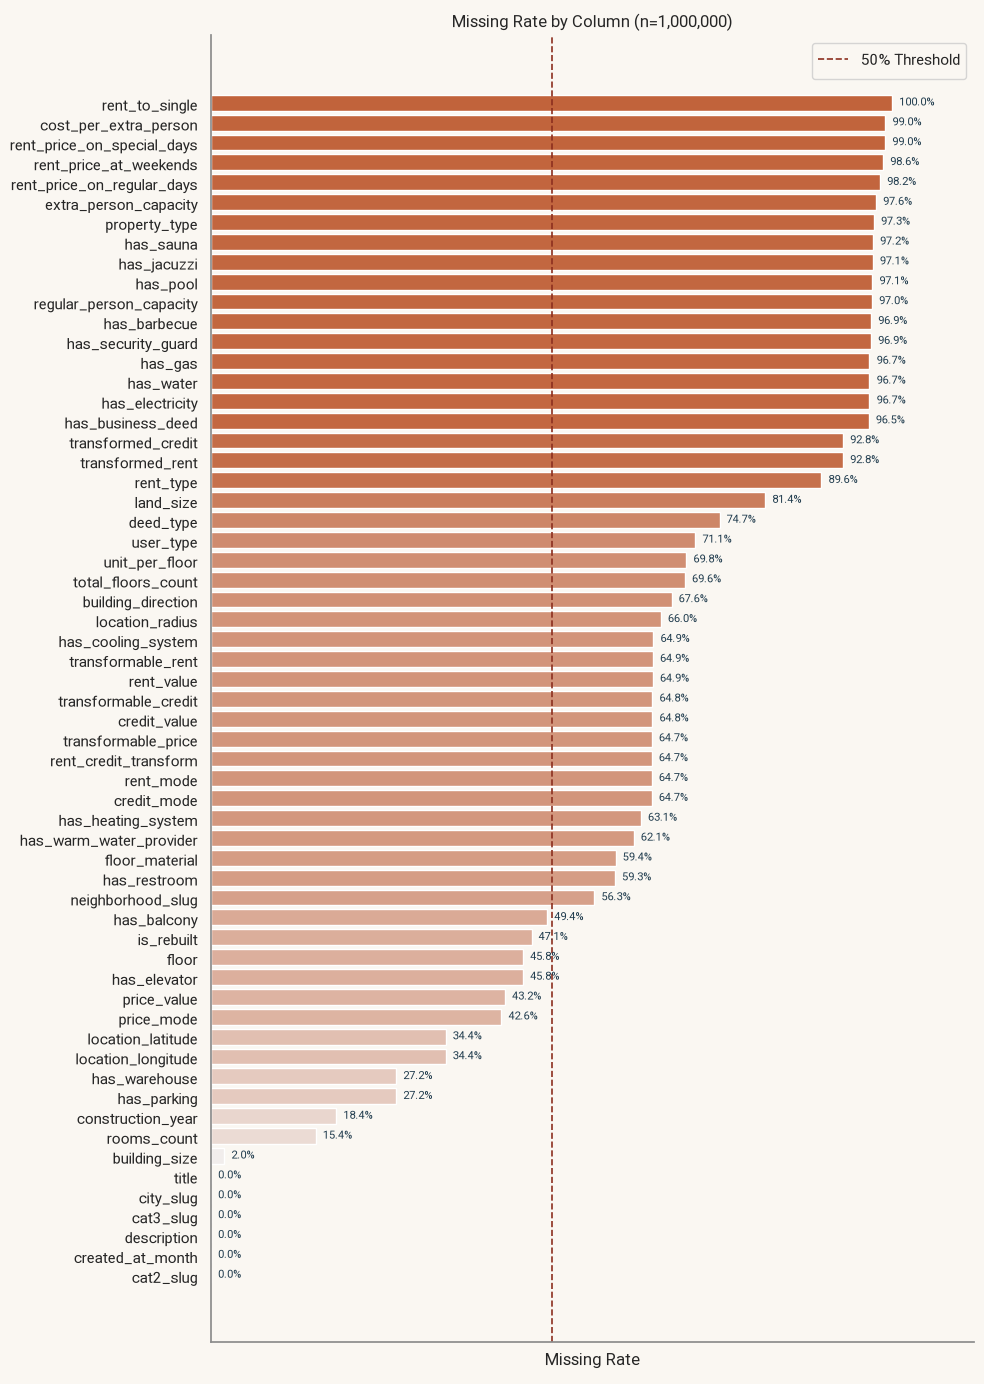

In [26]:
import matplotlib.pyplot as plt

missing_rate_cmap = HOUSING_PALETTE_SEQUENTIAL
plot_data = raw_profile.sort_values("missing_rate", ascending=True)
bar_colors = missing_rate_cmap(plot_data["missing_rate"])

fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(plot_data["column"], plot_data["missing_rate"], color=bar_colors)

ax.set_xlabel("Missing Rate")
ax.set_title(f"Missing Rate by Column (n={len(df_raw):,})")
ax.axvline(0.5, color="#8C2F1F", linestyle="--", linewidth=1.2, label="50% Threshold")
ax.legend()

ax.grid(False)
ax.set_xlim(0, plot_data["missing_rate"].max() * 1.12)
ax.set_xticks([])

for bar, value in zip(bars, plot_data["missing_rate"]):
    ax.text(
        bar.get_width() + plot_data["missing_rate"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=8,
        color="#1F3B4D",
    )

plt.tight_layout()
plt.savefig(FIGURES_RAW_DIR / "raw_missing_rate.png", dpi=150)
plt.show()

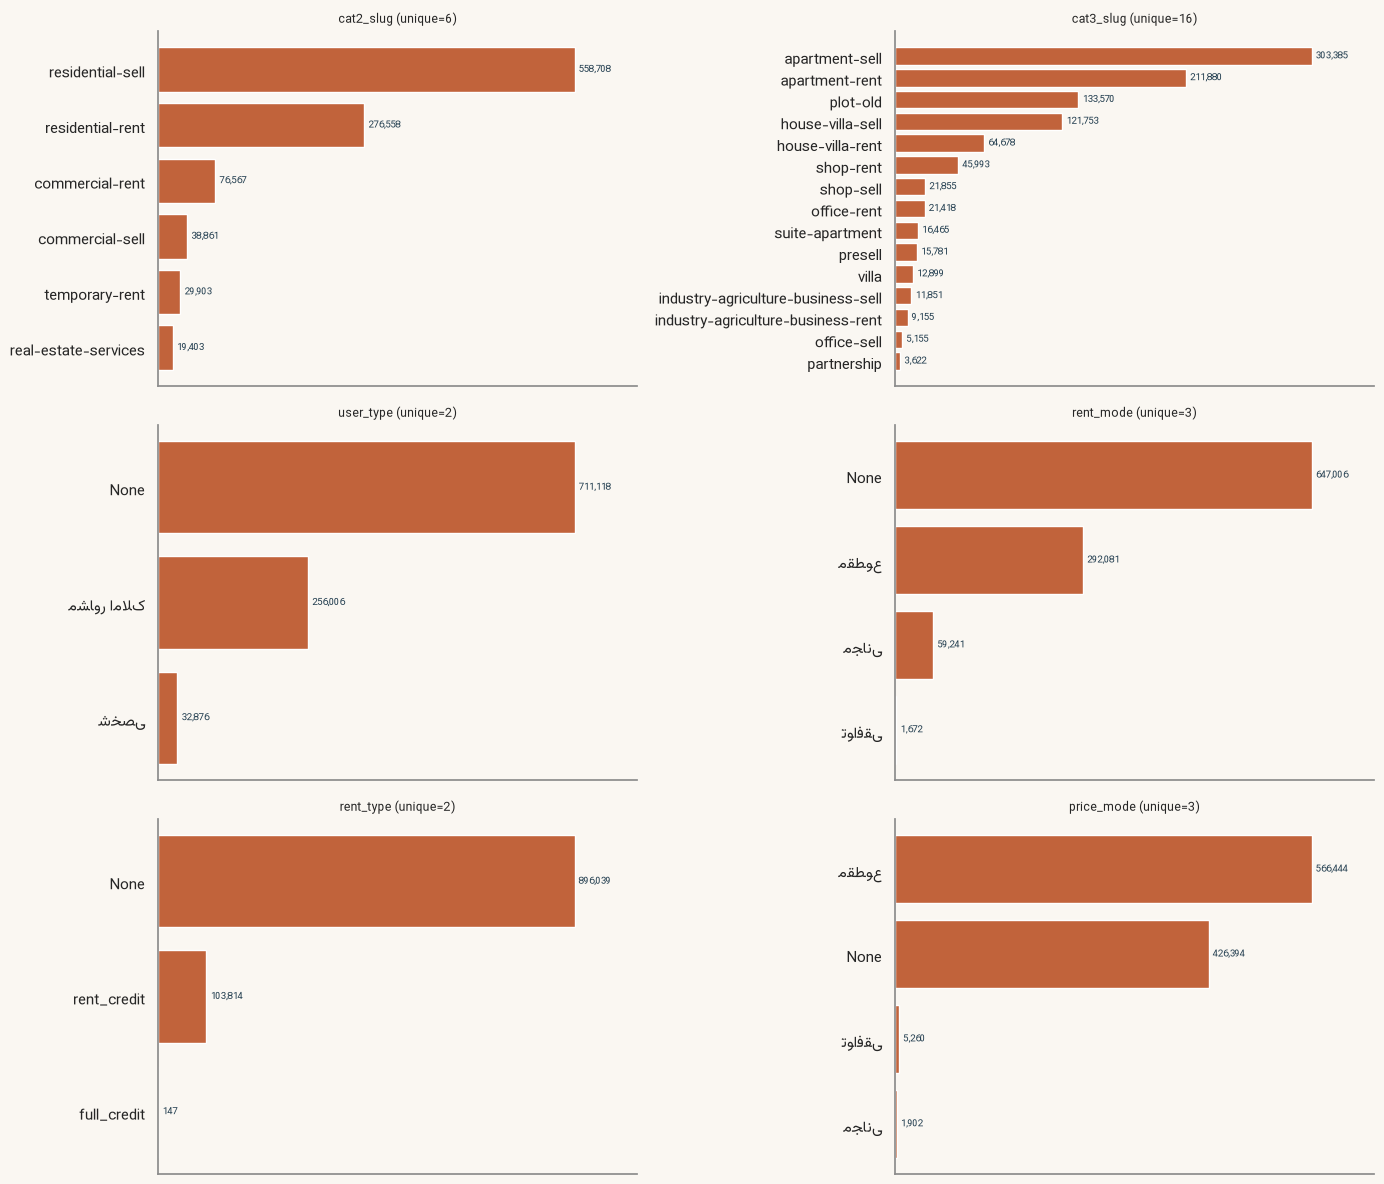

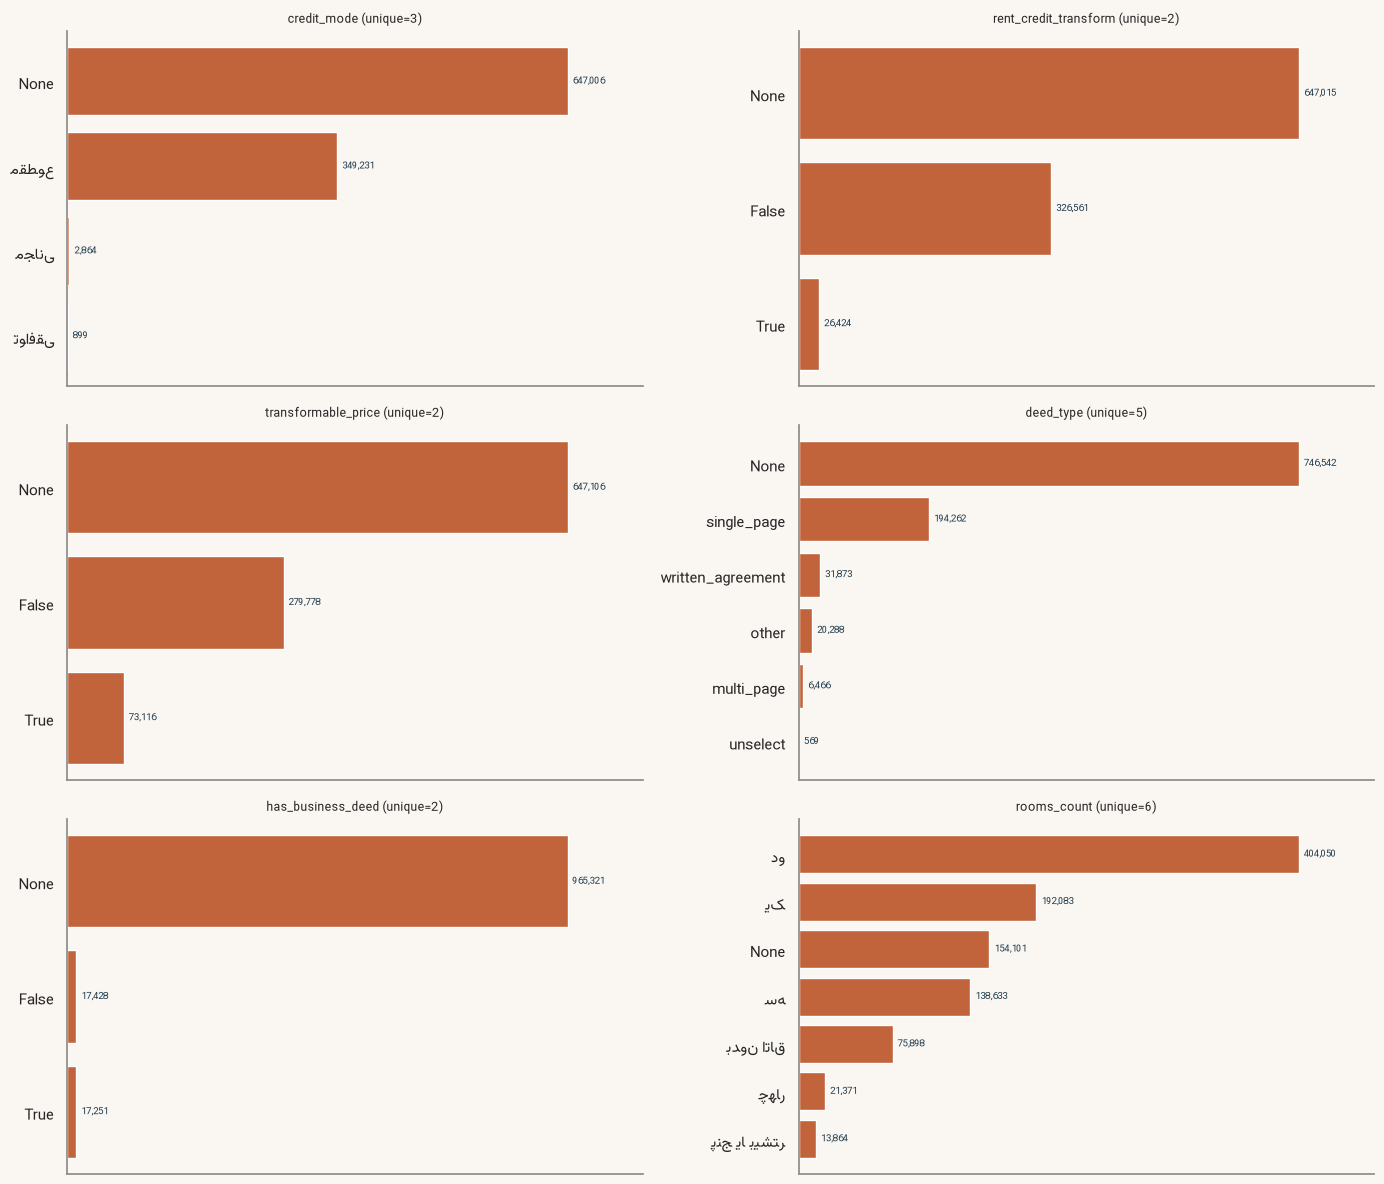

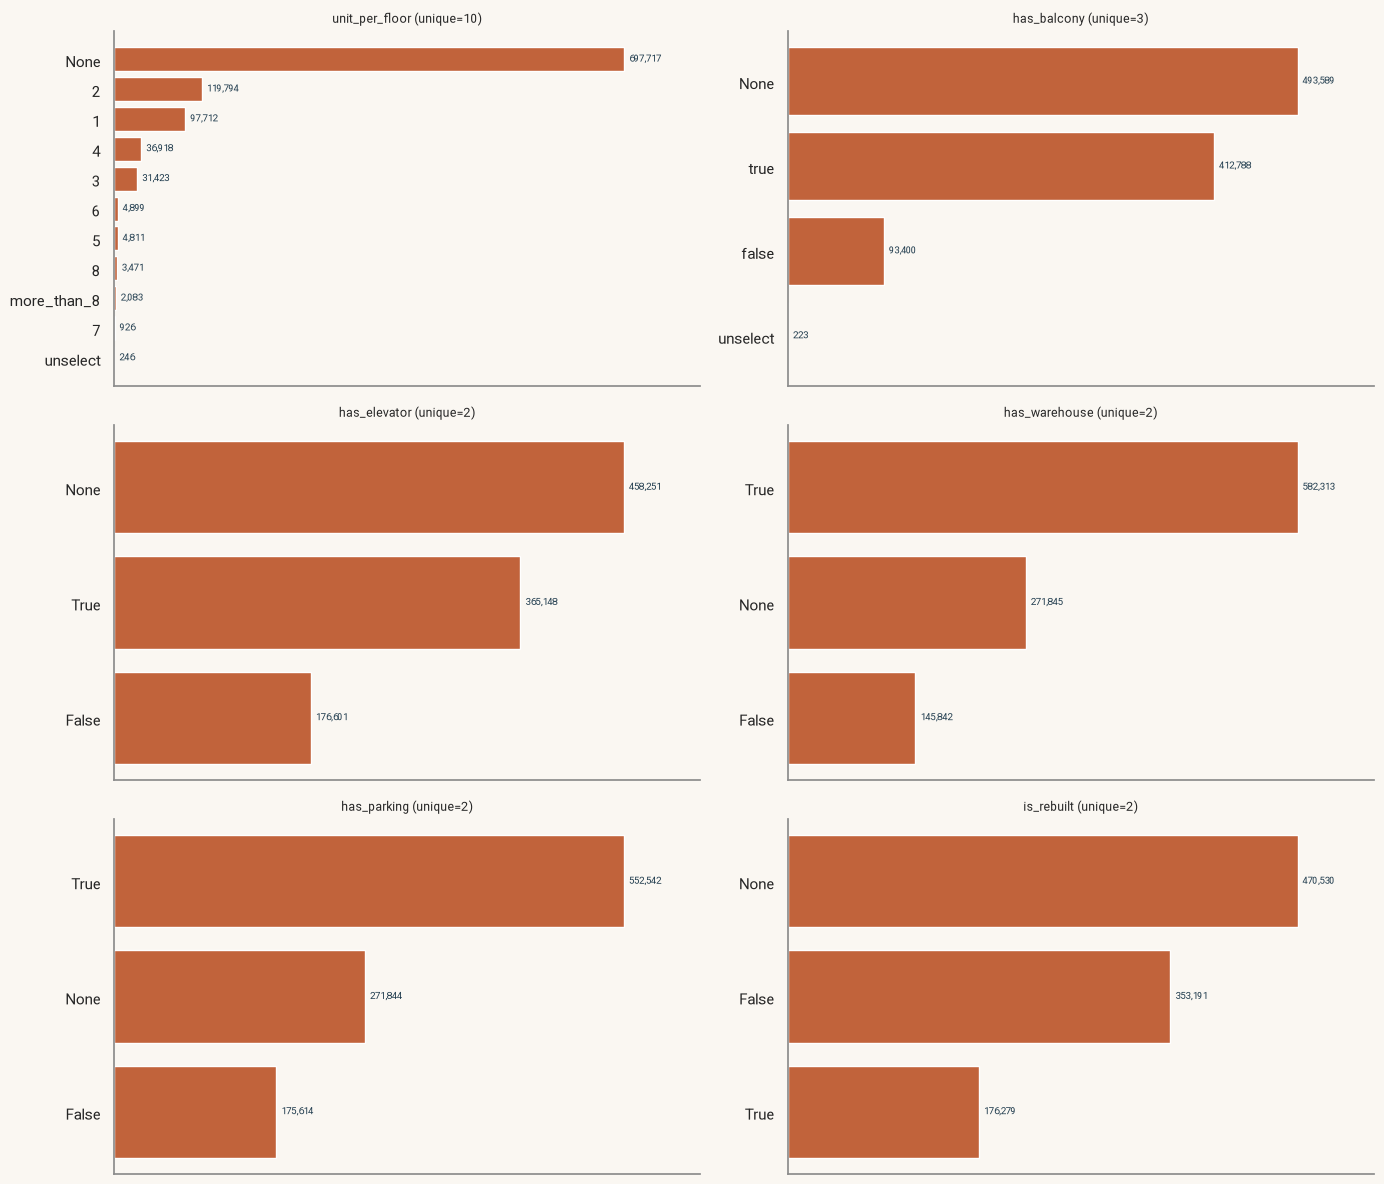

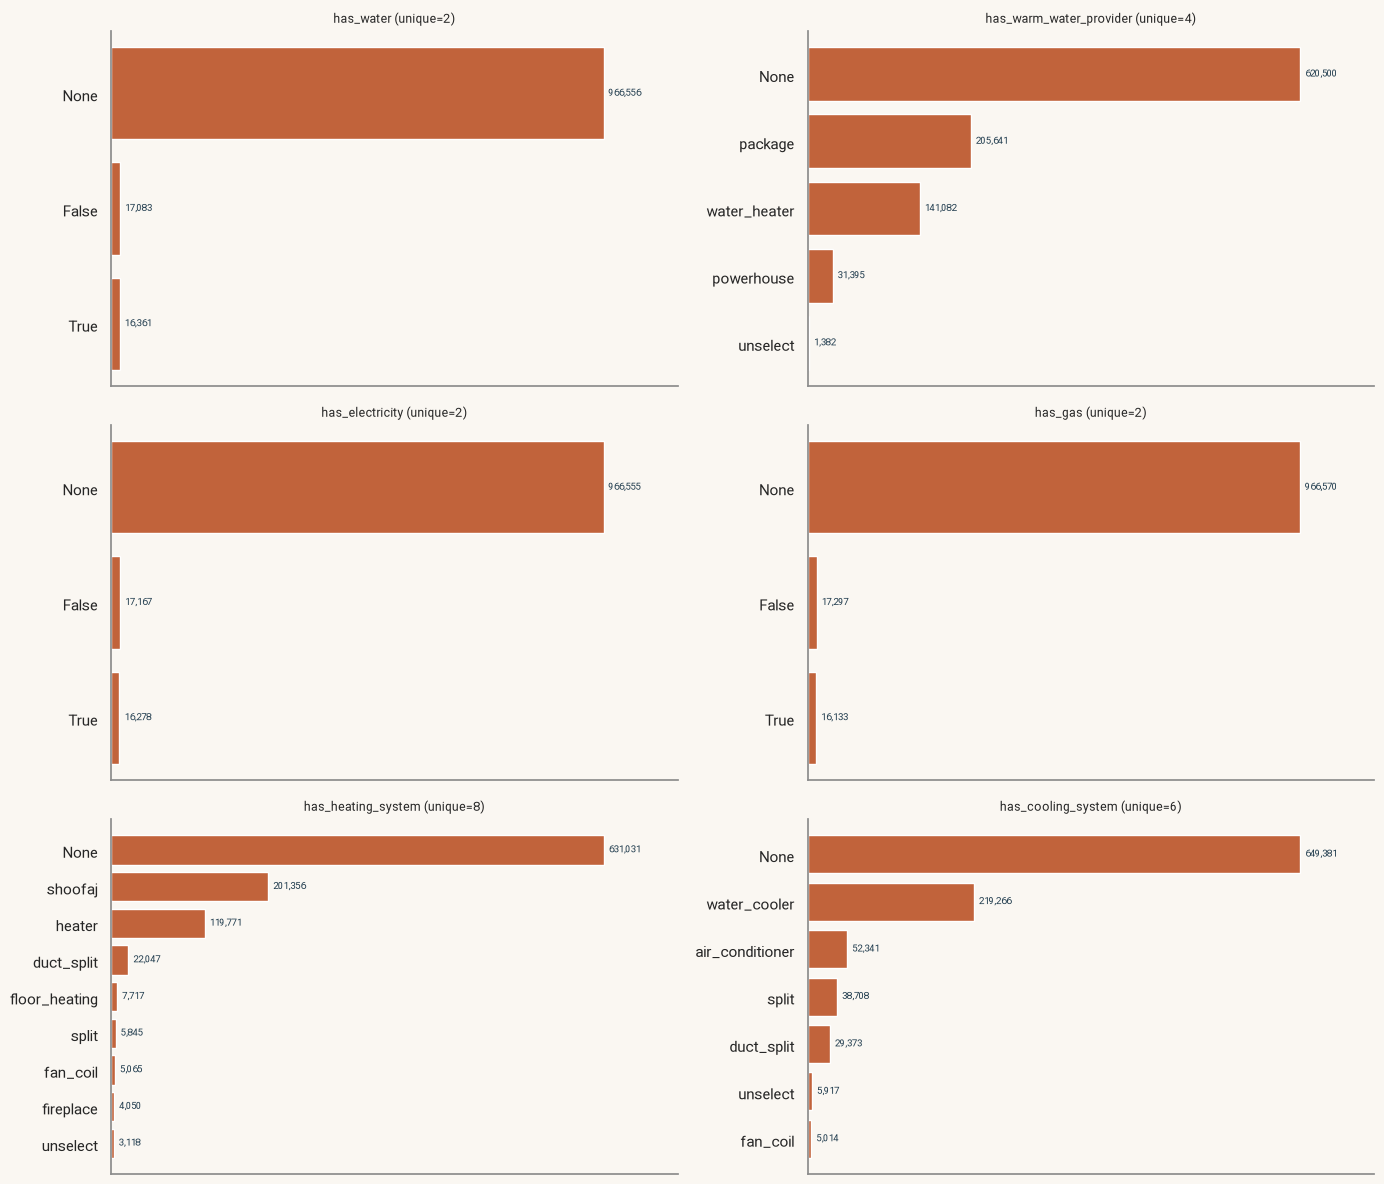

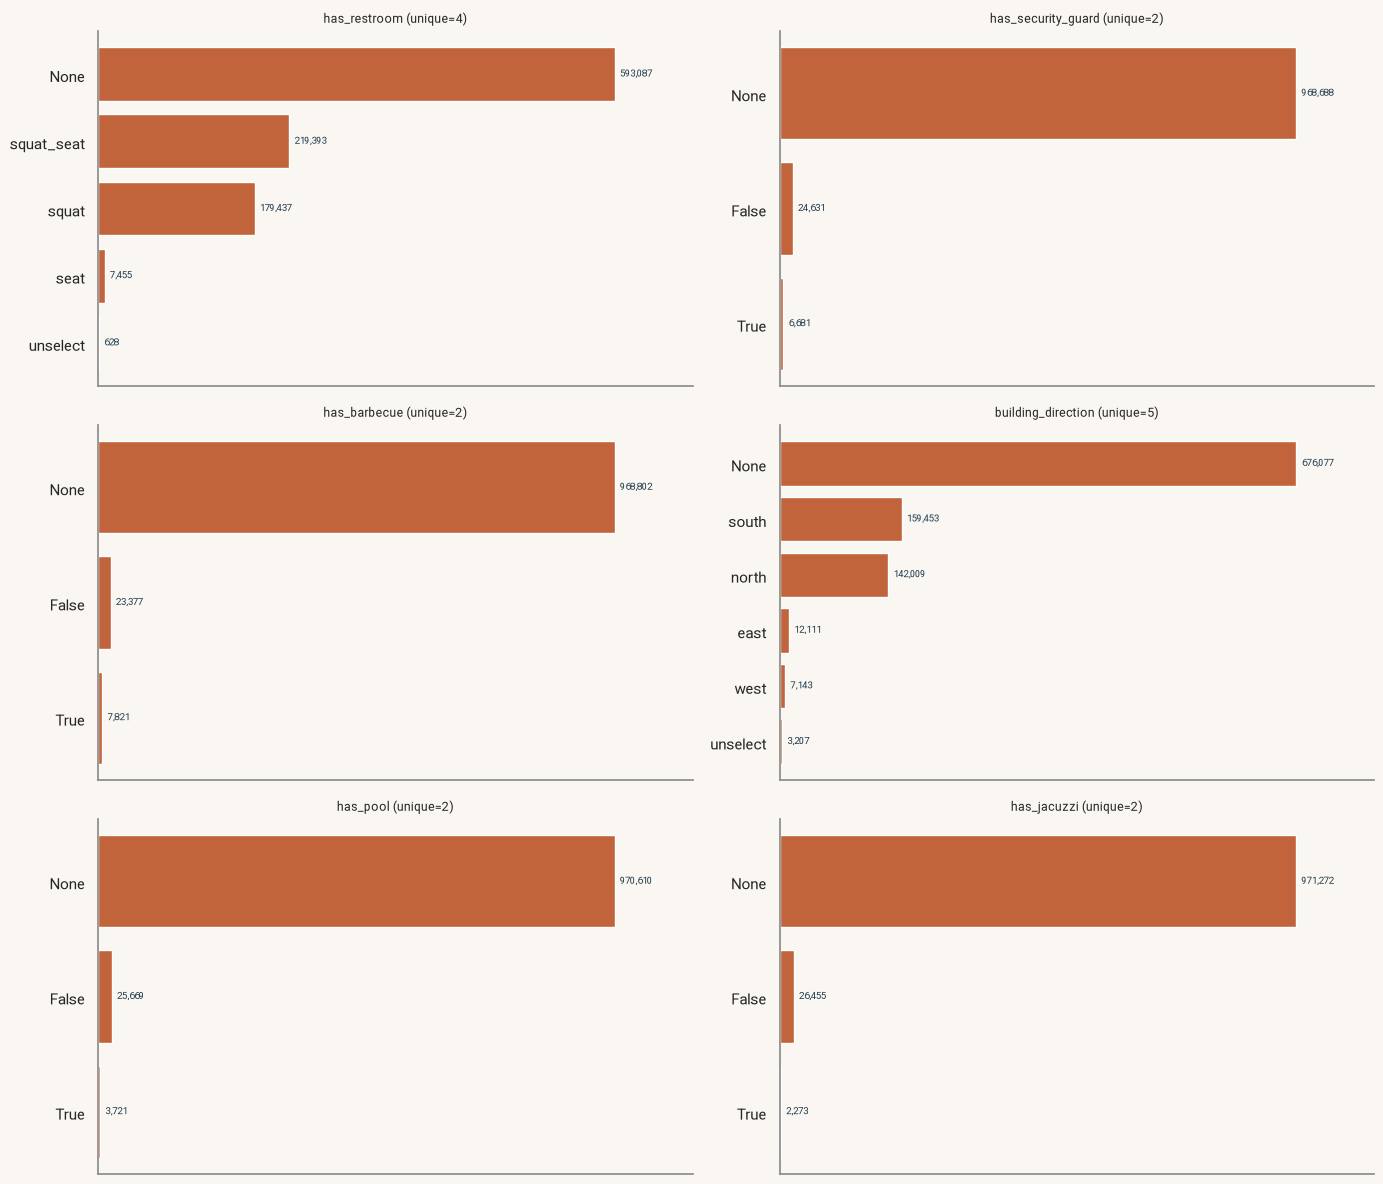

2026-08-13 23:43:38,786 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 23:43:38,791 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


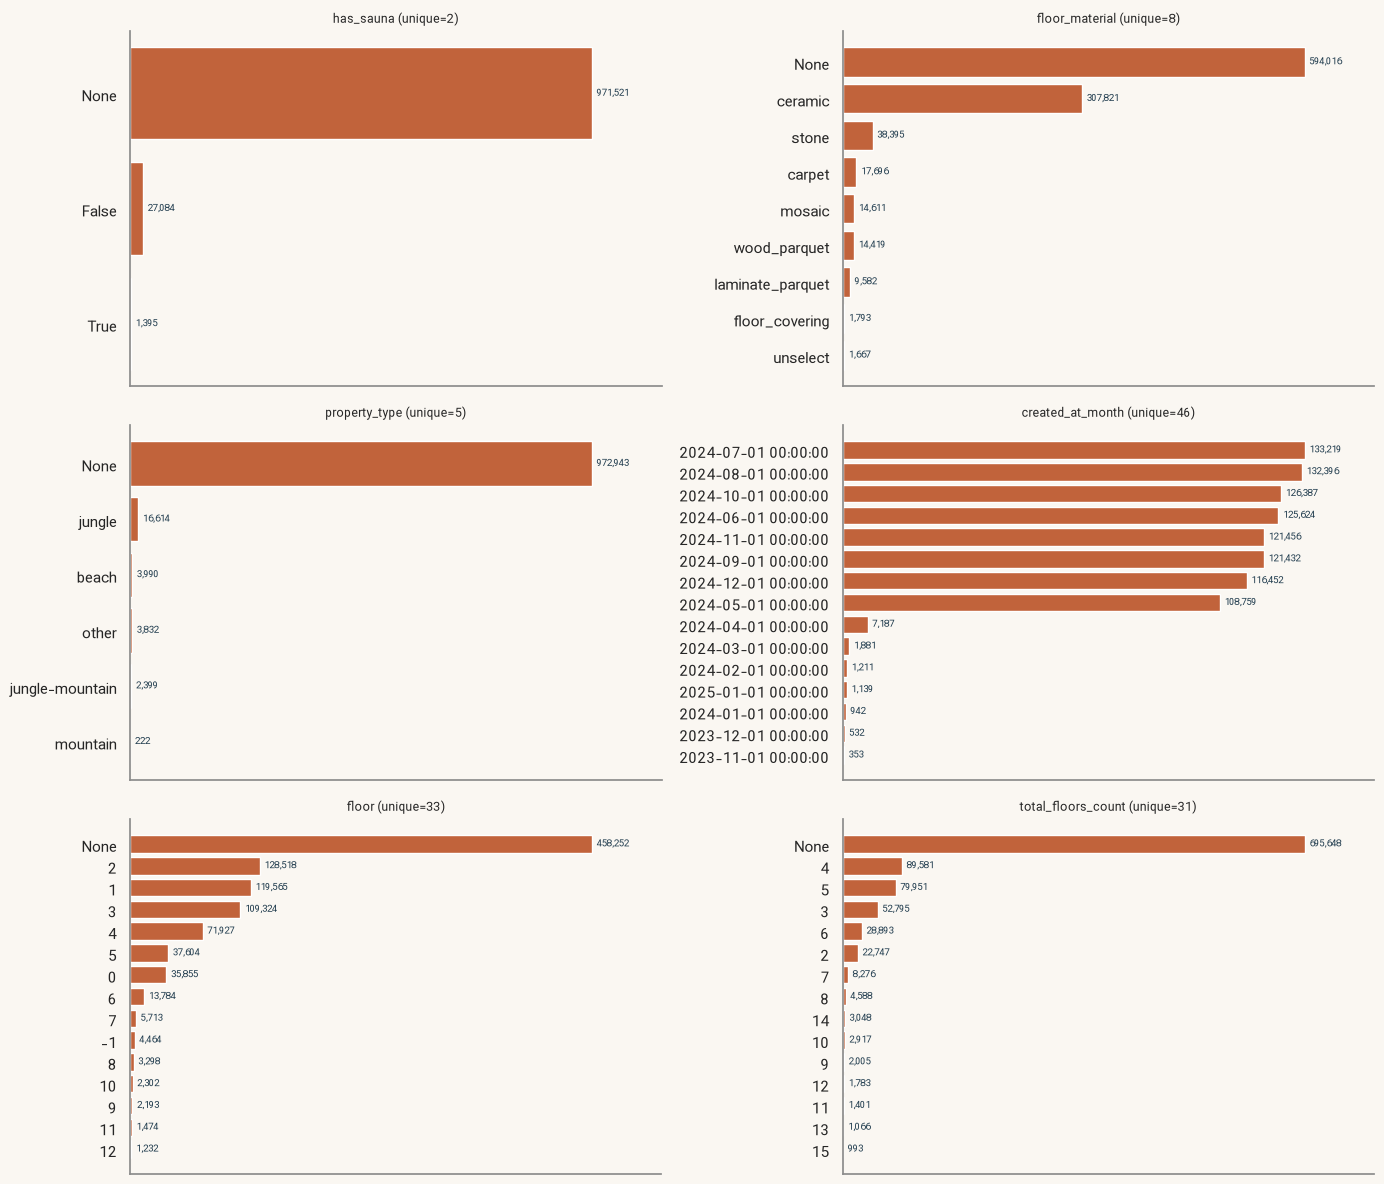

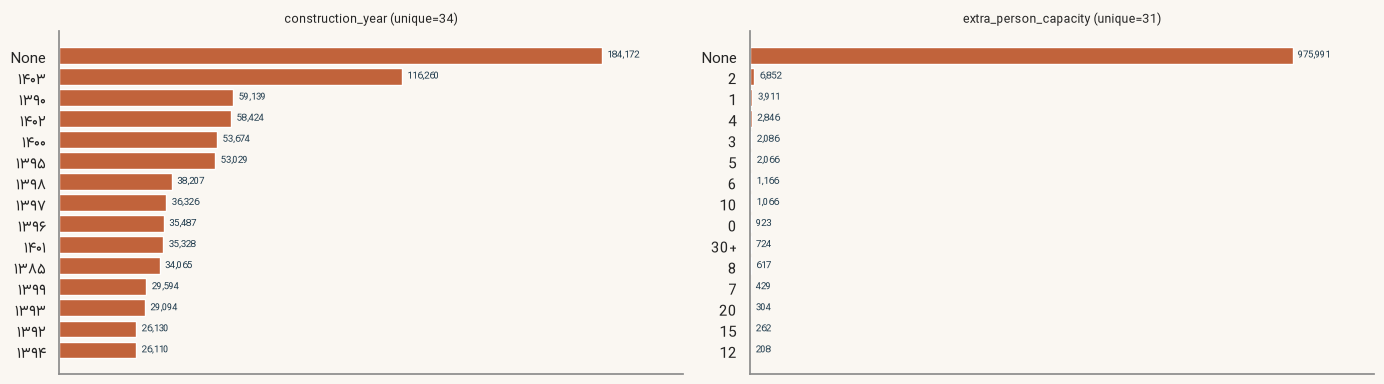

In [27]:
import re

PERSIAN_CHAR_PATTERN = re.compile(r"[\u0600-\u06FF]")


def format_tick_label(value: str) -> str:
    """Reshape a tick label for correct RTL rendering only if it actually
    contains Persian/Arabic characters (raw data values); labels that are
    numeric or already Latin (e.g. slugs, codes) are returned unchanged.

    Args:
        value: The raw tick label text.

    Returns:
        The reshaped/reordered string if Persian characters are present,
        otherwise the original string.
    """
    if PERSIAN_CHAR_PATTERN.search(value):
        return fa(value)
    return value


def plot_categorical_batch(
    columns: list[str],
    batch_size: int = 6,
    prefix: str = "raw_cat",
) -> None:
    """Plot categorical value distributions in batches and save each batch as a figure."""
    n_batches = -(-len(columns) // batch_size)
    for b in range(n_batches):
        batch_cols = columns[b * batch_size:(b + 1) * batch_size]
        n_rows = -(-len(batch_cols) // 2)
        fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 4))
        axes = np.array(axes).reshape(-1)

        for ax, col in zip(axes, batch_cols):
            vc = df_raw[col].value_counts(dropna=False).head(15)
            labels = [format_tick_label(str(v)) for v in vc.index]

            bars = ax.barh(labels, vc.values, color="#C1633B")
            ax.invert_yaxis()
            ax.set_title(f"{col} (unique={df_raw[col].nunique(dropna=True)})", fontsize=9)
            ax.grid(False)

            ax.set_xlim(0, vc.values.max() * 1.15)
            ax.set_xticks([])
            for bar, value in zip(bars, vc.values):
                ax.text(
                    bar.get_width() + vc.values.max() * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f"{value:,}",
                    va="center",
                    ha="left",
                    fontsize=7,
                    color="#1F3B4D",
                )

        for ax in axes[len(batch_cols):]:
            ax.axis("off")

        plt.tight_layout()
        fname = FIGURES_RAW_DIR / f"{prefix}_batch_{b + 1}.png"
        plt.savefig(fname, dpi=150)
        plt.show()


all_categorical_for_plot = low_card_object_cols + mid_card_object_cols
plot_categorical_batch(all_categorical_for_plot, batch_size=6)

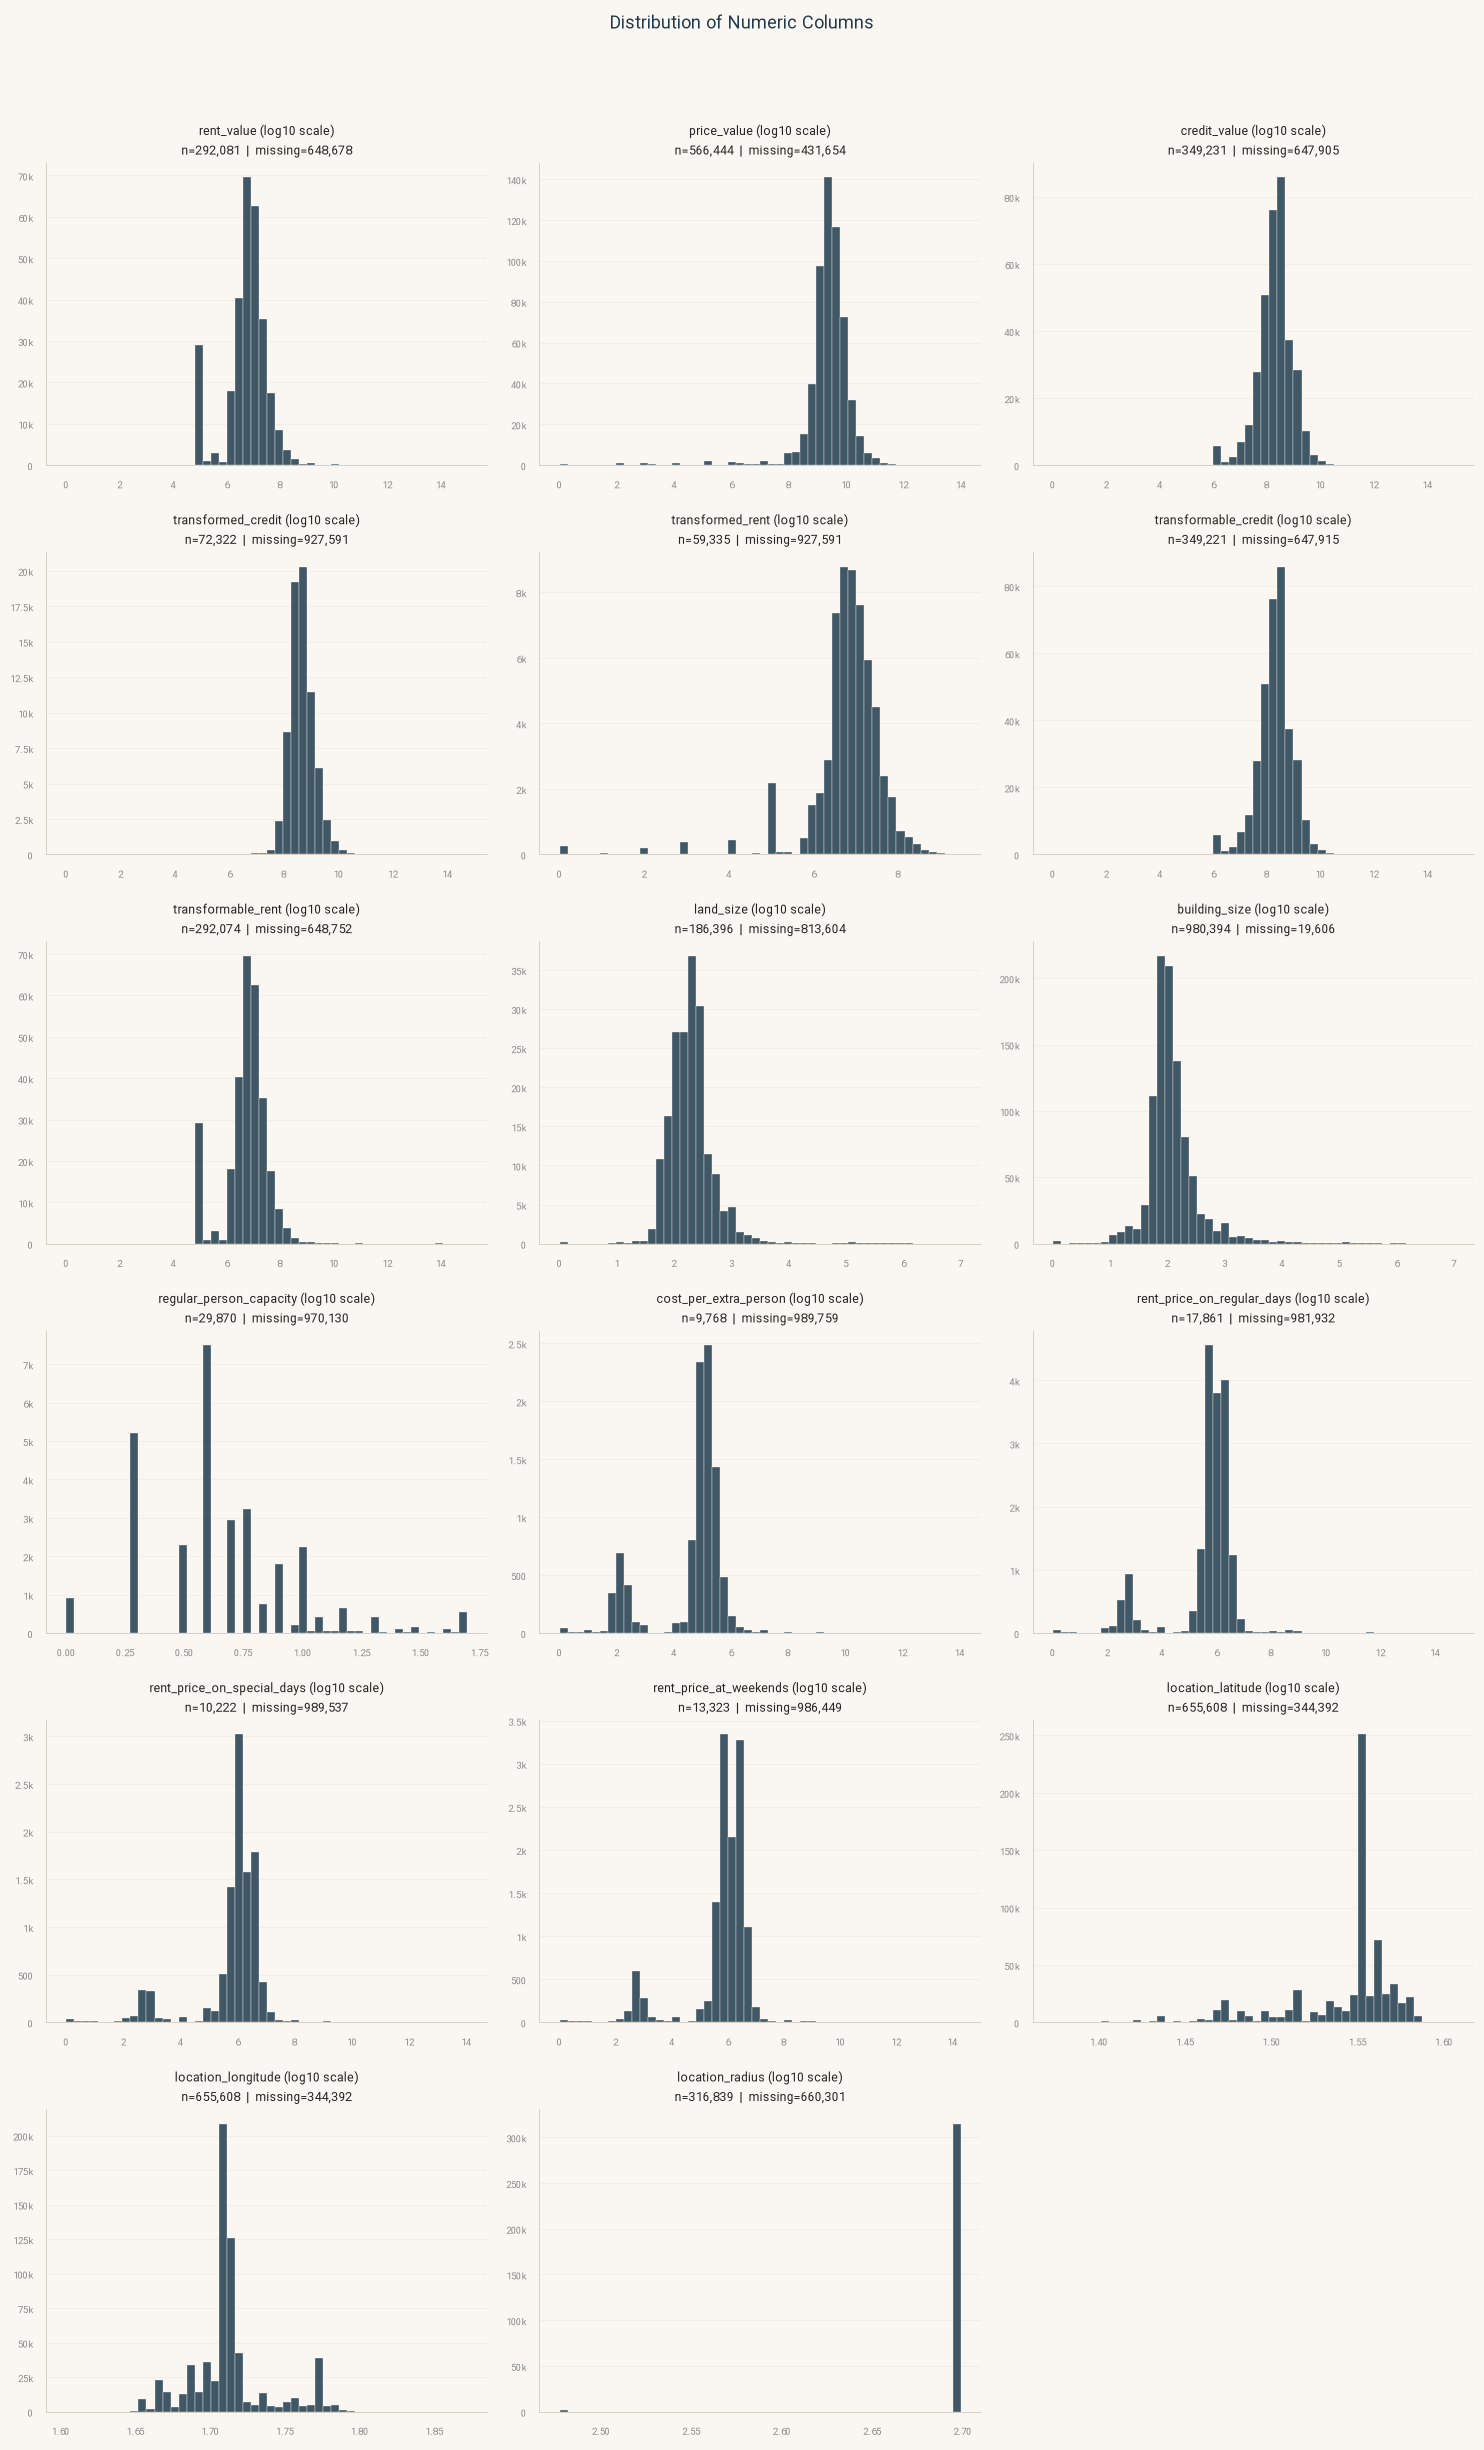

In [28]:
from matplotlib.ticker import FuncFormatter


def format_thousands(value: float, _pos: int) -> str:
    """Format a y-axis tick value as e.g. '12k' when >= 1000, otherwise
    as a plain integer.
    """
    if abs(value) >= 1_000:
        return f"{value / 1_000:g}k"
    return f"{value:g}"


n_cols = 3
n_rows = -(-len(genuinely_numeric_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = np.asarray(axes).flatten()

for ax, col in zip(axes, genuinely_numeric_cols):
    data = df_raw[col].dropna()
    data_positive = data[data > 0]

    if len(data_positive) > 0:
        ax.hist(np.log10(data_positive), bins=50, color="#1F3B4D", alpha=0.85, edgecolor="#FAF7F2", linewidth=0.3)
        ax.set_title(
            f"{col} (log10 scale)\nn={len(data_positive):,}  |  missing={df_raw[col].isna().sum():,}",
            fontsize=9,
        )
    else:
        ax.set_title(f"{col}\n(no positive values)", fontsize=9, color="#8C8C8C")

    ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))

    ax.tick_params(axis="both", labelsize=7, colors="#8C8C8C")

    
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("#C9C2B6")

    
    ax.grid(True, axis="y", color="#EFEAE1", linewidth=0.5)

for ax in axes[len(genuinely_numeric_cols):]:
    ax.axis("off")

fig.suptitle("Distribution of Numeric Columns", fontsize=13, color="#1F3B4D", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_RAW_DIR / "raw_numeric_histograms_log.png", dpi=150)
plt.show()

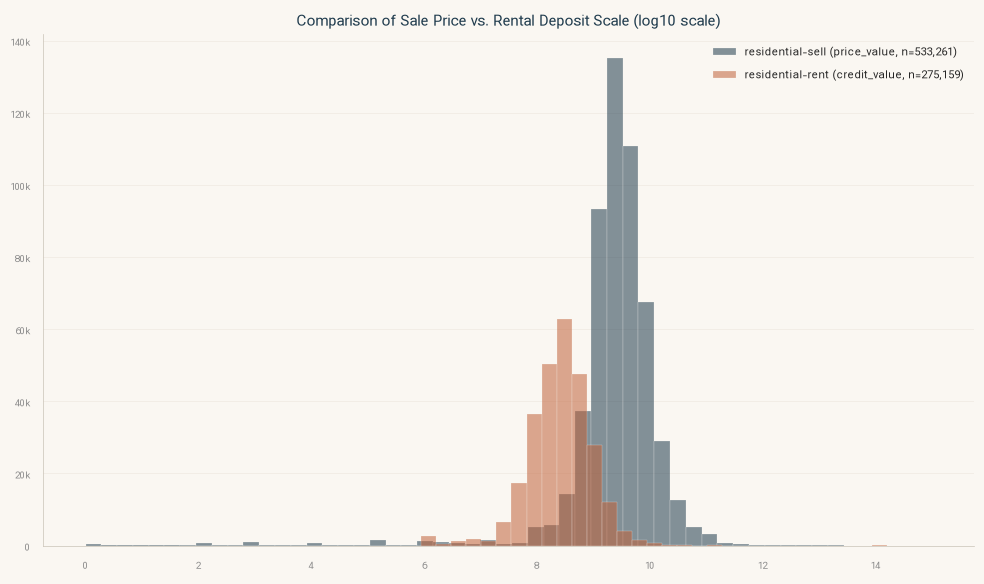

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

comparison_colors = ["#1F3B4D", "#C1633B"]

for (regime_hint, col_to_use), color in zip(
    [
        ("residential-sell", "price_value"),
        ("residential-rent", "credit_value"),
    ],
    comparison_colors,
):
    subset = df_raw.loc[df_raw["cat2_slug"] == regime_hint, col_to_use]
    subset = subset.dropna()
    subset = subset[subset > 0]
    if len(subset) > 0:
        ax.hist(
            np.log10(subset),
            bins=50,
            alpha=0.55,
            color=color,
            edgecolor="#FAF7F2",
            linewidth=0.3,
            label=f"{regime_hint} ({col_to_use}, n={len(subset):,})",
        )

ax.legend(fontsize=8, frameon=False)
ax.set_title("Comparison of Sale Price vs. Rental Deposit Scale (log10 scale)", fontsize=11, color="#1F3B4D")

ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
ax.tick_params(axis="both", labelsize=7, colors="#8C8C8C")

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

ax.grid(True, axis="y", color="#EFEAE1", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES_RAW_DIR / "raw_price_scale_comparison.png", dpi=150)
plt.show()

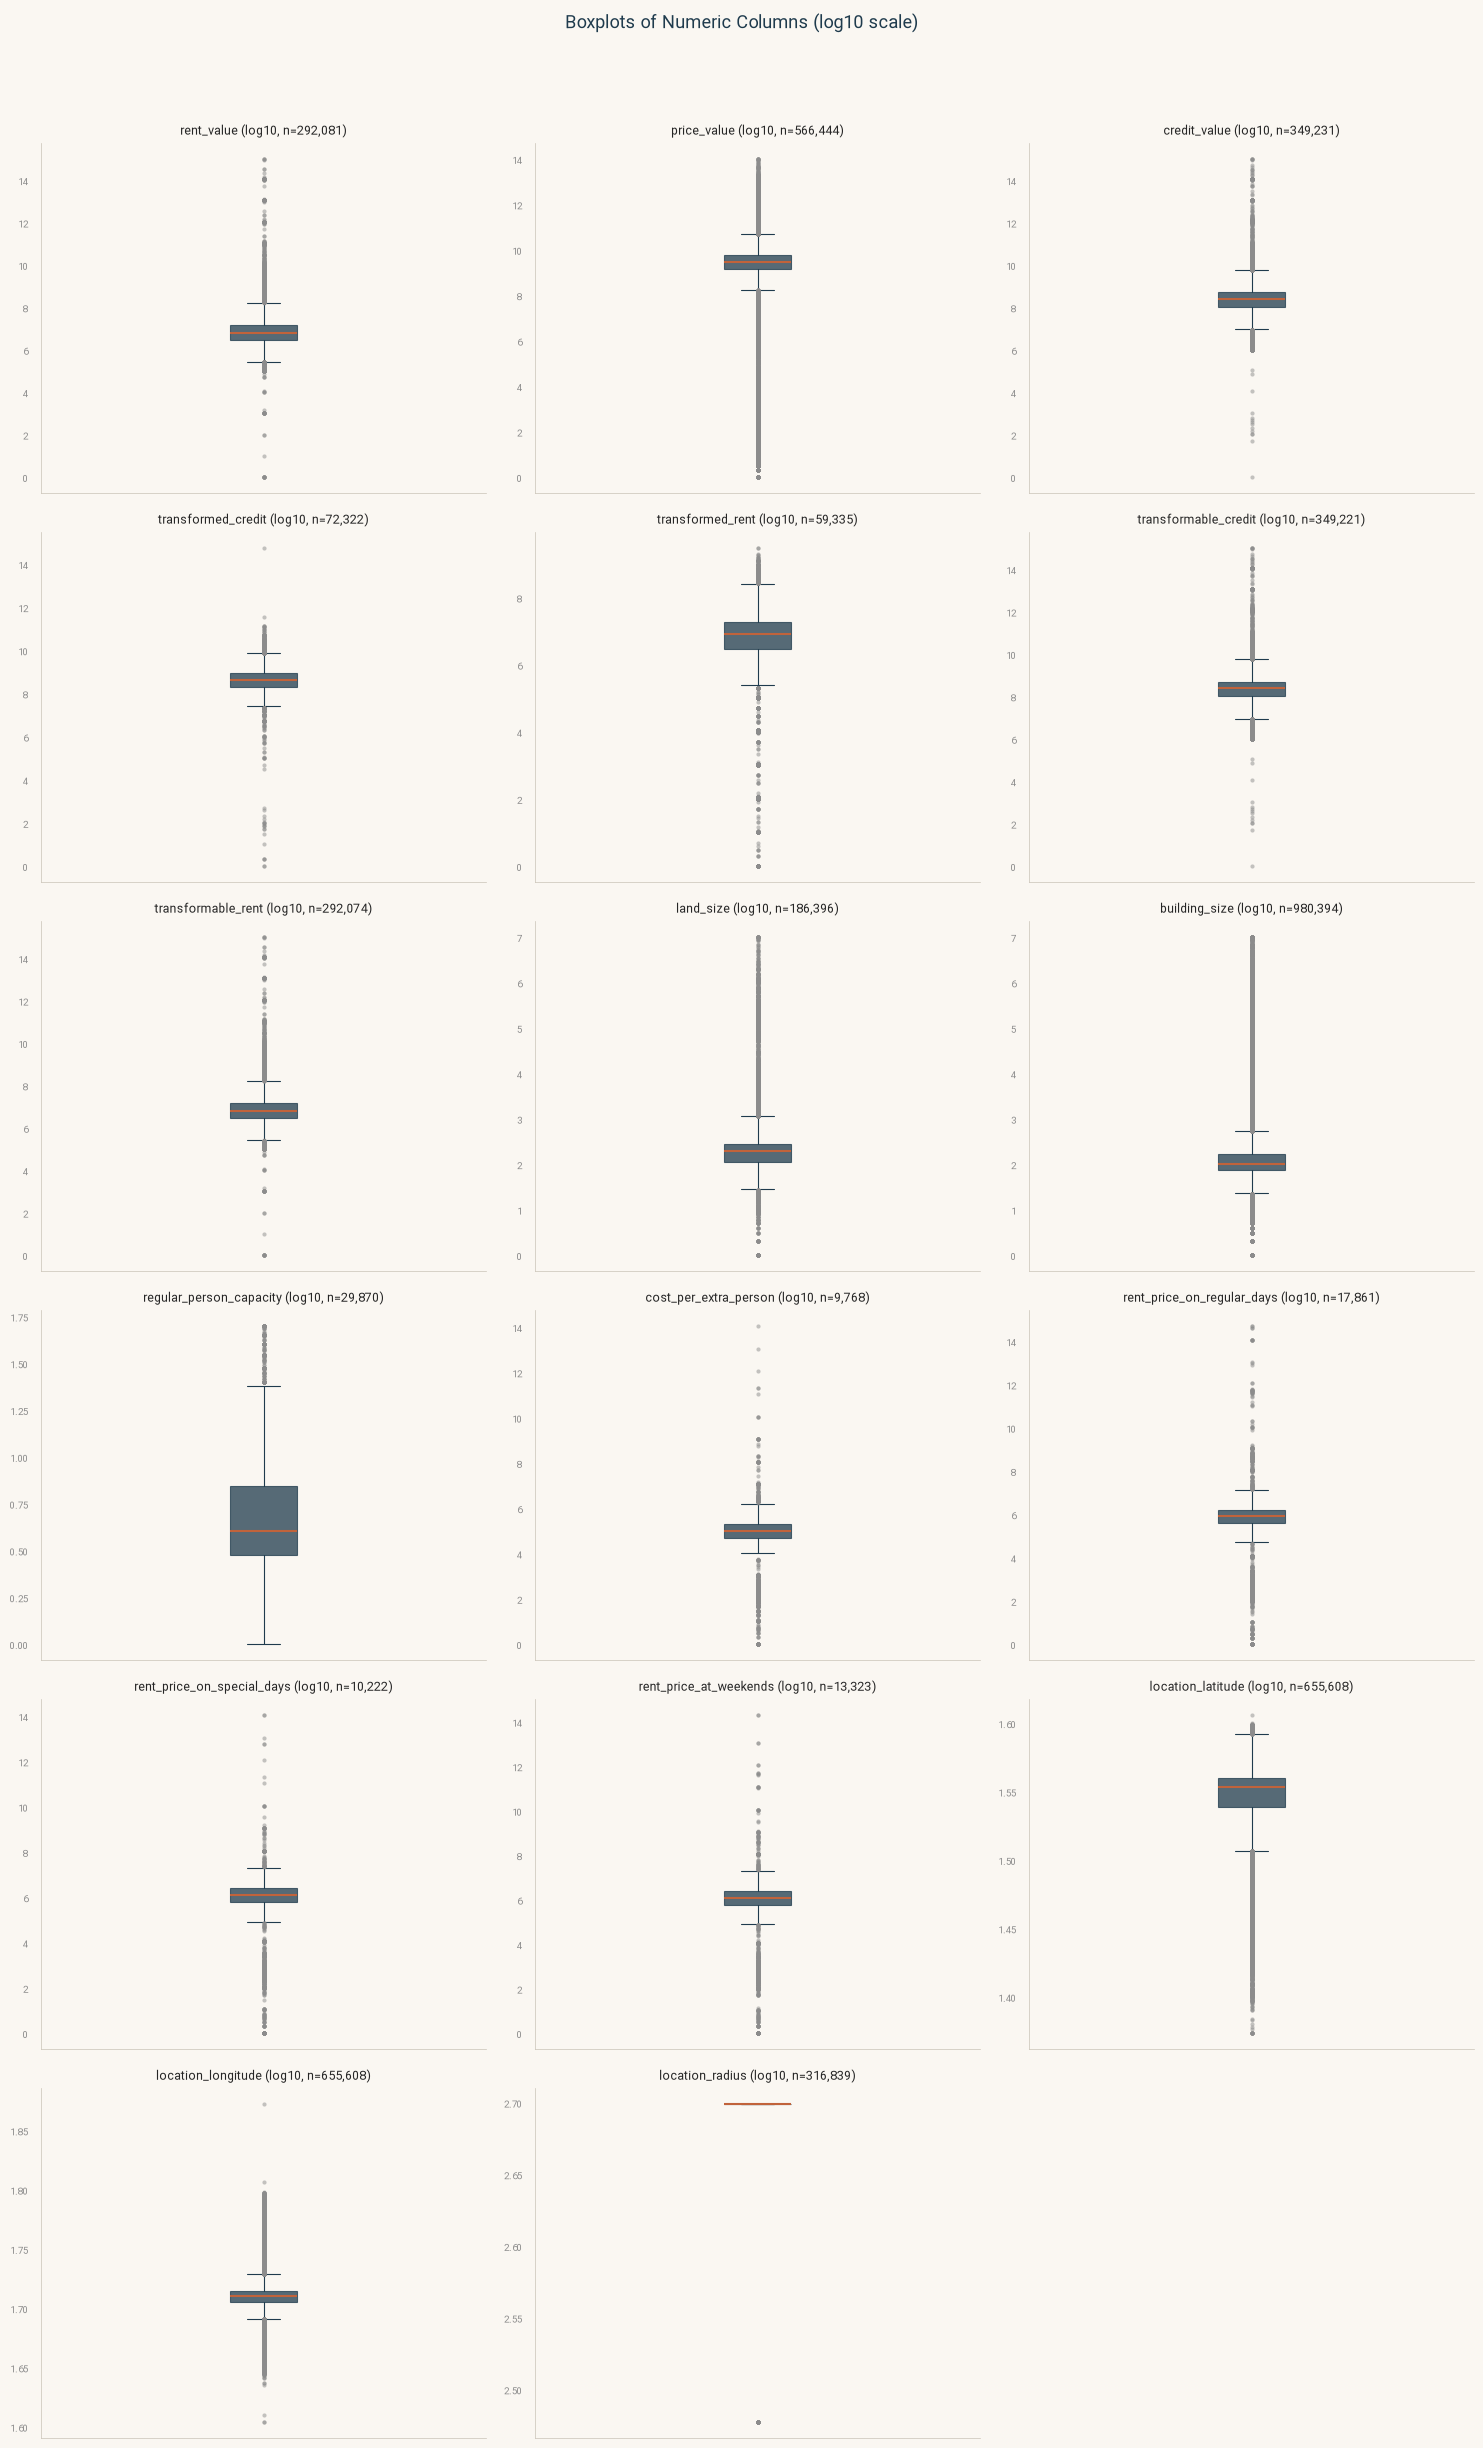

In [30]:
n_cols = 3
n_rows = -(-len(genuinely_numeric_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

boxprops = dict(facecolor="#1F3B4D", alpha=0.75, edgecolor="#1F3B4D", linewidth=0.8)
medianprops = dict(color="#C1633B", linewidth=1.5)
whiskerprops = dict(color="#1F3B4D", linewidth=0.8)
capprops = dict(color="#1F3B4D", linewidth=0.8)
flierprops = dict(marker="o", markersize=3, markerfacecolor="#8C8C8C", markeredgecolor="none", alpha=0.5)

for ax, col in zip(axes, genuinely_numeric_cols):
    data = df_raw[col].dropna()
    data_positive = data[data > 0]

    if len(data_positive) > 0:
        ax.boxplot(
            np.log10(data_positive),
            orientation="vertical",
            patch_artist=True,
            boxprops=boxprops,
            medianprops=medianprops,
            whiskerprops=whiskerprops,
            capprops=capprops,
            flierprops=flierprops,
        )
        ax.set_title(f"{col} (log10, n={len(data_positive):,})", fontsize=9)
    else:
        ax.set_title(f"{col}\n(no positive values)", fontsize=9, color="#8C8C8C")

    ax.grid(False)
    ax.set_xticks([])  

    ax.tick_params(axis="y", labelsize=7, colors="#8C8C8C")
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("#C9C2B6")

for ax in axes[len(genuinely_numeric_cols):]:
    ax.axis("off")

fig.suptitle("Boxplots of Numeric Columns (log10 scale)", fontsize=13, color="#1F3B4D", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_RAW_DIR / "raw_numeric_boxplots_log.png", dpi=150)
plt.show()

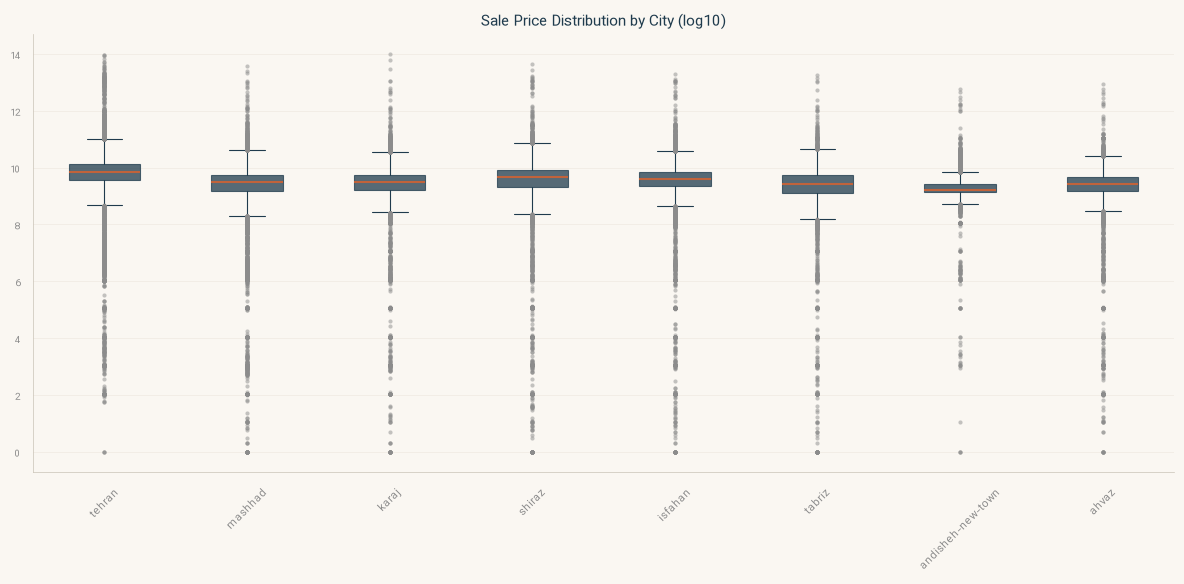

In [31]:
top_cities = df_raw["city_slug"].value_counts().head(8).index
subset = df_raw[df_raw["city_slug"].isin(top_cities) & (df_raw["cat2_slug"] == "residential-sell")].copy()
subset = subset[subset["price_value"] > 0]
subset["log_price"] = np.log10(subset["price_value"])

fig, ax = plt.subplots(figsize=(12, 6))

boxprops = dict(facecolor="#1F3B4D", alpha=0.75, edgecolor="#1F3B4D", linewidth=0.8)
medianprops = dict(color="#C1633B", linewidth=1.5)
whiskerprops = dict(color="#1F3B4D", linewidth=0.8)
capprops = dict(color="#1F3B4D", linewidth=0.8)
flierprops = dict(marker="o", markersize=3, markerfacecolor="#8C8C8C", markeredgecolor="none", alpha=0.5)

grouped_data = [subset.loc[subset["city_slug"] == city, "log_price"] for city in top_cities]
ax.boxplot(
    grouped_data,
    tick_labels=list(top_cities),
    patch_artist=True,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    flierprops=flierprops,
)

ax.set_title("Sale Price Distribution by City (log10)", fontsize=11, color="#1F3B4D")
ax.tick_params(axis="x", labelsize=8, colors="#8C8C8C", rotation=45)
ax.tick_params(axis="y", labelsize=7, colors="#8C8C8C")

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

ax.grid(True, axis="y", color="#EFEAE1", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES_RAW_DIR / "raw_price_boxplot_by_city.png", dpi=150)
plt.show()

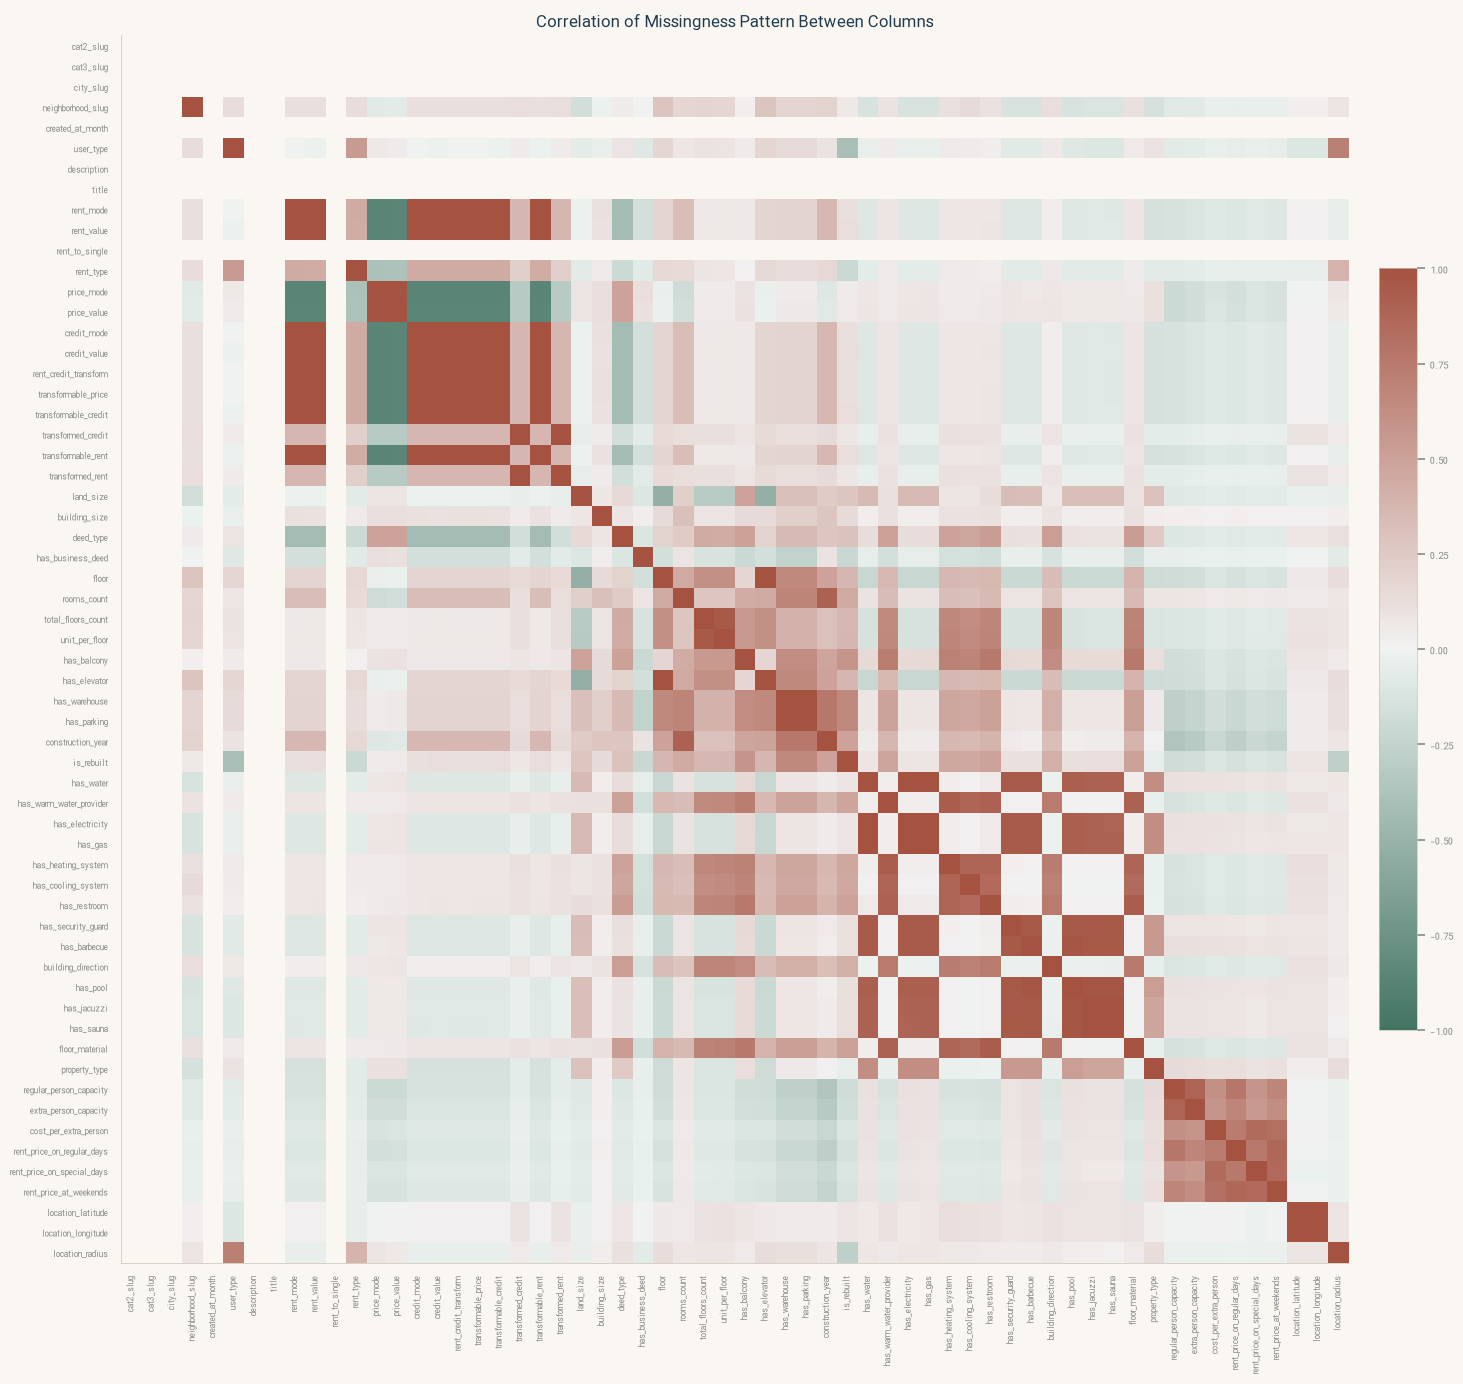

In [32]:
missing_matrix = df_raw.isna().astype(int)
sample_for_heatmap = missing_matrix.sample(n=min(5000, len(missing_matrix)), random_state=42)
missing_corr = sample_for_heatmap.corr()

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(missing_corr, cmap=HOUSING_PALETTE_DIVERGING, vmin=-1, vmax=1)

ax.set_xticks(range(len(missing_corr.columns)))
ax.set_xticklabels(missing_corr.columns, rotation=90, fontsize=6, color="#8C8C8C")
ax.set_yticks(range(len(missing_corr.columns)))
ax.set_yticklabels(missing_corr.columns, fontsize=6, color="#8C8C8C")

ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.outline.set_linewidth(0.5)
cbar.outline.set_edgecolor("#C9C2B6")
cbar.ax.tick_params(labelsize=7, colors="#8C8C8C")

ax.set_title("Correlation of Missingness Pattern Between Columns", fontsize=12, color="#1F3B4D")
plt.tight_layout()
plt.savefig(FIGURES_RAW_DIR / "raw_missingness_correlation_heatmap.png", dpi=150)
plt.show()

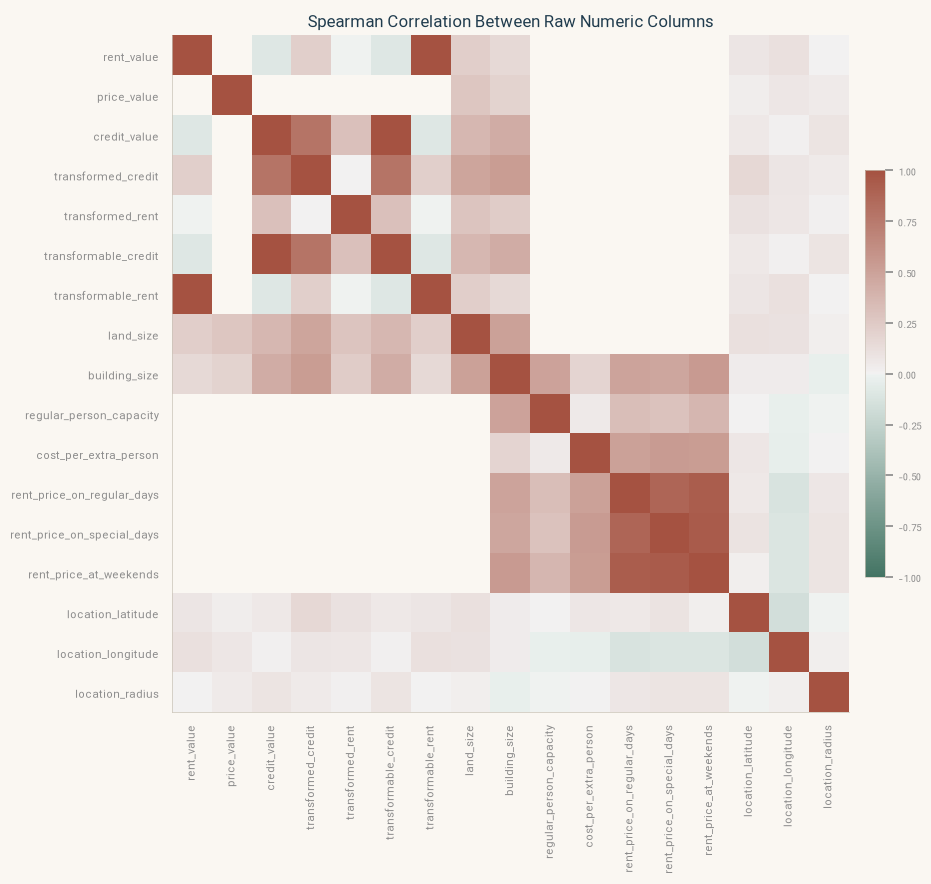

In [33]:
corr_data = df_raw[genuinely_numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(corr_data, cmap=HOUSING_PALETTE_DIVERGING, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_data.columns)))
ax.set_xticklabels(corr_data.columns, rotation=90, fontsize=8, color="#8C8C8C")
ax.set_yticks(range(len(corr_data.columns)))
ax.set_yticklabels(corr_data.columns, fontsize=8, color="#8C8C8C")

ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.outline.set_linewidth(0.5)
cbar.outline.set_edgecolor("#C9C2B6")
cbar.ax.tick_params(labelsize=7, colors="#8C8C8C")

ax.set_title("Spearman Correlation Between Raw Numeric Columns", fontsize=12, color="#1F3B4D")
plt.tight_layout()
plt.savefig(FIGURES_RAW_DIR / "raw_numeric_correlation_heatmap.png", dpi=150)
plt.show()

<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
پاک سازی داده

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>علامت گذاری مختصات هایی که داخل ایران نیستند</b>
</font>
</h4></h4>

In [36]:
IRAN_LAT_MIN, IRAN_LAT_MAX = 25.0, 40.0
IRAN_LON_MIN, IRAN_LON_MAX = 44.0, 63.5

coord_present = df_raw[["location_latitude", "location_longitude"]].notna().all(axis=1)
n_coord_present = coord_present.sum()

in_iran_box = (
    df_raw["location_latitude"].between(IRAN_LAT_MIN, IRAN_LAT_MAX)
    & df_raw["location_longitude"].between(IRAN_LON_MIN, IRAN_LON_MAX)
)
n_invalid_coords = (coord_present & ~in_iran_box).sum()

print(f"Rows with coordinates present: {n_coord_present:,}")
print(f"Rows with coordinates outside Iran bounding box: {n_invalid_coords:,} "
      f"({n_invalid_coords / n_coord_present:.4%} of present coordinates)")

invalid_coord_examples = df_raw.loc[coord_present & ~in_iran_box, ["city_slug", "location_latitude", "location_longitude"]]
display(invalid_coord_examples.head(20))

Rows with coordinates present: 655,608
Rows with coordinates outside Iran bounding box: 47 (0.0072% of present coordinates)


,city_slug,location_latitude,location_longitude
10895,nahavand,23.636976,52.240677
71650,qeshm,23.636976,55.139008
101401,chabahar,24.705099,60.475864
122845,chabahar,24.726173,60.529667
145961,mashhad,32.822731,74.511620
182386,chabahar,24.979246,60.618958
219766,maku,37.677303,43.981018
247743,chabahar,24.688200,60.335541
305774,chabahar,24.918823,60.617065
354730,chabahar,24.946218,60.512695


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b> معتبر کردن مقادیر ستون ها</b>
</font>
</h4>

In [38]:
inconsistency_report: dict[str, int] = {}

free_price_mask = (
    (df_raw["price_mode"] == "مجانی")
    & df_raw["price_value"].notna()
    & (df_raw["price_value"] > 0)
)
inconsistency_report["price_mode=free but price_value>0"] = int(free_price_mask.sum())

free_rent_mask = (
    (df_raw["rent_mode"] == "مجانی")
    & df_raw["rent_value"].notna()
    & (df_raw["rent_value"] > 0)
)
inconsistency_report["rent_mode=free but rent_value>0"] = int(free_rent_mask.sum())

free_credit_mask = (
    (df_raw["credit_mode"] == "مجانی")
    & df_raw["credit_value"].notna()
    & (df_raw["credit_value"] > 0)
)
inconsistency_report["credit_mode=free but credit_value>0"] = int(free_credit_mask.sum())

negotiable_price_mask = (
    (df_raw["price_mode"] == "توافقی")
    & df_raw["price_value"].notna()
    & (df_raw["price_value"] > 0)
)
inconsistency_report["price_mode=negotiable but price_value>0"] = int(
    negotiable_price_mask.sum()
)

floor_numeric = pd.to_numeric(df_raw["floor"], errors="coerce")
total_floors_numeric = pd.to_numeric(df_raw["total_floors_count"], errors="coerce")

floor_exceeds_total_mask = (
    floor_numeric.notna()
    & total_floors_numeric.notna()
    & (floor_numeric > total_floors_numeric)
)
inconsistency_report["floor > total_floors_count"] = int(
    floor_exceeds_total_mask.sum()
)

CURRENT_PERSIAN_YEAR = 1403

persian_digit_map = str.maketrans(
    "۰۱۲۳۴۵۶۷۸۹",
    "0123456789",
)

construction_year_numeric = pd.to_numeric(
    df_raw["construction_year"]
    .astype("string")
    .str.translate(persian_digit_map),
    errors="coerce",
)

future_construction_year_mask = (
    construction_year_numeric.notna()
    & (construction_year_numeric > CURRENT_PERSIAN_YEAR)
)
inconsistency_report["construction_year in the future"] = int(
    future_construction_year_mask.sum()
)

has_sale_price = (
    df_raw["price_value"].notna()
    & (df_raw["price_value"] > 0)
)

has_rent_or_credit = (
    (
        df_raw["rent_value"].notna()
        & (df_raw["rent_value"] > 0)
    )
    | (
        df_raw["credit_value"].notna()
        & (df_raw["credit_value"] > 0)
    )
    | (
        df_raw["rent_price_on_regular_days"].notna()
        & (df_raw["rent_price_on_regular_days"] > 0)
    )
    | (
        df_raw["rent_price_on_special_days"].notna()
        & (df_raw["rent_price_on_special_days"] > 0)
    )
    | (
        df_raw["rent_price_at_weekends"].notna()
        & (df_raw["rent_price_at_weekends"] > 0)
    )
)

both_present_mask = has_sale_price & has_rent_or_credit
neither_present_mask = ~has_sale_price & ~has_rent_or_credit

inconsistency_report["Rows with BOTH sale price AND rent/credit value"] = int(
    both_present_mask.sum()
)

inconsistency_report["Rows with NEITHER sale price NOR rent/credit value"] = int(
    neither_present_mask.sum()
)

for check, count in inconsistency_report.items():
    logger.info("%s: %s", check, f"{count:,}")

logger.info(
    "Breakdown of rows with BOTH sale price AND rent/credit value by cat2_slug:\n%s",
    df_raw.loc[both_present_mask, "cat2_slug"].value_counts(),
)

logger.info(
    "Breakdown of rows with NEITHER sale price NOR rent/credit value by cat2_slug:\n%s",
    df_raw.loc[neither_present_mask, "cat2_slug"].value_counts(),
)

2026-08-13 23:44:37,471 | INFO | price_mode=free but price_value>0: 0
2026-08-13 23:44:37,474 | INFO | rent_mode=free but rent_value>0: 0
2026-08-13 23:44:37,475 | INFO | credit_mode=free but credit_value>0: 0
2026-08-13 23:44:37,476 | INFO | price_mode=negotiable but price_value>0: 0
2026-08-13 23:44:37,478 | INFO | floor > total_floors_count: 1,175
2026-08-13 23:44:37,479 | INFO | construction_year in the future: 0
2026-08-13 23:44:37,480 | INFO | Rows with BOTH sale price AND rent/credit value: 0
2026-08-13 23:44:37,482 | INFO | Rows with NEITHER sale price NOR rent/credit value: 63,288
2026-08-13 23:44:37,484 | INFO | Breakdown of rows with BOTH sale price AND rent/credit value by cat2_slug:
Series([], Name: count, dtype: int64)
2026-08-13 23:44:37,503 | INFO | Breakdown of rows with NEITHER sale price NOR rent/credit value by cat2_slug:
cat2_slug
residential-sell        25444
real-estate-services    18192
temporary-rent          11830
commercial-sell          6929
commercial-rent 

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>انتخاب نمونه های شش ماه دوم سال 2024</b>
</font>
</h4>

In [40]:
SELECTED_MONTHS = [
    "2024-07-01 00:00:00",
    "2024-08-01 00:00:00",
    "2024-09-01 00:00:00",
    "2024-10-01 00:00:00",
    "2024-11-01 00:00:00",
    "2024-12-01 00:00:00",
]

df_time_filtered = df_raw[
    df_raw["created_at_month"].isin(SELECTED_MONTHS)
].copy()

n_raw = len(df_raw)
n_dropped = n_raw - len(df_time_filtered)
dropped_rate = n_dropped / n_raw if n_raw else 0.0

logger.info("Time window: second half of 2024 (Jul-Dec)")
logger.info(
    "Dropped %d rows outside the selected time window (%.2f%% of raw data)",
    n_dropped,
    dropped_rate * 100,
)
logger.info("Remaining rows: %d", len(df_time_filtered))
logger.info(
    "Row count per selected month:\n%s",
    df_time_filtered["created_at_month"].value_counts().sort_index(),
)

2026-08-13 23:44:38,977 | INFO | Time window: second half of 2024 (Jul-Dec)
2026-08-13 23:44:38,980 | INFO | Dropped 248658 rows outside the selected time window (24.87% of raw data)
2026-08-13 23:44:38,982 | INFO | Remaining rows: 751342
2026-08-13 23:44:39,048 | INFO | Row count per selected month:
created_at_month
2024-07-01 00:00:00    133219
2024-08-01 00:00:00    132396
2024-09-01 00:00:00    121432
2024-10-01 00:00:00    126387
2024-11-01 00:00:00    121456
2024-12-01 00:00:00    116452
Name: count, dtype: int64


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>یکسان سازی مقادیر NULL</b>
</font>
</h4>

In [42]:
def find_columns_with_token(
    frame: pd.DataFrame,
    token: str,
    columns_to_check: list[str] | None = None,
) -> list[str]:
    """Return object columns containing the specified token."""
    if columns_to_check is None:
        columns_to_check = [
            c for c in frame.columns
            if frame[c].dtype == "object"
        ]

    found = []
    for col in columns_to_check:
        if frame[col].astype(str).str.contains(
            token,
            case=False,
            na=False,
            regex=False,
        ).any():
            found.append(col)

    return found


original_object_cols = [
    c for c in df_time_filtered.columns
    if df_time_filtered[c].dtype == "object"
]

unselect_columns = find_columns_with_token(
    df_time_filtered,
    "unselect",
    original_object_cols,
)

logger.info(
    "Columns containing 'unselect' (%d): %s",
    len(unselect_columns),
    unselect_columns,
)

2026-08-13 23:45:02,939 | INFO | Columns containing 'unselect' (10): ['deed_type', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material']


In [43]:
for col in unselect_columns:
    flag_col = f"{col}_was_unselect"
    df_time_filtered[flag_col] = df_time_filtered[col].eq("unselect")

logger.info("Created 'was_unselect' flags:")
for col in unselect_columns:
    flag_col = f"{col}_was_unselect"
    logger.info(
        "%s: %d rows",
        flag_col,
        df_time_filtered[flag_col].sum(),
    )

2026-08-13 23:45:03,425 | INFO | Created 'was_unselect' flags:
2026-08-13 23:45:03,430 | INFO | deed_type_was_unselect: 285 rows
2026-08-13 23:45:03,435 | INFO | total_floors_count_was_unselect: 53 rows
2026-08-13 23:45:03,439 | INFO | unit_per_floor_was_unselect: 117 rows
2026-08-13 23:45:03,443 | INFO | has_balcony_was_unselect: 102 rows
2026-08-13 23:45:03,447 | INFO | has_warm_water_provider_was_unselect: 594 rows
2026-08-13 23:45:03,451 | INFO | has_heating_system_was_unselect: 1494 rows
2026-08-13 23:45:03,455 | INFO | has_cooling_system_was_unselect: 2767 rows
2026-08-13 23:45:03,459 | INFO | has_restroom_was_unselect: 282 rows
2026-08-13 23:45:03,463 | INFO | building_direction_was_unselect: 1445 rows
2026-08-13 23:45:03,468 | INFO | floor_material_was_unselect: 750 rows


In [44]:
NA_TOKENS: list = [
    "NA", "None", "", " ", "nan", "NaN", "N/A",
    "NULL", "null", "unselect", pd.NA, None
]

def count_na_token_hits(
    frame: pd.DataFrame,
    tokens: list,
) -> pd.Series:
    """Count NA-like token occurrences across object columns."""
    object_cols = [
        c for c in frame.columns
        if frame[c].dtype == "object"
    ]

    hits = {}
    for col in object_cols:
        mask = frame[col].isin(tokens)
        if mask.any():
            hits[col] = mask.sum()

    return pd.Series(hits).sort_values(ascending=False)


na_token_hits_before = count_na_token_hits(
    df_time_filtered,
    NA_TOKENS,
)

logger.info(
    "Columns with NA-like string tokens before replacement:\n%s",
    na_token_hits_before,
)

df_time_filtered = df_time_filtered.replace(
    to_replace=NA_TOKENS,
    value=np.nan,
)

na_token_hits_after = count_na_token_hits(
    df_time_filtered,
    NA_TOKENS,
)

logger.info(
    "Columns still containing NA-like tokens after replacement: %d",
    len(na_token_hits_after),
)

if len(na_token_hits_after) > 0:
    logger.warning(
        "NA-like tokens remain after replacement:\n%s",
        na_token_hits_after,
    )

2026-08-13 23:45:24,821 | INFO | Columns with NA-like string tokens before replacement:
extra_person_capacity      734163
property_type              732787
has_sauna                  726792
has_jacuzzi                726692
has_pool                   726372
has_barbecue               725538
has_security_guard         725424
has_business_deed          724702
has_gas                    724477
has_electricity            724473
has_water                  724470
rent_type                  689946
user_type                  596645
deed_type                  564002
unit_per_floor             522100
total_floors_count         520432
building_direction         509174
has_cooling_system         490618
transformable_price        478763
rent_credit_transform      478743
credit_mode                478741
rent_mode                  478741
has_heating_system         474517
has_warm_water_provider    465279
floor_material             445072
has_restroom               443770
neighborhood_slug          4

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>استاندارد سازی مقادیر و حروف فارسی</b>
</font>
</h4>

In [46]:
PERSIAN_ARABIC_DIGIT_MAP = str.maketrans(
    "۰۱۲۳۴۵۶۷۸۹" + "٠١٢٣٤٥٦٧٨٩",
    "0123456789" + "0123456789",
)
ARABIC_TO_PERSIAN_LETTER_MAP = str.maketrans({"ي": "ی", "ك": "ک"})

def normalize_persian_text(value: object) -> object:
    """Normalize Persian text, digits, Arabic letters, and whitespace."""
    if not isinstance(value, str):
        return value
    text = value.translate(PERSIAN_ARABIC_DIGIT_MAP)
    text = text.translate(ARABIC_TO_PERSIAN_LETTER_MAP)
    text = text.replace("\u200c", " ")
    text = text.replace("\u00a0", " ")
    return " ".join(text.split())

In [47]:
text_normalizable_cols = [
    c for c in df_time_filtered.columns
    if df_time_filtered[c].dtype == "object"
]

for col in text_normalizable_cols:
    df_time_filtered[col] = df_time_filtered[col].apply(normalize_persian_text)

logger.info(
    "Applied character-level Persian normalization to %d object columns",
    len(text_normalizable_cols),
)

2026-08-13 23:48:51,504 | INFO | Applied character-level Persian normalization to 42 object columns


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>یکسان سازی مقادیر بولین</b>
</font>
</h4>

In [49]:
def find_boolean_like_columns(
    frame: pd.DataFrame,
    columns_to_check: list[str] | None = None,
) -> list[str]:
    """Identify columns containing only boolean-like values."""
    if columns_to_check is None:
        columns_to_check = [
            c for c in frame.columns
            if frame[c].dtype == "object"
        ]

    boolean_tokens = {
        True, False,
        "true", "false",
        "True", "False",
        0, 1,
        0.0, 1.0,
    }
    found = []

    for col in columns_to_check:
        unique_vals = set(frame[col].dropna().unique())
        if unique_vals and unique_vals.issubset(boolean_tokens):
            found.append(col)

    return found


boolean_like_cols = find_boolean_like_columns(
    df_time_filtered,
    text_normalizable_cols,

)

logger.info(
    "Boolean-like columns found (%d): %s",
    len(boolean_like_cols),
    boolean_like_cols,
)


def clean_boolean_column(raw_series: pd.Series) -> pd.Series:
    """Convert boolean-like values to nullable boolean values."""
    def to_bool(value: object) -> bool | float:
        if isinstance(value, bool):
            return value
        if isinstance(value, str):
            normalized = value.strip().lower()
            if normalized == "true":
                return True
            if normalized == "false":
                return False

        if isinstance(value, (int, float, np.integer, np.floating)):
            if value == 1:
                return True

            if value == 0:
                return False
                
        return np.nan

    return raw_series.apply(to_bool)


for col in boolean_like_cols:
    clean_col = f"{col}_clean"
    df_time_filtered[clean_col] = clean_boolean_column(
        df_time_filtered[col]
    )

logger.info(
    "Created cleaned boolean columns: %s",
    [f"{c}_clean" for c in boolean_like_cols],
)

logger.info(
    "Cleaned boolean column dtypes:\n%s",
    df_time_filtered[
        [f"{c}_clean" for c in boolean_like_cols]
    ].dtypes,
)

2026-08-13 23:49:01,559 | INFO | Boolean-like columns found (16): ['rent_credit_transform', 'transformable_price', 'has_business_deed', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'is_rebuilt', 'has_water', 'has_electricity', 'has_gas', 'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna']
2026-08-13 23:49:13,382 | INFO | Created cleaned boolean columns: ['rent_credit_transform_clean', 'transformable_price_clean', 'has_business_deed_clean', 'has_balcony_clean', 'has_elevator_clean', 'has_warehouse_clean', 'has_parking_clean', 'is_rebuilt_clean', 'has_water_clean', 'has_electricity_clean', 'has_gas_clean', 'has_security_guard_clean', 'has_barbecue_clean', 'has_pool_clean', 'has_jacuzzi_clean', 'has_sauna_clean']
2026-08-13 23:49:13,770 | INFO | Cleaned boolean column dtypes:
rent_credit_transform_clean    object
transformable_price_clean      object
has_business_deed_clean        object
has_balcony_clean              object
has_elevator_clean  

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>استاندازد سازی مقادیر ستون هایی که باید عددی شوند</b>
</font>
</h4>

In [51]:
ROOM_COUNT_WORD_MAP: dict[str, int] = {
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5,
    "بدون اتاق": 0,
}


def clean_rooms_count(raw_series: pd.Series) -> pd.DataFrame:
    """Normalize the Persian-word rooms_count field into a numeric column
    plus two explicit boolean flags for values that a single number would
    otherwise hide.

    "پنج یا بیشتر" (five or more) is mapped to 5 but is not a precise count,
    and "بدون اتاق" (no room / studio) is mapped to 0 but is not a missing
    value -- both cases carry information that would be lost by only
    keeping the numeric column, so each gets its own boolean flag.

    Args:
        raw_series: The raw rooms_count column, containing Persian words
            from ROOM_COUNT_WORD_MAP or NaN.

    Returns:
        A dataframe with the same index as raw_series, containing:
        - rooms_count_clean: the mapped integer value (float dtype to
          allow NaN for unmapped/missing values).
        - rooms_count_is_five_or_more: True where the raw value was
          "پنج یا بیشتر".
        - rooms_count_is_studio: True where the raw value was
          "بدون اتاق".
    """
    clean_value = raw_series.map(ROOM_COUNT_WORD_MAP)
    is_five_or_more = raw_series == "پنج یا بیشتر"
    is_studio = raw_series == "بدون اتاق"

    unmapped_mask = raw_series.notna() & clean_value.isna()
    if unmapped_mask.any():
        logger.warning(
            "Unmapped rooms_count values found (%d rows): %s",
            unmapped_mask.sum(),
            raw_series[unmapped_mask].unique(),
        )

    return pd.DataFrame({
        "rooms_count_clean": clean_value,
        "rooms_count_is_five_or_more": is_five_or_more,
        "rooms_count_is_studio": is_studio,
    })


rooms_count_result = clean_rooms_count(df_time_filtered["rooms_count"])
df_time_filtered = pd.concat([df_time_filtered, rooms_count_result], axis=1)

logger.info(
    "rooms_count cleaning result (unique combinations):\n%s",
    df_time_filtered[
        ["rooms_count", "rooms_count_clean", "rooms_count_is_five_or_more", "rooms_count_is_studio"]
    ].drop_duplicates(),
)

2026-08-13 23:49:16,962 | INFO | rooms_count cleaning result (unique combinations):
      rooms_count  rooms_count_clean  rooms_count_is_five_or_more  \
0              سه                3.0                        False   
5              دو                2.0                        False   
13      بدون اتاق                0.0                        False   
14            NaN                NaN                        False   
20           چهار                4.0                        False   
27             یک                1.0                        False   
181  پنج یا بیشتر                5.0                         True   

     rooms_count_is_studio  
0                    False  
5                    False  
13                    True  
14                   False  
20                   False  
27                   False  
181                  False  


In [52]:
def clean_open_ended_numeric(
    raw_series: pd.Series,
    plus_token: str,
    plus_value: float,
) -> pd.DataFrame:
    """Normalize a numeric-but-capped Persian field where the top bucket is
    represented by a non-numeric sentinel token (e.g. "30+", "more_than_8")
    instead of an actual number.

    The sentinel is mapped to a chosen representative value (plus_value)
    and flagged separately, since collapsing it into a plain number would
    make it indistinguishable from a genuine exact count at that value.

    Args:
        raw_series: The raw column, containing numeric-looking strings,
            the open-ended sentinel token, or NaN.
        plus_token: The exact string used in the raw data to represent
            the open-ended top bucket (e.g. "30+").
        plus_value: The numeric value to substitute for plus_token
            (typically one above the highest exact bucket, so ordering
            and comparisons still behave sensibly).

    Returns:
        A dataframe with the same index as raw_series, containing:
        - clean: the coerced numeric value, with plus_token mapped to
          plus_value.
        - is_open_ended: True where the raw value was plus_token.
    """
    is_open_ended = raw_series == plus_token
    to_coerce = raw_series.where(~is_open_ended)
    coerced = pd.to_numeric(to_coerce, errors="coerce")
    clean_value = coerced.where(~is_open_ended, plus_value)

    unexpected_mask = raw_series.notna() & ~is_open_ended & coerced.isna()
    if unexpected_mask.any():
        logger.warning(
            "Unexpected values found while cleaning open-ended numeric column "
            "(plus_token=%r, %d rows): %s",
            plus_token,
            unexpected_mask.sum(),
            raw_series[unexpected_mask].unique(),
        )

    return pd.DataFrame({"clean": clean_value, "is_open_ended": is_open_ended})


OPEN_ENDED_NUMERIC_COLUMNS: dict[str, dict[str, str | float]] = {
    "floor": {"plus_token": "30+", "plus_value": 31, "flag_suffix": "is_30_or_more"},
    "total_floors_count": {"plus_token": "30+", "plus_value": 31, "flag_suffix": "is_30_or_more"},
    "unit_per_floor": {"plus_token": "more_than_8", "plus_value": 9, "flag_suffix": "is_more_than_8"},
    "extra_person_capacity": {"plus_token": "30+", "plus_value": 31, "flag_suffix": "is_30_or_more"},
}

for column_name, config in OPEN_ENDED_NUMERIC_COLUMNS.items():
    result = clean_open_ended_numeric(
        df_time_filtered[column_name],
        plus_token=config["plus_token"],
        plus_value=config["plus_value"],
    )
    df_time_filtered[f"{column_name}_clean"] = result["clean"]
    df_time_filtered[f"{column_name}_{config['flag_suffix']}"] = result["is_open_ended"]

logger.info(
    "floor cleaning result (unique combinations):\n%s",
    df_time_filtered[["floor", "floor_clean", "floor_is_30_or_more"]]
    .drop_duplicates()
    .sort_values("floor_clean"),
)
logger.info(
    "unit_per_floor cleaning result (unique combinations):\n%s",
    df_time_filtered[["unit_per_floor", "unit_per_floor_clean", "unit_per_floor_is_more_than_8"]]
    .drop_duplicates(),
)

2026-08-13 23:49:18,950 | INFO | floor cleaning result (unique combinations):
      floor  floor_clean  floor_is_30_or_more
829      -1         -1.0                False
18        0          0.0                False
11        1          1.0                False
6         2          2.0                False
2         3          3.0                False
7         4          4.0                False
21        5          5.0                False
38        6          6.0                False
156       7          7.0                False
265       8          8.0                False
1823      9          9.0                False
1450     10         10.0                False
650      11         11.0                False
355      12         12.0                False
2191     13         13.0                False
4104     14         14.0                False
2695     15         15.0                False
1579     16         16.0                False
16603    17         17.0                False
17

In [53]:
def clean_construction_year(raw_series: pd.Series) -> pd.DataFrame:
    """Normalize construction_year, separating the open-ended pre-1370
    bucket from exact numeric years.

    Args:
        raw_series: The raw construction_year column, containing numeric-
            looking strings, "قبل از 1370", or NaN.

    Returns:
        A dataframe with the same index as raw_series, containing:
        - construction_year_clean: the coerced numeric year (NaN for
          "قبل از 1370" and for unmapped/missing values).
        - construction_year_is_before_1370: True where the raw value was
          "قبل از 1370".
    """
    is_before_1370 = raw_series == "قبل از 1370"
    coerced = pd.to_numeric(raw_series, errors="coerce")
    coerced = coerced.mask(is_before_1370, 1369)

    unexpected_mask = raw_series.notna() & ~is_before_1370 & coerced.isna()
    if unexpected_mask.any():
        logger.warning(
            "Unexpected construction_year values found (%d rows): %s",
            unexpected_mask.sum(),
            raw_series[unexpected_mask].unique(),
        )

    return pd.DataFrame({
        "construction_year_clean": coerced,
        "construction_year_is_before_1370": is_before_1370,
    })


construction_year_result = clean_construction_year(df_time_filtered["construction_year"])
df_time_filtered = pd.concat([df_time_filtered, construction_year_result], axis=1)

logger.info(
    "construction_year cleaning result (unique combinations):\n%s",
    df_time_filtered[["construction_year", "construction_year_clean", "construction_year_is_before_1370"]]
    .drop_duplicates()
    .sort_values("construction_year_clean")
    .head(20),
)

2026-08-13 23:49:21,255 | INFO | construction_year cleaning result (unique combinations):
    construction_year  construction_year_clean  \
27        قبل از 1370                   1369.0   
346              1371                   1371.0   
192              1372                   1372.0   
445              1373                   1373.0   
246              1374                   1374.0   
143              1375                   1375.0   
262              1376                   1376.0   
345              1377                   1377.0   
591              1378                   1378.0   
162              1379                   1379.0   
45               1380                   1380.0   
392              1381                   1381.0   
111              1382                   1382.0   
36               1383                   1383.0   
231              1384                   1384.0   
11               1385                   1385.0   
133              1386                   1386.0   
9         

In [54]:
PRICE_MODE_MAP = {
    "مقطوع": "fixed",
    "مجانی": "free",
    "توافقی": "negotiable",
}



def clean_mode_column(raw_series: pd.Series) -> pd.Series:
    """Map a Persian price/rent/credit mode column to standardized English codes.

    Args:
        raw_series: The raw mode column (e.g. price_mode, rent_mode,
            credit_mode), containing values from PRICE_MODE_MAP or NaN.

    Returns:
        A series aligned with raw_series, containing the mapped value
        (NaN for missing or unmapped values).
    """
    clean_value = raw_series.map(PRICE_MODE_MAP)
    unmapped_mask = raw_series.notna() & clean_value.isna()
    if unmapped_mask.any():
        logger.warning(
            "Unmapped mode values found (%d rows): %s",
            unmapped_mask.sum(),
            raw_series[unmapped_mask].unique(),
        )
    return clean_value


for mode_col in ["price_mode", "rent_mode", "credit_mode"]:
    df_time_filtered[f"{mode_col}_clean"] = clean_mode_column(df_time_filtered[mode_col])

logger.info(
    "mode cleaning result (unique combinations):\n%s",
    df_time_filtered[
        ["price_mode", "price_mode_clean", "rent_mode", "rent_mode_clean", "credit_mode", "credit_mode_clean"]
    ].drop_duplicates(),
)

2026-08-13 23:49:22,602 | INFO | mode cleaning result (unique combinations):
       price_mode price_mode_clean rent_mode rent_mode_clean credit_mode  \
0             NaN              NaN       NaN             NaN         NaN   
2             NaN              NaN     مقطوع           fixed       مقطوع   
7           مقطوع            fixed       NaN             NaN         NaN   
11            NaN              NaN     مجانی            free       مقطوع   
20          مجانی             free       NaN             NaN         NaN   
320        توافقی       negotiable       NaN             NaN         NaN   
613           NaN              NaN    توافقی      negotiable      توافقی   
1998          NaN              NaN     مقطوع           fixed       مجانی   
2302          NaN              NaN    توافقی      negotiable       مقطوع   
6756          NaN              NaN     مقطوع           fixed      توافقی   
184418        NaN              NaN    توافقی      negotiable       مجانی   
339693     

In [55]:
comparison_rows = []
cleaned_column_map = {
    "floor": "floor_clean",
    "rooms_count": "rooms_count_clean",
    "total_floors_count": "total_floors_count_clean",
    "unit_per_floor": "unit_per_floor_clean",
    "construction_year": "construction_year_clean",
    "extra_person_capacity": "extra_person_capacity_clean",
    "price_mode": "price_mode_clean",
    "rent_mode": "rent_mode_clean",
    "credit_mode": "credit_mode_clean",
}

for raw_col, clean_col in cleaned_column_map.items():
    raw_non_null = df_time_filtered[raw_col].notna().sum()
    clean_non_null = df_time_filtered[clean_col].notna().sum()
    comparison_rows.append({
        "column": raw_col,
        "raw_non_null": raw_non_null,
        "clean_non_null": clean_non_null,
        "clean_coverage_of_raw": clean_non_null / raw_non_null if raw_non_null else np.nan,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,column,raw_non_null,clean_non_null,clean_coverage_of_raw
0,floor,412926,412926,1.0
1,rooms_count,639911,639911,1.0
2,total_floors_count,230910,230910,1.0
3,unit_per_floor,229242,229242,1.0
4,construction_year,618423,618423,1.0
5,extra_person_capacity,17179,17179,1.0
6,price_mode,424562,424562,1.0
7,rent_mode,272601,272601,1.0
8,credit_mode,272601,272601,1.0


In [56]:
for col in boolean_like_cols:
    df_time_filtered[f"{col}_clean"] = df_time_filtered[f"{col}_clean"].astype("boolean")

In [57]:
#finding fake numbers for price: 

In [58]:
def find_suspicious_numeric_values(series: pd.Series, top_n: int = 20) -> pd.DataFrame:
    """Surface the most frequent numeric values in a column and flag two
    patterns often associated with fake/placeholder entries: repdigits
    (e.g. 11111) and suspiciously round numbers.

    Args:
        series: The numeric column to inspect.
        top_n: Number of most frequent values to return.

    Returns:
        A dataframe with columns: value, count, is_repdigit,
        is_round_number -- one row per distinct value among the top_n
        most frequent.
    """
    vc = series.dropna().value_counts().head(top_n)
    result = vc.reset_index()
    result.columns = ["value", "count"]
    result["is_repdigit"] = result["value"].apply(
        lambda v: len(set(str(int(v)))) == 1 if pd.notna(v) and float(v).is_integer() else False
    )
    result["is_round_number"] = result["value"].apply(
        lambda v: v > 0 and v == round(v, -len(str(int(v))) + 1) if pd.notna(v) and v > 0 else False
    )
    return result


logger.info("price_value - most frequent raw values:")
display(find_suspicious_numeric_values(df_time_filtered["price_value"]))

2026-08-13 23:49:24,912 | INFO | price_value - most frequent raw values:


,value,count,is_repdigit,is_round_number
0,2.000000e+09,6632,False,True
1,2.500000e+09,6616,False,False
2,1.500000e+09,6511,False,False
3,3.000000e+09,6469,False,True
4,1.200000e+09,5535,False,False
5,3.500000e+09,5283,False,False
6,1.800000e+09,4626,False,False
7,4.000000e+09,4588,False,True
8,2.200000e+09,4496,False,False
9,1.000000e+09,4493,False,True


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>رژیم بندی قیمت</b>
</font>
</h4>

In [60]:
REGIME_RULE_VERSION: str = "v1.1"
NEGLIGIBLE_DEPOSIT_THRESHOLD: int = 5_000_000


def assign_price_regime(frame: pd.DataFrame) -> pd.Series:
    """Classify each listing into a price regime based on its category and
    which price-related fields are populated.

    Sell listings are split by whether a price is given. Rent listings are
    split into rent-only, rent-with-real-deposit, and deposit-only, using
    NEGLIGIBLE_DEPOSIT_THRESHOLD to treat a token/placeholder deposit as
    absent rather than a genuine deposit. Temporary-rent listings use the
    daily rent fields instead. Regimes must not be compared directly
    against each other without accounting for this split (see project
    price-regime separation requirement).

    Args:
        frame: The dataframe to classify. Must contain price_value,
            rent_value, credit_value, rent_price_on_regular_days,
            rent_price_on_special_days, rent_price_at_weekends, cat2_slug,
            price_mode_clean, rent_mode_clean, and credit_mode_clean.

    Returns:
        A series aligned with frame's index containing the assigned
        regime label, or NaN where no rule matched.
    """
    has_price = frame["price_value"].notna() & (frame["price_value"] > 0)
    has_rent = frame["rent_value"].notna() & (frame["rent_value"] > 0)
    has_credit = frame["credit_value"].notna() & (frame["credit_value"] > 0)
    has_negligible_credit = frame["credit_value"].notna() & (frame["credit_value"] <= NEGLIGIBLE_DEPOSIT_THRESHOLD)
    has_daily_rent = (
        (frame["rent_price_on_regular_days"].notna() & (frame["rent_price_on_regular_days"] > 0))
        | (frame["rent_price_on_special_days"].notna() & (frame["rent_price_on_special_days"] > 0))
        | (frame["rent_price_at_weekends"].notna() & (frame["rent_price_at_weekends"] > 0))
    )

    is_sell_category = frame["cat2_slug"].isin(["residential-sell", "commercial-sell"])
    is_rent_category = frame["cat2_slug"].isin(["residential-rent", "commercial-rent"])
    is_temporary_rent = frame["cat2_slug"] == "temporary-rent"
    is_service = frame["cat2_slug"] == "real-estate-services"
    is_negotiable = (
        (frame["price_mode_clean"] == "negotiable")
        | (frame["rent_mode_clean"] == "negotiable")
        | (frame["credit_mode_clean"] == "negotiable")
    )

    regime = pd.Series(np.nan, index=frame.index, dtype="object")

    regime = regime.mask(is_sell_category & has_price, "sale")
    regime = regime.mask(is_sell_category & ~has_price & is_negotiable, "sale_negotiable")
    regime = regime.mask(is_sell_category & ~has_price & ~is_negotiable, "sale_no_value")

    rent_no_deposit = has_rent & (~has_credit | has_negligible_credit)
    rent_with_real_deposit = has_rent & has_credit & ~has_negligible_credit
    deposit_only = ~has_rent & has_credit

    regime = regime.mask(is_rent_category & rent_no_deposit, "rent_no_deposit")
    regime = regime.mask(is_rent_category & rent_with_real_deposit, "deposit_and_rent")
    regime = regime.mask(is_rent_category & deposit_only, "full_deposit")
    regime = regime.mask(is_rent_category & ~has_rent & ~has_credit & is_negotiable, "rent_negotiable")
    regime = regime.mask(is_rent_category & ~has_rent & ~has_credit & ~is_negotiable, "rent_no_value")

    regime = regime.mask(is_temporary_rent & has_daily_rent, "daily_rent")
    regime = regime.mask(is_temporary_rent & ~has_daily_rent, "daily_rent_no_value")

    regime = regime.mask(is_service, "service_listing")

    return regime


df_time_filtered["price_regime"] = assign_price_regime(df_time_filtered)

logger.info(
    "price_regime distribution (rule_version=%s):\n%s",
    REGIME_RULE_VERSION,
    df_time_filtered["price_regime"].value_counts(dropna=False),
)

2026-08-13 23:49:25,748 | INFO | price_regime distribution (rule_version=v1.1):
price_regime
sale                   420147
deposit_and_rent       217743
full_deposit            45804
sale_no_value           21288
service_listing         13634
daily_rent              13205
rent_no_deposit          8731
daily_rent_no_value      8201
sale_negotiable          2169
rent_negotiable           318
rent_no_value             102
Name: count, dtype: int64


In [61]:
regime_validation = pd.crosstab(df_time_filtered["cat2_slug"], df_time_filtered["price_regime"], dropna=False)
display(regime_validation)

rent_type_crosscheck = pd.crosstab(df_time_filtered["price_regime"], df_time_filtered["rent_type"], dropna=False)
display(rent_type_crosscheck)

unclassified_rows = df_time_filtered[df_time_filtered["price_regime"].isna()]
logger.info("Unclassified rows: %d", len(unclassified_rows))
if len(unclassified_rows) > 0:
    logger.info("Unclassified rows by cat2_slug:\n%s", unclassified_rows["cat2_slug"].value_counts())

price_regime,daily_rent,daily_rent_no_value,deposit_and_rent,full_deposit,rent_negotiable,rent_no_deposit,rent_no_value,sale,sale_negotiable,sale_no_value,service_listing
cat2_slug,,,,,,,,,,,
commercial-rent,0,0,50083,2838,138,4850,77,0,0,0,0
commercial-sell,0,0,0,0,0,0,0,23609,494,4537,0
real-estate-services,0,0,0,0,0,0,0,0,0,0,13634
residential-rent,0,0,167660,42966,180,3881,25,0,0,0,0
residential-sell,0,0,0,0,0,0,0,396538,1675,16751,0
temporary-rent,13205,8201,0,0,0,0,0,0,0,0,0


rent_type,full_credit,rent_credit,NaN
price_regime,,,
daily_rent,0,0,13205
daily_rent_no_value,0,0,8201
deposit_and_rent,0,47350,170393
full_deposit,49,13253,32502
rent_negotiable,2,314,2
rent_no_deposit,0,424,8307
rent_no_value,0,0,102
sale,0,0,420147
sale_negotiable,0,0,2169


2026-08-13 23:49:26,620 | INFO | Unclassified rows: 0


In [62]:
df_time_filtered["sale_price"] = df_time_filtered["price_value"].where(df_time_filtered["price_regime"] == "sale")
df_time_filtered["deposit_amount"] = df_time_filtered["credit_value"].where(df_time_filtered["price_regime"].isin(["full_deposit", "deposit_and_rent"]))
df_time_filtered["monthly_rent"] = df_time_filtered["rent_value"].where(df_time_filtered["price_regime"].isin(["rent_no_deposit", "deposit_and_rent"]))
df_time_filtered["daily_rent_regular"] = df_time_filtered["rent_price_on_regular_days"].where(df_time_filtered["price_regime"] == "daily_rent")
df_time_filtered["daily_rent_special"] = df_time_filtered["rent_price_on_special_days"].where(df_time_filtered["price_regime"] == "daily_rent")
df_time_filtered["daily_rent_weekend"] = df_time_filtered["rent_price_at_weekends"].where(df_time_filtered["price_regime"] == "daily_rent")

logger.info(
    "daily_rent regime - price fields summary:\n%s",
    df_time_filtered.loc[
        df_time_filtered["price_regime"] == "daily_rent",
        ["daily_rent_regular", "daily_rent_special", "daily_rent_weekend"],
    ].describe(),
)
logger.info(
    "price fields summary by regime:\n%s",
    df_time_filtered.groupby("price_regime")[["sale_price", "deposit_amount", "monthly_rent"]].describe().T,
)

2026-08-13 23:49:27,189 | INFO | daily_rent regime - price fields summary:
       daily_rent_regular  daily_rent_special  daily_rent_weekend
count        1.308400e+04        7.474000e+03        9.879000e+03
mean         1.362270e+11        3.297193e+10        2.661360e+09
std          6.888654e+12        1.824474e+12        1.590915e+11
min          0.000000e+00        0.000000e+00        0.000000e+00
25%          4.000000e+05        6.000000e+05        6.000000e+05
50%          8.000000e+05        1.200000e+06        1.200000e+06
75%          1.800000e+06        2.700000e+06        2.700000e+06
max          5.006007e+14        1.111111e+14        1.111111e+13
2026-08-13 23:49:27,551 | INFO | price fields summary by regime:
price_regime          daily_rent  daily_rent_no_value  deposit_and_rent  \
sale_price     count         0.0                  0.0      0.000000e+00   
               mean          NaN                  NaN               NaN   
               std           NaN         

In [63]:
VALID_VALUE_REGIMES: list[str] = ["sale", "full_deposit", "deposit_and_rent", "rent_no_deposit", "daily_rent"]
NEGOTIABLE_REGIMES: list[str] = ["sale_negotiable", "rent_negotiable"]
MISSING_REGIMES: list[str] = ["sale_no_value", "rent_no_value", "daily_rent_no_value"]


def assign_price_status(frame: pd.DataFrame) -> pd.Series:
    """Collapse the fine-grained price_regime into a coarse status for
    quick filtering: whether a usable price value exists, is explicitly
    negotiable, is missing, doesn't apply to this listing type, or the
    regime itself couldn't be determined.

    Args:
        frame: The dataframe to classify. Must contain price_regime
            (as produced by assign_price_regime).

    Returns:
        A series aligned with frame's index containing one of "valid",
        "negotiable", "missing", "not_applicable", or "inconsistent".
    """
    status = pd.Series("missing", index=frame.index, dtype="object")
    status = status.mask(frame["price_regime"].isin(VALID_VALUE_REGIMES), "valid")
    status = status.mask(frame["price_regime"].isin(NEGOTIABLE_REGIMES), "negotiable")
    status = status.mask(frame["price_regime"].isin(MISSING_REGIMES), "missing")
    status = status.mask(frame["price_regime"] == "service_listing", "not_applicable")
    status = status.mask(frame["price_regime"].isna(), "inconsistent")
    return status


df_time_filtered["price_status"] = assign_price_status(df_time_filtered)
df_time_filtered["currency_unit"] = "toman"  # provisional assumption -- see decision log
df_time_filtered["regime_rule_version"] = REGIME_RULE_VERSION

logger.info("price_status distribution:\n%s", df_time_filtered["price_status"].value_counts(dropna=False))

2026-08-13 23:49:27,984 | INFO | price_status distribution:
price_status
valid             705630
missing            29591
not_applicable     13634
negotiable          2487
Name: count, dtype: int64


In [64]:
PRICE_HINT_KEYWORDS: list[str] = ["تومان", "میلیون", "میلیارد", "توافقی", "قیمت", "تومن"]


def flag_possible_price_in_text(text_series: pd.Series, keywords: list[str]) -> pd.Series:
    """Flag rows whose text may mention a price even though the structured
    price field is missing, as a signal for manual review (not automatic
    imputation).

    Args:
        text_series: Text column to search (e.g. description).
        keywords: List of Persian keywords/patterns indicating a possible
            price mention.

    Returns:
        A boolean series aligned with text_series, True where any
        keyword was found.
    """
    pattern = "|".join(keywords)
    return text_series.fillna("").str.contains(pattern, regex=True)


missing_price_mask = df_time_filtered["price_status"] == "missing"
df_time_filtered["possible_price_mentioned_in_text"] = False
df_time_filtered.loc[missing_price_mask, "possible_price_mentioned_in_text"] = flag_possible_price_in_text(
    df_time_filtered.loc[missing_price_mask, "description"], PRICE_HINT_KEYWORDS
)

n_flagged = df_time_filtered["possible_price_mentioned_in_text"].sum()
n_missing = missing_price_mask.sum()
logger.info(
    "Rows with price_status='missing' where description may mention a price: %d / %d (%.2f%%)",
    n_flagged, n_missing, 100 * n_flagged / n_missing,
)
logger.info(
    "Sample descriptions:\n%s",
    df_time_filtered.loc[df_time_filtered["possible_price_mentioned_in_text"], "description"]
    .sample(3, random_state=42)
    .tolist(),
)

2026-08-13 23:49:28,223 | INFO | Rows with price_status='missing' where description may mention a price: 7248 / 29591 (24.49%)
2026-08-13 23:49:28,232 | INFO | Sample descriptions:
['11 واحد 100 متری نمای روپا وزیبا نیاز به بازسازی پارکینگ دسترسی عالی قیمت استثنایی مناسب سرمایه گذاری و استفاده سندشخصی فایل صددرصدشخصی لطفا همکاران عزیز ومحترم تماس نگیرید', 'باشگاه تمیز و با تهویه و قیمت مناسب بصورت ماهیانه یا درصدی اجاره داره میشود.', 'ساعات پاسخ گویی از 10 صبح الی 10 شب قیمت توافقی']


In [65]:
required_contract_columns = [
    "price_regime", "sale_price", "deposit_amount", "monthly_rent",
    "price_status", "currency_unit", "regime_rule_version",
]
missing_from_contract = [c for c in required_contract_columns if c not in df_time_filtered.columns]

logger.info(
    "Missing contract columns: %s",
    missing_from_contract if missing_from_contract else "NONE -- contract fully satisfied",
)
display(df_time_filtered[required_contract_columns].sample(10, random_state=42))

2026-08-13 23:49:28,247 | INFO | Missing contract columns: NONE -- contract fully satisfied


,price_regime,sale_price,deposit_amount,monthly_rent,price_status,currency_unit,regime_rule_version
798763,sale,2.800000e+09,NaN,NaN,valid,toman,v1.1
723604,sale,1.160000e+09,NaN,NaN,valid,toman,v1.1
466729,full_deposit,NaN,7.000000e+08,NaN,valid,toman,v1.1
331187,sale,2.900000e+09,NaN,NaN,valid,toman,v1.1
765482,sale,1.090000e+09,NaN,NaN,valid,toman,v1.1
678695,full_deposit,NaN,2.500000e+09,NaN,valid,toman,v1.1
115744,full_deposit,NaN,6.800000e+08,NaN,valid,toman,v1.1
46696,daily_rent,NaN,NaN,NaN,valid,toman,v1.1
86240,deposit_and_rent,NaN,5.000000e+07,10000000.0,valid,toman,v1.1
425755,deposit_and_rent,NaN,1.000000e+08,1111111.0,valid,toman,v1.1


In [66]:
suspicious_mask = (df_time_filtered["price_regime"] == "full_deposit") & (df_time_filtered["rent_type"] == "rent_credit")

logger.info("Suspicious rows: %d", suspicious_mask.sum())
logger.info("rent_value summary (suspicious rows):\n%s", df_time_filtered.loc[suspicious_mask, "rent_value"].describe())
logger.info(
    "rent_value value_counts (suspicious rows, top 10):\n%s",
    df_time_filtered.loc[suspicious_mask, "rent_value"].value_counts(dropna=False).head(10),
)

2026-08-13 23:49:28,532 | INFO | Suspicious rows: 13253
2026-08-13 23:49:28,541 | INFO | rent_value summary (suspicious rows):
count    12833.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: rent_value, dtype: float64
2026-08-13 23:49:28,547 | INFO | rent_value value_counts (suspicious rows, top 10):
rent_value
0.0    12833
NaN      420
Name: count, dtype: int64


In [67]:
NEGOTIABLE_TEXT_PATTERN = r"قیمت\s*توافقی|توافقی\s*است"

missing_price_mask = df_time_filtered["price_status"] == "missing"
text_says_negotiable = df_time_filtered["description"].fillna("").str.contains(NEGOTIABLE_TEXT_PATTERN, regex=True)
n_confirmed_negotiable = (missing_price_mask & text_says_negotiable).sum()

logger.info("Rows currently 'missing' where text explicitly says 'negotiable price': %d", n_confirmed_negotiable)

df_time_filtered.loc[missing_price_mask & text_says_negotiable, "price_status"] = "negotiable"

logger.info("Updated price_status distribution:\n%s", df_time_filtered["price_status"].value_counts(dropna=False))

2026-08-13 23:49:33,311 | INFO | Rows currently 'missing' where text explicitly says 'negotiable price': 1460
2026-08-13 23:49:33,363 | INFO | Updated price_status distribution:
price_status
valid             705630
missing            28131
not_applicable     13634
negotiable          3947
Name: count, dtype: int64


In [68]:
df_time_filtered["regime_disagrees_with_rent_type"] = (
    (df_time_filtered["price_regime"] == "full_deposit") & (df_time_filtered["rent_type"] == "rent_credit")
)

logger.info(
    "Rows flagged for regime/rent_type disagreement: %d",
    df_time_filtered["regime_disagrees_with_rent_type"].sum(),
)

2026-08-13 23:49:33,520 | INFO | Rows flagged for regime/rent_type disagreement: 13253


In [69]:
logger.info("price_mode vs price_regime:")
display(pd.crosstab(df_time_filtered["price_mode_clean"], df_time_filtered["price_regime"], dropna=False))

logger.info("rent_mode vs price_regime:")
display(pd.crosstab(df_time_filtered["rent_mode_clean"], df_time_filtered["price_regime"], dropna=False))

logger.info("credit_mode vs price_regime:")
display(pd.crosstab(df_time_filtered["credit_mode_clean"], df_time_filtered["price_regime"], dropna=False))

2026-08-13 23:49:33,536 | INFO | price_mode vs price_regime:


price_regime,daily_rent,daily_rent_no_value,deposit_and_rent,full_deposit,rent_negotiable,rent_no_deposit,rent_no_value,sale,sale_negotiable,sale_no_value,service_listing
price_mode_clean,,,,,,,,,,,
fixed,0,4,0,0,0,0,31,420147,0,0,595
free,0,0,0,0,0,0,0,0,0,1613,0
negotiable,0,0,0,0,0,0,0,0,2169,0,3
NaN,13205,8197,217743,45804,318,8731,71,0,0,19675,13036


2026-08-13 23:49:33,995 | INFO | rent_mode vs price_regime:


price_regime,daily_rent,daily_rent_no_value,deposit_and_rent,full_deposit,rent_negotiable,rent_no_deposit,rent_no_value,sale,sale_negotiable,sale_no_value,service_listing
rent_mode_clean,,,,,,,,,,,
fixed,0,1,217743,0,0,8731,0,0,0,4,0
free,0,0,0,45380,5,0,0,0,0,0,0
negotiable,0,0,0,424,313,0,0,0,0,0,0
NaN,13205,8200,0,0,0,0,102,420147,2169,21284,13634


2026-08-13 23:49:34,418 | INFO | credit_mode vs price_regime:


price_regime,daily_rent,daily_rent_no_value,deposit_and_rent,full_deposit,rent_negotiable,rent_no_deposit,rent_no_value,sale,sale_negotiable,sale_no_value,service_listing
credit_mode_clean,,,,,,,,,,,
fixed,0,1,217743,45804,0,6498,0,0,0,4,0
free,0,0,0,0,1,2206,0,0,0,0,0
negotiable,0,0,0,0,317,27,0,0,0,0,0
NaN,13205,8200,0,0,0,0,102,420147,2169,21284,13634


In [70]:
sample_check = df_time_filtered[
    (df_time_filtered["price_regime"] == "sale")
    & df_time_filtered["description"].str.contains("میلیارد|میلیون", na=False)
].sample(5, random_state=1)

for idx, row in sample_check.iterrows():
    logger.info(
        "structured sale_price: %s | description: %s",
        f"{row['sale_price']:,.0f}",
        row["description"][:300],
    )

2026-08-13 23:49:36,150 | INFO | structured sale_price: 1,900,000,000 | description: کد700 درسا ارسلان ️280 مترزمین ️330 متربنا ️دوبلکس ️چهار خواب مستر ️دوخواب مستر ️استخر ️سند تک برگ ️مدارک کامل ️آب برق گاز ️نما مدرن ️شخصی ساز قیمت 1میلیارد و900پیش پرداخت !!!!!!شرایط اقساطو بسپار به من ! معاوضه با خودرو هم انجام میشه. از 1میلیلاردو 800 ویلا موجود اقساطی زمین برای ساخت از متری 6میلی
2026-08-13 23:49:36,152 | INFO | structured sale_price: 4,250,000,000 | description: ❌❌لطفا همکاران محترم املاک تماس نگیرن❌❌ ❌❌قابل توجه خریداران و سرمایه گذاران محترم❌❌ ❌❌بهترین فرصت برای سرمایه گذاری و سکونت❌❌ ⚡️61 متری ، 2 خواب ⚡️پارکینگ سندی غیر مزاحم ❌هزینه پارکینگ 250 تومان جدا حساب میشود❌ ⚡️انباری سندی بزرگ ⚡️پاسیو اختصاصی ، بالکن ⚡️فوق العاده خوش نقشه بدون پرتی ⚡️گذر پهن 20 
2026-08-13 23:49:36,156 | INFO | structured sale_price: 2,800,000,000 | description: واحد بسیار خوش نقشه و تمیز،آفتاب گیر بدون پرتی فاصله دو پلاک تا سر کوچه مالک اشتر نرسیده به کارون ،کوچه اسلامی پلاک 4 پارکینگ سندی مزاحم دارد م

In [71]:
sale_with_size = df_time_filtered[
    (df_time_filtered["price_regime"] == "sale")
    & df_time_filtered["building_size"].notna()
    & (df_time_filtered["building_size"] > 0)
].copy()
sale_with_size["price_per_sqm"] = sale_with_size["sale_price"] / sale_with_size["building_size"]

top_cities = df_time_filtered["city_slug"].value_counts().head(10).index
price_per_sqm_by_city = (
    sale_with_size[sale_with_size["city_slug"].isin(top_cities)]
    .groupby("city_slug")["price_per_sqm"]
    .median()
    .sort_values(ascending=False)
)

logger.info(
    "Median sale price per sqm (assumed unit: Toman), top 10 cities:\n%s",
    price_per_sqm_by_city.apply(lambda x: f"{x:,.0f}"),
)

2026-08-13 23:49:38,863 | INFO | Median sale price per sqm (assumed unit: Toman), top 10 cities:
city_slug
tehran               85,964,912
shiraz               37,162,162
isfahan              35,000,000
karaj                33,750,000
mashhad              30,500,000
andisheh-new-town    30,000,000
tabriz               28,925,620
rasht                28,912,377
qom                  26,428,571
ahvaz                26,316,679
Name: price_per_sqm, dtype: object


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>انتخاب واحد پول بر اساس شواهد</b>
</font>
</h4>

In [73]:
import re

price_per_meter_pattern = r"قیمت\s*متری\s*([\d,\.]+)\s*(هزار|میلیون)?"
total_price_pattern = r"قیمت\s*کل\s*([\d,\.]+)\s*(میلیون|میلیارد)?"

text_with_both = df_time_filtered[
    df_time_filtered["description"].str.contains("قیمت متری", na=False)
    & df_time_filtered["description"].str.contains("قیمت کل", na=False)
]

logger.info("Ads mentioning both per-meter and total price in text: %d", len(text_with_both))
if len(text_with_both) > 0:
    logger.info(
        "%s",
        text_with_both[["sale_price", "building_size", "description"]]
        .sample(min(3, len(text_with_both)), random_state=1)
        .to_string(),
    )

2026-08-13 23:49:44,097 | INFO | Ads mentioning both per-meter and total price in text: 182
2026-08-13 23:49:44,106 | INFO |           sale_price  building_size                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      description
237024  2.750000e+09          105.0  ⚜ مشاورین املاک عالی قاپو ⚜ کپشن زیرا مطالعه کنید ⭕️ پیش فروش آپارتمان به مشخصات : ⭕️ ✔️ 105 متری ✔️ 2 خواب ✔️ طبقه اول و طبقه پنجم موجود ✔️ دو کله نور (جنوبی شمالی) ✔️ دو واحدی (کل ساختمان یازده واحد) ✔️ نصف پیش پرداخت مابقی حین تکمیل ✔️ فول امکانات با بهترین متریال ساخت 

In [74]:
currency_decision_note = """
DECISION: currency_unit = "toman"
Evidence gathered:
1. Dataset README (Hugging Face) does not document the currency unit explicitly.
2. Manual sample check : structured sale_price values match numbers
   written in ad descriptions when interpreted as Toman (not Rial).
3. Price-per-sqm magnitude check : median values across major cities
   fall in a range consistent with known 2024 Iranian real estate market prices
   in Toman, not Rial (which would be off by a factor of 10).
4. This remains a TEAM ASSUMPTION, not a documented fact from the data source.
"""
logger.info(currency_decision_note)

2026-08-13 23:49:44,124 | INFO | 
DECISION: currency_unit = "toman"
Evidence gathered:
1. Dataset README (Hugging Face) does not document the currency unit explicitly.
2. Manual sample check : structured sale_price values match numbers
   written in ad descriptions when interpreted as Toman (not Rial).
3. Price-per-sqm magnitude check : median values across major cities
   fall in a range consistent with known 2024 Iranian real estate market prices
   in Toman, not Rial (which would be off by a factor of 10).
4. This remains a TEAM ASSUMPTION, not a documented fact from the data source.



<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>بررسی مقادیر فیک و نادرست در ستون های مربوط به قیمت</b>
</font>
</h4>

In [76]:
import itertools


def get_digit_string(value: float | int | None) -> str | None:
    """Convert a positive numeric value to its integer digit string.

    Args:
        value: A numeric value (or NaN/None).

    Returns:
        The digits of int(value) as a string, or None if value is NaN,
        None, or not positive.
    """
    if pd.isna(value) or value <= 0:
        return None
    return str(int(value))


def has_repeating_period(s: str, max_period: int = 3) -> bool:
    """Check whether a digit string is fully covered by a short repeating
    period (e.g. "111111" has period 1, "121212" has period 2).

    Args:
        s: Digit string to check.
        max_period: Largest period length to test.

    Returns:
        True if some period from 1 to max_period repeats across the
        entire string.
    """
    n = len(s)
    for p in range(1, max_period + 1):
        if n <= p:
            continue
        if all(s[i] == s[i - p] for i in range(p, n)):
            return True
    return False


def strip_trailing_zeros(s: str) -> str:
    """Remove trailing zeros from a digit string, used to separate a
    round-number tail (a normal price pattern) from the significant
    digits that matter for repetition checks.

    Args:
        s: Digit string to strip.

    Returns:
        s with trailing zeros removed, or the original s if it consists
        entirely of zeros.
    """
    stripped = s.rstrip("0")
    return stripped if stripped else s


def run_length_count(s: str) -> int:
    """Count the number of consecutive same-digit runs in a string
    (e.g. "111122" has 2 runs, "121212" has 6 runs).

    Args:
        s: Digit string to analyze.

    Returns:
        Number of runs.
    """
    return len(list(itertools.groupby(s)))


def is_suspicious_numeric_pattern(
    value: float | int | None,
    min_length: int = 5,
    min_significant_length: int = 5,
) -> bool:
    """Flag numeric values that look like placeholder/fake entries rather
    than real prices, based on digit repetition patterns.

    Two patterns are checked: repdigits or short-period repeats across
    the full number (e.g. "111111", "101010"), and low-run-count
    block-repeated patterns after stripping natural trailing zeros
    (e.g. "111112222"), so that ordinary round prices like "100000000"
    are not mistakenly flagged.

    Args:
        value: The numeric value to check (e.g. a price).
        min_length: Minimum digit-string length before any check applies.
        min_significant_length: Minimum length of the trailing-zero-
            stripped digit string before the block-repeat check applies.

    Returns:
        True if value matches a suspicious repetition pattern, False
        otherwise (including for NaN, non-positive, or too-short values).
    """
    s = get_digit_string(value)
    if s is None or len(s) < min_length:
        return False

    # Catches repdigits (111111) and alternating/short-period patterns
    # (101010, 121212) across the full number, regardless of length parity
    if has_repeating_period(s, max_period=3):
        return True

    # Catches block-repeated patterns like 111112222, while ignoring
    # natural trailing zeros (100000000, 550000000 are normal round prices)
    significant_part = strip_trailing_zeros(s)
    if len(significant_part) >= min_significant_length and run_length_count(significant_part) <= 3:
        return True

    return False

In [77]:
price_like_columns = [
    "sale_price", "deposit_amount", "monthly_rent",
    "daily_rent_regular", "daily_rent_special", "daily_rent_weekend",
    "rent_value", "price_value", "credit_value",
    "transformable_credit", "transformed_credit",
    "transformable_rent", "transformed_rent",
    "rent_price_on_regular_days", "rent_price_on_special_days", "rent_price_at_weekends",
    "cost_per_extra_person",
]

pattern_flag_summary = []
for col in price_like_columns:
    flag_col = f"{col}_suspicious_pattern"
    df_time_filtered[flag_col] = df_time_filtered[col].apply(is_suspicious_numeric_pattern)
    n_flagged = df_time_filtered[flag_col].sum()
    pattern_flag_summary.append({"column": col, "n_flagged": n_flagged})

display(pd.DataFrame(pattern_flag_summary))

,column,n_flagged
0,sale_price,10978
1,deposit_amount,3121
2,monthly_rent,7522
3,daily_rent_regular,240
4,daily_rent_special,198
5,daily_rent_weekend,204
6,rent_value,7522
7,price_value,11002
8,credit_value,5543
9,transformable_credit,5543


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>تعیین حداقل قیمت برای هر رژیم قیمت</b>
</font>
</h4>

In [79]:
REGIME_VALUE_MIN_RULES = {
    "sale_price": 1_000_000,
    "deposit_amount": 1_000_000,
    "monthly_rent": 50_000,
    "daily_rent_regular": 50_000,
    "daily_rent_special": 50_000,
    "daily_rent_weekend": 50_000,
    "cost_per_extra_person": 10_000,
}

domain_flag_summary = []
for col, min_value in REGIME_VALUE_MIN_RULES.items():
    series = df_time_filtered[col]
    present = series.notna()
    below_min = present & (series < min_value)
    df_time_filtered[f"{col}_below_min"] = below_min
    domain_flag_summary.append({
        "column": col, "n_present": present.sum(), "n_below_min": below_min.sum(),
        "rate": below_min.sum() / present.sum() if present.sum() else np.nan,
    })
display(pd.DataFrame(domain_flag_summary))


,column,n_present,n_below_min,rate
0,sale_price,420147,5961,0.014188
1,deposit_amount,263547,3,0.000011
2,monthly_rent,226474,27,0.000119
3,daily_rent_regular,13084,1537,0.117472
4,daily_rent_special,7474,774,0.103559
5,daily_rent_weekend,9879,996,0.100820
6,cost_per_extra_person,7439,1677,0.225434


In [80]:
LAND_BASED_PROPERTY_TYPES = ["plot-old", "house-villa-sell", "industry-agriculture-business-sell"]

df_time_filtered["sale_price_basis_size"] = np.where(
    df_time_filtered["cat3_slug"].isin(LAND_BASED_PROPERTY_TYPES)
    & df_time_filtered["land_size"].notna() & (df_time_filtered["land_size"] > 0),
    df_time_filtered["land_size"],
    df_time_filtered["building_size"],
)
df_time_filtered["sale_price_is_land_based"] = df_time_filtered["cat3_slug"].isin(LAND_BASED_PROPERTY_TYPES)

sale_mask = df_time_filtered["price_regime"] == "sale"
has_basis_size = df_time_filtered["sale_price_basis_size"].notna() & (df_time_filtered["sale_price_basis_size"] > 0)

df_time_filtered["sale_price_per_sqm"] = np.nan
df_time_filtered.loc[sale_mask & has_basis_size, "sale_price_per_sqm"] = (
    df_time_filtered.loc[sale_mask & has_basis_size, "sale_price"]
    / df_time_filtered.loc[sale_mask & has_basis_size, "sale_price_basis_size"]
)

# NOTE: this column is kept for the upcoming statistical Outlier stage
# (percentile/IQR-based, per regime and property type). It is NOT used
# to flag rows as "fake" in this cleaning stage -- see discussion above
# on separating deterministic fake-detection from statistical outlier handling.
logger.info("sale_price_per_sqm computed and stored for later outlier analysis.")
logger.info(
    "sale_price_per_sqm summary by land-based flag:\n%s",
    df_time_filtered.groupby("sale_price_is_land_based")["sale_price_per_sqm"].describe(),
)

2026-08-13 23:50:10,118 | INFO | sale_price_per_sqm computed and stored for later outlier analysis.
2026-08-13 23:50:10,256 | INFO | sale_price_per_sqm summary by land-based flag:
                             count          mean           std       min  \
sale_price_is_land_based                                                   
False                     245122.0  2.043768e+08  9.379469e+09  0.000016   
True                      174998.0  8.170303e+07  5.018322e+09  0.000002   

                                   25%         50%           75%           max  
sale_price_is_land_based                                                        
False                     2.450000e+07  37250000.0  6.748466e+07  3.333333e+12  
True                      2.941176e+06   9000000.0  2.150000e+07  1.587302e+12  


In [81]:
rent_mask = df_time_filtered["price_regime"] == "rent_no_deposit"
deposit_mask = df_time_filtered["price_regime"].isin(["full_deposit", "deposit_and_rent"])
has_building_size = df_time_filtered["building_size"].notna() & (df_time_filtered["building_size"] > 0)

df_time_filtered["monthly_rent_per_sqm"] = np.nan
df_time_filtered.loc[rent_mask & has_building_size, "monthly_rent_per_sqm"] = (
    df_time_filtered.loc[rent_mask & has_building_size, "monthly_rent"]
    / df_time_filtered.loc[rent_mask & has_building_size, "building_size"]
)

df_time_filtered["deposit_amount_per_sqm"] = np.nan
df_time_filtered.loc[deposit_mask & has_building_size, "deposit_amount_per_sqm"] = (
    df_time_filtered.loc[deposit_mask & has_building_size, "deposit_amount"]
    / df_time_filtered.loc[deposit_mask & has_building_size, "building_size"]
)

logger.info("monthly_rent_per_sqm and deposit_amount_per_sqm computed and stored for later outlier analysis.")

2026-08-13 23:50:10,487 | INFO | monthly_rent_per_sqm and deposit_amount_per_sqm computed and stored for later outlier analysis.


In [82]:
deposit_and_rent_mask = df_time_filtered["price_regime"] == "deposit_and_rent"
deposit_bad = df_time_filtered["deposit_amount_below_min"] | df_time_filtered["deposit_amount_suspicious_pattern"]
rent_bad = df_time_filtered["monthly_rent_below_min"] | df_time_filtered["monthly_rent_suspicious_pattern"]

both_bad_in_deposit_and_rent = deposit_and_rent_mask & deposit_bad & rent_bad
df_time_filtered["deposit_and_rent_both_unreasonable"] = both_bad_in_deposit_and_rent

logger.info(
    "deposit_and_rent rows where BOTH deposit AND rent are unreasonable: %d",
    both_bad_in_deposit_and_rent.sum(),
)

only_rent_low = deposit_and_rent_mask & rent_bad & ~deposit_bad
logger.info(
    "deposit_and_rent rows with only rent unreasonably low (deposit is fine): %d",
    only_rent_low.sum(),
)
logger.info("These will NOT be flagged as fake.")

2026-08-13 23:50:10,634 | INFO | deposit_and_rent rows where BOTH deposit AND rent are unreasonable: 2539
2026-08-13 23:50:10,639 | INFO | deposit_and_rent rows with only rent unreasonably low (deposit is fine): 2490
2026-08-13 23:50:10,640 | INFO | These will NOT be flagged as fake.


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>کنترل نمونه هایی که مساحت زمین و ساختمان معتبری ندارند</b>
</font>
</h4>

In [84]:
suspected_non_seller_mask = (df_time_filtered["land_size"] == 1) & (df_time_filtered["building_size"] == 1)
df_time_filtered["suspected_non_seller_listing"] = suspected_non_seller_mask

logger.info("Rows with land_size=1 AND building_size=1: %d", suspected_non_seller_mask.sum())
logger.info(
    "Breakdown by price_regime:\n%s",
    df_time_filtered.loc[suspected_non_seller_mask, "price_regime"].value_counts(),
)

sample = df_time_filtered.loc[suspected_non_seller_mask, "description"].dropna().sample(
    min(5, suspected_non_seller_mask.sum()), random_state=1
)
for desc in sample:
    logger.info("%s", desc[:200])

2026-08-13 23:50:10,800 | INFO | Rows with land_size=1 AND building_size=1: 79
2026-08-13 23:50:10,803 | INFO | Breakdown by price_regime:
price_regime
deposit_and_rent    36
sale                20
rent_no_deposit     19
full_deposit         4
Name: count, dtype: int64
2026-08-13 23:50:10,809 | INFO | با سلام .بنده یک ملک در اول شمالی خیابان رسالت دارم سند شش دانگ حیاط ماشین رو یک سرویس دو خوابه باز سازی شده کامل بدون یک ریال خرج و یک باغ در اردوشاهی دارم 1200 متر برق اختصاصی اب مشترک لوله کشی شده 
2026-08-13 23:50:10,811 | INFO | اقا هستم 25 ساله
2026-08-13 23:50:10,813 | INFO | با سلام لطفا کامل بخوانید بعد پیام بدید برای اینکه یه سفر به اروپا دارم و اشنایی توی اصفهان ندارم دنبال یه خانواده ترجیحا سه نفره متعهد و نگهبان هستم که داخل خونه زندگی کنند حقوق توافقی
2026-08-13 23:50:10,815 | INFO | خانه اجاره میخوام کوچیک هم باشه. مشکلی نیست
2026-08-13 23:50:10,816 | INFO | باسلام منزل 34 گز میباشد دورساز میباشد حیاط بزرگ ماشین تا درب منزل پارک میشود ولی داخل نمیرود منزل قابل سکونت میباشد 

In [85]:
is_fake_suspected = pd.Series(False, index=df_time_filtered.index)

sale_bad = (df_time_filtered["price_regime"] == "sale") & (
    df_time_filtered["sale_price_below_min"]
    | df_time_filtered["sale_price_suspicious_pattern"]
)
is_fake_suspected |= sale_bad

full_deposit_bad = (df_time_filtered["price_regime"] == "full_deposit") & (
    df_time_filtered["deposit_amount_below_min"] | df_time_filtered["deposit_amount_suspicious_pattern"]
)
is_fake_suspected |= full_deposit_bad

rent_no_deposit_bad = (df_time_filtered["price_regime"] == "rent_no_deposit") & (
    df_time_filtered["monthly_rent_below_min"] | df_time_filtered["monthly_rent_suspicious_pattern"]
)
is_fake_suspected |= rent_no_deposit_bad

is_fake_suspected |= df_time_filtered["deposit_and_rent_both_unreasonable"]

daily_rent_bad = (df_time_filtered["price_regime"] == "daily_rent") & (
    df_time_filtered["daily_rent_regular_below_min"] | df_time_filtered["daily_rent_regular_suspicious_pattern"]
    | df_time_filtered["daily_rent_special_below_min"] | df_time_filtered["daily_rent_special_suspicious_pattern"]
    | df_time_filtered["daily_rent_weekend_below_min"] | df_time_filtered["daily_rent_weekend_suspicious_pattern"]
)
is_fake_suspected |= daily_rent_bad

is_fake_suspected |= df_time_filtered["suspected_non_seller_listing"]

df_time_filtered["is_fake_suspected"] = is_fake_suspected

logger.info(
    "Total flagged as fake: %d (%.2f%%)",
    is_fake_suspected.sum(), 100 * is_fake_suspected.sum() / len(df_time_filtered),
)
logger.info(
    "Breakdown by price_regime:\n%s",
    df_time_filtered.loc[is_fake_suspected, "price_regime"].value_counts(),
)

2026-08-13 23:50:11,158 | INFO | Total flagged as fake: 22131 (2.95%)
2026-08-13 23:50:11,168 | INFO | Breakdown by price_regime:
price_regime
sale                14832
deposit_and_rent     2568
rent_no_deposit      2531
daily_rent           1900
full_deposit          300
Name: count, dtype: int64


In [740]:
df_before_fake = df_time_filtered.copy()

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>مشخص کردن حالت قیمت و تشخیص قیمت های تواقفی به کمک توضیحات اگهی</b>
</font>
</h4>

In [736]:
VALID_VALUE_REGIMES: list[str] = ["sale", "full_deposit", "deposit_and_rent", "rent_no_deposit", "daily_rent"]
NEGOTIABLE_REGIMES: list[str] = ["sale_negotiable", "rent_negotiable"]
MISSING_REGIMES: list[str] = ["sale_no_value", "rent_no_value", "daily_rent_no_value"]


def assign_price_status(frame: pd.DataFrame) -> pd.Series:
    """Collapse the fine-grained price_regime into a coarse status for
    quick filtering: whether a usable price value exists, is explicitly
    negotiable, is missing, doesn't apply to this listing type, or the
    regime itself couldn't be determined.

    Args:
        frame: The dataframe to classify. Must contain price_regime
            (as produced by assign_price_regime).

    Returns:
        A series aligned with frame's index containing one of "valid",
        "negotiable", "missing", "not_applicable", or "inconsistent".
    """
    status = pd.Series("missing", index=frame.index, dtype="object")
    status = status.mask(frame["price_regime"].isin(VALID_VALUE_REGIMES), "valid")
    status = status.mask(frame["price_regime"].isin(NEGOTIABLE_REGIMES), "negotiable")
    status = status.mask(frame["price_regime"].isin(MISSING_REGIMES), "missing")
    status = status.mask(frame["price_regime"] == "service_listing", "not_applicable")
    status = status.mask(frame["price_regime"].isna(), "inconsistent")
    return status


df_time_filtered["price_status"] = assign_price_status(df_time_filtered)

NEGOTIABLE_TEXT_PATTERN = r"قیمت\s*توافقی|توافقی\s*است"
missing_price_mask = df_time_filtered["price_status"] == "missing"
text_says_negotiable = df_time_filtered["description"].fillna("").str.contains(NEGOTIABLE_TEXT_PATTERN, regex=True)
df_time_filtered.loc[missing_price_mask & text_says_negotiable, "price_status"] = "negotiable"

df_time_filtered.loc[
    df_time_filtered["is_fake_suspected"] & (df_time_filtered["price_status"] == "valid"),
    "price_status"
] = "outlier"

logger.info("Rebuilt price_status distribution:\n%s", df_time_filtered["price_status"].value_counts(dropna=False))

df_cleaned = df_time_filtered[df_time_filtered["price_status"] != "outlier"].copy()
fake_removal_summary = pd.DataFrame({
    "metric": [
        "total_rows_before_fake_filter",
        "total_fake_flagged",
        "total_rows_after_fake_filter",
    ],
    "count": [
        len(df_time_filtered),
        df_time_filtered["is_fake_suspected"].sum(),
        len(df_cleaned),
    ]
})

display(fake_removal_summary)
logger.info(
    "Remaining rows: %d (dropped %d)",
    len(df_cleaned), len(df_time_filtered) - len(df_cleaned),
)

2026-08-14 02:49:58,344 | INFO | Rebuilt price_status distribution:
price_status
valid             683499
missing            28131
outlier            22131
not_applicable     13634
negotiable          3947
Name: count, dtype: int64


,metric,count
0,total_rows_before_fake_filter,751342
1,total_fake_flagged,22131
2,total_rows_after_fake_filter,729211


2026-08-14 02:50:03,760 | INFO | Remaining rows: 729211 (dropped 22131)


In [738]:
fake_reason_columns = [
    col for col in df_time_filtered.columns
    if (
        "suspicious_pattern" in col
        or "below_min" in col
    )
]


fake_reason_summary = []

for col in fake_reason_columns:

    count = df_time_filtered.loc[
        df_time_filtered["is_fake_suspected"],
        col
    ].sum()

    fake_reason_summary.append({
        "reason": col,
        "count": count,
        "percentage_of_fake": (
            count /
            df_time_filtered["is_fake_suspected"].sum()
            if df_time_filtered["is_fake_suspected"].sum() > 0
            else 0
        )
    })


fake_reason_summary = pd.DataFrame(fake_reason_summary)

display(
    fake_reason_summary.sort_values(
        "count",
        ascending=False
    )
)

,reason,count,percentage_of_fake
0,sale_price_suspicious_pattern,10978,0.496046
7,price_value_suspicious_pattern,10978,0.496046
17,sale_price_below_min,5961,0.269351
8,credit_value_suspicious_pattern,5062,0.228729
9,transformable_credit_suspicious_pattern,5062,0.228729
2,monthly_rent_suspicious_pattern,5052,0.228277
6,rent_value_suspicious_pattern,5052,0.228277
11,transformable_rent_suspicious_pattern,5052,0.228277
1,deposit_amount_suspicious_pattern,2832,0.127965
20,daily_rent_regular_below_min,1537,0.069450


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>بررسی ستون های  تکراری</b>
</font>
</h4>

In [ ]:
reasons_summary = pd.DataFrame({
    "below_min_only": (
        df_time_filtered["sale_price_below_min"]
        & ~df_time_filtered["sale_price_suspicious_pattern"]
    ).sum(),
    "suspicious_pattern_only": (
        ~df_time_filtered["sale_price_below_min"]
        & df_time_filtered["sale_price_suspicious_pattern"]
    ).sum(),
}, index=[0])
display(reasons_summary)

In [ ]:
all_columns = df_cleaned.columns.tolist()
logger.info("Checking exact duplicates across all %d columns", len(all_columns))

df_cleaned["exact_duplicate_flag"] = df_cleaned.duplicated(subset=all_columns, keep=False)
n_flagged = df_cleaned["exact_duplicate_flag"].sum()
logger.info(
    "Rows that are part of an exact-duplicate group (all copies, for reporting): %d (%.4f%%)",
    n_flagged, 100 * n_flagged / len(df_cleaned),
)

n_redundant = df_cleaned.duplicated(subset=all_columns, keep="first").sum()
logger.info(
    "Redundant rows to actually drop (keeping one copy per group): %d (%.4f%%)",
    n_redundant, 100 * n_redundant / len(df_cleaned),
)

if n_flagged > 0:
    example_group_cols = ["title", "city_slug", "sale_price", "created_at_month"]
    dup_groups = df_cleaned[df_cleaned["exact_duplicate_flag"]].sort_values(example_group_cols)
    logger.info("Sample of duplicate groups found:")
    display(dup_groups[example_group_cols].head(20))

In [ ]:
n_before = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates(subset=all_columns, keep="first").copy()
n_after = len(df_cleaned)

logger.info("Rows before: %d", n_before)
logger.info("Rows after removing exact duplicates (kept first occurrence of each group): %d", n_after)
logger.info("Dropped: %d", n_before - n_after)

df_cleaned["exact_duplicate_flag"] = df_cleaned.duplicated(subset=all_columns, keep=False)
logger.info(
    "Sanity check -- remaining exact-duplicate groups after dedup: %d (should be 0)",
    df_cleaned["exact_duplicate_flag"].sum(),
)

In [ ]:
def get_unified_price(frame: pd.DataFrame) -> pd.Series:
    """Compute a single comparable price per listing, selected according to
    its price_regime, for use as a probable-duplicate blocking signal.

    Args:
        frame: The dataframe to compute from. Must contain price_regime,
            sale_price, deposit_amount, monthly_rent, and
            daily_rent_regular.

    Returns:
        A series aligned with frame's index containing the regime-
        appropriate price, or NaN where the regime has no matching
        price field (e.g. negotiable/missing regimes).
    """
    price = pd.Series(np.nan, index=frame.index, dtype="float64")
    price = price.mask(frame["price_regime"] == "sale", frame["sale_price"])
    price = price.mask(frame["price_regime"].isin(["full_deposit", "deposit_and_rent"]), frame["deposit_amount"])
    price = price.mask(frame["price_regime"] == "rent_no_deposit", frame["monthly_rent"])
    price = price.mask(frame["price_regime"] == "daily_rent", frame["daily_rent_regular"])
    return price


df_cleaned["dedup_price"] = get_unified_price(df_cleaned)
logger.info(
    "Rows with a usable dedup_price: %d / %d",
    df_cleaned["dedup_price"].notna().sum(), len(df_cleaned),
)

In [ ]:
def make_price_bucket(price: pd.Series, relative_width: float = 0.05) -> pd.Series:
    """Bucket prices on a log scale so that nearby prices (within
    relative_width) fall in the same bucket, used for approximate-match
    blocking rather than exact-price equality.

    Args:
        price: Price values to bucket.
        relative_width: Approximate relative price difference that still
            maps to the same bucket.

    Returns:
        Integer bucket id per row (nullable Int64; NaN input stays NaN).
    """
    log_price = np.log(price.clip(lower=1))
    bucket_width = np.log(1 + relative_width)
    return (log_price / bucket_width).round().astype("Int64")


def make_size_bucket(size: pd.Series, width: float = 5) -> pd.Series:
    """Bucket a size value into fixed-width bins, used for approximate-
    match blocking rather than exact-size equality.

    Args:
        size: Size values to bucket (e.g. building_size).
        width: Bucket width in the same unit as size.

    Returns:
        Integer bucket id per row (nullable Int64; NaN input stays NaN).
    """
    return (size / width).round().astype("Int64")


df_cleaned["dedup_price_bucket"] = make_price_bucket(df_cleaned["dedup_price"])
df_cleaned["dedup_size_bucket"] = make_size_bucket(df_cleaned["building_size"])

BLOCK_KEY_COLUMNS = [
    "city_slug", "neighborhood_slug", "cat2_slug",
    "rooms_count_clean", "dedup_size_bucket", "dedup_price_bucket",
]
blockable_mask = df_cleaned[BLOCK_KEY_COLUMNS].notna().all(axis=1)
logger.info(
    "Rows eligible for probable-duplicate blocking: %d / %d",
    blockable_mask.sum(), len(df_cleaned),
)

df_cleaned["dedup_block_key"] = None
df_cleaned.loc[blockable_mask, "dedup_block_key"] = (
    df_cleaned.loc[blockable_mask, BLOCK_KEY_COLUMNS].astype(str).agg("|".join, axis=1)
)

block_sizes = df_cleaned.loc[blockable_mask, "dedup_block_key"].value_counts()
logger.info("Total blocks: %d", len(block_sizes))
logger.info("Blocks with more than 1 row (candidates for comparison): %d", (block_sizes > 1).sum())
logger.info("Rows inside multi-row blocks: %d", block_sizes[block_sizes > 1].sum())
logger.info("Largest block size: %d", block_sizes.max())
logger.info("Block size distribution (top 10 largest):\n%s", block_sizes.sort_values(ascending=False).head(10))

In [94]:
import math
from difflib import SequenceMatcher


def haversine_distance_m(
    lat1: float | None,
    lon1: float | None,
    lat2: float | None,
    lon2: float | None,
) -> float:
    """Compute the great-circle distance between two points in meters.

    Args:
        lat1: Latitude of the first point.
        lon1: Longitude of the first point.
        lat2: Latitude of the second point.
        lon2: Longitude of the second point.

    Returns:
        Distance in meters, or np.inf if any coordinate is missing (so
        that missing coordinates never count as "close").
    """
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.inf
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def text_similarity(a: str | None, b: str | None) -> float:
    """Compute a simple ratio-based text similarity between two strings.

    Args:
        a: First string.
        b: Second string.

    Returns:
        Similarity ratio in [0, 1], or 0.0 if either input is not a
        string (e.g. NaN).
    """
    if not isinstance(a, str) or not isinstance(b, str):
        return 0.0
    return SequenceMatcher(None, a, b).ratio()


def floor_compatible(f1: float | None, f2: float | None) -> bool:
    """Check whether two cleaned floor values are compatible for
    probable-duplicate matching.

    Args:
        f1: Cleaned floor value of the first listing.
        f2: Cleaned floor value of the second listing.

    Returns:
        True if either value is missing (cannot contradict, treated as
        compatible) or if both values are equal; False otherwise.
    """
    if pd.isna(f1) or pd.isna(f2):
        return True  # missing on either side -- cannot contradict, treat as compatible
    return f1 == f2


def month_distance(m1: str | None, m2: str | None) -> int | float:
    """Compute the absolute number of months between two created_at_month
    values.

    Args:
        m1: First month (parseable by pd.Period with freq="M").
        m2: Second month (parseable by pd.Period with freq="M").

    Returns:
        Absolute month distance, or np.inf if either value is missing.
    """
    if pd.isna(m1) or pd.isna(m2):
        return np.inf
    p1 = pd.Period(m1, freq="M")
    p2 = pd.Period(m2, freq="M")
    return abs((p1 - p2).n)


MAX_BLOCK_SIZE_TO_COMPARE = 150
TEXT_SIMILARITY_THRESHOLD = 0.75
GEO_DISTANCE_THRESHOLD_M = 300
PRICE_RELATIVE_TOLERANCE = 0.03
MAX_MONTH_DISTANCE = 2

parent: dict = {}


def find(x):
    """Find the representative (root) of x's set in the union-find
    structure, with path compression.

    Args:
        x: Element to find the root of.

    Returns:
        The root element representing x's set.
    """
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(x, y) -> None:
    """Merge the sets containing x and y in the union-find structure.

    Args:
        x: First element.
        y: Second element.
    """
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[rx] = ry


for idx in df_cleaned.index:
    parent[idx] = idx

pair_match_details = []
skipped_large_blocks = 0
compare_cols = [
    "dedup_price", "title", "description",
    "location_latitude", "location_longitude",
    "floor_clean", "created_at_month",
]

for block_key, group in df_cleaned.loc[blockable_mask].groupby("dedup_block_key"):
    if len(group) < 2:
        continue
    if len(group) > MAX_BLOCK_SIZE_TO_COMPARE:
        skipped_large_blocks += 1
        continue

    rows = group[compare_cols].to_dict("records")
    indices = group.index.tolist()

    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            r1, r2 = rows[i], rows[j]
            idx1, idx2 = indices[i], indices[j]

            price1, price2 = r1["dedup_price"], r2["dedup_price"]
            if pd.isna(price1) or pd.isna(price2):
                continue
            price_close = abs(price1 - price2) / max(price1, price2) <= PRICE_RELATIVE_TOLERANCE
            if not price_close:
                continue

            if not floor_compatible(r1["floor_clean"], r2["floor_clean"]):
                continue

            m_dist = month_distance(r1["created_at_month"], r2["created_at_month"])
            if m_dist > MAX_MONTH_DISTANCE:
                continue

            title_sim = text_similarity(r1["title"], r2["title"])
            desc_sim = text_similarity(r1["description"], r2["description"])
            text_match = (title_sim >= TEXT_SIMILARITY_THRESHOLD) or (desc_sim >= TEXT_SIMILARITY_THRESHOLD)

            geo_dist = haversine_distance_m(
                r1["location_latitude"], r1["location_longitude"],
                r2["location_latitude"], r2["location_longitude"],
            )
            geo_close = geo_dist <= GEO_DISTANCE_THRESHOLD_M

            if text_match or geo_close:
                union(idx1, idx2)
                pair_match_details.append({
                    "idx1": idx1, "idx2": idx2,
                    "title_sim": title_sim, "desc_sim": desc_sim,
                    "geo_dist_m": geo_dist, "month_dist": m_dist,
                    "floor_match": r1["floor_clean"] == r2["floor_clean"],
                })

logger.info("Blocks skipped for being too large (>%d rows): %d", MAX_BLOCK_SIZE_TO_COMPARE, skipped_large_blocks)
logger.info("Candidate matching pairs found: %d", len(pair_match_details))

2026-08-13 23:55:13,882 | INFO | Blocks skipped for being too large (>150 rows): 0
2026-08-13 23:55:13,884 | INFO | Candidate matching pairs found: 9439


In [95]:
cluster_map = {idx: find(idx) for idx in df_cleaned.index}
df_cleaned["probable_duplicate_cluster_id"] = df_cleaned.index.map(cluster_map)

cluster_sizes = df_cleaned["probable_duplicate_cluster_id"].value_counts()
multi_row_clusters = cluster_sizes[cluster_sizes > 1].index
df_cleaned["is_probable_duplicate"] = df_cleaned["probable_duplicate_cluster_id"].isin(multi_row_clusters)

logger.info("Rows flagged as probable duplicates: %d", df_cleaned["is_probable_duplicate"].sum())
logger.info("Number of duplicate clusters (2+ rows): %d", len(multi_row_clusters))

pair_lookup: dict = {}
for p in pair_match_details:
    pair_lookup.setdefault(p["idx1"], []).append(p)
    pair_lookup.setdefault(p["idx2"], []).append(p)


def compute_confidence(idx) -> str:
    """Derive a qualitative confidence level for a row's probable-duplicate
    match, based on the strongest pairwise evidence found for it.

    Args:
        idx: Row index to compute confidence for.

    Returns:
        "high" if a match has strong text similarity, close geography,
        close timing, and a compatible floor; "medium" if it has
        moderate text or geo evidence with a compatible floor; "low" if
        it matched on some weaker combination; "none" if the index has
        no recorded pairwise match at all.
    """
    if idx not in pair_lookup:
        return "none"
    matches = pair_lookup[idx]
    best_text = max((max(m["title_sim"], m["desc_sim"]) for m in matches), default=0)
    best_geo_close = any(m["geo_dist_m"] <= GEO_DISTANCE_THRESHOLD_M for m in matches)
    best_month_close = any(m["month_dist"] <= 1 for m in matches)
    all_floor_match = all(m["floor_match"] for m in matches)
    if best_text >= 0.9 and best_geo_close and best_month_close and all_floor_match:
        return "high"
    if (best_text >= TEXT_SIMILARITY_THRESHOLD or best_geo_close) and all_floor_match:
        return "medium"
    return "low"


df_cleaned["deduplication_confidence"] = df_cleaned.index.map(
    lambda idx: compute_confidence(idx) if df_cleaned.loc[idx, "is_probable_duplicate"] else "not_applicable"
)

logger.info(
    "Confidence distribution among probable duplicates:\n%s",
    df_cleaned.loc[df_cleaned["is_probable_duplicate"], "deduplication_confidence"].value_counts(),
)

2026-08-13 23:55:15,385 | INFO | Rows flagged as probable duplicates: 15031
2026-08-13 23:55:15,387 | INFO | Number of duplicate clusters (2+ rows): 6937
2026-08-13 23:55:30,274 | INFO | Confidence distribution among probable duplicates:
deduplication_confidence
medium    11302
low        2331
high       1398
Name: count, dtype: int64


In [96]:
high_conf_clusters = df_cleaned.loc[df_cleaned["deduplication_confidence"] == "high", "probable_duplicate_cluster_id"].unique()
sample_clusters = np.random.RandomState(7).choice(high_conf_clusters, size=min(10, len(high_conf_clusters)), replace=False)

for cluster_id in sample_clusters:
    logger.info("=== Cluster %s ===", cluster_id)
    display(df_cleaned[df_cleaned["probable_duplicate_cluster_id"] == cluster_id][
        ["title", "description", "sale_price", "dedup_price", "building_size", "floor_clean",
         "created_at_month", "location_latitude", "location_longitude", "user_type"]
    ])

2026-08-13 23:55:30,372 | INFO | === Cluster 907914 ===


,title,description,sale_price,dedup_price,building_size,floor_clean,created_at_month,location_latitude,location_longitude,user_type
355112,120 متر دو خوابه* علامه شمالی*استخر سونا جکوزی,__________ «املاک بزرگ اسکان » __________ « رض...,NaN,2.000000e+09,120.0,3.0,2024-11-01 00:00:00,35.78125,51.381607,NaN
907914,120 متر دو خوابه** علامه شمالی** استخر سونا جکوزی,__________ «املاک بزرگ اسکان » __________ « رض...,NaN,2.000000e+09,120.0,3.0,2024-12-01 00:00:00,35.78043,51.380207,NaN


2026-08-13 23:55:30,393 | INFO | === Cluster 780104 ===


,title,description,sale_price,dedup_price,building_size,floor_clean,created_at_month,location_latitude,location_longitude,user_type
75089,50متر،فول،عسل،تاپ لوکیشن،بانو پسند,به نام خدا 50متر تک خواب پارکینگ انباری تراس ا...,2.200000e+09,2.200000e+09,50.0,1.0,2024-10-01 00:00:00,35.734322,51.126549,NaN
780104,50متر،فول،عسل،تاپ لوکیشن،بانو پسند,به نام خدا 50متر تک خواب پارکینگ انباری تراس ا...,2.200000e+09,2.200000e+09,50.0,1.0,2024-09-01 00:00:00,35.734322,51.126549,مشاور املاک


2026-08-13 23:55:30,418 | INFO | === Cluster 790884 ===


...

,title,description,sale_price,dedup_price,building_size,floor_clean,created_at_month,location_latitude,location_longitude,user_type
435616,آپارتمان 70 متری دو خواب هروی ، افتخاریان,اطلاعات کامل در آگهی نوشته شده است و لطفا کامل...,1.090000e+10,1.090000e+10,70.0,2.0,2024-10-01 00:00:00,35.769226,51.480385,NaN
982523,آپارتمان 70 متری دو خواب هروی ، افتخاریان,اطلاعات کامل در آگهی نوشته شده است و لطفا کامل...,1.090000e+10,1.090000e+10,70.0,2.0,2024-11-01 00:00:00,35.769310,51.480213,NaN


2026-08-13 23:55:30,524 | INFO | === Cluster 708456 ===


,title,description,sale_price,dedup_price,building_size,floor_clean,created_at_month,location_latitude,location_longitude,user_type
216320,آپارتمان 46متری،لرزاده(میدان خراسان),پارکینگ جدا گانه حساب میشه،کمد دیواری دارد ، ل...,2.500000e+09,2.500000e+09,46.0,0.0,2024-08-01 00:00:00,35.663239,51.440094,NaN
708456,آپارتمان 46متری لرزاده (میدان خراسان),آپارتمان 46 متری ،طبقه همکف ،دو واحدی ساختمان ...,2.500000e+09,2.500000e+09,46.0,0.0,2024-09-01 00:00:00,35.663239,51.440109,NaN


2026-08-13 23:55:30,546 | INFO | === Cluster 919709 ===


,title,description,sale_price,dedup_price,building_size,floor_clean,created_at_month,location_latitude,location_longitude,user_type
273961,اپارتمان 70 متری دو خوابه,اسانسور نصب شده فقط راه اندازی اسانسور باقی ما...,NaN,350000000.0,70.0,4.0,2024-12-01 00:00:00,35.861301,50.958111,NaN
919709,اپارتمان 70 متری دو خوابه,اسانسور نصب شده فقط راه اندازی اسانسور باقی ما...,NaN,350000000.0,70.0,4.0,2024-11-01 00:00:00,35.861301,50.958111,NaN


In [97]:
DEDUPLICATION_RULE_VERSION = "v1.0"
df_cleaned["deduplication_rule_version"] = DEDUPLICATION_RULE_VERSION

n_before_probable_dedup = len(df_cleaned)
high_conf_mask = df_cleaned["deduplication_confidence"] == "high"
rows_to_keep_from_high_conf = df_cleaned[high_conf_mask].drop_duplicates(
    subset=["probable_duplicate_cluster_id"], keep="first"
).index
rows_to_drop = df_cleaned[high_conf_mask].index.difference(rows_to_keep_from_high_conf)
df_deduplicated = df_cleaned.drop(index=rows_to_drop).copy()
n_after_probable_dedup = len(df_deduplicated)

logger.info(
    "DEDUPLICATION SUMMARY\n"
    "Rows before exact-duplicate removal:                  729,211\n"
    "Rows after exact-duplicate removal:                   729,202  (dropped 9)\n"
    "Rows before probable-duplicate removal:                %s\n"
    "Rows dropped (high-confidence probable duplicates):    %s\n"
    "Rows after probable-duplicate removal:                 %s",
    f"{n_before_probable_dedup:,}", f"{len(rows_to_drop):,}", f"{n_after_probable_dedup:,}",
)
logger.info(
    "Medium-confidence duplicates kept but flagged: %d\n"
    "Low-confidence duplicates kept but flagged:     %d\n"
    "These should be examined via sensitivity analysis (e.g. rerun key "
    "supply/price statistics with and without medium-confidence duplicates) "
    "to assess how much they affect conclusions.",
    (df_deduplicated["deduplication_confidence"] == "medium").sum(),
    (df_deduplicated["deduplication_confidence"] == "low").sum(),
)

2026-08-13 23:55:35,019 | INFO | DEDUPLICATION SUMMARY
Rows before exact-duplicate removal:                  729,211
Rows after exact-duplicate removal:                   729,202  (dropped 9)
Rows before probable-duplicate removal:                729,202
Rows dropped (high-confidence probable duplicates):    696
Rows after probable-duplicate removal:                 728,506
2026-08-13 23:55:35,175 | INFO | Medium-confidence duplicates kept but flagged: 11302
Low-confidence duplicates kept but flagged:     2331
These should be examined via sensitivity analysis (e.g. rerun key supply/price statistics with and without medium-confidence duplicates) to assess how much they affect conclusions.


In [98]:
def median_price_per_sqm_by_city(frame: pd.DataFrame, top_n_cities: int = 5) -> pd.Series:
    """Compute the median sale price-per-sqm for the most common cities in
    the sale regime, used to sanity-check how sensitive this metric is to
    the deduplication confidence threshold chosen.

    Args:
        frame: The dataframe to compute from. Must contain price_regime,
            sale_price_per_sqm, and city_slug.
        top_n_cities: Number of most-frequent cities (by row count within
            the sale regime) to include.

    Returns:
        A series indexed by city_slug with the median sale_price_per_sqm
        for each of the top_n_cities.
    """
    sale_subset = frame[(frame["price_regime"] == "sale") & frame["sale_price_per_sqm"].notna()]
    top_cities = sale_subset["city_slug"].value_counts().head(top_n_cities).index
    return sale_subset[sale_subset["city_slug"].isin(top_cities)].groupby("city_slug")["sale_price_per_sqm"].median()


logger.info(
    "Median price/sqm WITH medium/low-confidence duplicates kept (current df_deduplicated):\n%s",
    median_price_per_sqm_by_city(df_deduplicated),
)

df_strict_dedup = df_deduplicated[
    df_deduplicated["deduplication_confidence"].isin(["not_applicable", "low"])
    | (df_deduplicated["deduplication_confidence"] != "medium")
]

df_no_medium = df_deduplicated[df_deduplicated["deduplication_confidence"] != "medium"]
logger.info(
    "Median price/sqm if medium-confidence duplicates were ALSO removed:\n%s",
    median_price_per_sqm_by_city(df_no_medium),
)

logger.info(
    "Row count comparison: %s (kept) vs %s (medium also removed)",
    f"{len(df_deduplicated):,}", f"{len(df_no_medium):,}",
)

2026-08-13 23:55:36,750 | INFO | Median price/sqm WITH medium/low-confidence duplicates kept (current df_deduplicated):
city_slug
isfahan    3.521127e+07
karaj      3.140496e+07
mashhad    3.045977e+07
shiraz     3.743243e+07
tehran     8.679245e+07
Name: sale_price_per_sqm, dtype: float64
2026-08-13 23:55:40,332 | INFO | Median price/sqm if medium-confidence duplicates were ALSO removed:
city_slug
isfahan    3.504274e+07
karaj      3.103448e+07
mashhad    3.036811e+07
shiraz     3.727273e+07
tehran     8.800000e+07
Name: sale_price_per_sqm, dtype: float64
2026-08-13 23:55:40,337 | INFO | Row count comparison: 728,506 (kept) vs 717,204 (medium also removed)


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>بررسی جا به جا نشدن مختصات و تکرار زیاد برخی مختصات ها</b>
</font>
</h4>

In [100]:
IRAN_LAT_MIN, IRAN_LAT_MAX = 25.0, 40.0
IRAN_LON_MIN, IRAN_LON_MAX = 44.0, 63.5

has_coords = df_deduplicated["location_latitude"].notna() & df_deduplicated["location_longitude"].notna()
lat_in_lon_range = df_deduplicated["location_latitude"].between(IRAN_LON_MIN, IRAN_LON_MAX)
lon_in_lat_range = df_deduplicated["location_longitude"].between(IRAN_LAT_MIN, IRAN_LAT_MAX)
lat_out_of_lat_range = ~df_deduplicated["location_latitude"].between(IRAN_LAT_MIN, IRAN_LAT_MAX)
lon_out_of_lon_range = ~df_deduplicated["location_longitude"].between(IRAN_LON_MIN, IRAN_LON_MAX)

suspected_swap = has_coords & lat_out_of_lat_range & lon_out_of_lon_range & lat_in_lon_range & lon_in_lat_range
df_deduplicated["coordinates_suspected_swapped"] = suspected_swap

logger.info("Rows with suspected swapped lat/lon: %d", suspected_swap.sum())
if suspected_swap.sum() > 0:
    display(df_deduplicated.loc[suspected_swap, ["city_slug", "location_latitude", "location_longitude"]].head(10))


2026-08-13 23:55:40,608 | INFO | Rows with suspected swapped lat/lon: 0


In [101]:
coord_counts = (
    df_deduplicated.loc[has_coords]
    .groupby(["location_latitude", "location_longitude"])
    .size()
    .sort_values(ascending=False)
)
logger.info("Top 10 most frequently repeated exact coordinate pairs:\n%s", coord_counts.head(10))

SUSPICIOUS_COORD_REPEAT_THRESHOLD = 20
suspicious_coord_pairs = coord_counts[coord_counts >= SUSPICIOUS_COORD_REPEAT_THRESHOLD]
logger.info(
    "Coordinate pairs repeated >= %d times: %d",
    SUSPICIOUS_COORD_REPEAT_THRESHOLD, len(suspicious_coord_pairs),
)
logger.info("Total rows affected: %d", suspicious_coord_pairs.sum())

2026-08-13 23:55:42,471 | INFO | Top 10 most frequently repeated exact coordinate pairs:
location_latitude  location_longitude
35.687008          51.021194             290
38.072517          46.294880             269
34.336857          47.092232             144
27.188486          56.223560             117
36.516029          52.013897             115
36.558395          51.670666             110
30.276190          57.055531             107
36.387695          52.101719             105
36.275105          50.009815              95
36.590633          52.270023              92
dtype: int64
2026-08-13 23:55:42,479 | INFO | Coordinate pairs repeated >= 20 times: 95
2026-08-13 23:55:42,481 | INFO | Total rows affected: 4882


In [102]:
IRAN_LAT_MIN, IRAN_LAT_MAX = 25.0, 40.0
IRAN_LON_MIN, IRAN_LON_MAX = 44.0, 63.5

has_coords = df_deduplicated["location_latitude"].notna() & df_deduplicated["location_longitude"].notna()
in_iran_box = (
    df_deduplicated["location_latitude"].between(IRAN_LAT_MIN, IRAN_LAT_MAX)
    & df_deduplicated["location_longitude"].between(IRAN_LON_MIN, IRAN_LON_MAX)
)
invalid_coords = has_coords & ~in_iran_box
df_deduplicated["coordinates_were_invalid"] = invalid_coords

logger.info("Rows with out-of-Iran coordinates: %d", invalid_coords.sum())

df_deduplicated.loc[invalid_coords, ["location_latitude", "location_longitude"]] = np.nan
logger.info("Coordinates nulled for these rows (rest of the row is kept).")
logger.info("location_latitude missing count after fix: %d", df_deduplicated["location_latitude"].isna().sum())

2026-08-13 23:55:42,516 | INFO | Rows with out-of-Iran coordinates: 38
2026-08-13 23:55:42,525 | INFO | Coordinates nulled for these rows (rest of the row is kept).
2026-08-13 23:55:42,529 | INFO | location_latitude missing count after fix: 229364


In [103]:
coord_group_sizes = df_deduplicated.groupby(
    ["location_latitude", "location_longitude"]
).transform("size")

SUSPICIOUS_COORD_REPEAT_THRESHOLD = 20
df_deduplicated["location_low_precision_suspected"] = (
    df_deduplicated["location_latitude"].notna()
    & (coord_group_sizes >= SUSPICIOUS_COORD_REPEAT_THRESHOLD)
)

logger.info(
    "Rows flagged as low-precision (repeated) coordinates: %d (%.2f%% of all rows)",
    df_deduplicated["location_low_precision_suspected"].sum(),
    100 * df_deduplicated["location_low_precision_suspected"].sum() / len(df_deduplicated),
)

2026-08-13 23:55:43,227 | INFO | Rows flagged as low-precision (repeated) coordinates: 4882 (0.67% of all rows)


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>کنترل حافظه</b>
</font>
</h4>

In [105]:
memory_before = df_deduplicated.memory_usage(deep=True).sum() / 1e6
logger.info("Memory usage BEFORE dtype optimization: %.1f MB", memory_before)


# --- Step 1: auto-detect and convert category columns ---
def find_category_candidates(
    frame: pd.DataFrame,
    max_unique_ratio: float = 0.5,
    min_unique: int = 1,
) -> list[str]:
    """Identify object-dtype columns that are good candidates for
    conversion to pandas category dtype, based on how repetitive their
    values are.

    Args:
        frame: The dataframe to scan.
        max_unique_ratio: Maximum ratio of distinct non-null values to
            total non-null values for a column to qualify (lower ratio
            means more repetition, and more memory to save).
        min_unique: Minimum number of distinct non-null values required
            (columns below this add no benefit from categorization).

    Returns:
        List of column names that qualify as category candidates.
    """
    candidates = []
    for col in frame.columns:
        if frame[col].dtype != "object":
            continue
        n_unique = frame[col].nunique(dropna=True)
        n_total = frame[col].notna().sum()
        if n_total == 0:
            continue
        unique_ratio = n_unique / n_total
        if unique_ratio <= max_unique_ratio and n_unique >= min_unique:
            candidates.append(col)
    return candidates


category_candidates = find_category_candidates(df_deduplicated)
for col in category_candidates:
    df_deduplicated[col] = df_deduplicated[col].astype("category")

logger.info("Converted %d columns to category dtype:\n%s", len(category_candidates), category_candidates)


# --- Step 2: auto-detect and convert boolean columns ---
def find_boolean_candidates(frame: pd.DataFrame) -> list[str]:
    """Identify object/bool-dtype columns whose non-null values are
    entirely True/False, making them candidates for pandas nullable
    "boolean" dtype.

    Args:
        frame: The dataframe to scan.

    Returns:
        List of column names that qualify as boolean candidates.
    """
    candidates = []
    for col in frame.columns:
        if frame[col].dtype not in ("object", "bool"):
            continue
        unique_vals = set(frame[col].dropna().unique())
        if unique_vals and unique_vals.issubset({True, False}):
            candidates.append(col)
    return candidates


boolean_candidates = find_boolean_candidates(df_deduplicated)
for col in boolean_candidates:
    df_deduplicated[col] = df_deduplicated[col].astype("boolean")

logger.info("Converted %d columns to boolean dtype:\n%s", len(boolean_candidates), boolean_candidates)

# --- Step 3: report memory savings ---
memory_after = df_deduplicated.memory_usage(deep=True).sum() / 1e6
logger.info("Memory usage AFTER dtype optimization: %.1f MB", memory_after)
logger.info("Reduction: %.1f%%", 100 * (1 - memory_after / memory_before))

# --- Step 4: save checkpoint to disk ---
df_deduplicated.to_parquet(INTERIM_DATA_DIR / "df_after_cleaning_checkpoint.parquet", index=True)
logger.info("Checkpoint saved: %d rows, %d columns", len(df_deduplicated), len(df_deduplicated.columns))

2026-08-13 23:55:57,989 | INFO | Memory usage BEFORE dtype optimization: 2791.3 MB
2026-08-13 23:56:09,730 | INFO | Converted 49 columns to category dtype:
['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'rent_mode', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'has_business_deed', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool', 'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type', 'extra_person_capacity', 'price_mode_clean', 'rent_mode_clean', 'credit_mode_clean', 'price_regime', 'price_status', 'currency_unit', 'regime_rule_version', 'deduplication_confidence', '

In [106]:
def is_pure_boolean_category(series: pd.Series) -> bool:
    """Check whether a category-dtype series' categories are exactly a
    subset of {True, False}, meaning it was likely misclassified as
    category instead of boolean during dtype optimization.

    Args:
        series: The column to check.

    Returns:
        True if series is category-dtype with only True/False (and at
        least one) categories, False otherwise.
    """
    if series.dtype.name != "category":
        return False
    cats = set(series.cat.categories)
    return cats.issubset({True, False}) and len(cats) > 0


wrongly_categorized_boolean_cols = [
    col for col in df_deduplicated.columns
    if is_pure_boolean_category(df_deduplicated[col])
]
logger.info(
    "Columns wrongly converted to category (should be boolean) [%d]:\n%s",
    len(wrongly_categorized_boolean_cols), wrongly_categorized_boolean_cols,
)

for col in wrongly_categorized_boolean_cols:
    df_deduplicated[col] = df_deduplicated[col].astype("boolean")

logger.info("Fixed %d columns -> boolean dtype", len(wrongly_categorized_boolean_cols))

2026-08-13 23:56:25,120 | INFO | Columns wrongly converted to category (should be boolean) [15]:
['rent_credit_transform', 'transformable_price', 'has_business_deed', 'has_elevator', 'has_warehouse', 'has_parking', 'is_rebuilt', 'has_water', 'has_electricity', 'has_gas', 'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna']
2026-08-13 23:56:26,548 | INFO | Fixed 15 columns -> boolean dtype


In [107]:
expected_clean_boolean_cols = [
    "rent_credit_transform_clean", "transformable_price_clean", "has_business_deed_clean",
    "has_balcony_clean", "has_elevator_clean", "has_warehouse_clean", "has_parking_clean",
    "is_rebuilt_clean", "has_water_clean", "has_electricity_clean", "has_gas_clean",
    "has_security_guard_clean", "has_barbecue_clean", "has_pool_clean", "has_jacuzzi_clean", "has_sauna_clean",
]
missing_clean_cols = [c for c in expected_clean_boolean_cols if c not in df_deduplicated.columns]
present_clean_cols = [c for c in expected_clean_boolean_cols if c in df_deduplicated.columns]

logger.info("Missing _clean columns: %s", missing_clean_cols)
for col in present_clean_cols:
    logger.info("Present _clean column: %s (dtype=%s)", col, df_deduplicated[col].dtype)

2026-08-13 23:56:26,566 | INFO | Missing _clean columns: []
2026-08-13 23:56:26,569 | INFO | Present _clean column: rent_credit_transform_clean (dtype=boolean)
2026-08-13 23:56:26,571 | INFO | Present _clean column: transformable_price_clean (dtype=boolean)
2026-08-13 23:56:26,572 | INFO | Present _clean column: has_business_deed_clean (dtype=boolean)
2026-08-13 23:56:26,574 | INFO | Present _clean column: has_balcony_clean (dtype=boolean)
2026-08-13 23:56:26,576 | INFO | Present _clean column: has_elevator_clean (dtype=boolean)
2026-08-13 23:56:26,578 | INFO | Present _clean column: has_warehouse_clean (dtype=boolean)
2026-08-13 23:56:26,579 | INFO | Present _clean column: has_parking_clean (dtype=boolean)
2026-08-13 23:56:26,580 | INFO | Present _clean column: is_rebuilt_clean (dtype=boolean)
2026-08-13 23:56:26,583 | INFO | Present _clean column: has_water_clean (dtype=boolean)
2026-08-13 23:56:26,584 | INFO | Present _clean column: has_electricity_clean (dtype=boolean)
2026-08-13 2

In [108]:
raw_boolean_fixed_cols = [
    "rent_credit_transform", "transformable_price", "has_business_deed",
    "has_elevator", "has_warehouse", "has_parking", "is_rebuilt",
    "has_water", "has_electricity", "has_gas",
    "has_security_guard", "has_barbecue", "has_pool", "has_jacuzzi", "has_sauna",
]
for col in raw_boolean_fixed_cols:
    clean_col = f"{col}_clean"
    if clean_col in df_deduplicated.columns:
        mismatch = (df_deduplicated[col] != df_deduplicated[clean_col]).sum()
        logger.info("%s vs %s: %d mismatched rows (out of %d)", col, clean_col, mismatch, len(df_deduplicated))

2026-08-13 23:56:26,617 | INFO | rent_credit_transform vs rent_credit_transform_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,631 | INFO | transformable_price vs transformable_price_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,636 | INFO | has_business_deed vs has_business_deed_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,650 | INFO | has_elevator vs has_elevator_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,664 | INFO | has_warehouse vs has_warehouse_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,675 | INFO | has_parking vs has_parking_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,688 | INFO | is_rebuilt vs is_rebuilt_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,693 | INFO | has_water vs has_water_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,697 | INFO | has_electricity vs has_electricity_clean: 0 mismatched rows (out of 728506)
2026-08-13 23:56:26,702 | INFO | ha

In [109]:
duplicate_raw_cols_to_drop = [
    "rent_credit_transform", "transformable_price", "has_business_deed",
    "has_elevator", "has_warehouse", "has_parking", "is_rebuilt",
    "has_water", "has_electricity", "has_gas",
    "has_security_guard", "has_barbecue", "has_pool", "has_jacuzzi", "has_sauna",
]
df_deduplicated = df_deduplicated.drop(columns=duplicate_raw_cols_to_drop)
logger.info("Dropped %d redundant raw columns.", len(duplicate_raw_cols_to_drop))
logger.info("Remaining columns: %d", len(df_deduplicated.columns))

2026-08-13 23:56:27,411 | INFO | Dropped 15 redundant raw columns.
2026-08-13 23:56:27,414 | INFO | Remaining columns: 143


In [110]:
memory_final = df_deduplicated.memory_usage(deep=True).sum() / 1e6
logger.info("Final memory usage: %.1f MB", memory_final)

df_deduplicated.to_parquet(INTERIM_DATA_DIR / "df_after_cleaning_checkpoint.parquet", index=True)
logger.info("Checkpoint re-saved: %d rows, %d columns", len(df_deduplicated), len(df_deduplicated.columns))

2026-08-13 23:56:28,389 | INFO | Final memory usage: 1301.5 MB
2026-08-13 23:56:37,186 | INFO | Checkpoint re-saved: 728506 rows, 143 columns


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>پاک سازی مقادیر گمشده به تفکیک هر ستون</b>
</font>
</h4>

In [112]:
from typing import Literal

MissingnessType = Literal["MCAR", "MAR", "MNAR", "unclassified"]

def classify_missingness_type(
    frame: pd.DataFrame,
    column: str,
    business_reason: str,
    assumed_type: MissingnessType,
) -> dict:
    """Record a documented missingness classification for one column.

    This does not statistically prove MCAR/MAR/MNAR (that requires domain
    judgment); it records the team's reasoned classification alongside the
    observed missing rate, for the Data Dictionary.

    Args:
        frame: The dataframe containing the column.
        column: Column name to classify.
        business_reason: Short human explanation of why the missingness
            occurs (used in the Data Dictionary).
        assumed_type: The team's classification for this column.

    Returns:
        A dict summarizing the column's missingness for reporting.
    """
    missing_count = frame[column].isna().sum()
    missing_rate = missing_count / len(frame)
    return {
        "column": column,
        "missing_count": missing_count,
        "missing_rate": missing_rate,
        "assumed_type": assumed_type,
        "business_reason": business_reason,
    }

priority_columns_for_missing_review = [
    "building_size", "land_size", "rooms_count_clean",
    "floor_clean", "construction_year_clean",
    "has_water_clean", "has_electricity_clean", "has_gas_clean",
    "has_elevator_clean", "has_parking_clean", "has_warehouse_clean",
    "has_balcony_clean", "cat3_slug", "city_slug", "neighborhood_slug",
]

missingness_classification = []
for col in priority_columns_for_missing_review:
    missingness_classification.append(
        classify_missingness_type(
            df_deduplicated, col,
            business_reason="TBD -- to be filled per column below",
            assumed_type="unclassified",
        )
    )

missingness_summary_df = pd.DataFrame(missingness_classification).sort_values("missing_rate", ascending=False)
display(missingness_summary_df)

,column,missing_count,missing_rate,assumed_type,business_reason
7,has_gas_clean,702778,0.964684,unclassified,TBD -- to be filled per column below
6,has_electricity_clean,702775,0.964680,unclassified,TBD -- to be filled per column below
5,has_water_clean,702771,0.964674,unclassified,TBD -- to be filled per column below
1,land_size,595905,0.817982,unclassified,TBD -- to be filled per column below
14,neighborhood_slug,406905,0.558547,unclassified,TBD -- to be filled per column below
11,has_balcony_clean,356370,0.489179,unclassified,TBD -- to be filled per column below
3,floor_clean,323125,0.443545,unclassified,TBD -- to be filled per column below
8,has_elevator_clean,323125,0.443545,unclassified,TBD -- to be filled per column below
9,has_parking_clean,190515,0.261515,unclassified,TBD -- to be filled per column below
10,has_warehouse_clean,190515,0.261515,unclassified,TBD -- to be filled per column below


In [113]:
sample_missing_neighborhood = df_deduplicated[
    df_deduplicated["neighborhood_slug"].isna()
    & df_deduplicated["city_slug"].notna()
].sample(10, random_state=1)

logger.info(
    "Sampled %d rows with missing neighborhood_slug and non-missing city_slug "
    "for manual inspection.",
    len(sample_missing_neighborhood),
)

for _, row in sample_missing_neighborhood.iterrows():
    print(f"city: {row['city_slug']}")
    print(f"title: {row['title']}")
    print(f"description (first 150 chars): {str(row['description'])[:150]}")
    print("-" * 60)

2026-08-13 23:56:37,891 | INFO | Sampled 10 rows with missing neighborhood_slug and non-missing city_slug for manual inspection.


city: sangar
title: 1500 متر زمین باغی - کشاورزی سنگر-سروندان
description (first 150 chars): یک قطعه زمین باغی - کشاورزی (4 سال کشت نشده) نزدیک بر اصلی اتوبان دارای 30 متر بر مدارک معتبر سیماک نقشه برداری شده دارای قابلیت تبدیل به کاربری مسکون
------------------------------------------------------------
city: varamin-city
title: زمین120متری
description (first 150 chars): زمین120متری6در20 کوچه هشت متری آب برق گاز تا کنار زمین هست دسترسی به نانوایی مسجد و...دودقیقه با ماشین یا خانه کوچکتر هم معاوضه میکنم
------------------------------------------------------------
city: andisheh-new-town
title: 53مترگلچین طبقات/پارکینگ/روبنما/پکیج فاز1وامدار
description (first 150 chars): ✨خانم آریا هستم مشاور فروش در بخش مسکن✨ ☑️معرفی بهترین موقعیت ها،همراهی مشتریان ،مشاوره دقیق،توسط تیم حرفه ای(هلدینگ مجلل شیشه ای پرشین )صورت میگیرد. 
------------------------------------------------------------
city: nasimshahr
title: فروش واحد 56 متر/ روبه نما/ خیابان سوم عطایی
description (first 150 chars): *فروش56 م

In [114]:
from typing import Literal

MissingnessType = Literal["MCAR", "MAR", "MNAR", "unclassified"]


def classify_missingness_type(
    frame: pd.DataFrame,
    column: str,
    business_reason: str,
    assumed_type: MissingnessType,
) -> dict:
    """Record a documented missingness classification for one column.

    Args:
        frame: The dataframe containing the column.
        column: Column name to classify.
        business_reason: Short human explanation of why the missingness occurs.
        assumed_type: The team's classification for this column.

    Returns:
        A dict summarizing the column's missingness for reporting.
    """
    missing_count = frame[column].isna().sum()
    missing_rate = missing_count / len(frame)
    return {
        "column": column,
        "missing_count": missing_count,
        "missing_rate": missing_rate,
        "assumed_type": assumed_type,
        "business_reason": business_reason,
    }


core_property_columns = [
    "building_size", "land_size", "rooms_count_clean",
    "floor_clean", "construction_year_clean", "neighborhood_slug",
]

amenity_clean_columns = [c for c in df_deduplicated.columns if c.endswith("_clean") and c not in [
    "rooms_count_clean", "floor_clean", "construction_year_clean",
    "price_mode_clean", "rent_mode_clean", "credit_mode_clean",
]]

priority_columns_for_missing_review = core_property_columns + amenity_clean_columns

missingness_classification = [
    classify_missingness_type(df_deduplicated, col, business_reason="TBD", assumed_type="unclassified")
    for col in priority_columns_for_missing_review
]

missingness_summary_df = pd.DataFrame(missingness_classification).sort_values("missing_rate", ascending=False)
display(missingness_summary_df)

,column,missing_count,missing_rate,assumed_type,business_reason
24,extra_person_capacity_clean,712826,0.978476,unclassified,TBD
21,has_sauna_clean,705063,0.967820,unclassified,TBD
20,has_jacuzzi_clean,704962,0.967682,unclassified,TBD
19,has_pool_clean,704649,0.967252,unclassified,TBD
18,has_barbecue_clean,703822,0.966117,unclassified,TBD
17,has_security_guard_clean,703695,0.965943,unclassified,TBD
8,has_business_deed_clean,703548,0.965741,unclassified,TBD
16,has_gas_clean,702778,0.964684,unclassified,TBD
15,has_electricity_clean,702775,0.964680,unclassified,TBD
14,has_water_clean,702771,0.964674,unclassified,TBD


In [115]:
agency_keywords_pattern = r"مشاور\s*املاک|آژانس\s*املاک|املاک\s*[آ-ی]+\s*(مشاور|آژانس)"
df_deduplicated["user_type_text_suggests_agency"] = (
    df_deduplicated["user_type"].isna()
    & df_deduplicated["description"].fillna("").str.contains(agency_keywords_pattern, regex=True)
)

logger.info(
    "Rows with missing user_type where text suggests agency: %d",
    df_deduplicated["user_type_text_suggests_agency"].sum(),
)

logger.info(
    "(out of %d missing rows)",
    df_deduplicated["user_type"].isna().sum(),
)

C:\Users\asus\AppData\Local\Temp\ipykernel_21824\3885243596.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & df_deduplicated["description"].fillna("").str.contains(agency_keywords_pattern, regex=True)
2026-08-13 23:56:42,170 | INFO | Rows with missing user_type where text suggests agency: 13737
2026-08-13 23:56:42,179 | INFO | (out of 575553 missing rows)


In [116]:
deed_type_patterns = {
    "single_page": r"سند\s*تک\s*برگ",
    "written_agreement": r"قولنام[ه|ة]",
}
for deed_value, pattern in deed_type_patterns.items():
    col_name = f"deed_type_text_suggests_{deed_value}"
    df_deduplicated[col_name] = (
        df_deduplicated["deed_type"].isna()
        & df_deduplicated["description"].fillna("").str.contains(pattern, regex=True)
    )
    logger.info(
        "%s: %s rows",
        col_name,
        df_deduplicated[col_name].sum(),
    )

2026-08-13 23:56:43,448 | INFO | deed_type_text_suggests_single_page: 34081 rows
2026-08-13 23:56:44,543 | INFO | deed_type_text_suggests_written_agreement: 9772 rows


In [117]:
core_property_columns = [
    "building_size", "land_size", "rooms_count_clean",
    "floor_clean", "construction_year_clean", "neighborhood_slug",
]

amenity_clean_columns = [c for c in df_deduplicated.columns if c.endswith("_clean") and c not in [
    "rooms_count_clean", "floor_clean", "construction_year_clean",
    "price_mode_clean", "rent_mode_clean", "credit_mode_clean",
]]

amenity_raw_categorical_columns = [
    "has_warm_water_provider", "has_heating_system", "has_cooling_system",
    "has_restroom", "deed_type", "building_direction", "floor_material",
    "property_type", "user_type",
]

priority_columns_for_missing_review = (
    core_property_columns + amenity_clean_columns + amenity_raw_categorical_columns
)

missingness_classification = [
    classify_missingness_type(df_deduplicated, col, business_reason="TBD", assumed_type="unclassified")
    for col in priority_columns_for_missing_review
]

missingness_summary_df = pd.DataFrame(missingness_classification).sort_values("missing_rate", ascending=False)
display(missingness_summary_df)

,column,missing_count,missing_rate,assumed_type,business_reason
24,extra_person_capacity_clean,712826,0.978476,unclassified,TBD
32,property_type,710398,0.975144,unclassified,TBD
21,has_sauna_clean,705063,0.967820,unclassified,TBD
20,has_jacuzzi_clean,704962,0.967682,unclassified,TBD
19,has_pool_clean,704649,0.967252,unclassified,TBD
18,has_barbecue_clean,703822,0.966117,unclassified,TBD
17,has_security_guard_clean,703695,0.965943,unclassified,TBD
8,has_business_deed_clean,703548,0.965741,unclassified,TBD
16,has_gas_clean,702778,0.964684,unclassified,TBD
15,has_electricity_clean,702775,0.964680,unclassified,TBD


In [118]:
def summarize_missingness_by_group(
    frame: pd.DataFrame,
    target_column: str,
    group_column: str,
    top_n: int | None = None,
) -> pd.DataFrame:
    """Summarize a column's missing rate broken down by a grouping column.

    Used to distinguish structural missingness (a property type where the
    column is not expected to exist) from missingness that needs a real
    imputation decision.

    Args:
        frame: The dataframe to analyze.
        target_column: Column whose missingness is being examined.
        group_column: Categorical column to group by.
        top_n: If given, limit output to the largest N groups by row count.

    Returns:
        A dataframe with n_rows, n_missing, and missing_rate per group,
        sorted by row count descending.
    """
    summary = (
        frame.groupby(group_column, observed=True)
        .agg(
            n_rows=(target_column, "size"),
            n_missing=(target_column, lambda s: s.isna().sum()),
        )
        .reset_index()
    )
    summary["missing_rate"] = summary["n_missing"] / summary["n_rows"]
    summary = summary.sort_values("n_rows", ascending=False)
    if top_n is not None:
        summary = summary.head(top_n)
    return summary


logger.info("Analyzing building_size missingness by property type (cat3_slug)")
building_size_missingness_by_type = summarize_missingness_by_group(
    df_deduplicated, "building_size", "cat3_slug", top_n=None
)
display(building_size_missingness_by_type)

2026-08-13 23:56:44,662 | INFO | Analyzing building_size missingness by property type (cat3_slug)


,cat3_slug,n_rows,n_missing,missing_rate
1,apartment-sell,223432,4,0.000018
0,apartment-rent,163010,12,0.000074
9,plot-old,94588,9,0.000095
3,house-villa-sell,83403,13,0.000156
2,house-villa-rent,49229,10,0.000203
11,shop-rent,33437,20,0.000598
12,shop-sell,15424,7,0.000454
6,office-rent,15310,44,0.002874
10,presell,10934,10934,1.000000
13,suite-apartment,10436,3,0.000287


In [119]:
def flag_structural_vs_true_missing(
    frame: pd.DataFrame,
    target_column: str,
    group_column: str,
    structural_groups: list[str],
) -> pd.Series:
    """Classify missing values in a column as structural or genuinely unknown.

    'Structural' means the value is absent because it does not apply to
    that row's category (e.g. building_size for a presell listing where
    final area may not yet be finalized). 'True missing' means the value
    should logically exist but was not captured by the ad or the parser.

    Args:
        frame: The dataframe to analyze.
        target_column: Column being classified.
        group_column: Categorical column that determines applicability.
        structural_groups: Values of group_column where the target
            column is not expected to exist.

    Returns:
        A categorical Series with values "not_missing", "structural_na",
        or "true_missing", aligned to frame's index.
    """
    is_missing = frame[target_column].isna()
    is_structural_group = frame[group_column].isin(structural_groups)

    reason = pd.Series("not_missing", index=frame.index, dtype="object")
    reason = reason.mask(is_missing & is_structural_group, "structural_na")
    reason = reason.mask(is_missing & ~is_structural_group, "true_missing")
    return reason.astype("category")


STRUCTURAL_MISSING_PROPERTY_TYPES: list[str] = ["presell"]

df_deduplicated["building_size_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "building_size", "cat3_slug", STRUCTURAL_MISSING_PROPERTY_TYPES
)
logger.info(
    "building_size_missing_reason distribution:\n%s",
    df_deduplicated["building_size_missing_reason"].value_counts(),
)

2026-08-13 23:56:44,963 | INFO | building_size_missing_reason distribution:
building_size_missing_reason
not_missing      714721
structural_na     10934
true_missing       2851
Name: count, dtype: int64


In [120]:
import re

AREA_PATTERN = re.compile(r"(\d{1,5})\s*(متر\s*مربع|مترمربع|متری|متر)")


def extract_area_candidates_from_text(text: str) -> list[int]:
    """Extract plausible area (sqm) numbers mentioned in Persian ad text.

    Args:
        text: Ad description or title text (already digit-normalized).

    Returns:
        List of integer candidates found via simple pattern matching.
        This is a heuristic extractor, not a guaranteed-correct parser --
        multiple numbers may appear in one ad for unrelated reasons
        (price per meter, land size, distance, etc.).
    """
    if not isinstance(text, str):
        return []
    matches = AREA_PATTERN.findall(text)
    return [int(m[0]) for m in matches if 5 <= int(m[0]) <= 2000]

In [121]:
extraction_test_mask = df_deduplicated["building_size_missing_reason"].isin(["structural_na", "true_missing"])
sample_for_extraction_test = df_deduplicated.loc[extraction_test_mask].groupby(
    "building_size_missing_reason", observed=True
).sample(n=8, random_state=1)

for idx, row in sample_for_extraction_test.iterrows():
    candidates = extract_area_candidates_from_text(row["title"])
    logger.info(
        "reason=%s | cat3=%s | candidates=%s | text[:150]=%s",
        row["building_size_missing_reason"], row["cat3_slug"], candidates,
        str(row["title"])[:150],
    )

2026-08-13 23:56:45,107 | INFO | reason=structural_na | cat3=presell | candidates=[120] | text[:150]=پیش فروش آپارتمان 120متری دوخوابه فضل آباد
2026-08-13 23:56:45,109 | INFO | reason=structural_na | cat3=presell | candidates=[] | text[:150]=فروش مسکن ملی
2026-08-13 23:56:45,111 | INFO | reason=structural_na | cat3=presell | candidates=[200] | text[:150]=یک قطعه زمین به متراژه 200متر
2026-08-13 23:56:45,112 | INFO | reason=structural_na | cat3=presell | candidates=[] | text[:150]=پیش فروش واحدهای نقلی و شیک بام سبز
2026-08-13 23:56:45,114 | INFO | reason=structural_na | cat3=presell | candidates=[89] | text[:150]=پیش فروش 89متری خیابان میرزا شیرازی
2026-08-13 23:56:45,115 | INFO | reason=structural_na | cat3=presell | candidates=[142] | text[:150]=اپارتمان سه خواب تک واحدی میدان نماز شهرری142 متر
2026-08-13 23:56:45,116 | INFO | reason=structural_na | cat3=presell | candidates=[120] | text[:150]=شهرک کوثر 120متر 2خواب
2026-08-13 23:56:45,119 | INFO | reason=structural_na | cat3=presell

In [122]:
# presell: number in text plausibly refers to the unit's building area
PRESELL_TYPES: list[str] = ["presell"]

# partnership: number in text plausibly refers to LAND area, not building
# area (since no building exists yet) -- must not be used to fill
# building_size
LAND_OFFER_TYPES: list[str] = ["partnership"]


def classify_building_size_missing_reason(frame: pd.DataFrame) -> pd.Series:
    """Classify building_size missingness with type-specific semantics.

    presell: text-mentioned area plausibly refers to the future unit's
        building area -- eligible for cautious text extraction.
    partnership: text-mentioned area plausibly refers to land being
        offered for a build partnership, not a building area -- must
        NOT be used to fill building_size.
    other categories: genuinely unexplained missingness.

    Args:
        frame: The dataframe to classify.

    Returns:
        Categorical Series with values "not_missing", "presell_ambiguous",
        "land_offer_not_applicable", or "true_missing".
    """
    is_missing = frame["building_size"].isna()
    is_presell = frame["cat3_slug"].isin(PRESELL_TYPES)
    is_land_offer = frame["cat3_slug"].isin(LAND_OFFER_TYPES)

    reason = pd.Series("not_missing", index=frame.index, dtype="object")
    reason = reason.mask(is_missing & is_presell, "presell_ambiguous")
    reason = reason.mask(is_missing & is_land_offer, "land_offer_not_applicable")
    reason = reason.mask(is_missing & ~is_presell & ~is_land_offer, "true_missing")
    return reason.astype("category")


df_deduplicated["building_size_missing_reason"] = classify_building_size_missing_reason(df_deduplicated)
logger.info(
    "Refined building_size_missing_reason distribution:\n%s",
    df_deduplicated["building_size_missing_reason"].value_counts(),
)

2026-08-13 23:56:45,389 | INFO | Refined building_size_missing_reason distribution:
building_size_missing_reason
not_missing                  714721
presell_ambiguous             10934
land_offer_not_applicable      2700
true_missing                    151
Name: count, dtype: int64


In [123]:
def extract_single_unambiguous_area(text: str) -> float | None:
    """Return the area value only if exactly one plausible candidate exists.

    Args:
        text: Ad title text (already digit-normalized).

    Returns:
        The single candidate area in sqm, or None if zero or multiple
        candidates were found (ambiguous cases are deliberately skipped).
    """
    candidates = set(extract_area_candidates_from_text(text))
    if len(candidates) == 1:
        return float(candidates.pop())
    return None


presell_ambiguous_mask = df_deduplicated["building_size_missing_reason"] == "presell_ambiguous"

df_deduplicated["building_size_extracted_from_title"] = np.nan
df_deduplicated.loc[presell_ambiguous_mask, "building_size_extracted_from_title"] = (
    df_deduplicated.loc[presell_ambiguous_mask, "title"].apply(extract_single_unambiguous_area)
)

n_recovered = df_deduplicated.loc[presell_ambiguous_mask, "building_size_extracted_from_title"].notna().sum()
n_total_presell_missing = presell_ambiguous_mask.sum()
logger.info(
    "Recovered %d / %d presell building_size values from title (single-candidate only)",
    n_recovered, n_total_presell_missing,
)

2026-08-13 23:56:45,465 | INFO | Recovered 4862 / 10934 presell building_size values from title (single-candidate only)


In [124]:
building_size_missing_documentation = {
    "column": "building_size",
    "missing_count_total": int(df_deduplicated["building_size"].isna().sum()),
    "missing_breakdown": df_deduplicated["building_size_missing_reason"].value_counts().to_dict(),
    "recovered_via_title_extraction": int(n_recovered),
    "imputation_applied_to_original_column": False,
    "notes": (
        "presell/partnership listings structurally lack a fixed unit area. "
        "Where the ad title contained exactly one unambiguous area mention, "
        "it was recovered into a SEPARATE column (building_size_extracted_from_title), "
        "not merged into building_size, to preserve auditability and allow "
        "sensitivity analysis with/without these recovered values."
    ),
}
logger.info("building_size missingness documentation:\n%s", building_size_missing_documentation)

2026-08-13 23:56:45,492 | INFO | building_size missingness documentation:
{'column': 'building_size', 'missing_count_total': 13785, 'missing_breakdown': {'not_missing': 714721, 'presell_ambiguous': 10934, 'land_offer_not_applicable': 2700, 'true_missing': 151}, 'recovered_via_title_extraction': 4862, 'imputation_applied_to_original_column': False, 'notes': 'presell/partnership listings structurally lack a fixed unit area. Where the ad title contained exactly one unambiguous area mention, it was recovered into a SEPARATE column (building_size_extracted_from_title), not merged into building_size, to preserve auditability and allow sensitivity analysis with/without these recovered values.'}


In [125]:
land_size_missingness_full = summarize_missingness_by_group(
    df_deduplicated, "land_size", "cat3_slug", top_n=None
)
display(land_size_missingness_full)

,cat3_slug,n_rows,n_missing,missing_rate
1,apartment-sell,223432,223432,1.000000
0,apartment-rent,163010,163010,1.000000
9,plot-old,94588,94587,0.999989
3,house-villa-sell,83403,15,0.000180
2,house-villa-rent,49229,17,0.000345
11,shop-rent,33437,33437,1.000000
12,shop-sell,15424,15424,1.000000
6,office-rent,15310,15310,1.000000
10,presell,10934,10934,1.000000
13,suite-apartment,10436,10436,1.000000


In [126]:
plot_old_mask = df_deduplicated["cat3_slug"] == "plot-old"
plot_old_land_missing = plot_old_mask & df_deduplicated["land_size"].isna()

logger.info(
    "plot-old rows with land_size missing: %d",
    plot_old_land_missing.sum(),
)
logger.info(
    "Of those, building_size present: %d",
    (plot_old_land_missing & df_deduplicated["building_size"].notna()).sum(),
)

sample_plot_old = df_deduplicated.loc[plot_old_land_missing & df_deduplicated["building_size"].notna()].sample(
    10, random_state=1
)
display(sample_plot_old[["title", "description", "building_size", "land_size"]])

2026-08-13 23:56:45,611 | INFO | plot-old rows with land_size missing: 94587
2026-08-13 23:56:45,615 | INFO | Of those, building_size present: 94578


,title,description,building_size,land_size
237072,زمین,زمین آب برق نزدیک به مسکونی مجوز های زیادی را ...,2000.0,NaN
409308,خانه و مغازه دو بر متراژ 237متر,منزل مسکونی با مغازه 21متر تجاری دو نبش با سند...,237.0,NaN
166926,خانه کلنگی 184متری. بر12.5 .گذر 12,"خانه کلنگی 184 متری بدون اصلاح و عقب نشینی,گذر...",184.0,NaN
439860,زمین جزیره هرمز,خیابان گردشگری شهرک صادقیه نزدیک ساحل هتل در ح...,309.0,NaN
812742,زمین چهاردیواری شورقلعه شهرک هوافضا,زمین چهاردیواری 4 ساله شده بغلی ساخته اب و برق...,540.0,NaN
765295,زمین برای ساخت منزل مسکونی,ادرس 50متربالاتراز پلیس راه سنت راست خیابان خر...,200.0,NaN
279232,زمین مسکونی دونبش خیابان 12متری,با سلام زمین مسکونی واقع در محله 9 با موقعیت د...,213.0,NaN
521798,14قصب زمین مسکونی شمالی بلوار سلیمانی,14قصب زمین مسکونی شمالی بلوار سردار سلیمانی سن...,350.0,NaN
421603,زمین مسکونی مینادشت,سلام فروش زمین با پروانه ونقشه دو طبقه مینادشت...,200.0,NaN
395021,زمین 8000هزارمتر سند دار,زمین 8000 هزار متر سند تک برگ فاصله باشهر 5دقی...,8000.0,NaN


In [127]:
LAND_SIZE_PATTERN = re.compile(
    r"(?:زمین|عرصه|متراژ\s*زمین)\D{0,10}?(\d{1,6})\s*متر|"
    r"(\d{1,6})\s*متر\D{0,5}?زمین"
)


def extract_land_size_candidates_from_text(text: str) -> list[int]:
    """Extract land-area (sqm) numbers explicitly tied to the word 'زمین'
    (land) or 'عرصه' (land parcel) in Persian ad text.

    Unlike a generic area extractor, this requires proximity to a
    land-specific keyword to reduce false positives from building area,
    street-frontage width, or other unrelated numbers.

    Args:
        text: Ad description or title text (already digit-normalized).

    Returns:
        List of integer candidates found via keyword-anchored matching.
    """
    if not isinstance(text, str):
        return []
    matches = LAND_SIZE_PATTERN.findall(text)
    flat_matches = [m[0] or m[1] for m in matches]
    return [int(m) for m in flat_matches if m and 5 <= int(m) <= 20000]


land_true_missing_sample = df_deduplicated.loc[
    df_deduplicated["land_size"].isna()
    & df_deduplicated["cat3_slug"].isin(["apartment-sell", "shop-sell", "office-sell"])
].sample(10, random_state=1)

for idx, row in land_true_missing_sample.iterrows():
    candidates = extract_land_size_candidates_from_text(row["description"])
    logger.info(
        "cat3=%s | candidates=%s | text[:150]=%s",
        row["cat3_slug"], candidates, str(row["description"])[:150],
    )

2026-08-13 23:56:46,134 | INFO | cat3=apartment-sell | candidates=[] | text[:150]=117 متر 8 سال ساخت نوساز و کلید نخورده نورگیر (اتاق خواب ها نور گیر و همراه با کمد های عمیق) (کابینت های های گلستان در بهترین لوکیشن منطقه)
2026-08-13 23:56:46,137 | INFO | cat3=apartment-sell | candidates=[] | text[:150]=آپارتمانی در صدرا فاز یک بلوار فردوسی خیابان مهر مجتمع ارژن 2 طبقه دوم واحد 16 متراژ 70 متر است دارای یک اتاق، سالن بزرگ 17/5 متری اتاق 14متری اشپز خا
2026-08-13 23:56:46,139 | INFO | cat3=apartment-sell | candidates=[] | text[:150]=سلام وعرض ادب آپارتمان 90متری دوخوابه مسکن مهر مجتمع پارسه نزدیک باغ شهری های اهل بیت دارای آسانسور، پارکینگ محوطه ،نگهبانی 24ساعته دوربین مداربسته مس
2026-08-13 23:56:46,141 | INFO | cat3=apartment-sell | candidates=[] | text[:150]=فروش واحد آپارتمانی بسیار شیک 100 متری نوساز واقع در خیابان حافظ محدوده خیابان طالقانی سند ثبتی تک برگ⛪ دوخواب⛪ نورخوری بسیار بالا⛪ طبقه چهارم از پنجم
2026-08-13 23:56:46,143 | INFO | cat3=shop-sell | candidates=[] | text[:150]=سل

In [128]:
def swap_building_to_land_size(
    frame: pd.DataFrame,
    target_categories: list[str],
) -> pd.Series:
    """Recover land_size for categories where users likely entered land
    area into building_size by mistake (e.g. bare land / plot listings
    where "building" area has no real meaning).

    Only applies where land_size is missing AND building_size is present,
    to avoid overwriting any genuinely captured land_size value.

    Args:
        frame: The dataframe to process.
        target_categories: cat3_slug values where this swap is applicable
            (categories that structurally represent land, not buildings).

    Returns:
        A Series of recovered land_size values (NaN where not applicable
        or not eligible), aligned to frame's index.
    """
    eligible = (
        frame["cat3_slug"].isin(target_categories)
        & frame["land_size"].isna()
        & frame["building_size"].notna()
    )
    recovered = pd.Series(np.nan, index=frame.index, dtype="float64")
    recovered.loc[eligible] = frame.loc[eligible, "building_size"]
    return recovered


LAND_MISLABELED_AS_BUILDING_TYPES: list[str] = ["plot-old"]

df_deduplicated["land_size_recovered_from_building_size"] = swap_building_to_land_size(
    df_deduplicated, LAND_MISLABELED_AS_BUILDING_TYPES
)

n_recovered_land = df_deduplicated["land_size_recovered_from_building_size"].notna().sum()
logger.info("Recovered land_size for %d plot-old rows (from building_size)", n_recovered_land)

2026-08-13 23:56:46,214 | INFO | Recovered land_size for 94578 plot-old rows (from building_size)


In [129]:
def classify_land_size_missing_reason(frame: pd.DataFrame) -> pd.Series:
    """Classify land_size missingness with type-specific semantics.

    Args:
        frame: The dataframe to classify.

    Returns:
        Categorical Series distinguishing recoverable, structurally
        not-applicable, and genuinely unexplained missingness.
    """
    is_missing = frame["land_size"].isna()
    was_recovered = frame["land_size_recovered_from_building_size"].notna()
    is_land_based_type = frame["cat3_slug"].isin(
        ["plot-old", "house-villa-sell", "house-villa-rent",
         "industry-agriculture-business-sell", "industry-agriculture-business-rent"]
    )

    reason = pd.Series("not_missing", index=frame.index, dtype="object")
    reason = reason.mask(is_missing & was_recovered, "recovered_from_building_size")
    reason = reason.mask(is_missing & ~was_recovered & ~is_land_based_type, "structural_na")
    reason = reason.mask(is_missing & ~was_recovered & is_land_based_type, "true_missing")
    return reason.astype("category")


df_deduplicated["land_size_missing_reason"] = classify_land_size_missing_reason(df_deduplicated)
logger.info(
    "land_size_missing_reason distribution:\n%s",
    df_deduplicated["land_size_missing_reason"].value_counts(),
)

2026-08-13 23:56:46,471 | INFO | land_size_missing_reason distribution:
land_size_missing_reason
structural_na                   487441
not_missing                     132601
recovered_from_building_size     94578
true_missing                     13886
Name: count, dtype: int64


In [130]:
true_missing_land_breakdown = (
    df_deduplicated.loc[df_deduplicated["land_size_missing_reason"] == "true_missing"]
    .groupby("cat3_slug", observed=True)
    .size()
    .sort_values(ascending=False)
)
logger.info("true_missing land_size breakdown by cat3_slug:\n%s", true_missing_land_breakdown)

2026-08-13 23:56:46,553 | INFO | true_missing land_size breakdown by cat3_slug:
cat3_slug
industry-agriculture-business-sell    7792
industry-agriculture-business-rent    6053
house-villa-rent                        17
house-villa-sell                        15
plot-old                                 9
dtype: int64


In [131]:
industry_mask = df_deduplicated["cat3_slug"].isin(
    ["industry-agriculture-business-sell", "industry-agriculture-business-rent"]
)
industry_true_missing = (
    industry_mask
    & (df_deduplicated["land_size_missing_reason"] == "true_missing")
    & df_deduplicated["building_size"].notna()
)

logger.info("industry/agriculture rows with land_size missing but building_size present: %d", industry_true_missing.sum())

sample_industry = df_deduplicated.loc[industry_true_missing].sample(10, random_state=1)
display(sample_industry[["cat3_slug", "title", "description", "building_size", "land_size"]])

2026-08-13 23:56:46,607 | INFO | industry/agriculture rows with land_size missing but building_size present: 13821


,cat3_slug,title,description,building_size,land_size
504583,industry-agriculture-business-sell,ملک تجاری 800 متری در مرکز نوشهر در بلوار فردوسی,زمینی به مساحت 800 متر مربع با 22 متر بر اصلی ...,800.0,NaN
936551,industry-agriculture-business-rent,انباروسالن150متر3فاز گاز,سلام سالن بهداشتی بابالکن 150متری کف موزاعیک ب...,150.0,NaN
370697,industry-agriculture-business-sell,سوله نیمه تمام دینان,سلام زمین با اسکلت سوله 25 متر در 8متر کوچه 8م...,200.0,NaN
730763,industry-agriculture-business-sell,فروش گاراژ 550 متر دولت آباد,باسلام فروش شش دانگ گاراژ واقع در بهترین جای د...,550.0,NaN
682195,industry-agriculture-business-sell,زمین مناسب برای احداث سوله,زمین واقع در لکه صنعتی وهن اباد در صورت تمایل ...,285.0,NaN
622734,industry-agriculture-business-rent,اجاره کارگاه چهار دیواری بر اتوبان فرودگاه,دارای برق 3 فاز 25 آمپر آب و گاز ندارد. تانک 1...,1200.0,NaN
631675,industry-agriculture-business-sell,فروش سوله 800 متری پروانه سند تک برگ فلزی پایتخت,فروش سوله فلزی در شهرک صنعتی پایتخت زمین 1700 ...,1700.0,NaN
543285,industry-agriculture-business-rent,سوله صنعتی,متراژ کل زمین 250 150 متر سوله دارای واحد ادار...,250.0,NaN
787630,industry-agriculture-business-rent,زمین تجاری محصورجاده بافت رو ب روی تپه راهنمایی,املاک علی سینا-میدان ابوریحان جنب مسجدسیدالشهد...,6000.0,NaN
297310,industry-agriculture-business-sell,باغچه 1010متری خانزنیان داخل روستا الیاس,دارای در دیوار دارای سند بهترین موقعیت کنار جا...,1000.0,NaN


In [132]:
BARE_LAND_KEYWORDS_PATTERN = re.compile(r"زمین|باغچه|باغ\b|کشاورزی|زراعی")


def flag_bare_land_keyword_mentions(frame: pd.DataFrame, text_columns: list[str]) -> pd.Series:
    """Flag rows whose title or description mentions bare-land keywords.

    This is a heuristic signal only -- it does not distinguish between
    genuinely bare land and a built structure sitting on land that is
    merely described using the same words (e.g. "زمین با اسکلت سوله").
    Intended for manual review or cautious downstream use, not automatic
    value substitution.

    Args:
        frame: The dataframe to scan.
        text_columns: Columns to search (checked with OR logic).

    Returns:
        Boolean Series, True where any text column matches a keyword.
    """
    combined_match = pd.Series(False, index=frame.index)
    for col in text_columns:
        combined_match |= frame[col].fillna("").str.contains(BARE_LAND_KEYWORDS_PATTERN, regex=True)
    return combined_match


industry_true_missing_mask = (
    df_deduplicated["cat3_slug"].isin(
        ["industry-agriculture-business-sell", "industry-agriculture-business-rent"]
    )
    & (df_deduplicated["land_size_missing_reason"] == "true_missing")
)

df_deduplicated["land_size_text_suggests_bare_land"] = False
df_deduplicated.loc[industry_true_missing_mask, "land_size_text_suggests_bare_land"] = flag_bare_land_keyword_mentions(
    df_deduplicated.loc[industry_true_missing_mask], ["title", "description"]
)

n_flagged = df_deduplicated["land_size_text_suggests_bare_land"].sum()
logger.info(
    "industry/agriculture true_missing rows where text suggests bare land: %d / %d",
    n_flagged, industry_true_missing_mask.sum(),
)

2026-08-13 23:56:46,843 | INFO | industry/agriculture true_missing rows where text suggests bare land: 8171 / 13845


In [133]:
df_deduplicated["land_size_missing_reason"] = df_deduplicated["land_size_missing_reason"].astype("category")
logger.info(
    "Final land_size_missing_reason distribution:\n%s",
    df_deduplicated["land_size_missing_reason"].value_counts(),
)

2026-08-13 23:56:46,863 | INFO | Final land_size_missing_reason distribution:
land_size_missing_reason
structural_na                   487441
not_missing                     132601
recovered_from_building_size     94578
true_missing                     13886
Name: count, dtype: int64


In [134]:
ROOMMATE_KEYWORDS_PATTERN = re.compile(r"هم\s*خونه|هم\s*خانه")


def flag_roommate_seeking_ads(frame: pd.DataFrame, text_columns: list[str]) -> pd.Series:
    """Flag ads that appear to be roommate-seeking posts rather than
    property supply listings.

    Args:
        frame: The dataframe to scan.
        text_columns: Columns to search (checked with OR logic).

    Returns:
        Boolean Series, True where any text column matches a roommate
        keyword pattern.
    """
    combined_match = pd.Series(False, index=frame.index)
    for col in text_columns:
        combined_match |= frame[col].fillna("").str.contains(ROOMMATE_KEYWORDS_PATTERN, regex=True)
    return combined_match


df_deduplicated["is_roommate_seeking_suspected"] = flag_roommate_seeking_ads(
    df_deduplicated, ["title", "description"]
)

n_roommate = df_deduplicated["is_roommate_seeking_suspected"].sum()
logger.info("Rows suspected as roommate-seeking ads: %d (%.3f%%)", n_roommate, 100 * n_roommate / len(df_deduplicated))

logger.info("Breakdown by cat2_slug:\n%s", df_deduplicated.loc[
    df_deduplicated["is_roommate_seeking_suspected"], "cat2_slug"
].value_counts())

2026-08-13 23:56:48,687 | INFO | Rows suspected as roommate-seeking ads: 3516 (0.483%)
2026-08-13 23:56:48,693 | INFO | Breakdown by cat2_slug:
cat2_slug
residential-rent        3129
temporary-rent           180
residential-sell         176
real-estate-services      18
commercial-rent            7
commercial-sell            6
Name: count, dtype: int64


In [135]:
roommate_sample = df_deduplicated.loc[df_deduplicated["is_roommate_seeking_suspected"]].sample(
    min(20, n_roommate), random_state=1
)
for idx, row in roommate_sample.iterrows():
    logger.info(
        "cat2=%s | cat3=%s | price_status=%s | title=%s | desc[:120]=%s",
        row["cat2_slug"], row["cat3_slug"], row["price_status"],
        row["title"], str(row["description"])[:120],
    )

2026-08-13 23:56:48,777 | INFO | cat2=residential-rent | cat3=apartment-rent | price_status=valid | title=همخانه یا همخونه می خوام مالک هستم | desc[:120]=آقا هستم 33 ساله کارمندم دنبال یک فرد موجه جهت همخون شدن هستم
2026-08-13 23:56:48,778 | INFO | cat2=residential-rent | cat3=apartment-rent | price_status=valid | title=همخونه همخانه | desc[:120]=سلام نیازمند همخونه هستم مالک هستم آپارتمان شیک و زیبا و همه چی تمام هستش 41 سالمه تا شب سرکارم لطفا واسه وقت گذرونی پیا
2026-08-13 23:56:48,780 | INFO | cat2=residential-sell | cat3=house-villa-sell | price_status=valid | title=خانه به علت هستم میفروشم | desc[:120]=با سلام خانه در جای خوب به همه جا دسترسی دارد خانه دارای سه خاب 15متری می باشد حال و پذیرایی سرهم خانه مدل جدید ساز دوتا
2026-08-13 23:56:48,782 | INFO | cat2=residential-rent | cat3=apartment-rent | price_status=valid | title=همخونه همخانه میخام | desc[:120]=پسرم 27 سالمه مجرد و شاغل خونه دارم در مرکز شهر محدوده میدون باهنر دنبال ی همخونه هستم موجه و بی حاشیه
2026-08-13 23:56:48,7

In [136]:
ROOMMATE_KEYWORDS_PATTERN = re.compile(r"هم\s*خونه|هم\s*خانه")
ROOMMATE_INTENT_PATTERN = re.compile(r"نیازمند|دنبال|می\s*خوا|میخوا|لازم\s*دار|میخام")


def flag_roommate_seeking_ads(frame: pd.DataFrame, text_columns: list[str]) -> pd.Series:
    """Flag ads that appear to be roommate-seeking posts rather than
    property supply listings.

    Requires both a roommate keyword and a request-intent phrase to
    reduce false positives from coincidental word combinations (e.g.
    "سرهم" + "خانه" in an unrelated context).

    Args:
        frame: The dataframe to scan.
        text_columns: Columns to search (checked with OR logic).

    Returns:
        Boolean Series, True where any text column matches both patterns.
    """
    keyword_match = pd.Series(False, index=frame.index)
    intent_match = pd.Series(False, index=frame.index)
    for col in text_columns:
        combined_text = frame[col].fillna("")
        keyword_match |= combined_text.str.contains(ROOMMATE_KEYWORDS_PATTERN, regex=True)
        intent_match |= combined_text.str.contains(ROOMMATE_INTENT_PATTERN, regex=True)
    title_or_desc_short = frame["description"].fillna("").str.len() < 60
    return keyword_match & (intent_match | title_or_desc_short)


df_deduplicated["is_roommate_seeking_suspected"] = flag_roommate_seeking_ads(
    df_deduplicated, ["title", "description"]
)

n_roommate_refined = df_deduplicated["is_roommate_seeking_suspected"].sum()
logger.info("Refined roommate-seeking flag count: %d", n_roommate_refined)

2026-08-13 23:56:58,754 | INFO | Refined roommate-seeking flag count: 2283


In [137]:
n_before_roommate_removal = len(df_deduplicated)

df_deduplicated = df_deduplicated[~df_deduplicated["is_roommate_seeking_suspected"]].copy()

n_after_roommate_removal = len(df_deduplicated)
logger.info(
    "Removed %d roommate-seeking rows (%.3f%% of data). Rows before: %d, after: %d",
    n_before_roommate_removal - n_after_roommate_removal,
    100 * (n_before_roommate_removal - n_after_roommate_removal) / n_before_roommate_removal,
    n_before_roommate_removal, n_after_roommate_removal,
)

2026-08-13 23:57:00,767 | INFO | Removed 2283 roommate-seeking rows (0.313% of data). Rows before: 728506, after: 726223


In [138]:
rooms_count_missingness_full = summarize_missingness_by_group(
    df_deduplicated, "rooms_count_clean", "cat3_slug", top_n=None
)
display(rooms_count_missingness_full)

,cat3_slug,n_rows,n_missing,missing_rate
1,apartment-sell,223428,5,0.000022
0,apartment-rent,161337,5,0.000031
9,plot-old,94582,94581,0.999989
3,house-villa-sell,83400,13,0.000156
2,house-villa-rent,48768,7,0.000144
11,shop-rent,33436,20,0.000598
12,shop-sell,15423,7,0.000454
6,office-rent,15309,44,0.002874
10,presell,10934,10934,1.000000
13,suite-apartment,10308,2,0.000194


In [139]:
STRUCTURAL_MISSING_ROOMS_TYPES: list[str] = ["plot-old", "presell", "partnership"]

df_deduplicated["rooms_count_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "rooms_count_clean", "cat3_slug", STRUCTURAL_MISSING_ROOMS_TYPES
)
logger.info(
    "rooms_count_missing_reason distribution:\n%s",
    df_deduplicated["rooms_count_missing_reason"].value_counts(),
)

true_missing_rooms_breakdown = (
    df_deduplicated.loc[df_deduplicated["rooms_count_missing_reason"] == "true_missing"]
    .groupby("cat3_slug", observed=True)
    .size()
    .sort_values(ascending=False)
)
logger.info("true_missing rooms_count breakdown by cat3_slug:\n%s", true_missing_rooms_breakdown)

2026-08-13 23:57:01,043 | INFO | rooms_count_missing_reason distribution:
rooms_count_missing_reason
not_missing      617538
structural_na    108215
true_missing        470
Name: count, dtype: int64
2026-08-13 23:57:01,066 | INFO | true_missing rooms_count breakdown by cat3_slug:
cat3_slug
industry-agriculture-business-sell    208
industry-agriculture-business-rent    153
office-rent                            44
shop-rent                              20
house-villa-sell                       13
house-villa-rent                        7
shop-sell                               7
apartment-rent                          5
apartment-sell                          5
workspace                               4
suite-apartment                         2
villa                                   1
dtype: int64


In [140]:
ROOM_COUNT_WORD_TO_NUMBER = {
    "تک": 1, "یک": 1, "دو": 2, "سه": 3, "چهار": 4, "پنج": 5,
}
ROOM_COUNT_TEXT_PATTERN = re.compile(
    r"(تک|یک|دو|سه|چهار|پنج|\d)\s*(?:خوابه|خواب|اتاقه|اتاق)"
)


def extract_room_count_from_text(text: str) -> float | None:
    """Extract a single unambiguous bedroom count from Persian ad text.

    Args:
        text: Ad title or description text (already digit-normalized).

    Returns:
        The extracted room count if exactly one unique value was found
        across all matches, otherwise None (ambiguous or no match).
    """
    if not isinstance(text, str):
        return None
    matches = ROOM_COUNT_TEXT_PATTERN.findall(text)
    if not matches:
        return None

    values = set()
    for m in matches:
        if m in ROOM_COUNT_WORD_TO_NUMBER:
            values.add(ROOM_COUNT_WORD_TO_NUMBER[m])
        elif m.isdigit():
            values.add(int(m))

    if len(values) == 1:
        return float(values.pop())
    return None

In [141]:
true_missing_rooms_mask = df_deduplicated["rooms_count_missing_reason"] == "true_missing"
sample_rooms_missing = df_deduplicated.loc[true_missing_rooms_mask].sample(
    min(15, true_missing_rooms_mask.sum()), random_state=1
)

for idx, row in sample_rooms_missing.iterrows():
    title_extract = extract_room_count_from_text(row["title"])
    desc_extract = extract_room_count_from_text(row["description"])
    logger.info(
        "cat3=%s | title_extract=%s | desc_extract=%s | title=%s",
        row["cat3_slug"], title_extract, desc_extract, row["title"],
    )

2026-08-13 23:57:01,129 | INFO | cat3=house-villa-sell | title_extract=None | desc_extract=2.0 | title=ویلا نما مدرن /اقساط/ معاوضه با ماشین
2026-08-13 23:57:01,131 | INFO | cat3=industry-agriculture-business-rent | title_extract=None | desc_extract=None | title=دو هکتار ونیم زمین کشاورزی
2026-08-13 23:57:01,134 | INFO | cat3=house-villa-sell | title_extract=None | desc_extract=None | title=فروش ویلایی 250 متری با موقعیت تجاری
2026-08-13 23:57:01,135 | INFO | cat3=office-rent | title_extract=None | desc_extract=None | title=اجاره میز ناخن به افراد خوش اخلاق و حرفه ای
2026-08-13 23:57:01,137 | INFO | cat3=industry-agriculture-business-rent | title_extract=None | desc_extract=None | title=اجاره گوجه درجه 1
2026-08-13 23:57:01,138 | INFO | cat3=industry-agriculture-business-rent | title_extract=None | desc_extract=None | title=واگذاری سوله بسته بندی میوه های خشک و تازه
2026-08-13 23:57:01,140 | INFO | cat3=industry-agriculture-business-sell | title_extract=None | desc_extract=None | title

In [142]:
STRUCTURAL_MISSING_ROOMS_TYPES: list[str] = [
    "plot-old", "presell", "partnership",
    "industry-agriculture-business-sell", "industry-agriculture-business-rent",
    "shop-sell", "shop-rent", "office-sell", "office-rent", "workspace",
]

df_deduplicated["rooms_count_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "rooms_count_clean", "cat3_slug", STRUCTURAL_MISSING_ROOMS_TYPES
)
logger.info(
    "Updated rooms_count_missing_reason distribution:\n%s",
    df_deduplicated["rooms_count_missing_reason"].value_counts(),
)

2026-08-13 23:57:01,329 | INFO | Updated rooms_count_missing_reason distribution:
rooms_count_missing_reason
not_missing      617538
structural_na    108651
true_missing         34
Name: count, dtype: int64


In [143]:
true_missing_rooms_mask = df_deduplicated["rooms_count_missing_reason"] == "true_missing"
sample_rooms_missing = df_deduplicated.loc[true_missing_rooms_mask].sample(
    min(30, true_missing_rooms_mask.sum()), random_state=1
)

for idx, row in sample_rooms_missing.iterrows():
    title_extract = extract_room_count_from_text(row["title"])
    desc_extract = extract_room_count_from_text(row["description"])
    logger.info(
        "cat3=%s | title_extract=%s | desc_extract=%s | title=%s",
        row["cat3_slug"], title_extract, desc_extract, row["title"],
    )

2026-08-13 23:57:01,379 | INFO | cat3=house-villa-rent | title_extract=None | desc_extract=None | title=اجاره سوییت
2026-08-13 23:57:01,382 | INFO | cat3=house-villa-rent | title_extract=None | desc_extract=None | title=هم خونه بی حاشیه
2026-08-13 23:57:01,384 | INFO | cat3=suite-apartment | title_extract=None | desc_extract=None | title=اجاره هتل آپارتمان مشهد
2026-08-13 23:57:01,386 | INFO | cat3=apartment-rent | title_extract=None | desc_extract=None | title=اجاره آپارتمان دانشجویی در 17شهریور جدید
2026-08-13 23:57:01,388 | INFO | cat3=house-villa-rent | title_extract=None | desc_extract=None | title=خانه کرایه ای فخراباد
2026-08-13 23:57:01,390 | INFO | cat3=house-villa-sell | title_extract=None | desc_extract=2.0 | title=فروش خانه ویلایی آستارا
2026-08-13 23:57:01,391 | INFO | cat3=apartment-rent | title_extract=None | desc_extract=None | title=خانه تک واحده رهن داده می شود
2026-08-13 23:57:01,393 | INFO | cat3=house-villa-sell | title_extract=None | desc_extract=None | title=خونه

In [144]:
true_missing_rooms_mask = df_deduplicated["rooms_count_missing_reason"] == "true_missing"
logger.info("Remaining true_missing rows after reclassification: %d", true_missing_rooms_mask.sum())

df_deduplicated["rooms_count_extracted_from_text"] = np.nan

for idx in df_deduplicated.index[true_missing_rooms_mask]:
    title_val = extract_room_count_from_text(df_deduplicated.loc[idx, "title"])
    desc_val = extract_room_count_from_text(df_deduplicated.loc[idx, "description"])

    if title_val is not None and desc_val is not None:
        if title_val == desc_val:
            df_deduplicated.loc[idx, "rooms_count_extracted_from_text"] = title_val
    elif title_val is not None:
        df_deduplicated.loc[idx, "rooms_count_extracted_from_text"] = title_val
    elif desc_val is not None:
        df_deduplicated.loc[idx, "rooms_count_extracted_from_text"] = desc_val

n_extracted = df_deduplicated["rooms_count_extracted_from_text"].notna().sum()
logger.info("Recovered rooms_count for %d / %d true_missing rows via text extraction",
            n_extracted, true_missing_rooms_mask.sum())

2026-08-13 23:57:01,445 | INFO | Remaining true_missing rows after reclassification: 34
2026-08-13 23:57:01,519 | INFO | Recovered rooms_count for 12 / 34 true_missing rows via text extraction


In [145]:
suspicious_extraction_check = df_deduplicated.loc[
    (df_deduplicated["title"] == "ویلا نما مدرن /اقساط/ معاوضه با ماشین")
    | (df_deduplicated["title"] == "خانه ویلایی 151متردوطبقه نزدیک حرم پیاده 10 دقیقه")
]
for idx, row in suspicious_extraction_check.iterrows():
    logger.info("title=%s | full_description=%s", row["title"], row["description"])

2026-08-13 23:57:01,720 | INFO | title=ویلا نما مدرن /اقساط/ معاوضه با ماشین | full_description=متراژ 160 بنا 80 سند تک برگ دو خواب مستر انشعابات نصب کمد دیواری هود نصب تی وال کاغذ دیواری
2026-08-13 23:57:01,723 | INFO | title=خانه ویلایی 151متردوطبقه نزدیک حرم پیاده 10 دقیقه | full_description=منزل ویلای نزدیک حرم با151مترزمین 200 متربنا طبقه هم کف دوبله میخوره باآشپزخانه وحمام ودستشویی طبقه اول باپنج اتاق واشپزخونه حیاط ماشین رو جای پارک دوماشین میلان 6متری


In [146]:
still_roommate_in_true_missing = df_deduplicated.loc[
    true_missing_rooms_mask
    & (
        df_deduplicated["title"].fillna("").str.contains(r"هم\s*خونه|هم\s*خانه", regex=True)
        | df_deduplicated["description"].fillna("").str.contains(r"هم\s*خونه|هم\s*خانه", regex=True)
    )
]
logger.info("Roommate-like ads still present in true_missing: %d", len(still_roommate_in_true_missing))
display(still_roommate_in_true_missing[["title", "description"]])

2026-08-13 23:57:03,679 | INFO | Roommate-like ads still present in true_missing: 3


,title,description
508682,همخانه همخونه اتاق دریست,سلام .( کامل بخونید بعد ) محمدم 26 ساله مجرد ،...
603307,هم خونه بی حاشیه,رهن خونه بامن اجاره ولوازم باشما خانم هستم،هم ...
815726,همخانه,نیاز به یک همخانه دارم. آقا 50 ساله هستم منزل ...


In [147]:
roommate_final_pattern = re.compile(r"هم\s*خونه|هم\s*خانه")
still_roommate_mask = (
    df_deduplicated["title"].fillna("").str.contains(roommate_final_pattern, regex=True)
    | df_deduplicated["description"].fillna("").str.contains(roommate_final_pattern, regex=True)
)

n_before_final_roommate_removal = len(df_deduplicated)
df_deduplicated = df_deduplicated[~still_roommate_mask].copy()
n_after_final_roommate_removal = len(df_deduplicated)
logger.info(
    "Removed %d additional roommate-seeking rows caught by a broader keyword-only pass. Rows: %d -> %d",
    n_before_final_roommate_removal - n_after_final_roommate_removal,
    n_before_final_roommate_removal, n_after_final_roommate_removal,
)

2026-08-13 23:57:06,986 | INFO | Removed 1233 additional roommate-seeking rows caught by a broader keyword-only pass. Rows: 726223 -> 724990


In [148]:
ROOM_COUNT_TEXT_PATTERN_STRICT = re.compile(
    r"(تک|یک|دو|سه|چهار|پنج|\d)\s*(?:خوابه|خواب|اتاق\s*خواب)"
)


def extract_room_count_from_text(text: str) -> float | None:
    """Extract a single unambiguous bedroom count from Persian ad text.

    Uses a strict pattern requiring the word "خواب" (bedroom) rather than
    the more ambiguous generic "اتاق" (room), which can refer to any room
    including kitchens or storage rooms in casual Persian usage. This
    deliberately trades some false negatives (rows where "اتاق" alone
    meant bedroom, left as NaN) for avoiding false positives (silently
    injecting a wrong number, e.g. from "پنج اتاق و آشپزخانه").

    Args:
        text: Ad title or description text (already digit-normalized).

    Returns:
        The extracted room count if exactly one unique value was found
        across all matches, otherwise None (ambiguous or no match).
    """
    if not isinstance(text, str):
        return None
    matches = ROOM_COUNT_TEXT_PATTERN_STRICT.findall(text)
    if not matches:
        return None

    values = set()
    for m in matches:
        if m in ROOM_COUNT_WORD_TO_NUMBER:
            values.add(ROOM_COUNT_WORD_TO_NUMBER[m])
        elif m.isdigit():
            values.add(int(m))

    if len(values) == 1:
        return float(values.pop())
    return None

In [149]:
true_missing_rooms_mask = df_deduplicated["rooms_count_missing_reason"] == "true_missing"
logger.info("Remaining true_missing rows for extraction: %d", true_missing_rooms_mask.sum())

df_deduplicated["rooms_count_extracted_from_text"] = np.nan
for idx in df_deduplicated.index[true_missing_rooms_mask]:
    title_val = extract_room_count_from_text(df_deduplicated.loc[idx, "title"])
    desc_val = extract_room_count_from_text(df_deduplicated.loc[idx, "description"])

    if title_val is not None and desc_val is not None:
        if title_val == desc_val:
            df_deduplicated.loc[idx, "rooms_count_extracted_from_text"] = title_val
    elif title_val is not None:
        df_deduplicated.loc[idx, "rooms_count_extracted_from_text"] = title_val
    elif desc_val is not None:
        df_deduplicated.loc[idx, "rooms_count_extracted_from_text"] = desc_val

n_extracted_final = df_deduplicated["rooms_count_extracted_from_text"].notna().sum()
logger.info("Final recovery with strict (bedroom-only) pattern: %d rows", n_extracted_final)

rooms_count_extraction_limitation_note = """
LIMITATION (documented for Data Dictionary):
rooms_count_extracted_from_text only matches numbers followed by the
word "خواب" (bedroom), not the more general "اتاق" (room). This was a
deliberate choice: colloquial Persian sometimes uses "اتاق" alone to
mean "bedroom", so this pattern likely misses some rows where the
intended meaning was bedroom count (a false negative -- those rows
remain NaN). It was preferred over the broader pattern because "اتاق"
alone is genuinely ambiguous (it can include kitchens, storage rooms,
etc.), and a false positive here would silently inject an incorrect
number into a downstream statistic. Given the very small affected
row count (34 rows total), this conservative choice was judged to
have low cost.
"""
logger.info(rooms_count_extraction_limitation_note)

2026-08-13 23:57:07,031 | INFO | Remaining true_missing rows for extraction: 31
2026-08-13 23:57:07,102 | INFO | Final recovery with strict (bedroom-only) pattern: 10 rows
2026-08-13 23:57:07,104 | INFO | 
LIMITATION (documented for Data Dictionary):
rooms_count_extracted_from_text only matches numbers followed by the
word "خواب" (bedroom), not the more general "اتاق" (room). This was a
deliberate choice: colloquial Persian sometimes uses "اتاق" alone to
mean "bedroom", so this pattern likely misses some rows where the
intended meaning was bedroom count (a false negative -- those rows
remain NaN). It was preferred over the broader pattern because "اتاق"
alone is genuinely ambiguous (it can include kitchens, storage rooms,
etc.), and a false positive here would silently inject an incorrect
number into a downstream statistic. Given the very small affected
row count (34 rows total), this conservative choice was judged to
have low cost.



In [150]:
floor_missingness_full = summarize_missingness_by_group(
    df_deduplicated, "floor_clean", "cat3_slug", top_n=None
)
display(floor_missingness_full)

,cat3_slug,n_rows,n_missing,missing_rate
1,apartment-sell,223365,5,0.000022
0,apartment-rent,160545,4,0.000025
9,plot-old,94540,94540,1.000000
3,house-villa-sell,83342,83342,1.000000
2,house-villa-rent,48565,48565,1.000000
11,shop-rent,33434,33434,1.000000
12,shop-sell,15418,15418,1.000000
6,office-rent,15306,44,0.002875
10,presell,10916,10916,1.000000
13,suite-apartment,10261,10261,1.000000


In [151]:
STRUCTURAL_MISSING_FLOOR_TYPES: list[str] = [
    "plot-old", "house-villa-sell", "house-villa-rent",
    "shop-rent", "shop-sell", "presell", "suite-apartment", "villa",
    "industry-agriculture-business-sell", "industry-agriculture-business-rent",
    "partnership", "workspace",
]

df_deduplicated["floor_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "floor_clean", "cat3_slug", STRUCTURAL_MISSING_FLOOR_TYPES
)
logger.info(
    "floor_missing_reason distribution:\n%s",
    df_deduplicated["floor_missing_reason"].value_counts(),
)

true_missing_floor_breakdown = (
    df_deduplicated.loc[df_deduplicated["floor_missing_reason"] == "true_missing"]
    .groupby("cat3_slug", observed=True)
    .size()
    .sort_values(ascending=False)
)
logger.info("true_missing floor breakdown by cat3_slug:\n%s", true_missing_floor_breakdown)

2026-08-13 23:57:07,480 | INFO | floor_missing_reason distribution:
floor_missing_reason
not_missing      402853
structural_na    322083
true_missing         54
Name: count, dtype: int64
2026-08-13 23:57:07,502 | INFO | true_missing floor breakdown by cat3_slug:
cat3_slug
office-rent       44
apartment-sell     5
apartment-rent     4
dtype: int64


In [152]:
floor_missing_documentation = {
    "column": "floor_clean",
    "missing_count_total": int(df_deduplicated["floor_clean"].isna().sum()),
    "missing_breakdown": df_deduplicated["floor_missing_reason"].value_counts().to_dict(),
    "imputation_applied": False,
    "notes": (
        "The 'floor' concept structurally applies only to apartment and "
        "office-rent/sell listings in this dataset -- villas, shops, "
        "suites, land plots, and industrial/agricultural listings do not "
        "record a floor number (322,083 rows, structural_na). Of the "
        "applicable categories, only 54 rows (0.007% of data) have "
        "genuinely unexplained missing floor values; left as NaN without "
        "imputation given the negligible row count."
    ),
}
logger.info("floor_clean missingness documentation:\n%s", floor_missing_documentation)

2026-08-13 23:57:07,529 | INFO | floor_clean missingness documentation:
{'column': 'floor_clean', 'missing_count_total': 322137, 'missing_breakdown': {'not_missing': 402853, 'structural_na': 322083, 'true_missing': 54}, 'imputation_applied': False, 'notes': "The 'floor' concept structurally applies only to apartment and office-rent/sell listings in this dataset -- villas, shops, suites, land plots, and industrial/agricultural listings do not record a floor number (322,083 rows, structural_na). Of the applicable categories, only 54 rows (0.007% of data) have genuinely unexplained missing floor values; left as NaN without imputation given the negligible row count."}


In [153]:
construction_year_missingness_full = summarize_missingness_by_group(
    df_deduplicated, "construction_year_clean", "cat3_slug", top_n=None
)
display(construction_year_missingness_full)

,cat3_slug,n_rows,n_missing,missing_rate
1,apartment-sell,223365,4,0.000018
0,apartment-rent,160545,4,0.000025
9,plot-old,94540,94539,0.999989
3,house-villa-sell,83342,13,0.000156
2,house-villa-rent,48565,5,0.000103
11,shop-rent,33434,20,0.000598
12,shop-sell,15418,7,0.000454
6,office-rent,15306,44,0.002875
10,presell,10916,10916,1.000000
13,suite-apartment,10261,10261,1.000000


In [154]:
STRUCTURAL_MISSING_CONSTRUCTION_YEAR_TYPES: list[str] = [
    "plot-old", "presell", "partnership", "suite-apartment", "villa",
]

df_deduplicated["construction_year_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "construction_year_clean", "cat3_slug", STRUCTURAL_MISSING_CONSTRUCTION_YEAR_TYPES
)
logger.info(
    "construction_year_missing_reason distribution:\n%s",
    df_deduplicated["construction_year_missing_reason"].value_counts(),
)

true_missing_year_breakdown = (
    df_deduplicated.loc[df_deduplicated["construction_year_missing_reason"] == "true_missing"]
    .groupby("cat3_slug", observed=True)
    .size()
    .sort_values(ascending=False)
)
logger.info("true_missing construction_year breakdown by cat3_slug:\n%s", true_missing_year_breakdown)

2026-08-13 23:57:07,854 | INFO | construction_year_missing_reason distribution:
construction_year_missing_reason
not_missing      596975
structural_na    127137
true_missing        878
Name: count, dtype: int64
2026-08-13 23:57:07,882 | INFO | true_missing construction_year breakdown by cat3_slug:
cat3_slug
workspace                             342
industry-agriculture-business-sell    254
industry-agriculture-business-rent    184
office-rent                            44
shop-rent                              20
house-villa-sell                       13
shop-sell                               7
house-villa-rent                        5
apartment-rent                          4
apartment-sell                          4
dtype: int64


In [155]:
CURRENT_PERSIAN_YEAR = 1403

ABSOLUTE_YEAR_PATTERN = re.compile(r"سال\s*ساخت\D{0,5}?(1[23]\d{2})")
BUILDING_AGE_PATTERN = re.compile(r"(\d{1,2})\s*سال\s*ساخت")


def extract_construction_year_from_text(text: str) -> float | None:
    """Extract construction year from Persian ad text, handling both
    absolute-year and building-age phrasings.

    Two patterns are checked in priority order:
    1. Absolute year explicitly following "سال ساخت" (e.g. "سال ساخت 1400").
    2. Building age (e.g. "5 سال ساخت" meaning "5 years old"), converted
       to an absolute year using CURRENT_PERSIAN_YEAR.

    If both patterns match with different resulting years, or if either
    pattern alone finds multiple distinct candidates, the row is treated
    as ambiguous and None is returned.

    Args:
        text: Ad title or description text (already digit-normalized).

    Returns:
        The estimated construction year (Persian calendar), or None if
        no unambiguous match was found.
    """
    if not isinstance(text, str):
        return None

    absolute_matches = set(int(m) for m in ABSOLUTE_YEAR_PATTERN.findall(text))
    if len(absolute_matches) == 1:
        return float(absolute_matches.pop())
    if len(absolute_matches) > 1:
        return None

    age_matches = set(int(m) for m in BUILDING_AGE_PATTERN.findall(text) if int(m) <= 100)
    if len(age_matches) == 1:
        age = age_matches.pop()
        return float(CURRENT_PERSIAN_YEAR - age)

    return None

In [156]:
true_missing_year_mask = df_deduplicated["construction_year_missing_reason"] == "true_missing"
sample_year_missing = df_deduplicated.loc[true_missing_year_mask].sample(
    min(50, true_missing_year_mask.sum()), random_state=1
)

for idx, row in sample_year_missing.iterrows():
    title_extract = extract_construction_year_from_text(row["title"])
    desc_extract = extract_construction_year_from_text(row["description"])
    logger.info(
        "cat3=%s | title_extract=%s | desc_extract=%s | desc[:150]=%s",
        row["cat3_slug"], title_extract, desc_extract, str(row["description"])[:150],
    )

2026-08-13 23:57:07,963 | INFO | cat3=industry-agriculture-business-sell | title_extract=None | desc_extract=None | desc[:150]=جاده مخصوص کرج 18500زمین 10000سوله 1100اداری
2026-08-13 23:57:07,967 | INFO | cat3=workspace | title_extract=None | desc_extract=None | desc[:150]=چت دیوار در خدمتم
2026-08-13 23:57:07,970 | INFO | cat3=office-rent | title_extract=None | desc_extract=None | desc[:150]=تمامی لاینهای اجاره ای در آموزشگاه شیرین بستگی ب نوع فعالیت شما در سالن زیبایی و آموزشگاه شیرین ... لاین ب قیمت هر آینه و صندلی فقط 5 تومن با ماهی 1 م
2026-08-13 23:57:07,971 | INFO | cat3=industry-agriculture-business-rent | title_extract=None | desc_extract=None | desc[:150]=متراژ 1000متر 12 کیلومتری جاده تفرش دارای اب وبرق سه فاز نبش جاده بهترین موقعیت برای سرمایه گزاری
2026-08-13 23:57:07,972 | INFO | cat3=industry-agriculture-business-rent | title_extract=None | desc_extract=None | desc[:150]=املاک صنعتی عرشیا، ، لایق 2600 زمین 650 سوله استاندارد بلند، تمیز 500 متر دفتری مجموع 2 باب ویلایی 60

In [157]:
construction_year_missing_documentation = {
    "column": "construction_year_clean",
    "missing_count_total": int(df_deduplicated["construction_year_clean"].isna().sum()),
    "missing_breakdown": df_deduplicated["construction_year_missing_reason"].value_counts().to_dict(),
    "text_extraction_attempted": True,
    "text_extraction_success_rate": "0/45 in manual sample -- extraction abandoned",
    "imputation_applied": False,
    "notes": (
        "Unlike rooms_count, construction year/age is rarely stated in "
        "explicit numeric form in ad text -- sellers use qualitative terms "
        "(نوساز/قدیمی/بازسازی شده) instead of exact years. A manual sample "
        "of 45 true_missing rows found zero successful extractions, so "
        "automated recovery was abandoned. These 15,440 rows (2.1% of "
        "data) remain NaN. A possible future direction (feature "
        "engineering, not cleaning) is extracting a qualitative "
        "'renovation status' category from these same keywords instead "
        "of a numeric year."
    ),
}
logger.info("construction_year missingness documentation:\n%s", construction_year_missing_documentation)

2026-08-13 23:57:08,096 | INFO | construction_year missingness documentation:
{'column': 'construction_year_clean', 'missing_count_total': 128015, 'missing_breakdown': {'not_missing': 596975, 'structural_na': 127137, 'true_missing': 878}, 'text_extraction_attempted': True, 'text_extraction_success_rate': '0/45 in manual sample -- extraction abandoned', 'imputation_applied': False, 'notes': "Unlike rooms_count, construction year/age is rarely stated in explicit numeric form in ad text -- sellers use qualitative terms (نوساز/قدیمی/بازسازی شده) instead of exact years. A manual sample of 45 true_missing rows found zero successful extractions, so automated recovery was abandoned. These 15,440 rows (2.1% of data) remain NaN. A possible future direction (feature engineering, not cleaning) is extracting a qualitative 'renovation status' category from these same keywords instead of a numeric year."}


In [158]:
AMENITY_BOOLEAN_COLUMNS: list[str] = [
    "has_sauna_clean", "has_jacuzzi_clean", "has_pool_clean", "has_barbecue_clean",
    "has_security_guard_clean", "has_business_deed_clean",
    "has_gas_clean", "has_electricity_clean", "has_water_clean",
    "has_balcony_clean", "has_elevator_clean", "is_rebuilt_clean",
    "has_parking_clean", "has_warehouse_clean",
]

amenity_missing_by_cat2 = pd.DataFrame({
    col: df_deduplicated.groupby("cat2_slug", observed=True)[col].apply(lambda s: s.isna().mean())
    for col in AMENITY_BOOLEAN_COLUMNS
}).T

display(amenity_missing_by_cat2.round(3))

logger.info("Overall missing rate per amenity column:\n%s",
            df_deduplicated[AMENITY_BOOLEAN_COLUMNS].isna().mean().sort_values(ascending=False))

cat2_slug,commercial-rent,commercial-sell,real-estate-services,residential-rent,residential-sell,temporary-rent
has_sauna_clean,1.000,1.000,1.0,0.981,0.959,0.852
has_jacuzzi_clean,1.000,1.000,1.0,0.980,0.959,0.851
has_pool_clean,1.000,1.000,1.0,0.980,0.958,0.850
has_barbecue_clean,1.000,1.000,1.0,0.980,0.956,0.848
has_security_guard_clean,1.000,1.000,1.0,0.980,0.956,0.851
has_business_deed_clean,1.000,0.072,1.0,1.000,1.000,1.000
has_gas_clean,1.000,1.000,1.0,0.979,0.954,0.847
has_electricity_clean,1.000,1.000,1.0,0.979,0.954,0.846
has_water_clean,1.000,1.000,1.0,0.979,0.954,0.846
has_balcony_clean,1.000,1.000,1.0,0.309,0.436,1.000


2026-08-13 23:57:09,125 | INFO | Overall missing rate per amenity column:
has_sauna_clean             0.967735
has_jacuzzi_clean           0.967595
has_pool_clean              0.967164
has_barbecue_clean          0.966023
has_security_guard_clean    0.965848
has_business_deed_clean     0.965583
has_gas_clean               0.964583
has_electricity_clean       0.964579
has_water_clean             0.964573
has_balcony_clean           0.488334
has_elevator_clean          0.444333
is_rebuilt_clean            0.419940
has_parking_clean           0.262413
has_warehouse_clean         0.262413
dtype: float64


In [159]:
amenity_missing_by_cat3 = pd.DataFrame({
    col: df_deduplicated.groupby("cat3_slug", observed=True)[col].apply(lambda s: s.isna().mean())
    for col in AMENITY_BOOLEAN_COLUMNS
}).T

display(amenity_missing_by_cat3.round(3))

cat3_slug,apartment-rent,apartment-sell,house-villa-rent,house-villa-sell,industry-agriculture-business-rent,industry-agriculture-business-sell,office-rent,office-sell,partnership,plot-old,presell,shop-rent,shop-sell,suite-apartment,villa,workspace
has_sauna_clean,1.000,1.000,0.916,0.802,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,0.673,1.0
has_jacuzzi_clean,1.000,1.000,0.916,0.802,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,0.670,1.0
has_pool_clean,1.000,1.000,0.916,0.798,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,0.667,1.0
has_barbecue_clean,1.000,1.000,0.915,0.789,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,0.664,1.0
has_security_guard_clean,1.000,1.000,0.915,0.787,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,0.670,1.0
has_business_deed_clean,1.000,1.000,1.000,1.000,1.0,0.047,1.000,0.14,1.0,1.0,1.0,1.0,0.069,1.0,1.000,1.0
has_gas_clean,1.000,1.000,0.912,0.779,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,0.660,1.0
has_electricity_clean,1.000,1.000,0.912,0.779,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,0.660,1.0
has_water_clean,1.000,1.000,0.912,0.779,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,0.660,1.0
has_balcony_clean,0.403,0.359,0.000,0.000,1.0,1.000,1.000,1.00,1.0,1.0,1.0,1.0,1.000,1.0,1.000,1.0


In [160]:
STRUCTURAL_AMENITY_CATEGORIES: dict[str, list[str]] = {
    "has_balcony_clean": [
        "apartment-rent", "apartment-sell", "house-villa-rent", "house-villa-sell",
        "villa", "suite-apartment", "office-rent", "office-sell",
    ],
    "has_elevator_clean": [
        "apartment-rent", "apartment-sell", "office-rent", "office-sell", "suite-apartment",
    ],
    "is_rebuilt_clean": [
        "apartment-rent", "apartment-sell", "house-villa-rent", "house-villa-sell",
        "shop-rent", "shop-sell", "office-rent", "office-sell",
    ],
    "has_parking_clean": [
        "apartment-rent", "apartment-sell", "office-rent", "office-sell",
        "suite-apartment", "villa", "house-villa-rent", "house-villa-sell",
    ],
    "has_warehouse_clean": [
        "apartment-rent", "apartment-sell", "office-rent", "office-sell",
        "house-villa-rent", "house-villa-sell", "villa", "shop-rent", "shop-sell",
    ],
    "has_business_deed_clean": ["industry-agriculture-business-sell", "office-sell", "shop-sell"],
}

TEXT_CHECKABLE_FOR_ALL_RESIDENTIAL: list[str] = [
    "has_water_clean", "has_gas_clean", "has_electricity_clean",
    "has_sauna_clean", "has_jacuzzi_clean", "has_pool_clean",
    "has_barbecue_clean", "has_security_guard_clean",
]
RESIDENTIAL_LIKE_CATEGORIES: list[str] = [
    "apartment-rent", "apartment-sell", "house-villa-rent", "house-villa-sell",
    "suite-apartment", "villa", "presell",
]

amenity_missing_summary = []

for col, applicable_cats in STRUCTURAL_AMENITY_CATEGORIES.items():
    reason_col = f"{col}_missing_reason"
    structural_groups = [c for c in df_deduplicated["cat3_slug"].cat.categories if c not in applicable_cats]
    df_deduplicated[reason_col] = flag_structural_vs_true_missing(
        df_deduplicated, col, "cat3_slug", structural_groups
    )
    counts = df_deduplicated[reason_col].value_counts()
    amenity_missing_summary.append({
        "column": col, "group": "structural",
        "not_missing": counts.get("not_missing", 0),
        "structural_na": counts.get("structural_na", 0),
        "true_missing": counts.get("true_missing", 0),
    })

for col in TEXT_CHECKABLE_FOR_ALL_RESIDENTIAL:
    reason_col = f"{col}_missing_reason"
    structural_groups = [
        c for c in df_deduplicated["cat3_slug"].cat.categories if c not in RESIDENTIAL_LIKE_CATEGORIES
    ]
    df_deduplicated[reason_col] = flag_structural_vs_true_missing(
        df_deduplicated, col, "cat3_slug", structural_groups
    )
    counts = df_deduplicated[reason_col].value_counts()
    amenity_missing_summary.append({
        "column": col, "group": "text_checkable_residential",
        "not_missing": counts.get("not_missing", 0),
        "structural_na": counts.get("structural_na", 0),
        "true_missing": counts.get("true_missing", 0),
    })

amenity_missing_summary_df = pd.DataFrame(amenity_missing_summary)
display(amenity_missing_summary_df)

,column,group,not_missing,structural_na,true_missing
0,has_balcony_clean,structural,370953,171194,182843
1,has_elevator_clean,structural,402853,311822,10315
2,is_rebuilt_clean,structural,420538,141324,163128
3,has_parking_clean,structural,534743,171193,19054
4,has_warehouse_clean,structural,534743,132602,57645
5,has_business_deed_clean,structural,24952,698090,1948
6,has_water_clean,text_checkable_residential,25684,179274,520032
7,has_gas_clean,text_checkable_residential,25677,179274,520039
8,has_electricity_clean,text_checkable_residential,25680,179274,520036
9,has_sauna_clean,text_checkable_residential,23392,179274,522324


In [161]:
def build_word_boundary_pattern(word: str) -> re.Pattern:
    """Build a Persian-safe word-boundary regex for exact word matching.

    Also treats "آ" (alef madda) and "ا" (plain alef) as equivalent when
    they appear at the start of the word, since Persian ad text commonly
    omits the madda mark in casual typing (e.g. "اب" instead of "آب"
    for "water").

    Args:
        word: The Persian word to match exactly (not as a substring).

    Returns:
        A compiled regex requiring the word to appear as a standalone token.
    """
    if word.startswith("آ"):
        word_pattern = f"[آا]{word[1:]}"
    else:
        word_pattern = word
    return re.compile(rf"(?<![آ-ی])({word_pattern})(?![آ-ی])")

In [162]:
UTILITY_WORD = r"(?:آب|برق|گاز)"
UTILITY_SEPARATOR = r"(?:\s|و|,|،)*"

UTILITY_FALSE_NEGATION_PATTERN = re.compile(
    rf"(?:قط[عی]?[یي]?|مشکل)"
    rf"{UTILITY_SEPARATOR}{UTILITY_WORD}"
    rf"(?:{UTILITY_SEPARATOR}{UTILITY_WORD}){{0,2}}"
    rf"{UTILITY_SEPARATOR}ندارد"
)

In [163]:
SEPARATOR = r"\s*[:\-–—]?\s*"


def build_negation_pattern(keyword_pattern: str) -> re.Pattern:
    """Build a negation regex tolerant of spaces, colons, and dashes
    between the keyword and the negation word, with Persian-safe word
    boundaries so the keyword is not matched as a substring of a longer
    word (e.g. "آب" inside "آبگیر").

    Args:
        keyword_pattern: Regex fragment matching the amenity keyword
            (may include alternation, e.g. "بالکن|تراس").

    Returns:
        A compiled regex matching any common negation phrasing.
    """
    bounded_keyword = rf"(?<![آ-ی])(?:{keyword_pattern})(?![آ-ی])"
    return re.compile(
        rf"بدون{SEPARATOR}{bounded_keyword}"
        rf"|فاقد{SEPARATOR}{bounded_keyword}"
        rf"|{bounded_keyword}{SEPARATOR}ندارد"
    )

AmenityPatternSpec = dict[str, object]
WATER_KEYWORD_PATTERN_FRAGMENT = r"[آا]ب"

AMENITY_TEXT_PATTERNS: dict[str, AmenityPatternSpec] = {
    "has_balcony_clean": {
        "positive": re.compile(r"بالکن|تراس"),
        "negative": build_negation_pattern(r"بالکن|تراس"),
    },
    "has_elevator_clean": {
        "positive": re.compile(r"آسانسور|اسانسور"),
        "negative": build_negation_pattern(r"آسانسور|اسانسور"),
    },
    "has_parking_clean": {
        "positive": re.compile(r"پارکینگ|پارک\s*ماشین|ماشین\s*رو"),
        "negative": build_negation_pattern(r"پارکینگ|پارک\s*ماشین|ماشین\s*رو"),
    },
    "has_warehouse_clean": {
        "positive": re.compile(r"انباری|انبار"),
        "negative": build_negation_pattern(r"انباری|انبار"),
    },
    "is_rebuilt_clean": {
        "positive": re.compile(r"بازسازی\s*شده|نوسازی\s*شده|بازسازی\s*کامل"),
        "negative": re.compile(r"نیاز\s*به\s*بازسازی|بازسازی\s*نشده"),
    },
    "has_water_clean": {
        "positive": build_word_boundary_pattern("آب"),
        "negative": build_negation_pattern(WATER_KEYWORD_PATTERN_FRAGMENT),
        "exclusion": re.compile(rf"کولر\s*[آا]بی|[آا]ب\s*سرد\s*کن|خوش\s*[آا]ب\s*(?:و)?\s*هوا"),
        "false_negation": UTILITY_FALSE_NEGATION_PATTERN,
    },
    "has_gas_clean": {
        "positive": build_word_boundary_pattern("گاز"),
        "negative": build_negation_pattern(r"گاز"),
        "exclusion": re.compile(r"کولر\s*گازی"),
        "false_negation": UTILITY_FALSE_NEGATION_PATTERN,
    },
    "has_electricity_clean": {
        "positive": build_word_boundary_pattern("برق"),
        "negative": build_negation_pattern(r"برق"),
        "exclusion": re.compile(r"کولر\s*برقی"),
        "false_negation": re.compile(
            rf"(?:قط[عی]?[یي]?|مشکل)"
            rf"{UTILITY_SEPARATOR}(?:{WATER_KEYWORD_PATTERN_FRAGMENT}|برق|گاز)"
            rf"(?:{UTILITY_SEPARATOR}(?:{WATER_KEYWORD_PATTERN_FRAGMENT}|برق|گاز)){{0,2}}"
            rf"{UTILITY_SEPARATOR}ندارد"
    ),
    },
    "has_sauna_clean": {
        "positive": re.compile(r"سونا"),
        "negative": build_negation_pattern(r"سونا"),
    },
    "has_jacuzzi_clean": {
        "positive": re.compile(r"جکوزی"),
        "negative": build_negation_pattern(r"جکوزی"),
    },
    "has_pool_clean": {
        "positive": re.compile(r"استخر"),
        "negative": build_negation_pattern(r"استخر"),
    },
    "has_barbecue_clean": {
        "positive": re.compile(r"باربیکیو|کباب\s*پز"),
        "negative": build_negation_pattern(r"باربیکیو|کباب\s*پز"),
    },
    "has_security_guard_clean": {
        "positive": re.compile(r"نگهبان|سرایدار|نگهبانی"),
        "negative": build_negation_pattern(r"نگهبان|سرایدار|نگهبانی"),
    },
}

In [164]:
def extract_amenity_signal_from_text(
    title: str,
    description: str,
    positive_pattern: re.Pattern,
    negative_pattern: re.Pattern,
    exclusion_pattern: re.Pattern | None = None,
    false_negation_pattern: re.Pattern | None = None,
) -> bool | None:
    """Infer a boolean amenity flag by checking title and description text.

    Ambiguity handling: if a negated mention is found, that span is
    removed from the text before checking whether the keyword still
    appears elsewhere (e.g. an ad offering both "با جکوزی" and "بدون
    جکوزی" pricing). If found independently outside the negated span,
    the result is treated as ambiguous (None).

    Args:
        title: Ad title text (already digit-normalized).
        description: Ad description text (already digit-normalized).
        positive_pattern: Regex matching the amenity keyword itself.
        negative_pattern: Regex matching an explicit negated mention.
        exclusion_pattern: Optional regex for false-context phrases
            stripped before matching (e.g. "کولر آبی").
        false_negation_pattern: Optional regex for phrases that look
            like negations but are actually positive statements (e.g.
            "قطعی آب ندارد" = water is reliably present). Matched text
            is stripped before checking negative_pattern and treated as
            a positive signal.

    Returns:
        True if present, False if explicitly (and unambiguously)
        negated, None if no mention found or ambiguous.
    """
    combined_text = " ".join(t for t in (title, description) if isinstance(t, str))

    if exclusion_pattern is not None:
        combined_text = exclusion_pattern.sub("", combined_text)

    has_false_negation = False
    if false_negation_pattern is not None:
        has_false_negation = bool(false_negation_pattern.search(combined_text))
        combined_text = false_negation_pattern.sub("", combined_text)

    if negative_pattern.search(combined_text):
        text_without_negative_spans = negative_pattern.sub(" ", combined_text)
        if positive_pattern.search(text_without_negative_spans):
            return None
        return False

    if has_false_negation or positive_pattern.search(combined_text):
        return True
    return None

In [165]:
test_cases = [
    ("بدون آبگیر", "has_water_clean", None),
    ("بدون آب", "has_water_clean", True),
    ("آب ندارد", "has_water_clean", True),
    ("کولر گازی موجود است", "has_gas_clean", None),
    ("کولر برقی نصب شده", "has_electricity_clean", None),
    ("خوش آب هوا", "has_water_clean", True),
]
for text, col, expected in test_cases:
    patterns = AMENITY_TEXT_PATTERNS[col]
    result = extract_amenity_signal_from_text(
        title="", description=text,
        positive_pattern=patterns["positive"], negative_pattern=patterns["negative"],
        exclusion_pattern=patterns.get("exclusion"),
        false_negation_pattern=patterns.get("false_negation"),
    )
    logger.info("text=%r | column=%s | result=%s (expected=%s)", text, col, result, expected)

2026-08-13 23:57:12,488 | INFO | text='بدون آبگیر' | column=has_water_clean | result=None (expected=None)
2026-08-13 23:57:12,489 | INFO | text='بدون آب' | column=has_water_clean | result=False (expected=True)
2026-08-13 23:57:12,492 | INFO | text='آب ندارد' | column=has_water_clean | result=False (expected=True)
2026-08-13 23:57:12,493 | INFO | text='کولر گازی موجود است' | column=has_gas_clean | result=None (expected=None)
2026-08-13 23:57:12,494 | INFO | text='کولر برقی نصب شده' | column=has_electricity_clean | result=None (expected=None)
2026-08-13 23:57:12,495 | INFO | text='خوش آب هوا' | column=has_water_clean | result=None (expected=True)


In [166]:
extraction_summary = []

for col, patterns in AMENITY_TEXT_PATTERNS.items():
    reason_col = f"{col}_missing_reason"
    extracted_col = f"{col}_extracted_from_text"
    true_missing_mask = df_deduplicated[reason_col] == "true_missing"

    df_deduplicated[extracted_col] = pd.Series(pd.NA, index=df_deduplicated.index, dtype="boolean")

    extracted_values = df_deduplicated.loc[true_missing_mask].apply(
        lambda row: extract_amenity_signal_from_text(
            row["title"], row["description"],
            patterns["positive"], patterns["negative"],
            exclusion_pattern=patterns.get("exclusion"),
            false_negation_pattern=patterns.get("false_negation"),
        ),
        axis=1,
    )
    df_deduplicated.loc[true_missing_mask, extracted_col] = extracted_values.astype("boolean")

    n_true_missing = true_missing_mask.sum()
    n_recovered_true = (df_deduplicated.loc[true_missing_mask, extracted_col] == True).sum()
    n_recovered_false = (df_deduplicated.loc[true_missing_mask, extracted_col] == False).sum()
    n_still_missing = df_deduplicated.loc[true_missing_mask, extracted_col].isna().sum()

    extraction_summary.append({
        "column": col,
        "true_missing_before": n_true_missing,
        "recovered_true": n_recovered_true,
        "recovered_false": n_recovered_false,
        "still_missing_after": n_still_missing,
    })
    logger.info(
        "%s: %d true_missing -> %d True, %d False, %d still missing",
        col, n_true_missing, n_recovered_true, n_recovered_false, n_still_missing,
    )

extraction_summary_df = pd.DataFrame(extraction_summary)
display(extraction_summary_df)

2026-08-13 23:57:23,372 | INFO | has_balcony_clean: 182843 true_missing -> 30938 True, 58 False, 151847 still missing
2026-08-13 23:57:23,975 | INFO | has_elevator_clean: 10315 true_missing -> 606 True, 34 False, 9675 still missing
2026-08-13 23:57:25,025 | INFO | has_parking_clean: 19054 true_missing -> 4807 True, 117 False, 14130 still missing
2026-08-13 23:57:27,947 | INFO | has_warehouse_clean: 57645 true_missing -> 4329 True, 8 False, 53308 still missing
2026-08-13 23:57:35,772 | INFO | is_rebuilt_clean: 163128 true_missing -> 6594 True, 224 False, 156310 still missing
2026-08-13 23:58:25,714 | INFO | has_water_clean: 520032 true_missing -> 41200 True, 35 False, 478797 still missing
2026-08-13 23:59:07,596 | INFO | has_gas_clean: 520039 true_missing -> 64425 True, 246 False, 455368 still missing
2026-08-13 23:59:49,068 | INFO | has_electricity_clean: 520036 true_missing -> 30318 True, 30 False, 489688 still missing
2026-08-14 00:00:18,405 | INFO | has_sauna_clean: 522324 true_miss

,column,true_missing_before,recovered_true,recovered_false,still_missing_after
0,has_balcony_clean,182843,30938,58,151847
1,has_elevator_clean,10315,606,34,9675
2,has_parking_clean,19054,4807,117,14130
3,has_warehouse_clean,57645,4329,8,53308
4,is_rebuilt_clean,163128,6594,224,156310
5,has_water_clean,520032,41200,35,478797
6,has_gas_clean,520039,64425,246,455368
7,has_electricity_clean,520036,30318,30,489688
8,has_sauna_clean,522324,7071,3,515250
9,has_jacuzzi_clean,522223,10323,1,511899


In [167]:
elevator_variant_test = df_deduplicated["description"].fillna("").str.contains(r"(?<![آ-ی])اسانسور(?![آ-ی])", regex=True).sum()
logger.info("Rows with 'اسانسور' (no madda) spelling: %d", elevator_variant_test)

2026-08-14 00:02:29,055 | INFO | Rows with 'اسانسور' (no madda) spelling: 21162


In [168]:
def review_extraction_samples(
    frame: pd.DataFrame,
    column: str,
    n_true: int = 100,
    n_false: int = 100,
    random_state: int = 1,
) -> None:
    """Print sample rows for manual review of a text-extracted amenity column.

    Args:
        frame: The dataframe containing the extracted column.
        column: Base amenity column name (without suffix).
        n_true: Number of recovered True samples to show.
        n_false: Number of recovered False samples to show.
        random_state: Random seed for reproducible sampling.
    """
    extracted_col = f"{column}_extracted_from_text"
    true_subset = frame.loc[frame[extracted_col] == True]
    false_subset = frame.loc[frame[extracted_col] == False]

    logger.info("=== %s: TRUE samples (n=%d available) ===", column, len(true_subset))
    if len(true_subset) > 0:
        sample = true_subset.sample(min(n_true, len(true_subset)), random_state=random_state)
        for idx, row in sample.iterrows():
            logger.info("desc[:150]=%s", str(row["description"])[:300])

    logger.info("=== %s: FALSE samples (n=%d available) ===", column, len(false_subset))
    if len(false_subset) > 0:
        sample = false_subset.sample(min(n_false, len(false_subset)), random_state=random_state)
        for idx, row in sample.iterrows():
            logger.info("desc[:150]=%s", str(row["description"])[:700])

In [169]:
review_extraction_samples(df_deduplicated, "has_water_clean")

2026-08-14 00:02:29,305 | INFO | === has_water_clean: TRUE samples (n=41200 available) ===
2026-08-14 00:02:29,324 | INFO | desc[:150]=آپارتمان خلوت آب و برق و گاز مجزا کف سرامیک کابینت ام دی اف کولر
2026-08-14 00:02:29,326 | INFO | desc[:150]=خانه دوبر سرنبش کوچه مظفربابایی کف وکمر سرامیک. سرویس وحمام مشترک رنگ وگچ تمیز. برقکشی نو. لوله کشی نوروکار پول آب وگاز وبرق خیلی کم میاد کوچه تازه آسفالت. قغل درب ضدسرقت همسایه ها بیلواری وسنقر تلفن ثابت دارد .هال 20متری.خواب 6متری آشپزخانه 6متری تاسقف کاشی. دم در جای پارک ماشین هست کوچه از دوطرف ب
2026-08-14 00:02:29,328 | INFO | desc[:150]=⭐ مشاورین املاک حاجیلویی⭐ آدرس:همدان :شهرک فرهنگیان بلوار استقلال روبروی دبیرستان نوردانش جنب فروشگاه تصفیه آب الوند ☎️ شماره دفتر:32543369 ***********☎️:مشاور احمدی ساعات تماس جهت هماهنگی وسوال (9 الی14) و(16 الی 21) ✳️رهن واجاره آپارتمان ✳️ ✔️محوطه ملک:همدان،شهرک فرهنگیان ،فاز2،پارک سعدی ✔️موقعیت 
2026-08-14 00:02:29,328 | INFO | desc[:150]=دو پارکینگ باکس سندی خوش نقشه ژنراتور برق اضطراری منبع ذخیره آب با

In [170]:
final_amenity_extraction_limitation_note = """
LIMITATION (documented for Data Dictionary):
Text-based amenity extraction for has_water/has_gas/has_electricity/
has_elevator/has_balcony/has_parking/has_warehouse/is_rebuilt/has_sauna/
has_jacuzzi/has_pool/has_barbecue/has_security_guard uses keyword and
negation pattern matching with several refinements: Persian-safe word
boundaries, tolerance for spacing/colon/dash separators, exclusion of
known false-context phrases (e.g. "کولر آبی", "خوش آب و هوا"), double-
negative detection (e.g. "قطعی آب ندارد" = water reliably present),
ambiguity detection when a keyword appears in both positive and negative
context, and alef-madda spelling variants for "آب"/"اسانسور". Recovery
rates ranged roughly 5-25% of true_missing rows depending on the column;
remaining unmatched rows are left as NaN rather than guessed. This is a
best-effort, high-precision partial recovery, not a comprehensive one.
Extracted values are stored in separate *_extracted_from_text columns;
original *_clean columns are untouched.
"""
logger.info(final_amenity_extraction_limitation_note)

2026-08-14 00:02:29,598 | INFO | 
LIMITATION (documented for Data Dictionary):
Text-based amenity extraction for has_water/has_gas/has_electricity/
has_elevator/has_balcony/has_parking/has_warehouse/is_rebuilt/has_sauna/
has_jacuzzi/has_pool/has_barbecue/has_security_guard uses keyword and
negation pattern matching with several refinements: Persian-safe word
boundaries, tolerance for spacing/colon/dash separators, exclusion of
known false-context phrases (e.g. "کولر آبی", "خوش آب و هوا"), double-
negative detection (e.g. "قطعی آب ندارد" = water reliably present),
ambiguity detection when a keyword appears in both positive and negative
context, and alef-madda spelling variants for "آب"/"اسانسور". Recovery
rates ranged roughly 5-25% of true_missing rows depending on the column;
remaining unmatched rows are left as NaN rather than guessed. This is a
best-effort, high-precision partial recovery, not a comprehensive one.
Extracted values are stored in separate *_extracted_from_text columns;

In [171]:
STRUCTURAL_BUSINESS_DEED_APPLICABLE = ["industry-agriculture-business-sell", "office-sell", "shop-sell"]

df_deduplicated["has_business_deed_clean_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "has_business_deed_clean", "cat3_slug",
    structural_groups=[c for c in df_deduplicated["cat3_slug"].cat.categories if c not in STRUCTURAL_BUSINESS_DEED_APPLICABLE],
)
logger.info(
    "has_business_deed_clean_missing_reason distribution:\n%s",
    df_deduplicated["has_business_deed_clean_missing_reason"].value_counts(),
)

2026-08-14 00:02:29,764 | INFO | has_business_deed_clean_missing_reason distribution:
has_business_deed_clean_missing_reason
structural_na    698090
not_missing       24952
true_missing       1948
Name: count, dtype: int64


In [172]:
deed_type_missingness_full = summarize_missingness_by_group(
    df_deduplicated, "deed_type", "cat3_slug", top_n=None
)
display(deed_type_missingness_full)

,cat3_slug,n_rows,n_missing,missing_rate
1,apartment-sell,223365,87104,0.389963
0,apartment-rent,160545,160545,1.000000
9,plot-old,94540,94539,0.999989
3,house-villa-sell,83342,37686,0.452185
2,house-villa-rent,48565,48565,1.000000
11,shop-rent,33434,33434,1.000000
12,shop-sell,15418,15418,1.000000
6,office-rent,15306,15306,1.000000
10,presell,10916,10916,1.000000
13,suite-apartment,10261,10261,1.000000


In [173]:
DEED_TYPE_APPLICABLE_CATEGORIES = ["apartment-sell", "house-villa-sell"]

df_deduplicated["deed_type_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "deed_type", "cat3_slug",
    structural_groups=[c for c in df_deduplicated["cat3_slug"].cat.categories if c not in DEED_TYPE_APPLICABLE_CATEGORIES],
)
logger.info(
    "deed_type_missing_reason distribution:\n%s",
    df_deduplicated["deed_type_missing_reason"].value_counts(),
)

2026-08-14 00:02:30,067 | INFO | deed_type_missing_reason distribution:
deed_type_missing_reason
structural_na    418281
not_missing      181918
true_missing     124791
Name: count, dtype: int64


In [174]:
deed_true_missing_mask = df_deduplicated["deed_type_missing_reason"] == "true_missing"
deed_sample = df_deduplicated.loc[deed_true_missing_mask].sample(10, random_state=1)

for idx, row in deed_sample.iterrows():
    logger.info("cat3=%s | desc[:150]=%s", row["cat3_slug"], str(row["description"])[:400])

2026-08-14 00:02:30,326 | INFO | cat3=apartment-sell | desc[:150]=در فاصله کمتراز400متر به حرم امام رضا(ع) دربزرگترین مجتمع هتلی شرق کشور دارای 450واحد در 4بلوک متفاوت میتوانید واحد مبله با تمامی تجهیزات تحویل بگیرید نوع سند : شش دانگ ملک متراژ واحدها: از48متر الی124متر(قیمت های مجتمع از متری 95میلیون الی 120میلیون می باشد) حق استفاده از پارکینگ داشته باشین و از خدمات هتل 4 ستاره شامل: رستوران،کافی شاپ،لاندری،تیم نگهبانی و حفاظتی،خانه داری،پذیرش،کلینیک درمانی،سا
2026-08-14 00:02:30,330 | INFO | cat3=house-villa-sell | desc[:150]=قابل معاوضه
2026-08-14 00:02:30,331 | INFO | cat3=house-villa-sell | desc[:150]=خانه ویلایی 52 متری در خیابان درمانگاه ( چوبی ) ✅️ خانه جنوبی ✅️ بازسازی شده ✅️ دارای کمد دیواری ، کابینت ، سقف کاذب (PVC) ، انباری ( زیر زمین ) ، ✅️ نمای بیرون خانه و دیوار های داخل کاشی سند آماده انتقال ** لطفا برای بازدید تماس بگیرید
2026-08-14 00:02:30,334 | INFO | cat3=apartment-sell | desc[:150]=بنام خدا واحد 55 متر طبقه همکف پارکینگ اختصاصی در حیاط نورگیر دارد جهت ساختمان شما

In [175]:
deed_true_missing_mask = df_deduplicated["deed_type_missing_reason"] == "true_missing"

n_single_page_hint = (deed_true_missing_mask & df_deduplicated["deed_type_text_suggests_single_page"]).sum()
n_written_agreement_hint = (deed_true_missing_mask & df_deduplicated["deed_type_text_suggests_written_agreement"]).sum()
n_both_hints = (
    deed_true_missing_mask
    & df_deduplicated["deed_type_text_suggests_single_page"]
    & df_deduplicated["deed_type_text_suggests_written_agreement"]
).sum()

logger.info(
    "Within true_missing (%d rows): single_page hint=%d, written_agreement hint=%d, both hints (conflict)=%d",
    deed_true_missing_mask.sum(), n_single_page_hint, n_written_agreement_hint, n_both_hints,
)

2026-08-14 00:02:30,369 | INFO | Within true_missing (124791 rows): single_page hint=16173, written_agreement hint=3221, both hints (conflict)=133


In [176]:
DEED_TYPE_TEXT_PATTERNS: dict[str, re.Pattern] = {
    "single_page": re.compile(r"سند\s*تک\s*برگ"),
    "multi_page": re.compile(r"سند\s*(?:چند\s*برگ|چندبرگی|منگوله\s*دار)"),
    "written_agreement": re.compile(
        r"قولنام[ه|ة]"
        r"|سند\s*عادی"
        r"|سند\s*قولنامه\s*ای"
        r"|قولنامه\s*ای"
    ),
}

for deed_value, pattern in DEED_TYPE_TEXT_PATTERNS.items():
    col_name = f"deed_type_text_suggests_{deed_value}"
    df_deduplicated[col_name] = (
        df_deduplicated["deed_type"].isna()
        & df_deduplicated["description"].fillna("").str.contains(pattern, regex=True)
    )
    logger.info("%s: %d rows", col_name, df_deduplicated[col_name].sum())

2026-08-14 00:02:31,608 | INFO | deed_type_text_suggests_single_page: 34063 rows
2026-08-14 00:02:32,774 | INFO | deed_type_text_suggests_multi_page: 300 rows
2026-08-14 00:02:36,091 | INFO | deed_type_text_suggests_written_agreement: 10028 rows


In [177]:
deed_true_missing_mask = df_deduplicated["deed_type_missing_reason"] == "true_missing"

for deed_value in DEED_TYPE_TEXT_PATTERNS:
    col_name = f"deed_type_text_suggests_{deed_value}"
    n_hint = (deed_true_missing_mask & df_deduplicated[col_name]).sum()
    logger.info("Within true_missing: %s hint = %d", col_name, n_hint)

conflict_mask = (
    deed_true_missing_mask
    & (
        df_deduplicated["deed_type_text_suggests_single_page"].astype(int)
        + df_deduplicated["deed_type_text_suggests_multi_page"].astype(int)
        + df_deduplicated["deed_type_text_suggests_written_agreement"].astype(int)
    ) > 1
)
logger.info("Rows with conflicting hints (more than one pattern matched): %d", conflict_mask.sum())

2026-08-14 00:02:36,116 | INFO | Within true_missing: deed_type_text_suggests_single_page hint = 16173
2026-08-14 00:02:36,119 | INFO | Within true_missing: deed_type_text_suggests_multi_page hint = 70
2026-08-14 00:02:36,123 | INFO | Within true_missing: deed_type_text_suggests_written_agreement hint = 3301
2026-08-14 00:02:36,142 | INFO | Rows with conflicting hints (more than one pattern matched): 0


In [178]:
def build_deed_type_extracted_column(frame: pd.DataFrame) -> pd.Series:
    """Combine the three deed-type text-hint flags into a single
    categorical extracted value, applied only where the original
    deed_type is genuinely missing (true_missing).

    Args:
        frame: The dataframe containing the hint columns and
            deed_type_missing_reason.

    Returns:
        A categorical Series with values "single_page", "multi_page",
        "written_agreement", or NaN where no hint was found.
    """
    true_missing_mask = frame["deed_type_missing_reason"] == "true_missing"
    extracted = pd.Series(np.nan, index=frame.index, dtype="object")

    extracted = extracted.mask(
        true_missing_mask & frame["deed_type_text_suggests_single_page"], "single_page"
    )
    extracted = extracted.mask(
        true_missing_mask & frame["deed_type_text_suggests_multi_page"], "multi_page"
    )
    extracted = extracted.mask(
        true_missing_mask & frame["deed_type_text_suggests_written_agreement"], "written_agreement"
    )
    return extracted.astype("category")


df_deduplicated["deed_type_extracted_from_text"] = build_deed_type_extracted_column(df_deduplicated)
logger.info(
    "deed_type_extracted_from_text distribution:\n%s",
    df_deduplicated["deed_type_extracted_from_text"].value_counts(dropna=False),
)

2026-08-14 00:02:36,261 | INFO | deed_type_extracted_from_text distribution:
deed_type_extracted_from_text
NaN                  705580
single_page           16039
written_agreement      3301
multi_page               70
Name: count, dtype: int64


In [179]:
deed_type_documentation = {
    "column": "deed_type",
    "structurally_applicable_categories": DEED_TYPE_APPLICABLE_CATEGORIES,
    "missing_breakdown": df_deduplicated["deed_type_missing_reason"].value_counts().to_dict(),
    "text_recovery_count": int(df_deduplicated["deed_type_extracted_from_text"].notna().sum()),
    "text_recovery_rate_of_true_missing": (
        df_deduplicated["deed_type_extracted_from_text"].notna().sum() / (df_deduplicated["deed_type_missing_reason"] == "true_missing").sum()
    ),
    "notes": (
        "deed_type is only structurally meaningful for apartment-sell and "
        "house-villa-sell listings (deed status is a sale-time concern, "
        "not applicable to rentals or other property types). Of 124,791 "
        "genuinely missing rows in these two categories, 19,544 (15.7%) "
        "were recovered via explicit text mentions (سند تک‌برگ, سند "
        "چندبرگ/منگوله‌دار, قولنامه/سند عادی). Ambiguous legal-ownership "
        "terms like 'سند شش‌دانگ' or 'سند صلح قطعی' were deliberately "
        "excluded since they describe ownership completeness, not "
        "document format, and do not map cleanly to deed_type's "
        "categories. Extracted values stored separately; original "
        "deed_type column untouched."
    ),
}
logger.info("deed_type documentation:\n%s", deed_type_documentation)

2026-08-14 00:02:36,286 | INFO | deed_type documentation:
{'column': 'deed_type', 'structurally_applicable_categories': ['apartment-sell', 'house-villa-sell'], 'missing_breakdown': {'structural_na': 418281, 'not_missing': 181918, 'true_missing': 124791}, 'text_recovery_count': 19410, 'text_recovery_rate_of_true_missing': 0.15554006298531145, 'notes': "deed_type is only structurally meaningful for apartment-sell and house-villa-sell listings (deed status is a sale-time concern, not applicable to rentals or other property types). Of 124,791 genuinely missing rows in these two categories, 19,544 (15.7%) were recovered via explicit text mentions (سند تک\u200cبرگ, سند چندبرگ/منگوله\u200cدار, قولنامه/سند عادی). Ambiguous legal-ownership terms like 'سند شش\u200cدانگ' or 'سند صلح قطعی' were deliberately excluded since they describe ownership completeness, not document format, and do not map cleanly to deed_type's categories. Extracted values stored separately; original deed_type column untouch

In [180]:
business_deed_true_missing_mask = df_deduplicated["has_business_deed_clean_missing_reason"] == "true_missing"
business_deed_sample = df_deduplicated.loc[business_deed_true_missing_mask].sample(
    min(20, business_deed_true_missing_mask.sum()), random_state=1
)

for idx, row in business_deed_sample.iterrows():
    logger.info("cat3=%s | desc[:200]=%s", row["cat3_slug"], str(row["description"])[:200])

2026-08-14 00:02:36,395 | INFO | cat3=shop-sell | desc[:200]=با سلام .سند تک برگ تجاری برگ پارک معلم .پشت ایستگاه اتوبوس َ.موقعیت دو نبش. دارای 12متر بالکن تجاری. 23متر هم کف ..مناسب جهت اکثر مشاغل.
2026-08-14 00:02:36,397 | INFO | cat3=shop-sell | desc[:200]=فروش سرقفلی مغازه 14 متری آب. برق ،گاز ، تلفن دارد دقیقا وسط بازار کوی زمانی بهترین نقطه با این مبلغ بهترین گزینه موجود در منطقه در بهترین نقطه منطقه برای بازدید و اطلاعات بیشتر تماس گرفته شود *******
2026-08-14 00:02:36,398 | INFO | cat3=shop-sell | desc[:200]=46 متر بر 12 پاخور عالی مناسب تمامی مشاغل ملکیت و سرقفلی قابل تهاتر با آپارتمان تا 8 میلیارد فروشنده واقعی
2026-08-14 00:02:36,399 | INFO | cat3=shop-sell | desc[:200]=✔️اینجا رویاها به خانه میرسند ✔️ ✴️املاک آیین ✴️ ✅️متراژ24 متر ✅️کف سرامیک ✅️دیوار سرامیک ✅️شیشه سکوریت ✅️کرکره برقی ✅️زیر قیمت منطقه ✅️آدرس فلکه گاز مسکن مهر پل تالشان جنب خوابگاه دهکده ✅️آدرس املاک 
2026-08-14 00:02:36,401 | INFO | cat3=shop-sell | desc[:200]=باسلام واحترام بزرگ ترین مرکز اطلاعات املاک با ب

In [181]:
BUSINESS_DEED_TEXT_PATTERNS: dict[str, re.Pattern] = {
    "positive": re.compile(
        r"سند[^.]{0,20}?(?:تجاری|اداری)"
        r"|(?:تجاری|اداری)[^.]{0,20}?سند"
    ),
    "negative": re.compile(r"سرقفلی"),
}
def extract_business_deed_signal_from_text(title: str, description: str) -> bool | None:
    """Infer has_business_deed from ad text.

    "سند تجاری"/"سند اداری" indicates a formal commercial/office deed
    exists. "سرقفلی" (goodwill/leasehold right) indicates the property
    is transacted via usage rights rather than formal ownership deed,
    treated as a negative signal.

    Args:
        title: Ad title text.
        description: Ad description text.

    Returns:
        True, False, or None if no clear signal found.
    """
    combined_text = " ".join(t for t in (title, description) if isinstance(t, str))
    if BUSINESS_DEED_TEXT_PATTERNS["negative"].search(combined_text):
        return False
    if BUSINESS_DEED_TEXT_PATTERNS["positive"].search(combined_text):
        return True
    return None


business_deed_true_missing_mask = df_deduplicated["has_business_deed_clean_missing_reason"] == "true_missing"

df_deduplicated["has_business_deed_clean_extracted_from_text"] = pd.Series(
    pd.NA, index=df_deduplicated.index, dtype="boolean"
)
extracted_values = df_deduplicated.loc[business_deed_true_missing_mask].apply(
    lambda row: extract_business_deed_signal_from_text(row["title"], row["description"]), axis=1
)
df_deduplicated.loc[business_deed_true_missing_mask, "has_business_deed_clean_extracted_from_text"] = extracted_values.astype("boolean")

n_true_missing = business_deed_true_missing_mask.sum()
n_true = (df_deduplicated.loc[business_deed_true_missing_mask, "has_business_deed_clean_extracted_from_text"] == True).sum()
n_false = (df_deduplicated.loc[business_deed_true_missing_mask, "has_business_deed_clean_extracted_from_text"] == False).sum()
n_still_missing = df_deduplicated.loc[business_deed_true_missing_mask, "has_business_deed_clean_extracted_from_text"].isna().sum()

logger.info(
    "has_business_deed_clean: %d true_missing -> %d True, %d False, %d still missing",
    n_true_missing, n_true, n_false, n_still_missing,
)

2026-08-14 00:02:36,610 | INFO | has_business_deed_clean: 1948 true_missing -> 226 True, 144 False, 1578 still missing


In [182]:
business_deed_documentation = {
    "column": "has_business_deed_clean",
    "structurally_applicable_categories": STRUCTURAL_BUSINESS_DEED_APPLICABLE,
    "missing_breakdown": df_deduplicated["has_business_deed_clean_missing_reason"].value_counts().to_dict(),
    "text_recovery_true": int((df_deduplicated.loc[business_deed_true_missing_mask, "has_business_deed_clean_extracted_from_text"] == True).sum()),
    "text_recovery_false": int((df_deduplicated.loc[business_deed_true_missing_mask, "has_business_deed_clean_extracted_from_text"] == False).sum()),
    "notes": (
        "has_business_deed_clean is only structurally meaningful for "
        "industry-agriculture-business-sell, office-sell, and shop-sell "
        "listings. Of 1,948 genuinely missing rows, 370 (19%) were "
        "recovered via text: positive signal from 'سند تجاری'/'سند اداری' "
        "(allowing intervening words, e.g. 'سند تک برگ تجاری'), negative "
        "signal from 'سرقفلی' (goodwill/leasehold transactions, which "
        "imply no formal ownership deed). Remaining rows left as NaN."
    ),
}
logger.info("has_business_deed_clean documentation:\n%s", business_deed_documentation)

2026-08-14 00:02:36,639 | INFO | has_business_deed_clean documentation:
{'column': 'has_business_deed_clean', 'structurally_applicable_categories': ['industry-agriculture-business-sell', 'office-sell', 'shop-sell'], 'missing_breakdown': {'structural_na': 698090, 'not_missing': 24952, 'true_missing': 1948}, 'text_recovery_true': 226, 'text_recovery_false': 144, 'notes': "has_business_deed_clean is only structurally meaningful for industry-agriculture-business-sell, office-sell, and shop-sell listings. Of 1,948 genuinely missing rows, 370 (19%) were recovered via text: positive signal from 'سند تجاری'/'سند اداری' (allowing intervening words, e.g. 'سند تک برگ تجاری'), negative signal from 'سرقفلی' (goodwill/leasehold transactions, which imply no formal ownership deed). Remaining rows left as NaN."}


In [183]:
user_type_missingness_full = summarize_missingness_by_group(
    df_deduplicated, "user_type", "cat3_slug", top_n=None
)
display(user_type_missingness_full)

,cat3_slug,n_rows,n_missing,missing_rate
1,apartment-sell,223365,164556,0.736713
0,apartment-rent,160545,115151,0.717251
9,plot-old,94540,84134,0.889930
3,house-villa-sell,83342,68011,0.816047
2,house-villa-rent,48565,42219,0.869330
11,shop-rent,33434,28865,0.863343
12,shop-sell,15418,13775,0.893436
6,office-rent,15306,11465,0.749053
10,presell,10916,8270,0.757604
13,suite-apartment,10261,9809,0.955950


In [184]:
AGENCY_KEYWORDS_PATTERN = re.compile(
    r"مشاور\s*املاک|آژانس\s*املاک|املاک\s*[آ-ی]+\s*(?:مشاور|آژانس)"
    r"|هلدینگ|کارشناس\s*(?:فروش|املاک|امور\s*ملکی)|گروه\s*املاک|دپارتمان\s*املاک"
    r"|بنگاه\s*املاک|کارگزاری\s*املاک"
)

PERSONAL_KEYWORDS_PATTERN = re.compile(
    r"بدون\s*واسط[ه|ة]|مالک\s*هستم|خودم\s*مالک|فروشنده\s*واقعی|مالک\s*مستقیم"
    r"|(?:املاک[یی]?|همکار(?:ان)?)[^.]{0,15}?تماس\s*نگیر"
    r"|(?:املاک[یی]?|همکار(?:ان)?)[^.]{0,15}?مزاحم\s*نشو"
)


def extract_user_type_signal_from_text(title: str, description: str) -> str | None:
    """Infer user_type (agency vs personal) from Persian ad text.

    Agency signals include common real-estate business terms (مشاور
    املاک, آژانس, هلدینگ, کارشناس, گروه/دپارتمان/بنگاه/کارگزاری املاک).
    Personal-seller signals include phrases explicitly distancing the
    ad from agencies (بدون واسطه, مالک هستم, همکار تماس نگیرد -- this
    last phrase is a strong signal since agents use it to ask OTHER
    agents not to call, implying the poster is not an agency).

    Args:
        title: Ad title text.
        description: Ad description text.

    Returns:
        "agency", "personal", or None if no clear signal found.
    """
    combined_text = " ".join(t for t in (title, description) if isinstance(t, str))
    has_agency_signal = bool(AGENCY_KEYWORDS_PATTERN.search(combined_text))
    has_personal_signal = bool(PERSONAL_KEYWORDS_PATTERN.search(combined_text))

    if has_agency_signal and not has_personal_signal:
        return "agency"
    if has_personal_signal and not has_agency_signal:
        return "personal"
    return None

In [185]:
test_cases = [
    "همکاران محترم لطفا تماس نگیرند",
    "املاکی تماس نگیرد",
    "همکار مزاحم نشود",
    "املاک محترم مزاحم نشوند",
]
for text in test_cases:
    match = PERSONAL_KEYWORDS_PATTERN.search(text)
    logger.info("text=%r -> match=%s", text, bool(match))

2026-08-14 00:02:36,761 | INFO | text='همکاران محترم لطفا تماس نگیرند' -> match=True
2026-08-14 00:02:36,763 | INFO | text='املاکی تماس نگیرد' -> match=True
2026-08-14 00:02:36,765 | INFO | text='همکار مزاحم نشود' -> match=True
2026-08-14 00:02:36,765 | INFO | text='املاک محترم مزاحم نشوند' -> match=True


In [186]:
user_type_missing_mask = df_deduplicated["user_type"].isna()

df_deduplicated["user_type_extracted_from_text"] = pd.Series(pd.NA, index=df_deduplicated.index, dtype="object")
extracted_values = df_deduplicated.loc[user_type_missing_mask].apply(
    lambda row: extract_user_type_signal_from_text(row["title"], row["description"]), axis=1
)
df_deduplicated.loc[user_type_missing_mask, "user_type_extracted_from_text"] = extracted_values
df_deduplicated["user_type_extracted_from_text"] = df_deduplicated["user_type_extracted_from_text"].astype("category")

n_missing = user_type_missing_mask.sum()
n_agency = (df_deduplicated.loc[user_type_missing_mask, "user_type_extracted_from_text"] == "agency").sum()
n_personal = (df_deduplicated.loc[user_type_missing_mask, "user_type_extracted_from_text"] == "personal").sum()
n_still_missing = df_deduplicated.loc[user_type_missing_mask, "user_type_extracted_from_text"].isna().sum()

logger.info(
    "user_type: %d missing -> %d agency, %d personal, %d still missing",
    n_missing, n_agency, n_personal, n_still_missing,
)

2026-08-14 00:03:20,409 | INFO | user_type: 572144 missing -> 31519 agency, 28114 personal, 512511 still missing


In [187]:
overlap_check = df_deduplicated[df_deduplicated["user_type"].notna() & df_deduplicated["user_type_extracted_from_text"].notna()]
logger.info("Rows where BOTH user_type and user_type_extracted_from_text are filled: %d (should be 0)", len(overlap_check))

logger.info("\nSample of original user_type values (untouched):")
logger.info(df_deduplicated["user_type"].value_counts(dropna=False))

logger.info("\nSample of extracted values (separate column, English labels):")
logger.info(df_deduplicated["user_type_extracted_from_text"].value_counts(dropna=False))

2026-08-14 00:03:20,442 | INFO | Rows where BOTH user_type and user_type_extracted_from_text are filled: 0 (should be 0)
2026-08-14 00:03:20,445 | INFO | 
Sample of original user_type values (untouched):
2026-08-14 00:03:20,457 | INFO | user_type
NaN            572144
مشاور املاک    144454
شخصی             8392
Name: count, dtype: int64
2026-08-14 00:03:20,460 | INFO | 
Sample of extracted values (separate column, English labels):
2026-08-14 00:03:20,474 | INFO | user_type_extracted_from_text
NaN         665357
agency       31519
personal     28114
Name: count, dtype: int64


In [188]:
neighborhood_missing_mask = df_deduplicated["neighborhood_slug"].isna()
n_missing = neighborhood_missing_mask.sum()
logger.info("neighborhood_slug missing: %d / %d (%.1f%%)", n_missing, len(df_deduplicated), 100 * n_missing / len(df_deduplicated))

logger.info("\nBreakdown by city_slug (top 10 cities by missing count):")
missing_by_city = df_deduplicated.loc[neighborhood_missing_mask, "city_slug"].value_counts().head(10)
logger.info(missing_by_city)

2026-08-14 00:03:20,495 | INFO | neighborhood_slug missing: 405452 / 724990 (55.9%)
2026-08-14 00:03:20,498 | INFO | 
Breakdown by city_slug (top 10 cities by missing count):
2026-08-14 00:03:20,526 | INFO | city_slug
tabriz               20430
andisheh-new-town    15705
kermanshah           11718
urmia                10046
bandar-abbas          8641
pardis-city           8523
kerman                8388
arak                  8001
hamedan               7130
parand-city           7069
Name: count, dtype: int64


In [189]:
city_to_known_neighborhoods: dict[str, set[str]] = (
    df_deduplicated.loc[~neighborhood_missing_mask]
    .groupby("city_slug", observed=True)["neighborhood_slug"]
    .apply(lambda s: set(s.dropna().unique()))
    .to_dict()
)

sample_city = "tehran"
if sample_city in city_to_known_neighborhoods:
    logger.info("Number of known neighborhoods for %s: %d", sample_city, len(city_to_known_neighborhoods[sample_city]))
    logger.info("Sample: %s", list(city_to_known_neighborhoods[sample_city])[:10])

2026-08-14 00:03:21,185 | INFO | Number of known neighborhoods for tehran: 346
2026-08-14 00:03:21,190 | INFO | Sample: ['nazi-abad', 'abbas-abad', 'farahzad', 'amir-bahador', 'kooy-e-ferdos', 'kuhak', 'ghanat-kosar', 'sharara', 'qalamestan', 'vanak-village']


In [190]:
city_summary = (
    df_deduplicated.groupby("city_slug", observed=True)
    .agg(
        total_ads=("neighborhood_slug", "size"),
        missing_neighborhood=("neighborhood_slug", lambda s: s.isna().sum()),
    )
    .reset_index()
)
city_summary["missing_rate"] = city_summary["missing_neighborhood"] / city_summary["total_ads"]
city_summary = city_summary.sort_values("total_ads", ascending=False)

display(city_summary.head(50))

,city_slug,total_ads,missing_neighborhood,missing_rate
396,tehran,139988,0,0.000000
251,mashhad,51293,0,0.000000
181,karaj,34653,0,0.000000
367,shiraz,27321,0,0.000000
164,isfahan,26692,0,0.000000
386,tabriz,20430,20430,1.000000
26,andisheh-new-town,15705,15705,1.000000
14,ahvaz,14398,0,0.000000
308,qom,12837,0,0.000000
318,rasht,12175,0,0.000000


In [191]:
neighborhood_summary = (
    df_deduplicated.loc[~neighborhood_missing_mask]
    .groupby(["city_slug", "neighborhood_slug"], observed=True)
    .size()
    .reset_index(name="n_ads")
    .sort_values(["city_slug", "n_ads"], ascending=[True, False])
)

logger.info("Distribution of ad-count per neighborhood (all cities combined):")
logger.info(neighborhood_summary["n_ads"].describe())

logger.info("\nNeighborhoods with very few ads (n_ads <= 2) -- possibly noisy/rare slugs:")
rare_neighborhoods = neighborhood_summary[neighborhood_summary["n_ads"] <= 2]
logger.info("Count: %d out of %d total neighborhood entries", len(rare_neighborhoods), len(neighborhood_summary))

logger.info("\nSample for Tehran (top 15 by ad count):")
display(neighborhood_summary[neighborhood_summary["city_slug"] == "tehran"].head(15))

2026-08-14 00:03:22,117 | INFO | Distribution of ad-count per neighborhood (all cities combined):
2026-08-14 00:03:22,133 | INFO | count    1187.000000
mean      269.197978
std       447.032711
min         1.000000
25%        42.500000
50%       118.000000
75%       289.500000
max      5159.000000
Name: n_ads, dtype: float64
2026-08-14 00:03:22,138 | INFO | 
Neighborhoods with very few ads (n_ads <= 2) -- possibly noisy/rare slugs:
2026-08-14 00:03:22,141 | INFO | Count: 71 out of 1187 total neighborhood entries
2026-08-14 00:03:22,144 | INFO | 
Sample for Tehran (top 15 by ad count):


,city_slug,neighborhood_slug,n_ads
1041,tehran,poonak,3995
1051,tehran,saadat-abad,3305
1174,tehran,west-tehranpars,2611
891,tehran,chitgar-lake,2576
975,tehran,jeyhoun,2375
1062,tehran,sarsabil,2189
992,tehran,kooy-e-ferdos,1949
1136,tehran,south-janat-abad,1861
1025,tehran,niavaran,1806
1066,tehran,sazamn-barnameh,1801


In [192]:
cat3_missing_mask = df_deduplicated["cat3_slug"].isna()
logger.info("Rows with missing cat3_slug: %d", cat3_missing_mask.sum())

if cat3_missing_mask.sum() > 0:
    display(df_deduplicated.loc[cat3_missing_mask, ["cat2_slug", "city_slug", "title", "description"]])

2026-08-14 00:03:22,175 | INFO | Rows with missing cat3_slug: 1


,cat2_slug,city_slug,title,description
338801,commercial-rent,isfahan,اجاره صندلی در آکادمی زیبایی ( خمینی شهر),از بانوان حرفه ای و دارای مشتری دعوت میشود به ...


In [193]:
df_deduplicated.loc[cat3_missing_mask, "cat3_slug"] = "office-rent"
df_deduplicated["cat3_slug"] = df_deduplicated["cat3_slug"].cat.remove_unused_categories()
logger.info("Filled cat3_slug for the single missing row. Remaining missing: %d", df_deduplicated["cat3_slug"].isna().sum())

2026-08-14 00:03:22,402 | INFO | Filled cat3_slug for the single missing row. Remaining missing: 0


In [194]:
city_missing_mask = df_deduplicated["city_slug"].isna()
logger.info("Rows with missing city_slug: %d", city_missing_mask.sum())

if city_missing_mask.sum() > 0:
    display(df_deduplicated.loc[city_missing_mask, ["cat2_slug", "cat3_slug", "title", "description"]])

2026-08-14 00:03:22,423 | INFO | Rows with missing city_slug: 0


In [195]:
CITIES_WITH_NEIGHBORHOOD_SYSTEM = city_summary.loc[city_summary["missing_rate"] < 1.0, "city_slug"].tolist()
logger.info("Cities with a neighborhood system (missing_rate < 100%%): %d cities", len(CITIES_WITH_NEIGHBORHOOD_SYSTEM))
logger.info(CITIES_WITH_NEIGHBORHOOD_SYSTEM)

df_deduplicated["neighborhood_slug_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "neighborhood_slug", "city_slug",
    structural_groups=[c for c in df_deduplicated["city_slug"].cat.categories if c not in CITIES_WITH_NEIGHBORHOOD_SYSTEM],
)
logger.info(
    "neighborhood_slug_missing_reason distribution:\n%s",
    df_deduplicated["neighborhood_slug_missing_reason"].value_counts(),
)

2026-08-14 00:03:22,448 | INFO | Cities with a neighborhood system (missing_rate < 100%): 11 cities
2026-08-14 00:03:22,450 | INFO | ['tehran', 'mashhad', 'karaj', 'shiraz', 'isfahan', 'ahvaz', 'qom', 'rasht', 'lahijan', 'bandar-anzali', 'talesh']
2026-08-14 00:03:22,695 | INFO | neighborhood_slug_missing_reason distribution:
neighborhood_slug_missing_reason
structural_na    399255
not_missing      319538
true_missing       6197
Name: count, dtype: int64


In [196]:
true_missing_neighborhood_by_city = (
    df_deduplicated.loc[df_deduplicated["neighborhood_slug_missing_reason"] == "true_missing"]
    .groupby("city_slug", observed=True)
    .size()
    .sort_values(ascending=False)
)
logger.info("true_missing neighborhood_slug breakdown by city:\n%s", true_missing_neighborhood_by_city)

logger.info("\nFor comparison, total rows per city in the 11 'has neighborhood system' cities:")
for city in CITIES_WITH_NEIGHBORHOOD_SYSTEM:
    city_mask = df_deduplicated["city_slug"] == city
    n_total = city_mask.sum()
    n_true_missing = ((df_deduplicated["city_slug"] == city) & (df_deduplicated["neighborhood_slug_missing_reason"] == "true_missing")).sum()
    logger.info("%s: %d total, %d true_missing (%.1f%%)", city, n_total, n_true_missing, 100 * n_true_missing / n_total if n_total else 0)

2026-08-14 00:03:22,792 | INFO | true_missing neighborhood_slug breakdown by city:
city_slug
lahijan          2890
bandar-anzali    2531
talesh            776
dtype: int64
2026-08-14 00:03:22,796 | INFO | 
For comparison, total rows per city in the 11 'has neighborhood system' cities:
2026-08-14 00:03:22,804 | INFO | tehran: 139988 total, 0 true_missing (0.0%)
2026-08-14 00:03:22,814 | INFO | mashhad: 51293 total, 0 true_missing (0.0%)
2026-08-14 00:03:22,823 | INFO | karaj: 34653 total, 0 true_missing (0.0%)
2026-08-14 00:03:22,832 | INFO | shiraz: 27321 total, 0 true_missing (0.0%)
2026-08-14 00:03:22,839 | INFO | isfahan: 26692 total, 0 true_missing (0.0%)
2026-08-14 00:03:22,848 | INFO | ahvaz: 14398 total, 0 true_missing (0.0%)
2026-08-14 00:03:22,859 | INFO | qom: 12837 total, 0 true_missing (0.0%)
2026-08-14 00:03:22,867 | INFO | rasht: 12175 total, 0 true_missing (0.0%)
2026-08-14 00:03:22,875 | INFO | lahijan: 2956 total, 2890 true_missing (97.8%)
2026-08-14 00:03:22,883 | INF

In [197]:
neighborhood_documentation = {
    "column": "neighborhood_slug",
    "missing_breakdown": df_deduplicated["neighborhood_slug_missing_reason"].value_counts().to_dict(),
    "structural_finding": (
        "The neighborhood dropdown system in the source platform appears to "
        "only exist for 11 cities: tehran, mashhad, karaj, shiraz, isfahan, "
        "ahvaz, qom, rasht, lahijan, bandar-anzali, talesh. For all other "
        "cities, neighborhood_slug is missing 100% of the time (structural_na)."
    ),
    "true_missing_finding": (
        "Within the 11 cities with a neighborhood system, the 5 major "
        "metro areas (tehran, mashhad, karaj, shiraz, isfahan) plus ahvaz, "
        "qom, and rasht have 0% missing. The remaining 3 smaller cities "
        "(lahijan, bandar-anzali, talesh) have 94-98% missing, likely due "
        "to a shorter/less complete dropdown list or lower user adoption "
        "in the source platform. This accounts for all 6,197 true_missing "
        "rows (0.85% of total data)."
    ),
    "text_extraction_attempted": False,
    "decision_rationale": (
        "Given the small affected volume (0.85% of data) and that these "
        "3 cities fall well below typical minimum sample-size thresholds "
        "for neighborhood-level ranking (per notebook section 20's "
        "requirement to control for minimum ad count), building a "
        "manual neighborhood gazetteer and text-matching logic for these "
        "cities was judged not worth the effort. Rows remain NaN for "
        "neighborhood_slug; city-level analysis is unaffected."
    ),
}
logger.info("neighborhood_slug documentation:\n%s", neighborhood_documentation)

2026-08-14 00:03:22,920 | INFO | neighborhood_slug documentation:
{'column': 'neighborhood_slug', 'missing_breakdown': {'structural_na': 399255, 'not_missing': 319538, 'true_missing': 6197}, 'structural_finding': 'The neighborhood dropdown system in the source platform appears to only exist for 11 cities: tehran, mashhad, karaj, shiraz, isfahan, ahvaz, qom, rasht, lahijan, bandar-anzali, talesh. For all other cities, neighborhood_slug is missing 100% of the time (structural_na).', 'true_missing_finding': 'Within the 11 cities with a neighborhood system, the 5 major metro areas (tehran, mashhad, karaj, shiraz, isfahan) plus ahvaz, qom, and rasht have 0% missing. The remaining 3 smaller cities (lahijan, bandar-anzali, talesh) have 94-98% missing, likely due to a shorter/less complete dropdown list or lower user adoption in the source platform. This accounts for all 6,197 true_missing rows (0.85% of total data).', 'text_extraction_attempted': False, 'decision_rationale': "Given the small 

In [198]:
MULTI_CATEGORY_COLUMNS = [
    "has_warm_water_provider", "has_heating_system", "has_cooling_system",
    "has_restroom", "building_direction", "floor_material",
]
APPLICABLE_CATEGORIES_FOR_MULTI = ["apartment-sell", "apartment-rent", "house-villa-sell", "house-villa-rent"]

for col in MULTI_CATEGORY_COLUMNS:
    missing_by_cat3 = summarize_missingness_by_group(df_deduplicated, col, "cat3_slug", top_n=None)
    outside_applicable = missing_by_cat3[~missing_by_cat3["cat3_slug"].isin(APPLICABLE_CATEGORIES_FOR_MULTI)]
    fully_missing_outside = (outside_applicable["missing_rate"] > 0.98).all()
    logger.info("%s: fully missing (>98%%) outside apartment/house-villa categories? %s", col, fully_missing_outside)

2026-08-14 00:03:23,038 | INFO | has_warm_water_provider: fully missing (>98%) outside apartment/house-villa categories? True
2026-08-14 00:03:23,141 | INFO | has_heating_system: fully missing (>98%) outside apartment/house-villa categories? True
2026-08-14 00:03:23,246 | INFO | has_cooling_system: fully missing (>98%) outside apartment/house-villa categories? True
2026-08-14 00:03:23,343 | INFO | has_restroom: fully missing (>98%) outside apartment/house-villa categories? True
2026-08-14 00:03:23,440 | INFO | building_direction: fully missing (>98%) outside apartment/house-villa categories? True
2026-08-14 00:03:23,563 | INFO | floor_material: fully missing (>98%) outside apartment/house-villa categories? True


In [199]:
MULTI_CATEGORY_OVERLAP_RULES = {
    "has_heating_system": [
        ("duct_split", "split"),
    ],

    "has_cooling_system": [
        ("duct_split", "split"),
    ],

    "has_restroom": [
        ("squat_seat", "squat"),
        ("squat_seat", "seat"),
    ],

    "floor_material": [
        ("laminate_parquet", "wood_parquet"),
    ],
}
MULTI_CATEGORY_TEXT_PATTERNS: dict[str, list[tuple[str, re.Pattern]]] = {
    "has_warm_water_provider": [
        ("package", re.compile(r"پکیج")),
        ("water_heater", re.compile(r"[آا]بگرمکن")),
        ("powerhouse", re.compile(r"موتورخانه")),
    ],
    "has_heating_system": [
        ("duct_split", re.compile(r"داکت\s*[ای]سپلیت")),
        ("floor_heating", re.compile(r"گرمایش\s*از\s*کف")),
        ("fan_coil", re.compile(r"فن\s*کویل")),
        ("shoofaj", re.compile(r"شوفاژ")),
        ("heater", re.compile(r"بخاری")),
        ("fireplace", re.compile(r"شومینه")),
        ("split", re.compile(r"[ای]سپلیت")),
    ],
    "has_cooling_system": [
        ("duct_split", re.compile(r"داکت\s*[ای]سپلیت")),
        ("water_cooler", re.compile(r"کولر\s*[آا]بی")),
        ("air_conditioner", re.compile(r"کولر\s*گازی")),
        ("fan_coil", re.compile(r"فن\s*کویل")),
        ("split", re.compile(r"[ای]سپلیت")),
    ],
    "has_restroom": [
        ("squat_seat", re.compile(
            r"سرویس\s*ایرانی\s*(?:و|,|،)\s*فرنگی|سرویس\s*فرنگی\s*(?:و|,|،)\s*ایرانی"
            r"|توالت\s*ایرانی\s*(?:و|,|،)\s*فرنگی|توالت\s*فرنگی\s*(?:و|,|،)\s*ایرانی"
        )),
        ("seat", re.compile(r"سرویس\s*فرنگی|توالت\s*فرنگی")),
        ("squat", re.compile(r"سرویس\s*ایرانی|توالت\s*ایرانی")),
    ],
    "building_direction": [
        ("south", re.compile(r"جنوب[یی]?|رو\s*به\s*جنوب|نمای\s*جنوب[یی]?|مشرف\s*به\s*جنوب")),
        ("north", re.compile(r"شمال[یی]?|رو\s*به\s*شمال|نمای\s*شمال[یی]?|مشرف\s*به\s*شمال")),
        ("east", re.compile(r"شرق[یی]?|رو\s*به\s*شرق|نمای\s*شرق[یی]?|مشرف\s*به\s*شرق")),
        ("west", re.compile(r"غرب[یی]?|رو\s*به\s*غرب|نمای\s*غرب[یی]?|مشرف\s*به\s*غرب")),
    ],
    "floor_material": [
        ("wood_parquet", re.compile(r"پارکت(?:\s*چوبی)?")),
        ("laminate_parquet", re.compile(r"پارکت\s*لمین[تی]|لمین[تی]")),
        ("ceramic", re.compile(r"سرامیک")),
        ("stone", re.compile(r"سنگ(?!\s*کاری\s*نما)")),
        ("carpet", re.compile(r"موکت")),
        ("mosaic", re.compile(r"موزاییک|موزاعیک")),
        ("floor_covering", re.compile(r"کفپوش|کف\s*پوش")),
    ],
}

def extract_multi_category_signal_from_text(
    title: str,
    description: str,
    column_name: str,
    category_patterns: list[tuple[str, re.Pattern]],
) -> str | None:
    """ Infer a single categorical value from an ad's title and description. 
    
    The function first identifies all category patterns that match 
    the combined text. By default, no category has priority over another: 
    if multiple independent categories are detected, the result is 
    treated as ambiguous and None is returned. 
    
    Explicit overlap rules defined in MULTI_CATEGORY_OVERLAP_RULES are 
    applied only when a more specific category contains the match of a 
    more general category within the same text span. This prevents 
    nested or redundant matches from being incorrectly treated as 
    independent categories. 
    
    For example: - "داکت اسپلیت" matches both "duct_split" and "split". 
    Since the "split" match is contained within the "duct_split" 
    match, "split" is removed and "duct_split" is returned. 
    - "داکت اسپلیت و کولر آبی" contains two independent systems. 
    Only the redundant "split" match is removed, so both
    "duct_split" and "water_cooler" remain. The result is None.
    - "سرویس ایرانی و فرنگی" matches "squat_seat", "squat", and 
    "seat". The "squat" and "seat" matches are overridden by the 
    specific "squat_seat" match, so "squat_seat" is returned. 
    - "پارکت لمینت" matches both "laminate_parquet" and 
    "wood_parquet", but the "wood_parquet" match is contained 
    within the "laminate_parquet" match, so "laminate_parquet" is returned. 
    - "پارکت و لمینت" contains two independent floor materials. 
    Neither match overlaps the other, so the result is None. 
    
    Args: title: 
        Ad title text. 
        description: Ad description text. 
        column_name: Name of the target categorical column. Used to 
            retrieve the column-specific overlap rules from 
            MULTI_CATEGORY_OVERLAP_RULES. 
        category_patterns: List of (category_name, regex_pattern) 
            pairs used to identify candidate categories in the text. 
    
    Returns: The single unambiguous category name if exactly one category 
        remains after applying explicit overlap rules. Returns None if 
        no category matches or if multiple independent categories 
        remain. 
    """
    
    combined_text = " ".join(
        t for t in (title, description)
        if isinstance(t, str)
    )


    matches = []

    for category, pattern in category_patterns:
        for match in pattern.finditer(combined_text):
            matches.append({
                "category": category,
                "start": match.start(),
                "end": match.end(),
                "text": match.group(),
            })

    if not matches:
        return None


    overlap_rules = MULTI_CATEGORY_OVERLAP_RULES.get(
        column_name,
        []
    )

    categories_to_remove = set()

    for specific_category, general_category in overlap_rules:

        specific_matches = [
            m for m in matches
            if m["category"] == specific_category
        ]

        general_matches = [
            m for m in matches
            if m["category"] == general_category
        ]

        for general in general_matches:

            for specific in specific_matches:

                # General match is inside the specific match
                if (
                    specific["start"] <= general["start"]
                    and specific["end"] >= general["end"]
                ):
                    categories_to_remove.add(general_category)
                    break


    remaining_categories = {
        m["category"]
        for m in matches
        if m["category"] not in categories_to_remove
    }


    if len(remaining_categories) == 1:
        return next(iter(remaining_categories))

    return None

In [200]:
test_cases = [
    # -------------------------
    # Heating
    # -------------------------
    ("has_heating_system", "دارای شوفاژ", "shoofaj"),
    ("has_heating_system", "شوفاژ و بخاری", None),
    ("has_heating_system", "داکت اسپلیت", "duct_split"),

    # -------------------------
    # Cooling
    # -------------------------
    ("has_cooling_system", "کولر آبی", "water_cooler"),
    ("has_cooling_system", "کولر گازی", "air_conditioner"),
    ("has_cooling_system", "کولر آبی و کولر گازی", None),
    ("has_cooling_system", "داکت اسپلیت و کولر آبی", "duct_split"),
    ("has_cooling_system", "کولر آبی و فن کویل", None),

    # -------------------------
    # Restroom
    # -------------------------
    ("has_restroom", "سرویس ایرانی", "squat"),
    ("has_restroom", "سرویس فرنگی", "seat"),
    ("has_restroom", "سرویس ایرانی و فرنگی", "squat_seat"),

    # -------------------------
    # Floor
    # -------------------------
    ("floor_material", "کف پارکت  و  لمینیت", "wood_parquet"),
    ("floor_material", "کف سرامیک", "ceramic"),
    ("floor_material", "کف سنگ و سرامیک", None),

    # Floor material
    ("floor_material", "پارکت", "wood_parquet"),
    ("floor_material", "پارکت چوبی", "wood_parquet"),
    ("floor_material", "پارکت لمینت", "laminate_parquet"),
    ("floor_material", "لمینت", "laminate_parquet"),
    ("floor_material", "پارکت و لمینت", None),
    ("floor_material", "پارکت در پذیرایی و لمینت در اتاق", None),

    # Cooling
    ("has_cooling_system", "کولر آبی", "water_cooler"),
    ("has_cooling_system", "کولر گازی", "air_conditioner"),
    ("has_cooling_system", "داکت اسپلیت", "duct_split"),
    ("has_cooling_system", "داکت اسپلیت و کولر آبی", None),

    # Heating
    ("has_heating_system", "اسپلیت", "split"),
    ("has_heating_system", "داکت اسپلیت", "duct_split"),
    ("has_heating_system", "داکت اسپلیت و شوفاژ", None),

    # Restroom
    ("has_restroom", "سرویس ایرانی", "squat"),
    ("has_restroom", "سرویس فرنگی", "seat"),
    ("has_restroom", "سرویس ایرانی و فرنگی", "squat_seat"),
]

In [201]:
for col, text, expected in test_cases:

    result = extract_multi_category_signal_from_text(
        title="",
        description=text,
        column_name=col,
        category_patterns=MULTI_CATEGORY_TEXT_PATTERNS[col],
    )

    logger.info(
        "column=%s | text=%r -> result=%s (expected=%s)",
        col,
        text,
        result,
        expected,
    )

2026-08-14 00:03:23,664 | INFO | column=has_heating_system | text='دارای شوفاژ' -> result=shoofaj (expected=shoofaj)
2026-08-14 00:03:23,666 | INFO | column=has_heating_system | text='شوفاژ و بخاری' -> result=None (expected=None)
2026-08-14 00:03:23,670 | INFO | column=has_heating_system | text='داکت اسپلیت' -> result=duct_split (expected=duct_split)
2026-08-14 00:03:23,671 | INFO | column=has_cooling_system | text='کولر آبی' -> result=water_cooler (expected=water_cooler)
2026-08-14 00:03:23,673 | INFO | column=has_cooling_system | text='کولر گازی' -> result=air_conditioner (expected=air_conditioner)
2026-08-14 00:03:23,675 | INFO | column=has_cooling_system | text='کولر آبی و کولر گازی' -> result=None (expected=None)
2026-08-14 00:03:23,677 | INFO | column=has_cooling_system | text='داکت اسپلیت و کولر آبی' -> result=None (expected=duct_split)
2026-08-14 00:03:23,679 | INFO | column=has_cooling_system | text='کولر آبی و فن کویل' -> result=None (expected=None)
2026-08-14 00:03:23,681 | 

In [202]:
multi_category_summary = []

for col in MULTI_CATEGORY_COLUMNS:
    reason_col = f"{col}_missing_reason"
    df_deduplicated[reason_col] = flag_structural_vs_true_missing(
        df_deduplicated, col, "cat3_slug",
        structural_groups=[c for c in df_deduplicated["cat3_slug"].cat.categories if c not in APPLICABLE_CATEGORIES_FOR_MULTI],
    )

    true_missing_mask = df_deduplicated[reason_col] == "true_missing"
    extracted_col = f"{col}_extracted_from_text"

    df_deduplicated[extracted_col] = pd.Series(pd.NA, index=df_deduplicated.index, dtype="object")
    extracted_values = df_deduplicated.loc[true_missing_mask].apply(
        lambda row: extract_multi_category_signal_from_text(
            row["title"], row["description"], col, MULTI_CATEGORY_TEXT_PATTERNS[col]
        ),
        axis=1,
    )
    df_deduplicated.loc[true_missing_mask, extracted_col] = extracted_values
    df_deduplicated[extracted_col] = df_deduplicated[extracted_col].astype("category")

    n_true_missing = true_missing_mask.sum()
    n_recovered = df_deduplicated.loc[true_missing_mask, extracted_col].notna().sum()

    multi_category_summary.append({
        "column": col,
        "structural_na": (df_deduplicated[reason_col] == "structural_na").sum(),
        "true_missing": n_true_missing,
        "recovered": n_recovered,
        "recovery_rate": n_recovered / n_true_missing if n_true_missing else 0,
    })
    logger.info("%s: %d true_missing -> %d recovered (%.1f%%)", col, n_true_missing, n_recovered, 100 * n_recovered / n_true_missing if n_true_missing else 0)

multi_category_summary_df = pd.DataFrame(multi_category_summary)
display(multi_category_summary_df)

2026-08-14 00:03:37,664 | INFO | has_warm_water_provider: 236115 true_missing -> 17454 recovered (7.4%)
2026-08-14 00:03:53,086 | INFO | has_heating_system: 244999 true_missing -> 7273 recovered (3.0%)
2026-08-14 00:04:08,771 | INFO | has_cooling_system: 260678 true_missing -> 9738 recovered (3.7%)
2026-08-14 00:04:22,963 | INFO | has_restroom: 215364 true_missing -> 5174 recovered (2.4%)
2026-08-14 00:04:44,389 | INFO | building_direction: 278773 true_missing -> 37590 recovered (13.5%)
2026-08-14 00:04:58,254 | INFO | floor_material: 216318 true_missing -> 35635 recovered (16.5%)


,column,structural_na,true_missing,recovered,recovery_rate
0,has_warm_water_provider,209173,236115,17454,0.073922
1,has_heating_system,209173,244999,7273,0.029686
2,has_cooling_system,209173,260678,9738,0.037356
3,has_restroom,209173,215364,5174,0.024024
4,building_direction,209173,278773,37590,0.134841
5,floor_material,209172,216318,35635,0.164734


In [203]:
multi_category_documentation = {
    "columns": MULTI_CATEGORY_COLUMNS,
    "structurally_applicable_categories": APPLICABLE_CATEGORIES_FOR_MULTI,
    "summary": multi_category_summary_df.to_dict(orient="records"),
    "notes": (
        "These 6 multi-valued categorical columns (has_warm_water_provider, "
        "has_heating_system, has_cooling_system, has_restroom, "
        "building_direction, floor_material) are only structurally "
        "meaningful for apartment-sell/rent and house-villa-sell/rent "
        "listings; all other categories are structural_na (209,173 rows "
        "each). Text extraction used an ordered/span-overlap-aware keyword "
        "matcher: independent multi-category mentions (e.g. both north and "
        "south, or two distinct cooling systems) are treated as ambiguous "
        "and left NaN, while nested/redundant matches (e.g. 'داکت اسپلیت' "
        "containing 'اسپلیت', or 'سرویس ایرانی و فرنگی' containing both "
        "'ایرانی' and 'فرنگی') resolve to the more specific category. "
        "Recovery rates ranged 2.4%-16.5% of true_missing rows; remaining "
        "unmatched rows left as NaN. Extracted values stored in separate "
        "*_extracted_from_text columns; original columns untouched."
    ),
}
logger.info("Multi-category columns documentation:\n%s", multi_category_documentation)

2026-08-14 00:04:58,293 | INFO | Multi-category columns documentation:
{'columns': ['has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material'], 'structurally_applicable_categories': ['apartment-sell', 'apartment-rent', 'house-villa-sell', 'house-villa-rent'], 'summary': [{'column': 'has_warm_water_provider', 'structural_na': 209173, 'true_missing': 236115, 'recovered': 17454, 'recovery_rate': 0.0739216059970777}, {'column': 'has_heating_system', 'structural_na': 209173, 'true_missing': 244999, 'recovered': 7273, 'recovery_rate': 0.029685835452389602}, {'column': 'has_cooling_system', 'structural_na': 209173, 'true_missing': 260678, 'recovered': 9738, 'recovery_rate': 0.03735643207328582}, {'column': 'has_restroom', 'structural_na': 209173, 'true_missing': 215364, 'recovered': 5174, 'recovery_rate': 0.024024442339481065}, {'column': 'building_direction', 'structural_na': 209173, 'true_missing': 278773, 'recovered': 3759

In [204]:
PROPERTY_TYPE_APPLICABLE_CATEGORIES = ["temporary-rent"]

df_deduplicated["property_type_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "property_type", "cat3_slug",
    structural_groups=[c for c in df_deduplicated["cat3_slug"].cat.categories if c not in PROPERTY_TYPE_APPLICABLE_CATEGORIES],
)
logger.info(
    "property_type_missing_reason distribution:\n%s",
    df_deduplicated["property_type_missing_reason"].value_counts(),
)

2026-08-14 00:04:58,495 | INFO | property_type_missing_reason distribution:
property_type_missing_reason
structural_na    706885
not_missing       18105
Name: count, dtype: int64


In [205]:
property_type_by_cat2 = summarize_missingness_by_group(df_deduplicated, "property_type", "cat2_slug", top_n=None)
display(property_type_by_cat2)

,cat2_slug,n_rows,n_missing,missing_rate
4,residential-sell,401247,386013,0.962033
3,residential-rent,209110,209110,1.000000
0,commercial-rent,54794,54794,1.000000
1,commercial-sell,26899,26899,1.000000
5,temporary-rent,19324,16453,0.851428
2,real-estate-services,13616,13616,1.000000


In [206]:
property_type_by_cat3 = summarize_missingness_by_group(df_deduplicated, "property_type", "cat3_slug", top_n=None)
display(property_type_by_cat3)

,cat3_slug,n_rows,n_missing,missing_rate
1,apartment-sell,223365,223365,1.000000
0,apartment-rent,160545,160545,1.000000
9,plot-old,94540,94540,1.000000
3,house-villa-sell,83342,68108,0.817211
2,house-villa-rent,48565,48565,1.000000
11,shop-rent,33434,33434,1.000000
12,shop-sell,15418,15418,1.000000
6,office-rent,15307,15307,1.000000
10,presell,10916,10916,1.000000
13,suite-apartment,10261,10261,1.000000


In [207]:
PROPERTY_TYPE_APPLICABLE_CATEGORIES = ["villa", "house-villa-sell"]

df_deduplicated["property_type_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "property_type", "cat3_slug",
    structural_groups=[c for c in df_deduplicated["cat3_slug"].cat.categories if c not in PROPERTY_TYPE_APPLICABLE_CATEGORIES],
)
logger.info(
    "property_type_missing_reason distribution:\n%s",
    df_deduplicated["property_type_missing_reason"].value_counts(),
)

2026-08-14 00:04:58,991 | INFO | property_type_missing_reason distribution:
property_type_missing_reason
structural_na    632927
true_missing      73958
not_missing       18105
Name: count, dtype: int64


In [208]:
property_type_true_missing_mask = df_deduplicated["property_type_missing_reason"] == "true_missing"
sample = df_deduplicated.loc[property_type_true_missing_mask].sample(min(20, property_type_true_missing_mask.sum()), random_state=1)

for idx, row in sample.iterrows():
    logger.info("cat3=%s | desc[:150]=%s", row["cat3_slug"], str(row["description"])[:300])

2026-08-14 00:04:59,221 | INFO | cat3=villa | desc[:150]=اجاره روزانه باغ و ویلا در روستای کبوتر آباد مناسب برای دورهمی های خوانوادگی و دوستانه
2026-08-14 00:04:59,225 | INFO | cat3=house-villa-sell | desc[:150]=ملک در دو طبقه میباشد که طبقه دوم ب همراه بهار خواب 10 متری بفروش میرسد عبور مجزا امتیازات کاملا مجزا کابین و کمد دیواری هایگلاس نما سنگ کاری دونبش غرق در نور گرمایشی پکیج و رادیات و دارای کلر ابی و کانال کشی درکل خونه کاملا بدون خرج و ب روز میباشد برای اطلاعات بیشتر و بازدید تماس بگیرین
2026-08-14 00:04:59,227 | INFO | cat3=house-villa-sell | desc[:150]=120 متر زمین 80 متر لنا تک خواب سه کنتور اختصاصی نصب شخصی ساز سند تک برگ ،بافت مسکونی ،کد رهگیری فاصله تا دریای سرخرود کمتر از ده دقیقه امنیت بالا دسترسی به مراکز خرید روستایی سرسبز و خوش نشین همسایه های بسیار خوب قیمت کف مالک رو اعلام کردم ✔️به هیچ عنوان اگهی فیک نداریم همه اگهی هاو عکسها متعلق به 
2026-08-14 00:04:59,228 | INFO | cat3=house-villa-sell | desc[:150]=منزل مسکونی دارای سند شش دانگ نبش خیابان نزدیک به مدرسه نانوای

In [209]:
df_deduplicated["property_type"].value_counts(dropna=False)

property_type
NaN                706885
jungle              11305
other                2566
beach                2531
jungle-mountain      1558
mountain              145
Name: count, dtype: int64

In [210]:
JUNGLE_PATTERN = re.compile(r"جنگلستان|جنگلی|جنگل")
BEACH_PATTERN = re.compile(r"ساحلی|ساحل|دریایی|دریا|کنار\s*دریا|لب\s*ساحل|کناره")
MOUNTAIN_PATTERN = re.compile(r"کوه\s*پایه\s*ای|کوه\s*پایه|کوهستانی|کوهستان|کوه")

def extract_property_type_from_text(title: str, description: str) -> str | None:
    """Infer property_type (jungle/beach/mountain/jungle-mountain) from
    Persian ad text.

    Unlike other multi-category extractors, jungle and mountain mentions
    appearing TOGETHER are combined into "jungle-mountain" rather than
    treated as ambiguous, since this is itself a valid category value.
    Beach combined with jungle or mountain remains ambiguous (no
    "beach-mountain" category exists in the source data), as does any
    case with no match or unclear signal.

    Args:
        title: Ad title text.
        description: Ad description text.

    Returns:
        "jungle", "beach", "mountain", "jungle-mountain", or None if no
        unambiguous signal was found.
    """
    combined_text = " ".join(t for t in (title, description) if isinstance(t, str))

    has_jungle = bool(JUNGLE_PATTERN.search(combined_text))
    has_beach = bool(BEACH_PATTERN.search(combined_text))
    has_mountain = bool(MOUNTAIN_PATTERN.search(combined_text))

    matched = set()
    if has_jungle:
        matched.add("jungle")
    if has_beach:
        matched.add("beach")
    if has_mountain:
        matched.add("mountain")

    if matched == {"jungle", "mountain"}:
        return "jungle-mountain"
    if len(matched) == 1:
        return next(iter(matched))
    return None

In [211]:
test_cases = [
    ("ویلا جنگلی در شمال", "jungle"),
    ("ویلا ساحلی نزدیک دریا", "beach"),
    ("ویلا کوهستانی با ویو عالی", "mountain"),
    ("ویلا جنگلی کوهستانی خاص", "jungle-mountain"),
    ("ویلا ساحلی و جنگلی", None),
    ("ویلا شیک با امکانات کامل", None),
    ("کوه پایه ای منطقه دنج", "mountain"),
]
for text, expected in test_cases:
    result = extract_property_type_from_text(title="", description=text)
    logger.info("text=%r -> result=%s (expected=%s)", text, result, expected)

2026-08-14 00:04:59,333 | INFO | text='ویلا جنگلی در شمال' -> result=jungle (expected=jungle)
2026-08-14 00:04:59,336 | INFO | text='ویلا ساحلی نزدیک دریا' -> result=beach (expected=beach)
2026-08-14 00:04:59,337 | INFO | text='ویلا کوهستانی با ویو عالی' -> result=mountain (expected=mountain)
2026-08-14 00:04:59,340 | INFO | text='ویلا جنگلی کوهستانی خاص' -> result=jungle-mountain (expected=jungle-mountain)
2026-08-14 00:04:59,341 | INFO | text='ویلا ساحلی و جنگلی' -> result=None (expected=None)
2026-08-14 00:04:59,343 | INFO | text='ویلا شیک با امکانات کامل' -> result=None (expected=None)
2026-08-14 00:04:59,345 | INFO | text='کوه پایه ای منطقه دنج' -> result=mountain (expected=mountain)


In [212]:
property_type_true_missing_mask = df_deduplicated["property_type_missing_reason"] == "true_missing"

df_deduplicated["property_type_extracted_from_text"] = pd.Series(pd.NA, index=df_deduplicated.index, dtype="object")
extracted_values = df_deduplicated.loc[property_type_true_missing_mask].apply(
    lambda row: extract_property_type_from_text(row["title"], row["description"]), axis=1
)
df_deduplicated.loc[property_type_true_missing_mask, "property_type_extracted_from_text"] = extracted_values
df_deduplicated["property_type_extracted_from_text"] = df_deduplicated["property_type_extracted_from_text"].astype("category")

n_true_missing = property_type_true_missing_mask.sum()
n_recovered = df_deduplicated.loc[property_type_true_missing_mask, "property_type_extracted_from_text"].notna().sum()

logger.info("property_type: %d true_missing -> %d recovered (%.1f%%)", n_true_missing, n_recovered, 100 * n_recovered / n_true_missing if n_true_missing else 0)
logger.info("\nBreakdown of extracted values:\n%s", df_deduplicated.loc[property_type_true_missing_mask, "property_type_extracted_from_text"].value_counts())

2026-08-14 00:05:03,559 | INFO | property_type: 73958 true_missing -> 6043 recovered (8.2%)
2026-08-14 00:05:03,567 | INFO | 
Breakdown of extracted values:
property_type_extracted_from_text
beach              3193
jungle             1638
mountain            907
jungle-mountain     305
Name: count, dtype: int64


In [213]:
property_type_documentation = {
    "column": "property_type",
    "structurally_applicable_categories": PROPERTY_TYPE_APPLICABLE_CATEGORIES,
    "missing_breakdown": df_deduplicated["property_type_missing_reason"].value_counts().to_dict(),
    "text_recovery_count": int(n_recovered),
    "text_recovery_rate": float(n_recovered / n_true_missing) if n_true_missing else 0,
    "notes": (
        "property_type is only structurally meaningful for villa and "
        "house-villa-sell listings (values: jungle, beach, mountain, "
        "jungle-mountain, other). Of 73,958 true_missing rows, 6,043 "
        "(8.2%) were recovered via keyword matching, including combined "
        "jungle+mountain mentions resolved to 'jungle-mountain'. Beach "
        "combined with jungle/mountain, or no keyword match, left as NaN."
    ),
}
logger.info("property_type documentation:\n%s", property_type_documentation)

2026-08-14 00:05:03,597 | INFO | property_type documentation:
{'column': 'property_type', 'structurally_applicable_categories': ['villa', 'house-villa-sell'], 'missing_breakdown': {'structural_na': 632927, 'true_missing': 73958, 'not_missing': 18105}, 'text_recovery_count': 6043, 'text_recovery_rate': 0.0817085372779145, 'notes': "property_type is only structurally meaningful for villa and house-villa-sell listings (values: jungle, beach, mountain, jungle-mountain, other). Of 73,958 true_missing rows, 6,043 (8.2%) were recovered via keyword matching, including combined jungle+mountain mentions resolved to 'jungle-mountain'. Beach combined with jungle/mountain, or no keyword match, left as NaN."}


In [214]:
TOTAL_FLOORS_APPLICABLE_CATEGORIES = ["apartment-sell", "apartment-rent", "house-villa-sell", "house-villa-rent"]

df_deduplicated["total_floors_count_clean_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "total_floors_count_clean", "cat3_slug",
    structural_groups=[c for c in df_deduplicated["cat3_slug"].cat.categories if c not in TOTAL_FLOORS_APPLICABLE_CATEGORIES],
)
logger.info(
    "total_floors_count_clean_missing_reason distribution:\n%s",
    df_deduplicated["total_floors_count_clean_missing_reason"].value_counts(),
)

2026-08-14 00:05:03,847 | INFO | total_floors_count_clean_missing_reason distribution:
total_floors_count_clean_missing_reason
true_missing     288702
not_missing      227115
structural_na    209173
Name: count, dtype: int64


In [215]:
FLOOR_COUNT_WORD_TO_NUMBER: dict[str, int] = {
    "بیست و شیش": 26 , "شیش" : 6 ,
    "سی": 30, "بیست و نه": 29, "بیست و هشت": 28, "بیست و هفت": 27, "بیست و شش": 26,
    "بیست و پنج": 25, "بیست و چهار": 24, "بیست و سه": 23, "بیست و دو": 22, "بیست و یک": 21,
    "بیست": 20, "نوزده": 19, "هجده": 18, "هفده": 17, "شانزده": 16,
    "پانزده": 15, "چهارده": 14, "سیزده": 13, "دوازده": 12, "یازده": 11,
    "ده": 10, "نه": 9, "هشت": 8, "هفت": 7, "شش": 6,
    "پنج": 5, "چهار": 4, "سه": 3, "دو": 2, 
}
NUMBER_WORDS_SORTED = sorted(FLOOR_COUNT_WORD_TO_NUMBER.keys(), key=len, reverse=True)
NUMBER_WORD_ALTERNATION = "|".join(NUMBER_WORDS_SORTED)

TOTAL_FLOORS_TEXT_PATTERN = re.compile(
    rf"(?:(\d+)|(?<![آ-ی])({NUMBER_WORD_ALTERNATION})(?![آ-ی]))\s*طبقه"
)

In [216]:
def extract_total_floors_count_from_text(title: str, description: str, max_value: int = 30, sentinel_value: int = 31) -> float | None:
    """Extract total building floor count from Persian ad text.

    Looks for a number (digit or Persian number word) immediately
    preceding the word "طبقه" (floor). If multiple distinct values are
    found, the result is treated as ambiguous (None). Values above
    max_value are capped to sentinel_value, consistent with the "30+"
    handling used elsewhere in this pipeline.

    Args:
        title: Ad title text (already digit-normalized).
        description: Ad description text (already digit-normalized).
        max_value: Threshold above which values are capped.
        sentinel_value: Value used to represent "more than max_value".

    Returns:
        The extracted total floor count, or None if no unambiguous
        match was found.
    """
    combined_text = " ".join(t for t in (title, description) if isinstance(t, str))
    matches = TOTAL_FLOORS_TEXT_PATTERN.findall(combined_text)
    if not matches:
        return None

    values = set()
    for digit_group, word_group in matches:
        if digit_group:
            values.add(int(digit_group))
        elif word_group:
            values.add(FLOOR_COUNT_WORD_TO_NUMBER[word_group])

    if len(values) != 1:
        return None

    value = values.pop()
    if value <= 1:
        return None
    if value > max_value:
        return float(sentinel_value)
    return float(value)

In [217]:
test_cases = [
    ("ساختمان 5 طبقه", 5.0),
    ("کلا چهار طبقه است", 4.0),
    ("این آپارتمان در طبقه 3 از 5 طبقه است", None),
    ("ساختمان 45 طبقه", 31.0),
    ("بیست طبقه با آسانسور", 20.0),
    ("آپارتمان خوش نقشه", None),
]
for text, expected in test_cases:
    result = extract_total_floors_count_from_text(title="", description=text)
    logger.info("text=%r -> result=%s (expected=%s)", text, result, expected)

2026-08-14 00:05:03,900 | INFO | text='ساختمان 5 طبقه' -> result=5.0 (expected=5.0)
2026-08-14 00:05:03,901 | INFO | text='کلا چهار طبقه است' -> result=4.0 (expected=4.0)
2026-08-14 00:05:03,902 | INFO | text='این آپارتمان در طبقه 3 از 5 طبقه است' -> result=5.0 (expected=None)
2026-08-14 00:05:03,904 | INFO | text='ساختمان 45 طبقه' -> result=31.0 (expected=31.0)
2026-08-14 00:05:03,905 | INFO | text='بیست طبقه با آسانسور' -> result=20.0 (expected=20.0)
2026-08-14 00:05:03,906 | INFO | text='آپارتمان خوش نقشه' -> result=None (expected=None)


In [218]:
total_floors_true_missing_mask = df_deduplicated["total_floors_count_clean_missing_reason"] == "true_missing"

df_deduplicated["total_floors_count_clean_extracted_from_text"] = pd.Series(pd.NA,index=df_deduplicated.index,dtype="Int64")

extracted_values = df_deduplicated.loc[total_floors_true_missing_mask].apply(
    lambda row: extract_total_floors_count_from_text(row["title"],row["description"]),axis=1
)

df_deduplicated.loc[total_floors_true_missing_mask,"total_floors_count_clean_extracted_from_text"] = extracted_values

n_true_missing = total_floors_true_missing_mask.sum()
n_recovered = df_deduplicated.loc[total_floors_true_missing_mask,"total_floors_count_clean_extracted_from_text"].notna().sum()

logger.info("total_floors: %d true_missing -> %d recovered (%.1f%%)",n_true_missing,n_recovered,100*n_recovered/n_true_missing if n_true_missing else 0)
logger.info("\nBreakdown of extracted total_floors values:\n%s",df_deduplicated.loc[total_floors_true_missing_mask,"total_floors_count_clean_extracted_from_text"].value_counts(dropna=False).sort_index())

2026-08-14 00:05:30,782 | INFO | total_floors: 288702 true_missing -> 32304 recovered (11.2%)
2026-08-14 00:05:30,801 | INFO | 
Breakdown of extracted total_floors values:
total_floors_count_clean_extracted_from_text
2        14002
3         6441
4         4621
5         3594
6         1271
7          359
8          206
9          114
10         125
11         128
12          63
13          58
14         124
15          46
16          41
17          37
18          24
19          30
20          41
21          22
22          17
23          12
24          21
25          20
26          17
27           9
28           6
29          10
30          25
31         820
<NA>    256398
Name: count, dtype: Int64


In [219]:
sample_n = 5

extracted_mask = (
    total_floors_true_missing_mask
    & df_deduplicated["total_floors_count_clean_extracted_from_text"].notna()
)

for floor_value in sorted(
    df_deduplicated.loc[
        extracted_mask,
        "total_floors_count_clean_extracted_from_text"
    ].unique()
):
    subset = df_deduplicated.loc[
        extracted_mask
        & (
            df_deduplicated["total_floors_count_clean_extracted_from_text"]
            == floor_value
        )
    ]

    samples = subset.sample(
        min(sample_n, len(subset)),
        random_state=1
    )

    logger.info(
        "\n===== extracted total_floors = %s | n=%d =====",
        floor_value,
        len(subset),
    )

    for idx, row in samples.iterrows():
        logger.info(
            "idx=%s | cat3=%s | title=%s | desc=%s",
            idx,
            row["cat3_slug"],
            str(row["title"])[:150],
            str(row["description"])[:300],
        )

2026-08-14 00:05:36,429 | INFO | 
===== extracted total_floors = 2 | n=14002 =====
2026-08-14 00:05:36,444 | INFO | idx=627157 | cat3=house-villa-sell | title=خانه ویلایی 190 متری | desc=خانه ویلایی دو طبقه 190 متری شمالی اول گلدیس . ابتدای فاز 2 . فلکه بانک مسکن . منازل توسعه مسکن خیابان عریض 12 متری با همسایگان خوب و نزدیک به خیابان اصلی نزدیک ایستگاه اتوبوس و تاکسی ، نانوایی ، بانک ، پمپ بنزبن و دیگر خدمات طبقه همکف 110 متر و کاملا قابل سکونت . بازسازی شده دو اتاق خواب و همچنین س
2026-08-14 00:05:36,446 | INFO | idx=398656 | cat3=house-villa-sell | title=خانه دو طبقه در خ داوران . | desc=با سلام املاک یاوران . آدرس: خ 45 متری شهدا ( کشتارگاه ) . ((خرید و فروش _ رهن و اجاره )) ✅️فروش منزل مسکونی واقع در خ داوران . 60 متر زمین در دوطبقه مسکونی. ✅️منزل مسکونی کشتارگاه فرهنگ 2 . 45متر زمین . دوطبقه بنا . تکمیل . 8متر بعر . ✅️منزل مسکونی واقع در انتهای خ جهانگیری . 100 متر . یک طبقه . جن
2026-08-14 00:05:36,448 | INFO | idx=917984 | cat3=house-villa-sell | title=معاوضه خانه باغ سخوید | d

In [220]:
total_floors_documentation = {
    "column": "total_floors_count_clean",
    "structurally_applicable_categories": TOTAL_FLOORS_APPLICABLE_CATEGORIES,
    "missing_breakdown": df_deduplicated["total_floors_count_clean_missing_reason"].value_counts().to_dict(),
    "text_recovery_count": int(n_recovered),
    "text_recovery_rate": float(n_recovered / n_true_missing) if n_true_missing else 0,
    "notes": (
        "total_floors is structurally meaningful for apartment-sell, "
        "apartment-rent, house-villa-sell, and house-villa-rent listings. "
        "For true-missing values, the total floor count was extracted from "
        "the title and description when a numeric value or Persian number word "
        "appeared immediately before 'طبقه'. Values from 2 to 30 were retained "
        "as their corresponding floor counts, while values above 30 were "
        "represented as 31. Values below 2, ambiguous matches, or listings "
        "without a valid textual signal were left as NaN."
    ),
}

logger.info("total_floors documentation:\n%s", total_floors_documentation)

2026-08-14 00:05:39,328 | INFO | total_floors documentation:
{'column': 'total_floors_count_clean', 'structurally_applicable_categories': ['apartment-sell', 'apartment-rent', 'house-villa-sell', 'house-villa-rent'], 'missing_breakdown': {'true_missing': 288702, 'not_missing': 227115, 'structural_na': 209173}, 'text_recovery_count': 32304, 'text_recovery_rate': 0.11189392522393334, 'notes': "total_floors is structurally meaningful for apartment-sell, apartment-rent, house-villa-sell, and house-villa-rent listings. For true-missing values, the total floor count was extracted from the title and description when a numeric value or Persian number word appeared immediately before 'طبقه'. Values from 2 to 30 were retained as their corresponding floor counts, while values above 30 were represented as 31. Values below 2, ambiguous matches, or listings without a valid textual signal were left as NaN."}


In [221]:
display(
    df_deduplicated.loc[
        df_deduplicated["unit_per_floor_clean"].notna(),
        ["cat3_slug", "unit_per_floor_clean"]
    ]
    .groupby(["cat3_slug", "unit_per_floor_clean"])
    .size()
    .reset_index(name="n")
    .sort_values(["cat3_slug", "unit_per_floor_clean"])
)

C:\Users\asus\AppData\Local\Temp\ipykernel_21824\4152604308.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["cat3_slug", "unit_per_floor_clean"])


,cat3_slug,unit_per_floor_clean,n
0,apartment-rent,1.0,33385
1,apartment-rent,2.0,34338
2,apartment-rent,3.0,8328
3,apartment-rent,4.0,9300
4,apartment-rent,5.0,1309
...,...,...,...
139,workspace,5.0,0
140,workspace,6.0,0
141,workspace,7.0,0
142,workspace,8.0,0


In [222]:
unit_per_floor_clean_distribution = (
    df_deduplicated.groupby("cat3_slug", observed=False)["unit_per_floor_clean"]
    .agg(
        n_rows="size",
        n_non_missing="count",
        n_missing=lambda x: x.isna().sum(),
    )
    .assign(
        non_missing_rate=lambda x: x["n_non_missing"] / x["n_rows"],
        missing_rate=lambda x: x["n_missing"] / x["n_rows"],
    )
    .reset_index()
)

display(unit_per_floor_clean_distribution)

,cat3_slug,n_rows,n_non_missing,n_missing,non_missing_rate,missing_rate
0,apartment-rent,160545,89688,70857,0.558647,0.441353
1,apartment-sell,223365,135768,87597,0.607830,0.392170
2,house-villa-rent,48565,15,48550,0.000309,0.999691
3,house-villa-sell,83342,1,83341,0.000012,0.999988
4,industry-agriculture-business-rent,6053,0,6053,0.000000,1.000000
5,industry-agriculture-business-sell,7792,0,7792,0.000000,1.000000
6,office-rent,15307,0,15307,0.000000,1.000000
7,office-sell,3689,0,3689,0.000000,1.000000
8,partnership,2700,0,2700,0.000000,1.000000
9,plot-old,94540,0,94540,0.000000,1.000000


In [223]:
UNIT_PER_FLOOR_APPLICABLE_CATEGORIES = ["apartment-sell", "apartment-rent"]

df_deduplicated["unit_per_floor_clean_missing_reason"] = flag_structural_vs_true_missing(
    df_deduplicated, "unit_per_floor_clean", "cat3_slug",
    structural_groups=[c for c in df_deduplicated["cat3_slug"].cat.categories if c not in UNIT_PER_FLOOR_APPLICABLE_CATEGORIES],
)
logger.info(
    "unit_per_floor_clean_missing_reason distribution:\n%s",
    df_deduplicated["unit_per_floor_clean_missing_reason"].value_counts(),
)

2026-08-14 00:05:39,704 | INFO | unit_per_floor_clean_missing_reason distribution:
unit_per_floor_clean_missing_reason
structural_na    341064
not_missing      225472
true_missing     158454
Name: count, dtype: int64


In [224]:
unit_per_floor_true_missing_mask = (
    df_deduplicated["unit_per_floor_clean_missing_reason"] == "true_missing"
)

sample = df_deduplicated.loc[
    unit_per_floor_true_missing_mask,
    ["cat3_slug", "title", "description"]
].sample(
    min(100, unit_per_floor_true_missing_mask.sum()),
    random_state=1
)

for idx, row in sample.iterrows():
    logger.info(
        "idx=%s | cat3=%s | title=%s | desc=%s",
        idx,
        row["cat3_slug"],
        str(row["title"])[:200],
        str(row["description"])[:500],
    )

2026-08-14 00:05:39,881 | INFO | idx=211988 | cat3=apartment-sell | title=آپارتمان طبقه اول دو خواب | desc=آپارتمان دو خواب ابتدا سعدی فرعی شمالی ،تازه کاغذدیواری شده،با پارکینگ مسقف،طبقه اول،بازسازی شده،دوتا نه واحدیکنار هم اند،راه هاشون جداس البته،ساختمان خلوتیه نسبت به واحداش،با دوربین مداربسته،همه مالک هستند.
2026-08-14 00:05:39,884 | INFO | idx=179307 | cat3=apartment-sell | title=واحد 100 متری/ دو خواب/ دانش 28 | desc=با سلام ✔️ مسکن پارت ✔️ ✔️ اپارتمان 100 متری دانش 28 ✔️2 خواب ✔️ هر 2 خواب کمد دیواری ✔️ سالن دلباز و شیک ✔️واحد پارکینگ، اسانسور، انباری و تراس دارد. ✔️ مجموعه 12 واحدی ✔️مشاور شما: رحمانی ✔️ادرس دفتر: مسکن پارت - بلوار دانشگاه - بین دانشگاه 7 و 9
2026-08-14 00:05:39,885 | INFO | idx=712493 | cat3=apartment-sell | title=56متر/فول بازسازی /دامپزشکی | desc=56متر اتاق تخت خور پاسیو انباری سندی نما تراورتن سالن پرده خور چت دیوار پاسخگو هستم تماس بگیرید مشاور خرید و فروش:خانم فرجی
2026-08-14 00:05:39,886 | INFO | idx=569351 | cat3=apartment-sell | title=60مترخوش نقشه/پا

In [225]:
UNIT_PER_FLOOR_CANDIDATE_PATTERN = re.compile(
    r"(?:\d+\s*تا\s*)?(?:تک\s*)?واحد|"
    r"\d+\s*واحدی|"
    r"هر\s*طبقه|"
    r"در\s*هر\s*طبقه|"
    r"طبقه\s*\d+\s*واحد"
)

candidate_mask = (
    unit_per_floor_true_missing_mask
    & df_deduplicated["description"].fillna("").str.contains(
        UNIT_PER_FLOOR_CANDIDATE_PATTERN,
        regex=True
    )
)

logger.info(
    "Potential unit_per_floor text candidates: %d",
    candidate_mask.sum()
)

sample_candidates = df_deduplicated.loc[
    candidate_mask,
    ["cat3_slug", "title", "description"]
].sample(
    min(100, candidate_mask.sum()),
    random_state=1
)

for idx, row in sample_candidates.iterrows():
    logger.info(
        "idx=%s | cat3=%s | title=%s | desc=%s",
        idx,
        row["cat3_slug"],
        str(row["title"])[:200],
        str(row["description"])[:700],
    )

2026-08-14 00:06:15,738 | INFO | Potential unit_per_floor text candidates: 80191
2026-08-14 00:06:15,891 | INFO | idx=423677 | cat3=apartment-sell | title=45متر سالن پرده خور/ویو پارک/همیلا شهرک هما | desc=با سلام و احترام به انتخاب شما واحد مذکور... 45متر یک خواب واقع در قوی ترین لوکیشن منطقه با بهترین دسترسی سالن پرده خور با چشم اندازی عالی روبه فضای سبز آشپزخانه ای ایده آل.............. مناسب برای سکونت و سرمایه گذاری!!!
2026-08-14 00:06:15,894 | INFO | idx=234708 | cat3=apartment-rent | title=105متر/2خوابه /ویو ابدی /فردوس غرب | desc=⭐باسلام و درود ⭐ ✅105متر ✅دوخوابه رویایی ✅طبقه سوم ⬅️فوق العاده ساختمان اروم وراحت بدون هیچ رفت وآمد خاصی⭐ ⭐امکانات واحد= ⭐دارای :آسانسور، دارای انباری وپارکینگ سندی ⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐ ⭐از بازدید تابعد قرار دادهم ما خدمت شما هستم ⭐ ⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐ "گروه بزرگ املاک هامون" ⭐مشاور شما:آقای خزایی ⭐
2026-08-14 00:06:15,896 | INFO | idx=161488 | cat3=apartment-sell | title=171مترتکواحدی/سروستان،قائم/2پارکینگ،نورجنوب | desc=171مترتکواحدی/سروستان،قائم/2پارکین

In [226]:

UNIT_PER_FLOOR_WORD_TO_NUMBER: dict[str, int] = {
    "هشت": 8,
    "هفت": 7,
    "شش": 6,
    "پنج": 5,
    "چهار": 4,
    "سه": 3,
    "دو": 2,
    "یک": 1,
    "تک": 1,
}

UNIT_PER_FLOOR_NUMBER_WORDS_SORTED = sorted(
    UNIT_PER_FLOOR_WORD_TO_NUMBER.keys(),
    key=len,
    reverse=True,
)

UNIT_PER_FLOOR_NUMBER_WORD_ALTERNATION = "|".join(
    UNIT_PER_FLOOR_NUMBER_WORDS_SORTED
)

UNIT_PER_FLOOR_TEXT_PATTERN = re.compile(
    rf"""
    (?:
        (\d+)
        |
        (?<![آ-ی])({UNIT_PER_FLOOR_NUMBER_WORD_ALTERNATION})(?![آ-ی])
    )
    \s*
    (?:تا\s*)?
    واحد(?:ی)?
    """,
    re.VERBOSE,
)

def extract_unit_per_floor_from_text(
    title: str,
    description: str,
    max_value: int = 8,
    sentinel_value: int = 9,
) -> float | None:
    """
    Extract unit-per-floor count from Persian real-estate ad text.

    The extractor searches for a numeric value or Persian number word
    immediately associated with the word "واحد" or "واحدی". The special
    expression "تک واحد" is interpreted as 1.

    If the word "واحد" appears more than once in the combined title and
    description, the text is considered ambiguous and no value is
    extracted. If multiple distinct unit counts are detected, the result
    is also treated as ambiguous.

    Values from 1 to max_value are returned unchanged. Values greater
    than max_value are mapped to sentinel_value. Zero or non-positive
    values are rejected.

    Args:
        title: Ad title text, with digits already normalized.
        description: Ad description text, with digits already normalized.
        max_value: Maximum explicit unit count to preserve.
        sentinel_value: Value representing counts greater than max_value.

    Returns:
        The extracted number of units per floor, or None if no
        unambiguous signal is found.
    """

    combined_text = " ".join(
        t for t in (title, description)
        if isinstance(t, str)
    )

    unit_occurrences = re.findall(r"واحد(?:ی)?", combined_text)

    if len(unit_occurrences) != 1:
        return None

    matches = UNIT_PER_FLOOR_TEXT_PATTERN.findall(combined_text)

    if not matches:
        return None

    values = set()

    for digit_group, word_group in matches:
        if digit_group:
            values.add(int(digit_group))
        elif word_group:
            values.add(UNIT_PER_FLOOR_WORD_TO_NUMBER[word_group])

    if len(values) != 1:
        return None

    value = values.pop()

    if value <= 0:
        return None

    if value > max_value:
        return float(sentinel_value)

    return float(value)

unit_per_floor_true_missing_mask = (
    df_deduplicated["unit_per_floor_clean_missing_reason"] == "true_missing"
)

df_deduplicated["unit_per_floor_clean_extracted_from_text"] = pd.Series(
    pd.NA,
    index=df_deduplicated.index,
    dtype="Float64",
)

extracted_values = df_deduplicated.loc[
    unit_per_floor_true_missing_mask
].apply(
    lambda row: extract_unit_per_floor_from_text(
        row["title"],
        row["description"]
    ),
    axis=1,
)

df_deduplicated.loc[
    unit_per_floor_true_missing_mask,
    "unit_per_floor_clean_extracted_from_text"
] = extracted_values

n_true_missing = unit_per_floor_true_missing_mask.sum()

n_recovered = (
    df_deduplicated.loc[
        unit_per_floor_true_missing_mask,
        "unit_per_floor_clean_extracted_from_text"
    ].notna().sum()
)

logger.info(
    "unit_per_floor: %d true_missing -> %d recovered (%.1f%%)",
    n_true_missing,
    n_recovered,
    100 * n_recovered / n_true_missing if n_true_missing else 0,
)

logger.info(
    "\nBreakdown of extracted unit_per_floor values:\n%s",
    df_deduplicated.loc[
        unit_per_floor_true_missing_mask,
        "unit_per_floor_clean_extracted_from_text"
    ].value_counts(dropna=False).sort_index(),
)

2026-08-14 00:06:25,312 | INFO | unit_per_floor: 158454 true_missing -> 18325 recovered (11.6%)
2026-08-14 00:06:25,328 | INFO | 
Breakdown of extracted unit_per_floor values:
unit_per_floor_clean_extracted_from_text
1.0       8363
2.0       3250
3.0       1016
4.0       1135
5.0        422
6.0       1075
7.0        269
8.0        970
9.0       1825
<NA>    140129
Name: count, dtype: Int64


In [227]:

unit_per_floor_test_cases = [
    ("تک واحد", 1),
    ("تک واحدی", 1),
    ("یک واحد", 1),
    ("یک واحدی", 1),
    ("2 واحد", 2),
    ("2 واحدی", 2),
    ("4 تا واحد", 4),
    ("5 واحدی", 5),
    ("8 واحد", 8),
    ("9 واحد", 9),
    ("12 واحد", 9),
    ("15 واحدی", 9),
    ("دارای 4 واحد", 4),
    ("ساختمان 6 واحدی", 6),
    ("واحد 2", None),
    ("دارای واحد و پارکینگ", None),
    ("4 واحد در طبقه اول و 5 واحد در طبقه دوم", None),
]

for text, expected in unit_per_floor_test_cases:
    result = extract_unit_per_floor_from_text(
        title="",
        description=text,
    )

    logger.info(
        "unit_per_floor test | text=%r -> result=%s (expected=%s)",
        text,
        result,
        expected,
    )


2026-08-14 00:06:25,350 | INFO | unit_per_floor test | text='تک واحد' -> result=1.0 (expected=1)
2026-08-14 00:06:25,352 | INFO | unit_per_floor test | text='تک واحدی' -> result=1.0 (expected=1)
2026-08-14 00:06:25,353 | INFO | unit_per_floor test | text='یک واحد' -> result=1.0 (expected=1)
2026-08-14 00:06:25,355 | INFO | unit_per_floor test | text='یک واحدی' -> result=1.0 (expected=1)
2026-08-14 00:06:25,357 | INFO | unit_per_floor test | text='2 واحد' -> result=2.0 (expected=2)
2026-08-14 00:06:25,358 | INFO | unit_per_floor test | text='2 واحدی' -> result=2.0 (expected=2)
2026-08-14 00:06:25,361 | INFO | unit_per_floor test | text='4 تا واحد' -> result=4.0 (expected=4)
2026-08-14 00:06:25,363 | INFO | unit_per_floor test | text='5 واحدی' -> result=5.0 (expected=5)
2026-08-14 00:06:25,364 | INFO | unit_per_floor test | text='8 واحد' -> result=8.0 (expected=8)
2026-08-14 00:06:25,366 | INFO | unit_per_floor test | text='9 واحد' -> result=9.0 (expected=9)
2026-08-14 00:06:25,367 | INF

In [228]:
for value in range(1, 10):
    subset = df_deduplicated[
        (df_deduplicated["unit_per_floor_clean_extracted_from_text"] == value)
    ]

    logger.info(
        "\nunit_per_floor=%s | n=%d",
        value,
        len(subset),
    )

    sample = subset.sample(
        min(10, len(subset)),
        random_state=42
    )

    for _, row in sample.iterrows():
        logger.info(
            "cat3=%s | title=%s | desc=%s",
            row["cat3_slug"],
            str(row["title"])[:100],
            str(row["description"])[:300],
        )

2026-08-14 00:06:25,460 | INFO | 
unit_per_floor=1 | n=8363
2026-08-14 00:06:25,494 | INFO | cat3=apartment-rent | title=55 متر یک خواب | desc=به نام خدا 55 متر✅ یک خواب✅ طبقه دوم✅ تک واحدی✅ تخلیه✅ قدیمی ولی بازسازی شده✅ قابل تبدیل تا 250✅ مشاور: خانم شایگان
2026-08-14 00:06:25,497 | INFO | cat3=apartment-sell | title=آپارتمان 85متر ابوالحسن | desc=تا 80 درصد بازسازی شده تک واحدی 2نبش نزدیک خیابان ابوالحسن 13سال ساخت
2026-08-14 00:06:25,501 | INFO | cat3=apartment-sell | title=اپارتمان 70 متری فروش | desc=باسلام اپارتمان 70 متری تک واحدی طبقه سوم نورگیر عالی لوکیشن خوب منطقه بدون اسانسور پارکینگ ندارد انباری دارد ایفون تصویری کف سرامیک هود سرمایش کولر ملک 350 رهن کامل میشه مستاجر دارد تخفیف به خریدار محترم
2026-08-14 00:06:25,503 | INFO | cat3=apartment-sell | title=اپارتمان 125 متر فضیلت | desc=ملک دو طبقه طبقه دوم میباشد کل ساختمان دو طبقه و یک واحد 60 متری در پارکینک یک جا فروش میرود و به صورت تکی هم فروش میرود
2026-08-14 00:06:25,505 | INFO | cat3=apartment-sell | title=آپارتمان 3 

In [229]:
unit_per_floor_documentation = {
    "column": "unit_per_floor_clean",
    "structurally_applicable_categories": UNIT_PER_FLOOR_APPLICABLE_CATEGORIES,
    "missing_breakdown": df_deduplicated["unit_per_floor_clean_missing_reason"].value_counts().to_dict(),
    "text_recovery_count": int(n_recovered),
    "text_recovery_rate": float(n_recovered / n_true_missing) if n_true_missing else 0,
    "notes": (
        "unit_per_floor is structurally meaningful for apartment-sell and "
        "apartment-rent listings. For true_missing rows, the value was "
        "recovered from the title and description using explicit mentions "
        "of 'واحد' or 'واحدی', where a preceding numeric value or the word "
        "'تک' indicated the number of units per floor. Values from 1 to 8 "
        "were retained as-is, while values greater than 8 were mapped to "
        "9 as a sentinel for '9+'. If multiple distinct unit counts were "
        "found in the same listing, the result was treated as ambiguous "
        "and left as NaN. Repeated mentions of the same unit count were "
        "not considered ambiguous."
    ),
}

logger.info("unit_per_floor documentation:\n%s", unit_per_floor_documentation)

2026-08-14 00:06:26,234 | INFO | unit_per_floor documentation:
{'column': 'unit_per_floor_clean', 'structurally_applicable_categories': ['apartment-sell', 'apartment-rent'], 'missing_breakdown': {'structural_na': 341064, 'not_missing': 225472, 'true_missing': 158454}, 'text_recovery_count': 18325, 'text_recovery_rate': 0.11564870561803425, 'notes': "unit_per_floor is structurally meaningful for apartment-sell and apartment-rent listings. For true_missing rows, the value was recovered from the title and description using explicit mentions of 'واحد' or 'واحدی', where a preceding numeric value or the word 'تک' indicated the number of units per floor. Values from 1 to 8 were retained as-is, while values greater than 8 were mapped to 9 as a sentinel for '9+'. If multiple distinct unit counts were found in the same listing, the result was treated as ambiguous and left as NaN. Repeated mentions of the same unit count were not considered ambiguous."}


In [230]:
def find_extraction_column(frame: pd.DataFrame, base_col: str) -> str | None:
    """Find the extracted/recovered column associated with a base column,
    tolerating different naming conventions used across this pipeline.

    Args:
        frame: The dataframe to search.
        base_col: The original column name (without any suffix).

    Returns:
        The matching column name, or None if not found.
    """
    candidates = [
        c for c in frame.columns
        if c.startswith(base_col) and c != base_col
        and ("extract" in c or "recover" in c)
    ]
    return candidates[0] if candidates else None


def build_missing_value_strategy_summary(frame: pd.DataFrame) -> pd.DataFrame:
    """Build a consolidated summary of the missing-value handling applied
    to every column processed in this cleaning pipeline.

    Args:
        frame: The cleaned dataframe containing all *_missing_reason and
            extraction/recovery columns created during this phase.

    Returns:
        A dataframe with one row per processed column, summarizing the
        missingness breakdown and any text-based recovery applied.
    """
    reason_columns = [c for c in frame.columns if c.endswith("_missing_reason")]

    rows = []
    for reason_col in reason_columns:
        base_col = reason_col.replace("_missing_reason", "")
        counts = frame[reason_col].value_counts()

        extracted_col = find_extraction_column(frame, base_col)
        n_recovered = frame[extracted_col].notna().sum() if extracted_col else 0

        rows.append({
            "column": base_col,
            "extraction_column_used": extracted_col,
            "not_missing": counts.get("not_missing", 0),
            "structural_na": counts.get("structural_na", 0),
            "true_missing": counts.get(
                "true_missing", 0
            ) if "true_missing" in counts.index else sum(
                v for k, v in counts.items() if k not in ("not_missing", "structural_na")
            ),
            "recovered_from_text": n_recovered,
        })

    summary_df = pd.DataFrame(rows)
    summary_df["still_missing"] = summary_df["true_missing"] - summary_df["recovered_from_text"]
    summary_df["recovery_rate"] = (
        summary_df["recovered_from_text"] / summary_df["true_missing"].replace(0, np.nan)
    ).fillna(0)
    return summary_df.sort_values("true_missing", ascending=False)


missing_value_strategy_summary = build_missing_value_strategy_summary(df_deduplicated)
display(missing_value_strategy_summary)

,column,extraction_column_used,not_missing,structural_na,true_missing,recovered_from_text,still_missing,recovery_rate
14,has_sauna_clean,has_sauna_clean_extracted_from_text,23392,179274,522324,7074,515250,0.013543
15,has_jacuzzi_clean,has_jacuzzi_clean_extracted_from_text,23493,179274,522223,10324,511899,0.019769
16,has_pool_clean,has_pool_clean_extracted_from_text,23806,179274,521910,19947,501963,0.038219
17,has_barbecue_clean,has_barbecue_clean_extracted_from_text,24633,179274,521083,4748,516335,0.009112
18,has_security_guard_clean,has_security_guard_clean_extracted_from_text,24760,179274,520956,30487,490469,0.058521
12,has_gas_clean,has_gas_clean_extracted_from_text,25677,179274,520039,64671,455368,0.124358
13,has_electricity_clean,has_electricity_clean_extracted_from_text,25680,179274,520036,30348,489688,0.058357
11,has_water_clean,has_water_clean_extracted_from_text,25684,179274,520032,41235,478797,0.079293
28,total_floors_count_clean,total_floors_count_clean_extracted_from_text,227115,209173,288702,32304,256398,0.111894
25,building_direction,building_direction_extracted_from_text,237044,209173,278773,37590,241183,0.134841


In [231]:
special_cases_summary = pd.DataFrame([
    {
        "column": "price (sale_price/deposit_amount/monthly_rent/daily_rent)",
        "not_missing": (df_deduplicated["price_status"] == "valid").sum(),
        "structural_na": (df_deduplicated["price_status"] == "not_applicable").sum(),
        "true_missing": (df_deduplicated["price_status"] == "missing").sum(),
        "recovered_from_text": (df_deduplicated["price_status"] == "negotiable").sum(),
        "still_missing": (df_deduplicated["price_status"] == "missing").sum(),
        "recovery_rate": np.nan,
        "notes": "See price_status column; outlier removal handled separately via price_regime pipeline (fake/pattern-based only so far).",
    },
    {
        "column": "location_latitude / location_longitude",
        "not_missing": df_deduplicated["location_latitude"].notna().sum(),
        "structural_na": 0,
        "true_missing": df_deduplicated["location_latitude"].isna().sum(),
        "recovered_from_text": 0,
        "still_missing": df_deduplicated["location_latitude"].isna().sum(),
        "recovery_rate": 0,
        "notes": "38 out-of-Iran rows nulled during coordinate validation; no imputation attempted for remaining missing (not text-recoverable).",
    },
])

display(special_cases_summary)

,column,not_missing,structural_na,true_missing,recovered_from_text,still_missing,recovery_rate,notes
0,price (sale_price/deposit_amount/monthly_rent/...,679468,13616,27966,3940,27966,NaN,See price_status column; outlier removal handl...
1,location_latitude / location_longitude,497172,0,227818,0,227818,0.0,38 out-of-Iran rows nulled during coordinate v...


In [232]:
full_missing_value_summary = pd.concat(
    [missing_value_strategy_summary, special_cases_summary],
    ignore_index=True,
)
display(full_missing_value_summary)

full_missing_value_summary.to_csv(INTERIM_DATA_DIR / "missing_value_strategy_summary.csv", index=False)
logger.info("Missing value strategy summary saved: %d total rows", len(full_missing_value_summary))

,column,extraction_column_used,not_missing,structural_na,true_missing,recovered_from_text,still_missing,recovery_rate,notes
0,has_sauna_clean,has_sauna_clean_extracted_from_text,23392,179274,522324,7074,515250,0.013543,NaN
1,has_jacuzzi_clean,has_jacuzzi_clean_extracted_from_text,23493,179274,522223,10324,511899,0.019769,NaN
2,has_pool_clean,has_pool_clean_extracted_from_text,23806,179274,521910,19947,501963,0.038219,NaN
3,has_barbecue_clean,has_barbecue_clean_extracted_from_text,24633,179274,521083,4748,516335,0.009112,NaN
4,has_security_guard_clean,has_security_guard_clean_extracted_from_text,24760,179274,520956,30487,490469,0.058521,NaN
5,has_gas_clean,has_gas_clean_extracted_from_text,25677,179274,520039,64671,455368,0.124358,NaN
6,has_electricity_clean,has_electricity_clean_extracted_from_text,25680,179274,520036,30348,489688,0.058357,NaN
7,has_water_clean,has_water_clean_extracted_from_text,25684,179274,520032,41235,478797,0.079293,NaN
8,total_floors_count_clean,total_floors_count_clean_extracted_from_text,227115,209173,288702,32304,256398,0.111894,NaN
9,building_direction,building_direction_extracted_from_text,237044,209173,278773,37590,241183,0.134841,NaN


2026-08-14 00:06:26,737 | INFO | Missing value strategy summary saved: 32 total rows


In [233]:
land_extraction_col = find_extraction_column(df_deduplicated, "land_size")
logger.info("Extraction column found for land_size: %s", land_extraction_col)

2026-08-14 00:06:26,753 | INFO | Extraction column found for land_size: land_size_recovered_from_building_size


In [234]:
def build_combined_column(frame: pd.DataFrame, raw_col: str, extracted_col: str) -> pd.Series:
    """Combine a raw column with its text-recovered counterpart.

    Uses the raw value where present; falls back to the extracted value
    only where the raw value is missing. Does not overwrite any raw
    value that already exists.

    Args:
        frame: The dataframe containing both columns.
        raw_col: Name of the original (raw) column.
        extracted_col: Name of the text-extracted recovery column.

    Returns:
        A combined Series, or a copy of the raw column if the extracted
        column does not exist.
    """
    if extracted_col not in frame.columns:
        return frame[raw_col].copy()
    combined = frame[raw_col].copy()
    fill_mask = combined.isna() & frame[extracted_col].notna()
    combined.loc[fill_mask] = frame.loc[fill_mask, extracted_col]
    return combined


NUMERIC_COLUMNS_FOR_OUTLIER: dict[str, str] = {
    "building_size": "building_size_extracted_from_title",
    "construction_year_clean": "construction_year_extracted_from_text",
    "rooms_count_clean": "rooms_count_extracted_from_text",
    "total_floors_count_clean": "total_floors_count_clean_extracted_from_text",
    "unit_per_floor_clean": "unit_per_floor_extracted_from_text"
}

for raw_col, extracted_col in NUMERIC_COLUMNS_FOR_OUTLIER.items():
    final_col = f"{raw_col}_final"
    df_deduplicated[final_col] = build_combined_column(df_deduplicated, raw_col, extracted_col)
    n_raw_filled = df_deduplicated[raw_col].notna().sum()
    n_final_filled = df_deduplicated[final_col].notna().sum()
    logger.info(
        "%s: raw filled=%d, final (raw+recovered) filled=%d (+%d)",
        raw_col, n_raw_filled, n_final_filled, n_final_filled - n_raw_filled,
    )

2026-08-14 00:06:26,796 | INFO | building_size: raw filled=711237, final (raw+recovered) filled=716096 (+4859)
2026-08-14 00:06:26,812 | INFO | construction_year_clean: raw filled=596975, final (raw+recovered) filled=596975 (+0)
2026-08-14 00:06:26,834 | INFO | rooms_count_clean: raw filled=616368, final (raw+recovered) filled=616378 (+10)
2026-08-14 00:06:26,862 | INFO | total_floors_count_clean: raw filled=227115, final (raw+recovered) filled=259419 (+32304)
2026-08-14 00:06:26,884 | INFO | unit_per_floor_clean: raw filled=225472, final (raw+recovered) filled=225472 (+0)


In [235]:
df_deduplicated["land_size_final"] = build_combined_column(
    df_deduplicated, "land_size", "land_size_recovered_from_building_size"
)
logger.info(
    "land_size: raw filled=%d, final filled=%d",
    df_deduplicated["land_size"].notna().sum(),
    df_deduplicated["land_size_final"].notna().sum(),
)

2026-08-14 00:06:26,930 | INFO | land_size: raw filled=131881, final filled=226411


In [236]:
NUMERIC_COLUMNS_FOR_OUTLIER_FINAL: dict[str, str] = {
    # price (already regime-based, no separate recovery column)
    "sale_price": None,
    "deposit_amount": None,
    "monthly_rent": None,
    "daily_rent_regular": None,
    "daily_rent_special": None,
    "daily_rent_weekend": None,
    # size / structure (using combined _final columns where recovery exists)
    "building_size_final": None,
    "land_size_final": None,
    "construction_year_clean_final": None,
    "rooms_count_clean_final": None,
    "floor_clean": None,
    "total_floors_count_clean_final": None,
    "unit_per_floor_clean_final": None,
    # daily-rent-specific capacity/cost fields
    "regular_person_capacity": None,
    "extra_person_capacity": None,
    "cost_per_extra_person": None,
}
logger.info("Final list of columns for outlier analysis: %s", list(NUMERIC_COLUMNS_FOR_OUTLIER_FINAL.keys()))

2026-08-14 00:06:26,947 | INFO | Final list of columns for outlier analysis: ['sale_price', 'deposit_amount', 'monthly_rent', 'daily_rent_regular', 'daily_rent_special', 'daily_rent_weekend', 'building_size_final', 'land_size_final', 'construction_year_clean_final', 'rooms_count_clean_final', 'floor_clean', 'total_floors_count_clean_final', 'unit_per_floor_clean_final', 'regular_person_capacity', 'extra_person_capacity', 'cost_per_extra_person']


In [237]:
def flag_hierarchical_outliers(
    frame: pd.DataFrame,
    value_col: str,
    primary_group_col: str,
    secondary_group_col: str,
    business_bounds: dict[str, tuple[float, float]],
    default_business_bounds: tuple[float, float],
    low_quantile: float = 0.005,
    high_quantile: float = 0.995,
    min_secondary_size: int = 300,
    use_log_transform: bool = True,
) -> pd.DataFrame:
    """Flag outliers using two-level grouped quantiles plus hard
    business-domain bounds.

    A value is flagged as an outlier if it falls outside the business
    domain bounds for its property type, OR outside the statistical
    quantile bounds for its group. Statistical bounds are computed at
    the (primary_group, secondary_group) level (e.g. property type +
    city) when that subgroup has enough samples; otherwise they fall
    back to the primary_group-level bounds alone, since quantiles on
    small samples are unreliable.

    Args:
        frame: The dataframe to analyze (modified in place with new
            columns).
        value_col: Name of the numeric column to check.
        primary_group_col: Main grouping column (e.g. "cat3_slug").
        secondary_group_col: Refinement grouping column (e.g.
            "city_slug"), used only when sample size allows.
        business_bounds: Mapping of primary_group value -> (min, max)
            hard domain bounds.
        default_business_bounds: Fallback bounds for primary_group
            values not present in business_bounds.
        low_quantile: Lower statistical quantile threshold.
        high_quantile: Upper statistical quantile threshold.
        min_secondary_size: Minimum non-null values required to trust
            a (primary, secondary) subgroup's own quantiles.
        use_log_transform: Whether to compute quantiles on log(value).

    Returns:
        A dataframe summarizing the statistical bounds used per
        (primary_group, secondary_group) combination, for inspection.
    """
    working = frame[[value_col, primary_group_col, secondary_group_col]].copy()
    working["_v"] = np.log(working[value_col].where(working[value_col] > 0)) if use_log_transform else working[value_col]

    primary_bounds = {}
    for key, group_df in working.groupby(primary_group_col, observed=True):
        valid = group_df["_v"].dropna()
        primary_bounds[key] = valid.quantile([low_quantile, high_quantile]).values if len(valid) > 0 else (np.nan, np.nan)

    secondary_bounds = {}
    records = []
    for (p_key, s_key), group_df in working.groupby([primary_group_col, secondary_group_col], observed=True):
        valid = group_df["_v"].dropna()
        n = len(valid)
        used_fallback = n < min_secondary_size
        if used_fallback:
            low_b, high_b = primary_bounds.get(p_key, (np.nan, np.nan))
        else:
            low_b, high_b = valid.quantile([low_quantile, high_quantile]).values
        secondary_bounds[(p_key, s_key)] = (low_b, high_b)
        records.append({
            primary_group_col: p_key, secondary_group_col: s_key,
            "n_group": n, "used_fallback": used_fallback,
            "lower_actual": np.exp(low_b) if use_log_transform else low_b,
            "upper_actual": np.exp(high_b) if use_log_transform else high_b,
        })

    def get_stat_bounds(row) -> tuple[float, float]:
        return secondary_bounds.get((row[primary_group_col], row[secondary_group_col]), (np.nan, np.nan))

    stat_bounds = working.apply(get_stat_bounds, axis=1)
    working["_stat_low"] = stat_bounds.apply(lambda t: t[0])
    working["_stat_high"] = stat_bounds.apply(lambda t: t[1])

    working["_biz_low"] = working[primary_group_col].map(
        lambda cat: business_bounds.get(cat, default_business_bounds)[0]
    )

    working["_biz_high"] = working[primary_group_col].map(
        lambda cat: business_bounds.get(cat, default_business_bounds)[1]
    )

    is_present = working[value_col].notna()
    violates_business = is_present & ((working[value_col] < working["_biz_low"]) | (working[value_col] > working["_biz_high"]))
    violates_statistical = is_present & working["_stat_low"].notna() & (
        (working["_v"] < working["_stat_low"]) | (working["_v"] > working["_stat_high"])
    )
    is_outlier = violates_business | violates_statistical

    frame[f"{value_col}_business_violation"] = violates_business
    frame[f"{value_col}_statistical_outlier"] = violates_statistical
    frame[f"{value_col}_outlier_flag"] = is_outlier


    # Store the combined reason
    frame[f"{value_col}_outlier_reason"] = np.select(
        [
            violates_business & violates_statistical,
            violates_business,
            violates_statistical,
        ],
        [
            "both",
            "business_bounds",
            "statistical",
        ],
        default="not_outlier",
    )

    frame.loc[
        ~is_present,
        f"{value_col}_outlier_reason"
    ] = "not_present"

    

    logger.info(
        "%s: flagged %d / %d present values as outliers (%.2f%%) [business=%d, statistical=%d, both=%d]",
        value_col, is_outlier.sum(), is_present.sum(),
        100 * is_outlier.sum() / is_present.sum() if is_present.sum() else 0,
        (violates_business & ~violates_statistical).sum(),
        (violates_statistical & ~violates_business).sum(),
        (violates_business & violates_statistical).sum(),
    )
    return pd.DataFrame(records)

In [238]:
def is_suspicious_building_size(value: float, min_length: int = 4) -> bool:
    if pd.isna(value) or value <= 0:
        return False

    digit_string = str(int(value))

    if len(digit_string) < min_length:
        return False

    return len(set(digit_string)) == 1

In [239]:
df_deduplicated["building_size_final_suspicious_pattern"] = (
    df_deduplicated["building_size_final"]
    .apply(is_suspicious_building_size)
)

In [240]:
logger.info(
    "Number of unique suspicious building_size values: %d",
    df_deduplicated.loc[
        df_deduplicated["building_size_final_suspicious_pattern"],
        "building_size_final",
    ].nunique(),
)

logger.info(
    "Suspicious building_size value frequencies:\n%s",
    df_deduplicated.loc[
        df_deduplicated["building_size_final_suspicious_pattern"],
        "building_size_final",
    ].value_counts(),
)

2026-08-14 00:06:28,011 | INFO | Number of unique suspicious building_size values: 26
2026-08-14 00:06:28,015 | INFO | Suspicious building_size value frequencies:
building_size_final
111111.0     174
11111.0      159
1111.0       153
1111111.0    133
2222.0         7
2222222.0      6
222222.0       6
3333.0         6
6666.0         5
8888.0         3
22222.0        3
33333.0        3
999999.0       3
9999999.0      2
888888.0       2
99999.0        2
4444.0         2
8888888.0      1
44444.0        1
55555.0        1
7777.0         1
77777.0        1
5555555.0      1
5555.0         1
4444444.0      1
666666.0       1
Name: count, dtype: int64


In [241]:
n_suspicious = df_deduplicated["building_size_final_suspicious_pattern"].sum()
n_present = df_deduplicated["building_size_final"].notna().sum()

logger.info(
    "building_size_final: %d suspicious numeric-pattern values among %d present values (%.2f%%)",
    n_suspicious,
    n_present,
    100 * n_suspicious / n_present if n_present else 0,
)

2026-08-14 00:06:28,043 | INFO | building_size_final: 678 suspicious numeric-pattern values among 716096 present values (0.09%)


In [242]:
df_deduplicated["building_size_final_suspicious_pattern"] = (
    df_deduplicated["building_size_final_suspicious_pattern"].astype(bool)
)

n_suspicious = df_deduplicated["building_size_final_suspicious_pattern"].sum()

df_deduplicated.loc[
    df_deduplicated["building_size_final_suspicious_pattern"],
    "building_size_final",
] = np.nan

logger.info(
    "building_size_final: converted %d suspicious numeric-pattern values to NaN",
    n_suspicious,
)

2026-08-14 00:06:28,067 | INFO | building_size_final: converted 678 suspicious numeric-pattern values to NaN


In [243]:
remaining_suspicious = (
    df_deduplicated["building_size_final_suspicious_pattern"]
    & df_deduplicated["building_size_final"].notna()
).sum()

logger.info(
    "building_size_final: suspicious values remaining after validation: %d",
    remaining_suspicious,
)

2026-08-14 00:06:28,088 | INFO | building_size_final: suspicious values remaining after validation: 0


In [244]:
BUILDING_SIZE_BUSINESS_BOUNDS: dict[str, tuple[float, float]] = {
    "apartment-sell": (20, 2000), "apartment-rent": (20, 2000),
    "house-villa-sell": (10, 20000), "house-villa-rent": (10, 5000), "villa": (20, 20000),
    "plot-old": (10, 500000),
    "shop-sell": (3, 3000), "shop-rent": (3, 3000),
    "office-sell": (5, 3000), "office-rent": (5, 3000),
    "suite-apartment": (10, 500),
    "presell": (15, 600),
    "workspace": (2, 500),
    "industry-agriculture-business-sell": (10, 2000000), "industry-agriculture-business-rent": (10, 2000000),
    "partnership": (10, 500000),
}
DEFAULT_BUSINESS_BOUNDS = (1, 500000)

In [245]:
building_size_outlier_summary = flag_hierarchical_outliers(
    df_deduplicated,
    value_col="building_size_final",
    primary_group_col="cat3_slug",
    secondary_group_col="city_slug",
    business_bounds=BUILDING_SIZE_BUSINESS_BOUNDS,
    default_business_bounds=DEFAULT_BUSINESS_BOUNDS,
    min_secondary_size=300,
)
display(building_size_outlier_summary.sort_values("n_group", ascending=False).head(20))

2026-08-14 00:06:50,994 | INFO | building_size_final: flagged 7922 / 715418 present values as outliers (1.11%) [business=1299, statistical=4051, both=2572]


,cat3_slug,city_slug,n_group,used_fallback,lower_actual,upper_actual
725,apartment-sell,tehran,62636,False,35.000000,370.824805
350,apartment-rent,tehran,48497,False,27.475463,387.591948
593,apartment-sell,mashhad,18180,False,50.000000,425.522256
530,apartment-sell,karaj,14809,False,40.000000,300.000000
221,apartment-rent,mashhad,14667,False,30.000000,376.670474
394,apartment-sell,andisheh-new-town,10810,False,35.000000,175.000000
161,apartment-rent,karaj,10143,False,40.000000,305.013567
515,apartment-sell,isfahan,7750,False,50.000000,400.000000
716,apartment-sell,tabriz,7198,False,43.000000,350.000000
703,apartment-sell,shiraz,7186,False,50.000000,557.224441


In [246]:
for reason in ["business_bounds", "statistical", "both"]:
    subset = df_deduplicated.loc[df_deduplicated["building_size_final_outlier_reason"] == reason]
    logger.info("=== reason=%s (n=%d) ===", reason, len(subset))
    if len(subset) > 0:
        display(subset[["cat3_slug", "city_slug", "building_size_final", "title"]].sample(min(8, len(subset)), random_state=1))

2026-08-14 00:06:51,197 | INFO | === reason=business_bounds (n=1299) ===


,cat3_slug,city_slug,building_size_final,title
846751,villa,shahriar-city,500000.0,باغ ویلا اجاره ای استخر دار ابگرم
287843,house-villa-sell,shiraz,1.0,فروش باغشهر رمضان 3
432920,house-villa-sell,mashhad,1.0,باغ ویلا 400متر آرامگاه فردوسی روبروی حسن آباد4
190233,house-villa-sell,khoy,1.0,زمین ویلایی واقع در فیرورق
96732,house-villa-sell,mashhad,5.0,باغ 1460 متر کلوخی امتداد بافت روستا
852660,villa,sahneh,60000.0,اجازه زمین کشاورزی 6 هکتار به همراه چاه آب برقی
46625,suite-apartment,shiraz,1000.0,خوابگاه پسرانه. پانسیون آقایان
83075,plot-old,qazvin,920000.0,فروش 920هزار متر زمین صنعتی/لوشان


2026-08-14 00:06:51,408 | INFO | === reason=statistical (n=4051) ===


,cat3_slug,city_slug,building_size_final,title
650980,apartment-rent,shahin-shahr,276.0,تک خوابه
679675,apartment-sell,rasht,38.0,سوییت انصاری سند دار
361997,apartment-rent,andisheh-new-town,198.0,آپارتمان 198 متری /فاز 2 اندیشه
672187,apartment-rent,gorgan,30.0,سویت دربستی
674088,presell,mashhad,500.0,فروش زمین ب متراژ 500 متر،، 11 میلیارد
816428,apartment-sell,bandar-abbas,310.0,310متر گلشهر/استخر/دور پارک/فول دیزایین/تهاتر
756821,apartment-sell,daran,400.0,ساختمان 3 طبقه در فریدونشهر کوی شهرداری
719364,apartment-rent,eslamshahr,243.0,آپارتمان 243 متر نواب


2026-08-14 00:06:51,557 | INFO | === reason=both (n=2572) ===


,cat3_slug,city_slug,building_size_final,title
328821,apartment-rent,tabriz,12.0,یک باب معازه در محدوده شهر باسمنج
104150,office-rent,tabriz,1.0,اجاره آموزشگاه
744794,apartment-rent,urmia,10.0,اجاره ملک ویلایی و یا واحد خود را به ما بسپارید
508073,shop-rent,tehran,2.0,بساط بازاراحسانی
123382,house-villa-rent,isfahan,144444.0,خانه دو طبقه .طبقه همکف اجاره داده میشود
228417,apartment-sell,qom,1200000.0,شهرک خودرو چسبیده به تره بار، سرمایه گذاری ، طلا
159874,plot-old,shahrekord,1800000.0,زمین 1800 متری در نواباد
68501,suite-apartment,torbat-heydariyeh,100000.0,اجاره روزانه منزل


In [247]:
business_summary = (
    df_deduplicated
    .groupby("cat3_slug", observed=True)
    .agg(
        n_present=("building_size_final", "count"),
        n_business_violation=(
            "building_size_final_business_violation",
            "sum"
        ),
        n_statistical_outlier=(
            "building_size_final_statistical_outlier",
            "sum"
        ),
        n_final_outlier=(
            "building_size_final_outlier_flag",
            "sum"
        ),
    )
)

business_summary["business_violation_rate"] = (
    business_summary["n_business_violation"]
    / business_summary["n_present"]
)

business_summary["statistical_outlier_rate"] = (
    business_summary["n_statistical_outlier"]
    / business_summary["n_present"]
)

business_summary["final_outlier_rate"] = (
    business_summary["n_final_outlier"]
    / business_summary["n_present"]
)

display(
    business_summary
    .sort_values("business_violation_rate", ascending=False)
)

,n_present,n_business_violation,n_statistical_outlier,n_final_outlier,business_violation_rate,statistical_outlier_rate,final_outlier_rate
cat3_slug,,,,,,,
workspace,330,32,2,32,0.096970,0.006061,0.096970
villa,8696,231,85,247,0.026564,0.009775,0.028404
suite-apartment,10232,230,90,233,0.022478,0.008796,0.022772
industry-agriculture-business-sell,7753,100,86,108,0.012898,0.011092,0.013930
house-villa-sell,83176,942,593,1318,0.011325,0.007129,0.015846
industry-agriculture-business-rent,6023,65,70,73,0.010792,0.011622,0.012120
office-sell,3686,39,40,48,0.010581,0.010852,0.013022
house-villa-rent,48405,447,503,592,0.009235,0.010391,0.012230
shop-sell,15386,122,164,179,0.007929,0.010659,0.011634


In [248]:
building_size_outlier_documentation = {
    "column": "building_size_final",

    "validation_sequence": [
        "Suspicious numeric-pattern values were identified and converted to NaN.",
        "Hard business-domain bounds were applied by property type.",
        "Statistical outliers were detected using hierarchical property-type + city quantiles.",
        "Rows were flagged rather than removed."
    ],

    "fake_value_rule": (
        "Numeric values consisting of a single repeated digit, "
        "with at least 4 digits, were treated as suspicious patterns "
        "and converted to NaN."
    ),

    "method": (
        "Hierarchical grouped quantile outlier detection "
        "(property type -> city, with fallback to property type) "
        "using the 0.5th and 99.5th percentiles on log-transformed "
        "building size, combined with hard business-domain bounds "
        "defined separately for each property type."
    ),

    "statistical_parameters": {
        "primary_group": "cat3_slug",
        "secondary_group": "city_slug",
        "low_quantile": 0.005,
        "high_quantile": 0.995,
        "min_secondary_group_size": 300,
        "log_transform": True,
    },

    "business_bounds": BUILDING_SIZE_BUSINESS_BOUNDS,

    "outlier_policy": "Flagged, not removed.",

    "n_present": int(
        df_deduplicated["building_size_final"].notna().sum()
    ),

    "n_flagged": int(
        df_deduplicated["building_size_final_outlier_flag"].sum()
    ),

    "outlier_rate": (
        df_deduplicated["building_size_final_outlier_flag"].sum()
        / df_deduplicated["building_size_final"].notna().sum()
    ),

    "breakdown_by_reason": (
        df_deduplicated["building_size_final_outlier_reason"]
        .value_counts()
        .to_dict()
    ),
}

logger.info(
    "building_size_final outlier documentation:\n%s",
    building_size_outlier_documentation
)

2026-08-14 00:06:51,862 | INFO | building_size_final outlier documentation:
{'column': 'building_size_final', 'validation_sequence': ['Suspicious numeric-pattern values were identified and converted to NaN.', 'Hard business-domain bounds were applied by property type.', 'Statistical outliers were detected using hierarchical property-type + city quantiles.', 'Rows were flagged rather than removed.'], 'fake_value_rule': 'Numeric values consisting of a single repeated digit, with at least 4 digits, were treated as suspicious patterns and converted to NaN.', 'method': 'Hierarchical grouped quantile outlier detection (property type -> city, with fallback to property type) using the 0.5th and 99.5th percentiles on log-transformed building size, combined with hard business-domain bounds defined separately for each property type.', 'statistical_parameters': {'primary_group': 'cat3_slug', 'secondary_group': 'city_slug', 'low_quantile': 0.005, 'high_quantile': 0.995, 'min_secondary_group_size': 

In [249]:
df_deduplicated["land_size_final_suspicious_pattern"] = (
    df_deduplicated["land_size_final"]
    .apply(is_suspicious_building_size)
)

In [250]:
logger.info(
    "Number of unique suspicious land_size values: %d",
    df_deduplicated.loc[
        df_deduplicated["land_size_final_suspicious_pattern"],
        "land_size_final",
    ].nunique(),
)

logger.info(
    "Suspicious land_size value frequencies:\n%s",
    df_deduplicated.loc[
        df_deduplicated["land_size_final_suspicious_pattern"],
        "land_size_final",
    ].value_counts(),
)

2026-08-14 00:06:52,767 | INFO | Number of unique suspicious land_size values: 17
2026-08-14 00:06:52,773 | INFO | Suspicious land_size value frequencies:
land_size_final
111111.0     97
1111.0       72
1111111.0    67
11111.0      61
222222.0      4
2222.0        4
3333.0        3
66666.0       2
7777.0        2
6666666.0     1
2222222.0     1
6666.0        1
8888888.0     1
88888.0       1
33333.0       1
22222.0       1
999999.0      1
Name: count, dtype: int64


In [251]:
n_suspicious = df_deduplicated["land_size_final_suspicious_pattern"].sum()
n_present = df_deduplicated["land_size_final"].notna().sum()

logger.info(
    "land_size_final: %d suspicious numeric-pattern values among %d present values (%.2f%%)",
    n_suspicious,
    n_present,
    100 * n_suspicious / n_present if n_present else 0,
)

2026-08-14 00:06:52,796 | INFO | land_size_final: 320 suspicious numeric-pattern values among 226411 present values (0.14%)


In [252]:
df_deduplicated["land_size_final_suspicious_pattern"] = (
    df_deduplicated["land_size_final_suspicious_pattern"].astype(bool)
)

n_suspicious = df_deduplicated["land_size_final_suspicious_pattern"].sum()

df_deduplicated.loc[
    df_deduplicated["land_size_final_suspicious_pattern"],
    "land_size_final",
] = np.nan

logger.info(
    "land_size_final: converted %d suspicious numeric-pattern values to NaN",
    n_suspicious,
)

2026-08-14 00:06:52,818 | INFO | land_size_final: converted 320 suspicious numeric-pattern values to NaN


In [253]:
remaining_suspicious = (
    df_deduplicated["land_size_final_suspicious_pattern"]
    & df_deduplicated["land_size_final"].notna()
).sum()

logger.info(
    "land_size_final: suspicious values remaining after validation: %d",
    remaining_suspicious,
)

2026-08-14 00:06:52,837 | INFO | land_size_final: suspicious values remaining after validation: 0


In [254]:
LAND_SIZE_BUSINESS_BOUNDS: dict[str, tuple[float, float]] = {
    "plot-old": (10, 500000),
    "house-villa-sell": (20, 100000), "house-villa-rent": (20, 100000), "villa": (20, 100000),
    "industry-agriculture-business-sell": (20, 5000000), "industry-agriculture-business-rent": (20, 5000000),
    "partnership": (20, 500000),
    "presell": (10, 5000),
}
DEFAULT_LAND_BOUNDS = (5, 5000000)

In [255]:
land_size_outlier_summary = flag_hierarchical_outliers(
    df_deduplicated,
    value_col="land_size_final",
    primary_group_col="cat3_slug",
    secondary_group_col="city_slug",
    business_bounds=LAND_SIZE_BUSINESS_BOUNDS,
    default_business_bounds=DEFAULT_LAND_BOUNDS,
    min_secondary_size=300,
)
display(land_size_outlier_summary.sort_values("n_group", ascending=False).head(20))

2026-08-14 00:07:14,865 | INFO | land_size_final: flagged 2398 / 226091 present values as outliers (1.06%) [business=171, statistical=1150, both=1077]


,cat3_slug,city_slug,n_group,used_fallback,lower_actual,upper_actual
1386,house-villa-sell,mashhad,4346,False,42.000000,10033.130055
1223,house-villa-sell,chamestan,4203,False,110.000000,1000.000000
3217,plot-old,tehran,4147,False,41.000000,71316.186219
1419,house-villa-sell,nur,3648,False,120.000000,1000.000000
1302,house-villa-sell,isfahan,3477,False,50.000000,23619.853229
1090,house-villa-rent,shiraz,3324,False,13.193303,107271.605280
3188,plot-old,shiraz,3086,False,40.000000,126256.130217
1502,house-villa-sell,shiraz,3061,False,40.000000,8346.399505
3072,plot-old,mashhad,2996,False,25.000000,200000.000000
2985,plot-old,isfahan,2978,False,29.638699,100000.000000


In [256]:
for reason in ["business_bounds", "statistical", "both"]:
    subset = df_deduplicated.loc[df_deduplicated["land_size_final_outlier_reason"] == reason]
    logger.info("=== reason=%s (n=%d) ===", reason, len(subset))
    if len(subset) > 0:
        display(subset[["cat3_slug", "city_slug", "land_size_final", "title"]].sample(min(8, len(subset)), random_state=1))

2026-08-14 00:07:15,062 | INFO | === reason=business_bounds (n=171) ===


,cat3_slug,city_slug,land_size_final,title
526423,plot-old,ardabil,1.0,فروش حواله مسکن ملی
623067,house-villa-rent,tehran,15.0,اطاق مجردی اجاره روزانه و هفته ای
83075,plot-old,qazvin,920000.0,فروش 920هزار متر زمین صنعتی/لوشان
370270,plot-old,zanjan,1.0,زمین صفا از پاساژ صفا
267703,plot-old,ardabil,1.0,زمین یک سهم از هزار سهم قرارداد شهرداری ،
928770,plot-old,sirjan,750000.0,750
607842,house-villa-rent,kerman,17.0,سوییت مجردی ابوذر دوم ک14 ابتدای کوچه
67406,house-villa-rent,tehran,12.0,12 متر مخصوص اتباع


2026-08-14 00:07:15,220 | INFO | === reason=statistical (n=1150) ===


,cat3_slug,city_slug,land_size_final,title
703852,plot-old,shahin-shahr,20.0,زمین تجاری با مجوز ساخت
93581,house-villa-rent,mashhad,20.0,منزل مناسب افراد دانشجو و مجرد
744418,house-villa-rent,tehran,10000.0,160متر شهرک غرب(حسن سیف)
430429,house-villa-sell,izadshahr,110.0,فروش ویلا در ایزدشهر
807852,house-villa-sell,pakdasht-city,30.0,30متر ویلایی دوبلکس با تمامی انشعابات
595499,house-villa-rent,mashhad,25.0,اجاره سوییت برای سربازیادانشجو
161816,plot-old,urmia,21.0,جای مغازه خاتم الانبیا
949638,house-villa-sell,nur,1200.0,1200م باغ ویلامشجرپیلوت استخردارباسندالاچیق/شهرکی


2026-08-14 00:07:15,375 | INFO | === reason=both (n=1077) ===


,cat3_slug,city_slug,land_size_final,title
368442,house-villa-sell,qaem-shahr,250000.0,خونه ویلایی 250متری واقع در چمازکتی
691787,house-villa-rent,zabol,200000.0,خانه اجاره ای میخام ده فتح الله یا حیدر آباد
536429,plot-old,zabol,1.0,فاز5ارتش با واریزی اولیه40تومن
75918,plot-old,sarab,658080.0,زمین کشاورزی در شیطان
225087,plot-old,hendijan,5000000.0,زمین زراعی می باشد .
446640,plot-old,gonabad,5.0,8 ساعت اب چاه عمیق
800558,plot-old,lordegan,1.0,200الی 210متر زمین مسکونی
979078,house-villa-rent,mashhad,350000.0,خانه باغ2خواب


In [257]:
business_summary = (
    df_deduplicated
    .groupby("cat3_slug", observed=True)
    .agg(
        n_present=("land_size_final", "count"),
        n_business_violation=(
            "land_size_final_business_violation",
            "sum"
        ),
        n_statistical_outlier=(
            "land_size_final_statistical_outlier",
            "sum"
        ),
        n_final_outlier=(
            "land_size_final_outlier_flag",
            "sum"
        ),
    )
)

business_summary["business_violation_rate"] = (
    business_summary["n_business_violation"]
    / business_summary["n_present"]
)

business_summary["statistical_outlier_rate"] = (
    business_summary["n_statistical_outlier"]
    / business_summary["n_present"]
)

business_summary["final_outlier_rate"] = (
    business_summary["n_final_outlier"]
    / business_summary["n_present"]
)

display(
    business_summary
    .sort_values("business_violation_rate", ascending=False)
)

,n_present,n_business_violation,n_statistical_outlier,n_final_outlier,business_violation_rate,statistical_outlier_rate,final_outlier_rate
cat3_slug,,,,,,,
house-villa-rent,48403,466,500,591,0.009628,0.010330,0.012210
plot-old,94400,473,912,974,0.005011,0.009661,0.010318
house-villa-sell,83288,309,815,833,0.003710,0.009785,0.010001
apartment-rent,0,0,0,0,NaN,NaN,NaN
apartment-sell,0,0,0,0,NaN,NaN,NaN
industry-agriculture-business-rent,0,0,0,0,NaN,NaN,NaN
industry-agriculture-business-sell,0,0,0,0,NaN,NaN,NaN
office-rent,0,0,0,0,NaN,NaN,NaN
office-sell,0,0,0,0,NaN,NaN,NaN


In [258]:
land_size_outlier_documentation = {
    "column": "land_size_final",

    "method": (
        "Hierarchical (property_type -> city, with fallback) "
        "quantile bounds (0.5th-99.5th pct, log-transformed) "
        "combined with hard business-domain bounds per property type. "
        "Flagged, not removed."
    ),

    "business_bounds": LAND_SIZE_BUSINESS_BOUNDS,

    "default_business_bounds": DEFAULT_LAND_BOUNDS,

    "n_present": int(
        df_deduplicated["land_size_final"].notna().sum()
    ),

    "n_flagged": int(
        df_deduplicated["land_size_final_outlier_flag"].sum()
    ),

    "breakdown_by_reason": (
        df_deduplicated["land_size_final_outlier_reason"]
        .value_counts()
        .to_dict()
    ),

    "outlier_rate": (
        100
        * df_deduplicated["land_size_final_outlier_flag"].sum()
        / df_deduplicated["land_size_final"].notna().sum()
        if df_deduplicated["land_size_final"].notna().sum()
        else 0
    ),
}

logger.info(
    "land_size_final outlier documentation:\n%s",
    land_size_outlier_documentation
)

2026-08-14 00:07:15,653 | INFO | land_size_final outlier documentation:
{'column': 'land_size_final', 'method': 'Hierarchical (property_type -> city, with fallback) quantile bounds (0.5th-99.5th pct, log-transformed) combined with hard business-domain bounds per property type. Flagged, not removed.', 'business_bounds': {'plot-old': (10, 500000), 'house-villa-sell': (20, 100000), 'house-villa-rent': (20, 100000), 'villa': (20, 100000), 'industry-agriculture-business-sell': (20, 5000000), 'industry-agriculture-business-rent': (20, 5000000), 'partnership': (20, 500000), 'presell': (10, 5000)}, 'default_business_bounds': (5, 5000000), 'n_present': 226091, 'n_flagged': 2398, 'breakdown_by_reason': {'not_present': 498899, 'not_outlier': 223693, 'statistical': 1150, 'both': 1077, 'business_bounds': 171}, 'outlier_rate': 1.0606348771070055}


In [259]:
room_profile = (
    df_deduplicated
    .groupby("cat3_slug", observed=True)["rooms_count_clean_final"]
    .describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99, 0.995, 0.999
        ]
    )
    .reset_index()
)

display(room_profile)

,cat3_slug,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,99.9%,max
0,apartment-rent,160543.0,1.960802,0.722622,0.0,0.0,1.0,1.0,2.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,5.0
1,apartment-sell,223362.0,2.010758,0.678837,0.0,1.0,1.0,1.0,2.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,5.0
2,house-villa-rent,48561.0,1.830172,1.008943,0.0,0.0,1.0,1.0,1.0,2.0,2.0,3.0,4.0,5.0,5.0,5.0,5.0
3,house-villa-sell,83333.0,2.258769,1.119176,0.0,0.0,1.0,1.0,2.0,2.0,3.0,4.0,4.0,5.0,5.0,5.0,5.0
4,industry-agriculture-business-rent,5900.0,1.451525,1.405504,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0
5,industry-agriculture-business-sell,7584.0,1.133439,1.571244,0.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0
6,office-rent,15262.0,1.769689,1.344998,0.0,0.0,0.0,0.0,1.0,2.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0
7,office-sell,3689.0,1.780428,1.288838,0.0,0.0,0.0,0.0,1.0,2.0,2.0,3.0,5.0,5.0,5.0,5.0,5.0
8,partnership,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,plot-old,1.0,2.000000,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [260]:
display(
    df_deduplicated["rooms_count_clean_final"]
    .value_counts(dropna=False)
    .sort_index()
)

rooms_count_clean_final
0.0     53767
1.0    139974
2.0    297529
3.0    101020
4.0     14841
5.0      9247
NaN    108612
Name: count, dtype: int64

In [261]:
floor_profile = (
    df_deduplicated["floor_clean"]
    .value_counts(dropna=False)
    .sort_index()
)

display(floor_profile)

floor_clean
-1.0       3260
 0.0      26208
 1.0      88825
 2.0      95754
 3.0      81490
 4.0      53715
 5.0      28001
 6.0      10297
 7.0       4293
 8.0       2468
 9.0       1591
 10.0      1676
 11.0      1078
 12.0       941
 13.0       615
 14.0       564
 15.0       325
 16.0       237
 17.0       202
 18.0       138
 19.0       105
 20.0       156
 21.0        86
 22.0        64
 23.0        54
 24.0        48
 25.0        67
 26.0        19
 27.0        24
 28.0        19
 29.0        14
 30.0        37
 31.0       482
 NaN     322137
Name: count, dtype: int64

In [262]:
print(
    df_deduplicated["floor_clean"]
    .describe()
)

count    402853.000000
mean          2.738518
std           2.399974
min          -1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          31.000000
Name: floor_clean, dtype: float64


In [263]:
total_floors_profile = (
    df_deduplicated
    .groupby("cat3_slug", observed=True)["total_floors_count_clean_final"]
    .describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99, 0.995, 0.999
        ]
    )
    .reset_index()
)

display(total_floors_profile)

,cat3_slug,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,99.9%,max
0,apartment-rent,95819.0,4.678331,3.142609,2.0,2.0,2.0,2.0,3.0,4.0,5.0,6.0,9.0,20.0,26.0,31.0,31.0
1,apartment-sell,147414.0,5.033559,3.151868,2.0,2.0,2.0,3.0,4.0,4.0,5.0,7.0,10.0,20.0,26.0,31.0,31.0
2,house-villa-rent,4812.0,3.001247,4.198712,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,5.0,31.0,31.0,31.0,31.0
3,house-villa-sell,11374.0,2.675840,2.624108,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,5.0,10.0,31.0,31.0,31.0
4,industry-agriculture-business-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,industry-agriculture-business-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,office-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,office-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,partnership,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,plot-old,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [264]:
display(
    df_deduplicated["total_floors_count_clean_final"]
    .value_counts(dropna=False)
    .sort_index()
)

total_floors_count_clean_final
2.0      30994
3.0      45657
4.0      71718
5.0      63417
6.0      22869
7.0       6495
8.0       3611
9.0       1591
10.0      2280
11.0      1157
12.0      1367
13.0       871
14.0      2409
15.0       711
16.0       589
17.0       253
18.0       361
19.0       256
20.0       510
21.0       272
22.0        95
23.0        45
24.0       153
25.0       338
26.0        57
27.0        38
28.0        27
29.0       119
30.0       170
31.0       989
NaN     465571
Name: count, dtype: int64

In [265]:
unit_per_floor_profile = (
    df_deduplicated
    .groupby("cat3_slug", observed=True)["unit_per_floor_clean_final"]
    .describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99, 0.995, 0.999
        ]
    )
    .reset_index()
)

display(unit_per_floor_profile)

,cat3_slug,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,99.9%,max
0,apartment-rent,89688.0,2.146564,1.393230,1.0,1.0,1.0,1.0,1.0,2.0,2.0,4.0,4.0,8.0,9.0,9.0,9.0
1,apartment-sell,135768.0,2.344809,1.462337,1.0,1.0,1.0,1.0,1.0,2.0,3.0,4.0,5.0,8.0,9.0,9.0,9.0
2,house-villa-rent,15.0,1.333333,0.487950,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
3,house-villa-sell,1.0,1.000000,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,industry-agriculture-business-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,industry-agriculture-business-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,office-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,office-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,partnership,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,plot-old,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [266]:
display(
    df_deduplicated["unit_per_floor_clean_final"]
    .value_counts(dropna=False)
    .sort_index()
)

unit_per_floor_clean_final
1.0     73037
2.0     89816
3.0     23268
4.0     27342
5.0      3549
6.0      3633
7.0       694
8.0      2547
9.0      1586
NaN    499518
Name: count, dtype: int64

In [267]:
floor_total_inconsistency = (
    df_deduplicated["floor_clean"].notna()
    & df_deduplicated["total_floors_count_clean_final"].notna()
    & (df_deduplicated["floor_clean"] > df_deduplicated["total_floors_count_clean_final"])
)

df_deduplicated["floor_total_floors_inconsistent"] = floor_total_inconsistency

logger.info(
    "floor > total_floors inconsistency: %d rows (%.2f%% of rows with both values present)",
    floor_total_inconsistency.sum(),
    100 * floor_total_inconsistency.sum()
    / (
        df_deduplicated["floor_clean"].notna()
        & df_deduplicated["total_floors_count_clean_final"].notna()
    ).sum()
)

2026-08-14 00:07:16,670 | INFO | floor > total_floors inconsistency: 1445 rows (0.59% of rows with both values present)


In [268]:
display(
    df_deduplicated.loc[
        floor_total_inconsistency,
        [
            "cat3_slug",
            "floor_clean",
            "total_floors_count_clean_final",
            "unit_per_floor_clean_final",
            "rooms_count_clean_final",
            "title",
            "description",
        ],
    ].sample(10, random_state=42)
)

,cat3_slug,floor_clean,total_floors_count_clean_final,unit_per_floor_clean_final,rooms_count_clean_final,title,description
297170,apartment-sell,4.0,3.0,4.0,3.0,اپارتمان سه خوابه شهرک دانش چیتگر ویلاشهر سروازاد,واحد126 متری سه خواب نوساز دارای لاندری روم پا...
234376,apartment-rent,5.0,4.0,1.0,2.0,آپارتمان 105متر 2خواب تکواحدی مترو قلهک,125 متر 2خواب نور و نقشه عالی 6طبقه 2 واحدی طب...
742856,apartment-sell,4.0,3.0,2.0,3.0,واحد 200 متری نوساز و خام/ متریال برند /اندیشه,✨️دپارتمان رویال✨️ ⭕️اندیشه قطب بزرگ سرمایه گذ...
59073,apartment-sell,31.0,5.0,1.0,2.0,دو نبش نوگیر * 110 متری * شهرک یاس,⚜️⚜️⚜️ااملاک بزرگ بهادری پیشرو در اارائه خدمات...
733899,apartment-sell,3.0,2.0,3.0,3.0,170متر3خوابه مستر سالن بزرگ کم واحد فرهنگ شهر,⚜️بنام یگانه معمار هستی⚜️ املاک آفتاب --------...
474314,apartment-sell,7.0,5.0,4.0,2.0,پردیس فاز 1 مجتمع عقیق,باسلام خدمت مشتریان گرامی مهندس علیرضا داودی ه...
137046,apartment-rent,6.0,4.0,2.0,2.0,95 متر / فول امکانات / غرق نور,✅️متراژ 95 متر ✅️ط چهارم ✅️دو واحدی ✅️شمالی و ...
592503,apartment-sell,4.0,2.0,3.0,1.0,واحد آپارتمان معاوضه با خودرو,باسلام واحد آپارتمان در سرعین جاده بیله درق..خ...
465565,apartment-rent,6.0,4.0,NaN,2.0,پردیس فاز 11 زون 4,فاز 11 زون 4 طبقه 6 شمالی قابل تبدیل لطفا املا...
168677,apartment-rent,4.0,2.0,2.0,2.0,اجاره/ یک واحد آپارتمان 97متری/ بلوار ظفر,اجاره یک واحد آپارتمان 97متری بلوار ظفر ✳️دو و...


In [269]:
display(
    df_deduplicated.loc[
        floor_total_inconsistency,
        ["cat3_slug", "floor_clean", "total_floors_count_clean_final"]
    ]
    .value_counts()
    .head(20)
)

cat3_slug       floor_clean  total_floors_count_clean_final
apartment-sell  3.0          2.0                               166
apartment-rent  3.0          2.0                               137
apartment-sell  4.0          3.0                               107
                             2.0                               101
                5.0          4.0                                81
apartment-rent  4.0          3.0                                73
                             2.0                                67
                5.0          4.0                                51
apartment-sell  5.0          2.0                                47
                6.0          5.0                                46
apartment-rent  5.0          2.0                                31
apartment-sell  5.0          3.0                                31
apartment-rent  5.0          3.0                                30
                6.0          5.0                                30
ap

In [270]:

STRUCTURAL_VALIDATION_COLUMNS = [
    "rooms_count_clean_final",
    "floor_clean",
    "total_floors_count_clean_final",
    "unit_per_floor_clean_final",
]


rooms_present = df_deduplicated["rooms_count_clean_final"].notna()

rooms_invalid = (
    rooms_present
    & (
        (df_deduplicated["rooms_count_clean_final"] < 0)
        | (df_deduplicated["rooms_count_clean_final"] > 5)
    )
)


# floor:

floor_present = df_deduplicated["floor_clean"].notna()

floor_invalid = (
    floor_present
    & (
        (df_deduplicated["floor_clean"] < -1)
        | (df_deduplicated["floor_clean"] > 31)
    )
)


# total_floors:

total_floors_present = (
    df_deduplicated["total_floors_count_clean_final"].notna()
)

total_floors_invalid = (
    total_floors_present
    & (
        (df_deduplicated["total_floors_count_clean_final"] < 2)
        | (df_deduplicated["total_floors_count_clean_final"] > 31)
    )
)


# unit_per_floor:

unit_per_floor_present = (
    df_deduplicated["unit_per_floor_clean_final"].notna()
)

unit_per_floor_invalid = (
    unit_per_floor_present
    & (
        (df_deduplicated["unit_per_floor_clean_final"] < 1)
        | (df_deduplicated["unit_per_floor_clean_final"] > 9)
    )
)



# floor cannot be above total number of floors

both_floor_values_present = (
    df_deduplicated["floor_clean"].notna()
    & df_deduplicated["total_floors_count_clean_final"].notna()
)

floor_total_inconsistency = (
    both_floor_values_present
    & (
        df_deduplicated["floor_clean"]
        > df_deduplicated["total_floors_count_clean_final"]
    )
)


n_both_floor_total = int(both_floor_values_present.sum())

# Number of inconsistent rows
n_inconsistent = int(floor_total_inconsistency.sum())

df_deduplicated["rooms_count_domain_invalid"] = rooms_invalid

df_deduplicated["floor_domain_invalid"] = floor_invalid

df_deduplicated["total_floors_domain_invalid"] = (
    total_floors_invalid
)

df_deduplicated["unit_per_floor_domain_invalid"] = (
    unit_per_floor_invalid
)

df_deduplicated["floor_total_inconsistency"] = (
    floor_total_inconsistency
)


structural_validation_summary = pd.DataFrame({
    "validation": [
        "rooms_count_domain",
        "floor_domain",
        "total_floors_domain",
        "unit_per_floor_domain",
        "floor_vs_total_floors",
    ],
    "n_flagged": [
        int(rooms_invalid.sum()),
        int(floor_invalid.sum()),
        int(total_floors_invalid.sum()),
        int(unit_per_floor_invalid.sum()),
        int(floor_total_inconsistency.sum()),
    ],
})

display(structural_validation_summary)

,validation,n_flagged
0,rooms_count_domain,0
1,floor_domain,0
2,total_floors_domain,0
3,unit_per_floor_domain,0
4,floor_vs_total_floors,1445


In [271]:
floor_total_by_category = (
    df_deduplicated.loc[
        floor_total_inconsistency
    ]
    .groupby("cat3_slug", observed=True)
    .size()
    .sort_values(ascending=False)
    .rename("n_inconsistent")
    .to_frame()
)

display(floor_total_by_category)

,n_inconsistent
cat3_slug,
apartment-sell,861
apartment-rent,584


In [272]:
floor_total_category_summary = (
    df_deduplicated
    .groupby("cat3_slug", observed=True)
    .agg(
        n_both_floor_total=(
            "floor_total_inconsistency",
            lambda x: int(
                both_floor_values_present.loc[x.index].sum()
            )
        ),
        n_inconsistent=(
            "floor_total_inconsistency",
            "sum"
        ),
    )
)

floor_total_category_summary["inconsistency_rate"] = (
    floor_total_category_summary["n_inconsistent"]
    / floor_total_category_summary["n_both_floor_total"]
)

display(
    floor_total_category_summary
    .sort_values("n_inconsistent", ascending=False)
)

,n_both_floor_total,n_inconsistent,inconsistency_rate
cat3_slug,,,
apartment-sell,147412,861,0.005841
apartment-rent,95818,584,0.006095
house-villa-rent,0,0,NaN
house-villa-sell,0,0,NaN
industry-agriculture-business-rent,0,0,NaN
industry-agriculture-business-sell,0,0,NaN
office-rent,0,0,NaN
office-sell,0,0,NaN
partnership,0,0,NaN


In [273]:
INCONSISTENCY_DISPLAY_COLUMNS = [
    "cat3_slug",
    "city_slug",
    "floor_clean",
    "total_floors_count_clean_final",
    "unit_per_floor_clean_final",
    "rooms_count_clean_final",
    "title",
    "description",
]

display(
    df_deduplicated.loc[
        floor_total_inconsistency,
        INCONSISTENCY_DISPLAY_COLUMNS
    ].sample(
        min(30, int(floor_total_inconsistency.sum())),
        random_state=42
    )
)

,cat3_slug,city_slug,floor_clean,total_floors_count_clean_final,unit_per_floor_clean_final,rooms_count_clean_final,title,description
297170,apartment-sell,tehran,4.0,3.0,4.0,3.0,اپارتمان سه خوابه شهرک دانش چیتگر ویلاشهر سروازاد,واحد126 متری سه خواب نوساز دارای لاندری روم پا...
234376,apartment-rent,tehran,5.0,4.0,1.0,2.0,آپارتمان 105متر 2خواب تکواحدی مترو قلهک,125 متر 2خواب نور و نقشه عالی 6طبقه 2 واحدی طب...
742856,apartment-sell,andisheh-new-town,4.0,3.0,2.0,3.0,واحد 200 متری نوساز و خام/ متریال برند /اندیشه,✨️دپارتمان رویال✨️ ⭕️اندیشه قطب بزرگ سرمایه گذ...
59073,apartment-sell,karaj,31.0,5.0,1.0,2.0,دو نبش نوگیر * 110 متری * شهرک یاس,⚜️⚜️⚜️ااملاک بزرگ بهادری پیشرو در اارائه خدمات...
733899,apartment-sell,shiraz,3.0,2.0,3.0,3.0,170متر3خوابه مستر سالن بزرگ کم واحد فرهنگ شهر,⚜️بنام یگانه معمار هستی⚜️ املاک آفتاب --------...
474314,apartment-sell,pardis-city,7.0,5.0,4.0,2.0,پردیس فاز 1 مجتمع عقیق,باسلام خدمت مشتریان گرامی مهندس علیرضا داودی ه...
137046,apartment-rent,tehran,6.0,4.0,2.0,2.0,95 متر / فول امکانات / غرق نور,✅️متراژ 95 متر ✅️ط چهارم ✅️دو واحدی ✅️شمالی و ...
592503,apartment-sell,ardabil,4.0,2.0,3.0,1.0,واحد آپارتمان معاوضه با خودرو,باسلام واحد آپارتمان در سرعین جاده بیله درق..خ...
465565,apartment-rent,pardis-city,6.0,4.0,NaN,2.0,پردیس فاز 11 زون 4,فاز 11 زون 4 طبقه 6 شمالی قابل تبدیل لطفا املا...
168677,apartment-rent,kermanshah,4.0,2.0,2.0,2.0,اجاره/ یک واحد آپارتمان 97متری/ بلوار ظفر,اجاره یک واحد آپارتمان 97متری بلوار ظفر ✳️دو و...


In [274]:
apartment_mask = df_deduplicated["cat3_slug"].isin([
    "apartment-rent",
    "apartment-sell",
])

apartment_inconsistency = (
    floor_total_inconsistency
    & apartment_mask
)

non_apartment_inconsistency = (
    floor_total_inconsistency
    & ~apartment_mask
)

logger.info(
    "Apartment inconsistencies: %d / %d",
    apartment_inconsistency.sum(),
    floor_total_inconsistency.sum(),
)

logger.info(
    "Non-apartment inconsistencies: %d / %d",
    non_apartment_inconsistency.sum(),
    floor_total_inconsistency.sum(),
)

2026-08-14 00:07:17,616 | INFO | Apartment inconsistencies: 1445 / 1445
2026-08-14 00:07:17,622 | INFO | Non-apartment inconsistencies: 0 / 1445


In [275]:
structural_validation_documentation = {
    "columns": [
        "rooms_count_clean_final",
        "floor_clean",
        "total_floors_count_clean_final",
        "unit_per_floor_clean_final",
    ],

    "method": (
        "Structural and domain validation only; "
        "no statistical outlier detection or automatic removal "
        "was applied to these structural/count variables."
    ),

    "domain_rules": {
        "rooms_count_clean_final": (
            "0-4 are exact room counts; "
            "5 represents 5 or more rooms."
        ),

        "floor_clean": (
            "-1 represents basement, "
            "0 represents ground floor, "
            "1-30 represent regular floors, "
            "31 represents 31 or more."
        ),

        "total_floors_count_clean_final": (
            "2-30 represent exact total floor counts; "
            "31 represents 31 or more."
        ),

        "unit_per_floor_clean_final": (
            "1-8 represent exact units per floor; "
            "9 represents 9 or more."
        ),
    },

    "validation_flags": {
        "rooms_count_domain_invalid": int(
            rooms_invalid.sum()
        ),

        "floor_domain_invalid": int(
            floor_invalid.sum()
        ),

        "total_floors_domain_invalid": int(
            total_floors_invalid.sum()
        ),

        "unit_per_floor_domain_invalid": int(
            unit_per_floor_invalid.sum()
        ),

        "floor_total_inconsistency": int(
            floor_total_inconsistency.sum()
        ),
    },

    "floor_total_comparison": {
        "n_rows_with_both_values": n_both_floor_total,
        "n_inconsistent": n_inconsistent,
        "inconsistency_rate": (
            n_inconsistent / n_both_floor_total
            if n_both_floor_total
            else 0
        ),
    },

    "action": (
        "Validation flags were retained for auditability. "
        "No values were removed or converted to NaN solely "
        "because of these validation checks."
    ),
}

logger.info(
    "Structural validation documentation:\n%s",
    structural_validation_documentation
)

2026-08-14 00:07:17,653 | INFO | Structural validation documentation:
{'columns': ['rooms_count_clean_final', 'floor_clean', 'total_floors_count_clean_final', 'unit_per_floor_clean_final'], 'method': 'Structural and domain validation only; no statistical outlier detection or automatic removal was applied to these structural/count variables.', 'domain_rules': {'rooms_count_clean_final': '0-4 are exact room counts; 5 represents 5 or more rooms.', 'floor_clean': '-1 represents basement, 0 represents ground floor, 1-30 represent regular floors, 31 represents 31 or more.', 'total_floors_count_clean_final': '2-30 represent exact total floor counts; 31 represents 31 or more.', 'unit_per_floor_clean_final': '1-8 represent exact units per floor; 9 represents 9 or more.'}, 'validation_flags': {'rooms_count_domain_invalid': 0, 'floor_domain_invalid': 0, 'total_floors_domain_invalid': 0, 'unit_per_floor_domain_invalid': 0, 'floor_total_inconsistency': 1445}, 'floor_total_comparison': {'n_rows_with

In [276]:
CONSTRUCTION_YEAR_BUSINESS_BOUNDS = (1300, 1403)

construction_year_present = (
    df_deduplicated["construction_year_clean_final"].notna()
)

construction_year_business_violation = (
    construction_year_present
    & (
        (df_deduplicated["construction_year_clean_final"]
         < CONSTRUCTION_YEAR_BUSINESS_BOUNDS[0])
        |
        (df_deduplicated["construction_year_clean_final"]
         > CONSTRUCTION_YEAR_BUSINESS_BOUNDS[1])
    )
)

logger.info(
    "construction_year: %d business-domain violations among %d present values (%.2f%%)",
    construction_year_business_violation.sum(),
    construction_year_present.sum(),
    100 * construction_year_business_violation.sum()
    / construction_year_present.sum()
    if construction_year_present.sum() else 0,
)

2026-08-14 00:07:17,691 | INFO | construction_year: 0 business-domain violations among 596975 present values (0.00%)


In [277]:
construction_year_profile = (
    df_deduplicated
    .groupby("cat3_slug", observed=True)["construction_year_clean_final"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .reset_index()
)

display(construction_year_profile)

,cat3_slug,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
0,apartment-rent,160541.0,1394.062875,6.823683,1369.0,1371.0,1382.0,1385.0,1390.0,1395.0,1400.0,1402.0,1403.0,1403.0,1403.0
1,apartment-sell,223361.0,1395.163753,7.090770,1369.0,1375.0,1383.0,1385.0,1390.0,1396.0,1402.0,1403.0,1403.0,1403.0,1403.0
2,house-villa-rent,48560.0,1390.242360,9.067352,1369.0,1369.0,1371.0,1377.0,1385.0,1391.0,1397.0,1401.0,1402.0,1403.0,1403.0
3,house-villa-sell,83329.0,1392.912911,10.696856,1369.0,1369.0,1369.0,1375.0,1386.0,1397.0,1402.0,1403.0,1403.0,1403.0,1403.0
4,industry-agriculture-business-rent,5869.0,1393.699608,9.505169,1369.0,1369.0,1369.0,1380.0,1390.0,1397.0,1401.0,1403.0,1403.0,1403.0,1403.0
5,industry-agriculture-business-sell,7538.0,1392.474131,11.745891,1369.0,1369.0,1369.0,1369.0,1386.0,1397.0,1402.0,1403.0,1403.0,1403.0,1403.0
6,office-rent,15262.0,1392.489516,8.610700,1369.0,1369.0,1375.0,1380.0,1388.0,1395.0,1400.0,1402.0,1403.0,1403.0,1403.0
7,office-sell,3689.0,1391.773109,9.506721,1369.0,1369.0,1371.0,1378.0,1385.0,1394.0,1400.0,1403.0,1403.0,1403.0,1403.0
8,partnership,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,plot-old,1.0,1403.000000,NaN,1403.0,1403.0,1403.0,1403.0,1403.0,1403.0,1403.0,1403.0,1403.0,1403.0,1403.0


In [278]:
display(
    df_deduplicated["construction_year_clean_final"]
    .value_counts(dropna=False)
    .sort_index()
)

construction_year_clean_final
1369.0     14562
1371.0      4018
1372.0      1368
1373.0      1346
1374.0       948
1375.0      5270
1376.0      1108
1377.0      1519
1378.0      2214
1379.0      1765
1380.0     17219
1381.0      2619
1382.0      5060
1383.0      7365
1384.0      6264
1385.0     25238
1386.0      9883
1387.0     10389
1388.0     18173
1389.0     12419
1390.0     43822
1391.0     12005
1392.0     19172
1393.0     21793
1394.0     19280
1395.0     38968
1396.0     25934
1397.0     26706
1398.0     27843
1399.0     21445
1400.0     38736
1401.0     25053
1402.0     38779
1403.0     88692
NaN       128015
Name: count, dtype: int64

In [279]:
construction_year_by_type = (
    df_deduplicated
    .groupby("property_type", observed=True)["construction_year_clean_final"]
    .agg(
        n_present="count",
        min_year="min",
        median_year="median",
        max_year="max",
    )
    .reset_index()
)

display(construction_year_by_type)

,property_type,n_present,min_year,median_year,max_year
0,beach,1686,1369.0,1402.0,1403.0
1,jungle,10274,1369.0,1403.0,1403.0
2,jungle-mountain,1188,1369.0,1403.0,1403.0
3,mountain,97,1369.0,1398.0,1403.0
4,other,1989,1369.0,1395.0,1403.0


In [280]:
construction_year_documentation = {
    "column": "construction_year_clean_final",

    "method": (
        "Domain validation only. Construction year was treated as a "
        "discrete calendar-year variable and was not subjected to "
        "statistical outlier detection or log transformation."
    ),

    "business_bounds": {
        "min_year": 1371,
        "max_year": 1403,
    },

    "validation": {
        "n_present": int(
            df_deduplicated["construction_year_clean_final"].notna().sum()
        ),
        "n_business_violation": int(
            construction_year_business_violation.sum()
        ),
        "business_violation_rate": (
            float(
                construction_year_business_violation.sum()
                / df_deduplicated["construction_year_clean_final"]
                .notna()
                .sum()
            )
            if df_deduplicated["construction_year_clean_final"].notna().sum()
            else 0.0
        ),
    },

    "n_outlier_flagged": 0,

    "action": (
        "No values were removed or converted to NaN because no "
        "business-domain violations were observed. Missing values "
        "remain unchanged."
    ),
}

logger.info(
    "construction_year_clean_final documentation:\n%s",
    construction_year_documentation
)

2026-08-14 00:07:18,103 | INFO | construction_year_clean_final documentation:
{'column': 'construction_year_clean_final', 'method': 'Domain validation only. Construction year was treated as a discrete calendar-year variable and was not subjected to statistical outlier detection or log transformation.', 'business_bounds': {'min_year': 1371, 'max_year': 1403}, 'validation': {'n_present': 596975, 'n_business_violation': 0, 'business_violation_rate': 0.0}, 'n_outlier_flagged': 0, 'action': 'No values were removed or converted to NaN because no business-domain violations were observed. Missing values remain unchanged.'}


In [281]:
capacity_cols = [
    "regular_person_capacity",
    "extra_person_capacity_clean",
]

for col in capacity_cols:
    print(f"\n===== {col} =====")

    display(
        df_deduplicated[col]
        .value_counts(dropna=False)
        .sort_index()
    )

    display(
        df_deduplicated[col].describe(
            percentiles=[
                0.01,
                0.05,
                0.10,
                0.25,
                0.50,
                0.75,
                0.90,
                0.95,
                0.99,
                0.995,
                0.999,
            ]
        )
    )


===== regular_person_capacity =====


regular_person_capacity
1.0        518
2.0       3213
3.0       1422
4.0       4821
5.0       1859
6.0       2118
7.0        507
8.0       1230
9.0        136
10.0      1542
11.0        30
12.0       320
13.0        48
14.0        41
15.0       474
16.0        29
17.0        22
18.0        14
19.0         5
20.0       300
21.0         2
22.0        13
23.0         3
24.0         2
25.0        69
26.0         3
27.0         2
28.0         5
29.0         3
30.0        91
31.0         1
32.0         1
33.0         2
34.0         3
35.0        21
37.0         4
38.0         2
39.0         1
40.0        55
42.0         3
43.0         1
44.0         1
45.0        11
46.0         3
47.0         1
48.0         1
49.0         4
50.0       360
NaN     705673
Name: count, dtype: int64

count    19317.000000
mean         6.730755
std          7.750252
min          1.000000
1%           1.000000
5%           2.000000
10%          2.000000
25%          3.000000
50%          4.000000
75%          8.000000
90%         11.000000
95%         20.000000
99%         50.000000
99.5%       50.000000
99.9%       50.000000
max         50.000000
Name: regular_person_capacity, dtype: float64


===== extra_person_capacity_clean =====


extra_person_capacity_clean
0.0        636
1.0       2454
2.0       4330
3.0       1329
4.0       1844
5.0       1427
6.0        770
7.0        311
8.0        435
9.0         65
10.0       711
11.0        31
12.0       135
13.0        24
14.0        39
15.0       186
16.0        30
17.0         4
18.0        16
19.0         5
20.0       186
21.0         4
22.0         9
23.0         7
24.0        25
25.0        53
26.0         7
27.0         6
28.0        10
29.0        26
31.0       476
NaN     709399
Name: count, dtype: int64

count    15591.000000
mean         4.896799
std          6.155922
min          0.000000
1%           0.000000
5%           1.000000
10%          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
90%         10.000000
95%         20.000000
99%         31.000000
99.5%       31.000000
99.9%       31.000000
max         31.000000
Name: extra_person_capacity_clean, dtype: float64

In [282]:
for col in capacity_cols:
    print(f"\n===== {col} by cat3_slug =====")

    profile = (
        df_deduplicated
        .groupby("cat3_slug", observed=True)[col]
        .describe(
            percentiles=[
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
                0.99,
            ]
        )
        .reset_index()
    )

    display(profile)


===== regular_person_capacity by cat3_slug =====


,cat3_slug,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
0,apartment-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,apartment-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,house-villa-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,house-villa-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,industry-agriculture-business-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,industry-agriculture-business-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,office-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,office-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,partnership,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,plot-old,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== extra_person_capacity_clean by cat3_slug =====


,cat3_slug,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
0,apartment-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,apartment-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,house-villa-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,house-villa-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,industry-agriculture-business-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,industry-agriculture-business-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,office-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,office-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,partnership,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,plot-old,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [283]:
for col in capacity_cols:
    print(f"\n===== {col} by cat3_slug =====")

    profile = (
        df_deduplicated
        .groupby("cat2_slug", observed=True)[col]
        .describe(
            percentiles=[
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
                0.99,
            ]
        )
        .reset_index()
    )

    display(profile)


===== regular_person_capacity by cat3_slug =====


,cat2_slug,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
0,commercial-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,commercial-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,real-estate-services,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,residential-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,temporary-rent,19317.0,6.730755,7.750252,1.0,2.0,3.0,4.0,8.0,20.0,50.0,50.0



===== extra_person_capacity_clean by cat3_slug =====


,cat2_slug,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
0,commercial-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,commercial-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,real-estate-services,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,residential-rent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,temporary-rent,15591.0,4.896799,6.155922,0.0,1.0,2.0,3.0,5.0,20.0,31.0,31.0


In [284]:
capacity_area_profile = (
    df_deduplicated.loc[
        df_deduplicated["building_size_final"].notna()
        & (
            df_deduplicated["regular_person_capacity"].notna()
            | df_deduplicated["extra_person_capacity_clean"].notna()
        ),
        [
            "cat3_slug",
            "building_size_final",
            "regular_person_capacity",
            "extra_person_capacity_clean",
        ],
    ]
    .copy()
)

capacity_area_profile["regular_capacity_per_sqm"] = (
    capacity_area_profile["regular_person_capacity"]
    / capacity_area_profile["building_size_final"]
)

capacity_area_profile["extra_capacity_per_sqm"] = (
    capacity_area_profile["extra_person_capacity_clean"]
    / capacity_area_profile["building_size_final"]
)

display(
    capacity_area_profile[
        capacity_area_profile["regular_person_capacity"] >= 20
    ]
    .sort_values(
        ["regular_person_capacity", "building_size_final"],
        ascending=[False, True]
    )
    .head(100)
)

,cat3_slug,building_size_final,regular_person_capacity,extra_person_capacity_clean,regular_capacity_per_sqm,extra_capacity_per_sqm
21401,suite-apartment,1.0,50.0,31.0,50.00,31.000
721679,suite-apartment,1.0,50.0,31.0,50.00,31.000
883383,suite-apartment,1.0,50.0,31.0,50.00,31.000
76820,suite-apartment,20.0,50.0,31.0,2.50,1.550
283867,suite-apartment,20.0,50.0,NaN,2.50,NaN
...,...,...,...,...,...,...
526189,suite-apartment,200.0,50.0,15.0,0.25,0.075
575905,workspace,200.0,50.0,31.0,0.25,0.155
577131,workspace,200.0,50.0,31.0,0.25,0.155
577185,workspace,200.0,50.0,NaN,0.25,NaN


In [285]:
display(
    capacity_area_profile[
        capacity_area_profile["extra_person_capacity_clean"] >= 20
    ]
    .sort_values(
        ["extra_person_capacity_clean", "building_size_final"],
        ascending=[False, True]
    )
    .head(100)
)

,cat3_slug,building_size_final,regular_person_capacity,extra_person_capacity_clean,regular_capacity_per_sqm,extra_capacity_per_sqm
21401,suite-apartment,1.0,50.0,31.0,50.000000,31.000000
721679,suite-apartment,1.0,50.0,31.0,50.000000,31.000000
883383,suite-apartment,1.0,50.0,31.0,50.000000,31.000000
461414,suite-apartment,15.0,2.0,31.0,0.133333,2.066667
9211,suite-apartment,20.0,1.0,31.0,0.050000,1.550000
...,...,...,...,...,...,...
173805,villa,200.0,10.0,31.0,0.050000,0.155000
192832,villa,200.0,50.0,31.0,0.250000,0.155000
264944,villa,200.0,50.0,31.0,0.250000,0.155000
339285,villa,200.0,8.0,31.0,0.040000,0.155000


In [286]:
regular_capacity_area_summary = (
    capacity_area_profile
    .dropna(subset=["regular_person_capacity", "building_size_final"])
    .groupby("regular_person_capacity")["building_size_final"]
    .agg(
        n="count",
        min_area="min",
        median_area="median",
        p25_area=lambda x: x.quantile(0.25),
        p75_area=lambda x: x.quantile(0.75),
        max_area="max",
    )
    .reset_index()
)

display(regular_capacity_area_summary)

,regular_person_capacity,n,min_area,median_area,p25_area,p75_area,max_area
0,1.0,501,1.0,70.0,30.00,750.0,10000000.0
1,2.0,3204,1.0,75.0,50.00,100.0,10000000.0
2,3.0,1417,1.0,75.0,55.00,100.0,8000000.0
3,4.0,4816,1.0,100.0,70.00,150.0,3000000.0
4,5.0,1855,1.0,100.0,75.00,200.0,2700000.0
5,6.0,2111,1.0,200.0,100.00,600.0,3000000.0
6,7.0,506,15.0,150.0,100.00,800.0,1500000.0
7,8.0,1229,1.0,450.0,120.00,900.0,1200000.0
8,9.0,135,35.0,300.0,100.00,1000.0,900000.0
9,10.0,1539,1.0,700.0,140.00,1000.0,10000000.0


In [287]:
extra_capacity_area_summary = (
    capacity_area_profile
    .dropna(subset=["extra_person_capacity_clean", "building_size_final"])
    .groupby("extra_person_capacity_clean")["building_size_final"]
    .agg(
        n="count",
        min_area="min",
        median_area="median",
        p25_area=lambda x: x.quantile(0.25),
        p75_area=lambda x: x.quantile(0.75),
        max_area="max",
    )
    .reset_index()
)

display(extra_capacity_area_summary)

,extra_person_capacity_clean,n,min_area,median_area,p25_area,p75_area,max_area
0,0.0,632,1.0,80.0,50.00,136.25,800000.0
1,1.0,2446,1.0,76.5,55.00,110.00,10000000.0
2,2.0,4325,1.0,95.0,70.00,150.00,10000000.0
3,3.0,1326,1.0,100.0,80.00,250.00,3000000.0
4,4.0,1842,1.0,140.0,90.00,500.00,1200000.0
5,5.0,1425,1.0,500.0,100.00,900.00,10000000.0
6,6.0,770,1.0,210.0,100.00,700.00,1200000.0
7,7.0,310,12.0,280.0,100.00,909.00,1500000.0
8,8.0,431,15.0,300.0,120.00,1000.00,1300000.0
9,9.0,65,35.0,180.0,100.00,950.00,200000.0


In [288]:
capacity_area_validation = df_deduplicated[
    ["building_size_final",
     "regular_person_capacity",
     "extra_person_capacity_clean"]
].copy()


capacity_area_validation["regular_capacity_area_violation"] = (
    capacity_area_validation["regular_person_capacity"].ge(50)
    & capacity_area_validation["building_size_final"].lt(150)
)

capacity_area_validation["extra_capacity_area_violation"] = (
    capacity_area_validation["extra_person_capacity_clean"].ge(31)
    & capacity_area_validation["building_size_final"].lt(150)
)

In [289]:
regular_violation = (
    capacity_area_validation["regular_capacity_area_violation"]
)

extra_violation = (
    capacity_area_validation["extra_capacity_area_violation"]
)

logger.info(
    "Regular capacity-area violations: %d",
    regular_violation.sum()
)

logger.info(
    "Extra capacity-area violations: %d",
    extra_violation.sum()
)

2026-08-14 00:07:19,421 | INFO | Regular capacity-area violations: 82
2026-08-14 00:07:19,424 | INFO | Extra capacity-area violations: 81


In [290]:
display(
    df_deduplicated.loc[
        regular_violation,
        [
            "cat3_slug",
            "building_size_final",
            "regular_person_capacity",
            "extra_person_capacity_clean",
            "title",
            "description",
        ],
    ]
    .sort_values(
        ["regular_person_capacity", "building_size_final"],
        ascending=[False, True]
    )
    .head(50)
)

,cat3_slug,building_size_final,regular_person_capacity,extra_person_capacity_clean,title,description
21401,suite-apartment,1.0,50.0,31.0,هتل شاکر,هتل⭐️⭐️ شاکر آدرس: امام رضا 32 روبروی ایستگاه ...
721679,suite-apartment,1.0,50.0,31.0,هتل آپارتمان اخوی زاده,هتل آپارتمان اخوی زاده آدرس: ابتدای خیابان اند...
883383,suite-apartment,1.0,50.0,31.0,هتل آپارتمان اخوی زاده,هتل آپارتمان اخوی زاده آدرس: روبروی باب الجواد...
76820,suite-apartment,20.0,50.0,31.0,اجاره سوئیت اتاق مهمانپذیر مسافرخانه مهمانسرا,با سلام هتل آپارتمان امپراطور با تمامی امکانات...
283867,suite-apartment,20.0,50.0,NaN,اتاق سوییت,سلام اجاره اتاق مهمانپذیر با قیمت مناسب آدرس خ...
362202,suite-apartment,20.0,50.0,20.0,اجاره آپارتمان یاسین نور نزدیک حرم,واقع در کنار بازار رضا ادرس دوم امام رضا 8 با ...
464605,suite-apartment,20.0,50.0,2.0,رزرو مستقیم هتل های مشهد,بسم الله الرحمن الرحیم رزرو مستقیم هتل های مشه...
539056,suite-apartment,20.0,50.0,4.0,اتاق از دو نفر تا 5 نفر,اقامت در اتاقهای 2 تا 5 نفره مستردار و اتاقهای...
672028,suite-apartment,20.0,50.0,15.0,اجاره روزانه وماهانه سوئیت و آپارتمان شیک مناسب,باعرض سلام خدمت زائرین و مجاورین گرامی. هتل آپ...
918729,suite-apartment,20.0,50.0,31.0,اجاره سوئیت و اتاق,زائرسرای مجتمع فرهنگی نور واقع در نیروگاه همه ...


In [291]:
display(
    df_deduplicated.loc[
        extra_violation,
        [
            "cat3_slug",
            "building_size_final",
            "regular_person_capacity",
            "extra_person_capacity_clean",
            "title",
            "description",
        ],
    ]
    .sort_values(
        ["extra_person_capacity_clean", "building_size_final"],
        ascending=[False, True]
    )
    .head(50)
)

,cat3_slug,building_size_final,regular_person_capacity,extra_person_capacity_clean,title,description
21401,suite-apartment,1.0,50.0,31.0,هتل شاکر,هتل⭐️⭐️ شاکر آدرس: امام رضا 32 روبروی ایستگاه ...
721679,suite-apartment,1.0,50.0,31.0,هتل آپارتمان اخوی زاده,هتل آپارتمان اخوی زاده آدرس: ابتدای خیابان اند...
883383,suite-apartment,1.0,50.0,31.0,هتل آپارتمان اخوی زاده,هتل آپارتمان اخوی زاده آدرس: روبروی باب الجواد...
461414,suite-apartment,15.0,2.0,31.0,هتل اپارتمان صاحبکار درمشهدمقدس,همه چیز دریک قدمی شما رزرو اتاق، همره با سه وع...
9211,suite-apartment,20.0,1.0,31.0,250000,مهمانپذیر حضرتی درخدمت مسافران و زالران شاهچرا...
76820,suite-apartment,20.0,50.0,31.0,اجاره سوئیت اتاق مهمانپذیر مسافرخانه مهمانسرا,با سلام هتل آپارتمان امپراطور با تمامی امکانات...
161907,suite-apartment,20.0,1.0,31.0,حقیقت,باعرض سلام وخسته نباشید خدمت همه زائرین محترم ...
676176,suite-apartment,20.0,4.0,31.0,اجاره سوئیت هتل اپارتمان,هتل اپارتمان تمیز مرتب مجموعه هشتمین ستاره ✅️د...
918729,suite-apartment,20.0,50.0,31.0,اجاره سوئیت و اتاق,زائرسرای مجتمع فرهنگی نور واقع در نیروگاه همه ...
859157,suite-apartment,24.0,50.0,31.0,هتل دوستاره تاج,هتل دوستاره تاج.. هتلی زیبا باقیمت باورنکردنی....


In [292]:
capacity_cols = [
    "regular_person_capacity",
    "extra_person_capacity_clean",
]

df_deduplicated["total_person_capacity"] = (
    df_deduplicated["regular_person_capacity"].fillna(0)
    + df_deduplicated["extra_person_capacity_clean"].fillna(0)
)

In [293]:
both_capacity_missing = (
    df_deduplicated["regular_person_capacity"].isna()
    & df_deduplicated["extra_person_capacity_clean"].isna()
)

df_deduplicated["total_person_capacity"] = (
    df_deduplicated["regular_person_capacity"].fillna(0)
    + df_deduplicated["extra_person_capacity_clean"].fillna(0)
)

df_deduplicated.loc[both_capacity_missing, "total_person_capacity"] = np.nan

In [294]:
MIN_VALID_AREA_FOR_CAPACITY_RATIO = 5

capacity_area_check = df_deduplicated[
    df_deduplicated["building_size_final"].notna()
    & df_deduplicated["total_person_capacity"].notna()
    & (
        df_deduplicated["building_size_final"]
        >= MIN_VALID_AREA_FOR_CAPACITY_RATIO
    )
][
    [
        "cat3_slug",
        "building_size_final",
        "regular_person_capacity",
        "extra_person_capacity_clean",
        "total_person_capacity",
    ]
].copy()

capacity_area_check["capacity_per_sqm"] = (
    capacity_area_check["total_person_capacity"]
    / capacity_area_check["building_size_final"]
)

display(
    capacity_area_check[
        [
            "building_size_final",
            "total_person_capacity",
            "capacity_per_sqm",
        ]
    ]
    .sort_values("capacity_per_sqm", ascending=False)
    .head(100)
)

,building_size_final,total_person_capacity,capacity_per_sqm
76820,20.0,81.0,4.05
918729,20.0,81.0,4.05
362202,20.0,70.0,3.50
165903,12.0,42.0,3.50
879011,12.0,42.0,3.50
...,...,...,...
810097,50.0,50.0,1.00
785091,30.0,30.0,1.00
141566,10.0,10.0,1.00
134056,15.0,15.0,1.00


In [295]:
regular_col = "regular_person_capacity"
extra_col = "extra_person_capacity_clean"
area_col = "building_size_final"

both_capacity_missing = (
    df_deduplicated[regular_col].isna()
    & df_deduplicated[extra_col].isna()
)

df_deduplicated["total_person_capacity"] = (
    df_deduplicated[regular_col].fillna(0)
    + df_deduplicated[extra_col].fillna(0)
)

df_deduplicated.loc[
    both_capacity_missing,
    "total_person_capacity"
] = np.nan


regular_capacity_area_flag = (
    df_deduplicated[regular_col].notna()
    & df_deduplicated[area_col].notna()
    & (
        df_deduplicated[area_col]
        >= MIN_VALID_AREA_FOR_CAPACITY_RATIO
    )
    & (
        df_deduplicated[area_col]
        < df_deduplicated[regular_col]
    )
)


total_capacity_area_flag = (
    df_deduplicated["total_person_capacity"].notna()
    & df_deduplicated[area_col].notna()
    & (
        df_deduplicated[area_col]
        >= MIN_VALID_AREA_FOR_CAPACITY_RATIO
    )
    & (
        df_deduplicated[area_col]
        < df_deduplicated["total_person_capacity"]
    )
)


regular_checked_mask = (
    df_deduplicated[regular_col].notna()
    & df_deduplicated[area_col].notna()
    & (
        df_deduplicated[area_col]
        >= MIN_VALID_AREA_FOR_CAPACITY_RATIO
    )
)

total_checked_mask = (
    df_deduplicated["total_person_capacity"].notna()
    & df_deduplicated[area_col].notna()
    & (
        df_deduplicated[area_col]
        >= MIN_VALID_AREA_FOR_CAPACITY_RATIO
    )
)

n_regular_checked = regular_checked_mask.sum()
n_total_checked = total_checked_mask.sum()

n_regular_suspicious = regular_capacity_area_flag.sum()
n_total_suspicious = total_capacity_area_flag.sum()


logger.info(
    "Regular capacity vs building size: %d suspicious rows "
    "among %d checked rows (%.2f%%)",
    n_regular_suspicious,
    n_regular_checked,
    100 * n_regular_suspicious / n_regular_checked
    if n_regular_checked else 0,
)

logger.info(
    "Total capacity vs building size: %d suspicious rows "
    "among %d checked rows (%.2f%%)",
    n_total_suspicious,
    n_total_checked,
    100 * n_total_suspicious / n_total_checked
    if n_total_checked else 0,
)

2026-08-14 00:07:20,166 | INFO | Regular capacity vs building size: 55 suspicious rows among 19204 checked rows (0.29%)
2026-08-14 00:07:20,169 | INFO | Total capacity vs building size: 95 suspicious rows among 19204 checked rows (0.49%)


In [296]:
display(
    df_deduplicated.loc[
        total_capacity_area_flag,
        [
            "cat3_slug",
            "building_size_final",
            "regular_person_capacity",
            "extra_person_capacity_clean",
            "total_person_capacity",
            "title",
            "description",
        ]
    ]
    .sort_values(
        ["building_size_final", "total_person_capacity"],
        ascending=[True, False]
    )
    .head(100)
)

,cat3_slug,building_size_final,regular_person_capacity,extra_person_capacity_clean,total_person_capacity,title,description
616751,villa,10.0,10.0,10.0,20.0,شب بی 700 تومن,همیشه عالی
508654,villa,10.0,12.0,0.0,12.0,اجاره,اجاره ویلا
614167,suite-apartment,11.0,20.0,NaN,20.0,اجاره سوییت در روستای اسطرخی,سوئیت دنج و زیبا در روستای گردشگری اسطرخی با ا...
165903,suite-apartment,12.0,37.0,5.0,42.0,سلین هاستل -مهمانپذیر- بازار بزرگ تهران hostel,سلام آدرس سلین هاستل:میدان بهارستان چهارراه سر...
879011,suite-apartment,12.0,37.0,5.0,42.0,اجاره سوییت در مهمانپذیر سلین نزدیک بازار 15 خ...,سلام آدرس سلین هاستل:میدان بهارستان چهارراه سر...
...,...,...,...,...,...,...,...
913412,suite-apartment,70.0,50.0,31.0,81.0,اجاره روزانه سوئیت و خوابگاه 2 نفر الی 100 نفر,اجاره سوئیت و خوابگاه به صورت روزانه (اسکان از...
169456,suite-apartment,70.0,50.0,26.0,76.0,اجاره سوییت,با سلام اجاره سوییت اتاق دار سه تخت پنچ تخت و....
592525,suite-apartment,75.0,50.0,31.0,81.0,واحد مسافرخانه اقامتگاه خوابگاه هتل مجرد کارمند,بسم الله مسافرخانه و خوابگاه تا 150 نفر ظرفیت ...
588897,suite-apartment,80.0,50.0,31.0,81.0,اجاره سوییت دو طبقه,~اجاره سوییت ویژه صد تومن شبی~ تعدا نفرات بالا...


In [297]:
capacity_area_ratio_profile = (
    df_deduplicated[
        df_deduplicated["building_size_final"].notna()
        & df_deduplicated["total_person_capacity"].notna()
        & (df_deduplicated["building_size_final"] >= MIN_VALID_AREA_FOR_CAPACITY_RATIO)
    ]
    .assign(
        total_capacity_per_sqm=lambda x:
            x["total_person_capacity"] / x["building_size_final"]
    )
    ["total_capacity_per_sqm"]
    .describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

display(capacity_area_ratio_profile)

count    1.920400e+04
mean     7.756768e-02
std      1.572823e-01
min      1.000000e-07
1%       6.000000e-05
5%       6.666667e-03
10%      1.200000e-02
25%      2.500000e-02
50%      5.333333e-02
75%      8.571429e-02
90%      1.333333e-01
95%      1.894737e-01
99%      4.736165e-01
max      4.050000e+00
Name: total_capacity_per_sqm, dtype: float64

In [298]:
MIN_VALID_AREA_FOR_CAPACITY_RATIO = 5

display(
    df_deduplicated[
        df_deduplicated["building_size_final"].notna()
        & df_deduplicated["total_person_capacity"].notna()
        & (df_deduplicated["building_size_final"] >= MIN_VALID_AREA_FOR_CAPACITY_RATIO)
    ]
    .assign(
        total_capacity_per_sqm=lambda x:
            x["total_person_capacity"] / x["building_size_final"]
    )
    .sort_values("total_capacity_per_sqm", ascending=False)
    [
        [
            "cat3_slug",
            "building_size_final",
            "regular_person_capacity",
            "extra_person_capacity_clean",
            "total_person_capacity",
            "total_capacity_per_sqm",
            "title",
            "description",
        ]
    ]
    .head(50)
)

,cat3_slug,building_size_final,regular_person_capacity,extra_person_capacity_clean,total_person_capacity,total_capacity_per_sqm,title,description
76820,suite-apartment,20.0,50.0,31.0,81.0,4.050000,اجاره سوئیت اتاق مهمانپذیر مسافرخانه مهمانسرا,با سلام هتل آپارتمان امپراطور با تمامی امکانات...
918729,suite-apartment,20.0,50.0,31.0,81.0,4.050000,اجاره سوئیت و اتاق,زائرسرای مجتمع فرهنگی نور واقع در نیروگاه همه ...
362202,suite-apartment,20.0,50.0,20.0,70.0,3.500000,اجاره آپارتمان یاسین نور نزدیک حرم,واقع در کنار بازار رضا ادرس دوم امام رضا 8 با ...
165903,suite-apartment,12.0,37.0,5.0,42.0,3.500000,سلین هاستل -مهمانپذیر- بازار بزرگ تهران hostel,سلام آدرس سلین هاستل:میدان بهارستان چهارراه سر...
879011,suite-apartment,12.0,37.0,5.0,42.0,3.500000,اجاره سوییت در مهمانپذیر سلین نزدیک بازار 15 خ...,سلام آدرس سلین هاستل:میدان بهارستان چهارراه سر...
859157,suite-apartment,24.0,50.0,31.0,81.0,3.375000,هتل دوستاره تاج,هتل دوستاره تاج.. هتلی زیبا باقیمت باورنکردنی....
672028,suite-apartment,20.0,50.0,15.0,65.0,3.250000,اجاره روزانه وماهانه سوئیت و آپارتمان شیک مناسب,باعرض سلام خدمت زائرین و مجاورین گرامی. هتل آپ...
232255,suite-apartment,25.0,50.0,31.0,81.0,3.240000,هتل اپارتمان در یک قدمی درب باب الجواد(ع),(هتل اپارتمان کهربا (فلکه اب ) میدان بیت المقد...
286924,suite-apartment,25.0,50.0,31.0,81.0,3.240000,اتاق روزانه هفتگی ماهانه و خوابگاه برای دانشجویان,با سلام و درود به زائران بارگاه ملکوتی امام هش...
269453,suite-apartment,25.0,50.0,31.0,81.0,3.240000,هتل آپارتمان آتریس,هتل آپارتمان آتریس آدرس: نبش امام رضا 15 هتل ت...


In [299]:
MIN_VALID_AREA_FOR_CAPACITY_RATIO = 5

capacity_area_check = df_deduplicated[
    df_deduplicated["building_size_final"].notna()
    & df_deduplicated["regular_person_capacity"].notna()
    & (df_deduplicated["building_size_final"] >= MIN_VALID_AREA_FOR_CAPACITY_RATIO)
].copy()

capacity_area_check["regular_capacity_per_sqm"] = (
    capacity_area_check["regular_person_capacity"]
    / capacity_area_check["building_size_final"]
)

regular_capacity_area_flag = (
    capacity_area_check["regular_capacity_per_sqm"] > 1
)

logger.info(
    "Regular capacity vs building size (area >= %d m²): "
    "%d suspicious / %d checked (%.2f%%)",
    MIN_VALID_AREA_FOR_CAPACITY_RATIO,
    regular_capacity_area_flag.sum(),
    len(capacity_area_check),
    100 * regular_capacity_area_flag.sum() / len(capacity_area_check)
    if len(capacity_area_check) else 0,
)


capacity_area_check_total = df_deduplicated[
    df_deduplicated["building_size_final"].notna()
    & df_deduplicated["total_person_capacity"].notna()
    & (df_deduplicated["building_size_final"] >= MIN_VALID_AREA_FOR_CAPACITY_RATIO)
].copy()

capacity_area_check_total["total_capacity_per_sqm"] = (
    capacity_area_check_total["total_person_capacity"]
    / capacity_area_check_total["building_size_final"]
)

total_capacity_area_flag = (
    capacity_area_check_total["total_capacity_per_sqm"] > 1
)

logger.info(
    "Total capacity vs building size (area >= %d m²): "
    "%d suspicious / %d checked (%.2f%%)",
    MIN_VALID_AREA_FOR_CAPACITY_RATIO,
    total_capacity_area_flag.sum(),
    len(capacity_area_check_total),
    100 * total_capacity_area_flag.sum() / len(capacity_area_check_total)
    if len(capacity_area_check_total) else 0,
)

2026-08-14 00:07:21,054 | INFO | Regular capacity vs building size (area >= 5 m²): 55 suspicious / 19204 checked (0.29%)
2026-08-14 00:07:21,212 | INFO | Total capacity vs building size (area >= 5 m²): 95 suspicious / 19204 checked (0.49%)


In [300]:
capacity_summary = pd.DataFrame(
    {
        "metric": [
            "regular_capacity_area_flag",
            "total_capacity_area_flag",
        ],
        "n_flagged": [
            regular_capacity_area_flag.sum(),
            total_capacity_area_flag.sum(),
        ],
        "n_checked": [
            len(capacity_area_check),
            len(capacity_area_check_total),
        ],
    }
)


capacity_summary["percentage"] = (
    100
    *
    capacity_summary["n_flagged"]
    /
    capacity_summary["n_checked"]
)


display(capacity_summary)

,metric,n_flagged,n_checked,percentage
0,regular_capacity_area_flag,55,19204,0.286399
1,total_capacity_area_flag,95,19204,0.494689


In [301]:
capacity_documentation = {

    "columns": [
        "regular_person_capacity",
        "extra_person_capacity_clean",
    ],

    "method": (
        "Domain and structural validation only. Capacity variables were "
        "treated as discrete count variables representing accommodation "
        "capacity. Statistical outlier detection and log transformation "
        "were not applied."
    ),

    "domain_rules": {

        "regular_person_capacity": {
            "valid_range": {
                "min": 1,
                "max": 50,
            },
            "reason": (
                "Values represent reported regular accommodation capacity. "
                "Large values may correspond to hotels, suites, villas, "
                "hostels, and temporary accommodation categories."
            ),
        },

        "extra_person_capacity_clean": {
            "valid_range": {
                "min": 0,
                "max": 31,
            },
            "reason": (
                "Values represent additional accommodation capacity. "
                "Large values were retained because they may correspond "
                "to temporary accommodation facilities."
            ),
        },
    },

    "derived_variable": {
        "total_person_capacity": (
            "Calculated as regular_person_capacity + "
            "extra_person_capacity_clean. If both source variables "
            "are missing, total_person_capacity is set to missing."
        ),
    },

    "structural_validation": {

        "minimum_area_rule": {
            "minimum_building_size_sqm": 5,
            "reason": (
                "Capacity-to-area validation is applied only to records "
                "with building_size_final >= 5 m². Very small reported "
                "areas can produce artificially large capacity-per-area "
                "ratios and are therefore excluded from this structural "
                "check."
            ),
        },

        "regular_capacity_vs_area": {
            "rule": (
                "Among records with building_size_final >= 5 m², rows "
                "where regular_person_capacity exceeds building_size_final "
                "were flagged as structurally suspicious."
            ),
        },

        "total_capacity_vs_area": {
            "rule": (
                "Among records with building_size_final >= 5 m², rows "
                "where total_person_capacity exceeds building_size_final "
                "were flagged as structurally suspicious."
            ),
        },
    },

    "statistical_outlier_detection": {
        "applied": False,
        "reason": (
            "Capacity is a domain-dependent count variable. Extreme "
            "values may represent legitimate temporary accommodation "
            "facilities rather than data errors."
        ),
    },

    "n_outlier_flagged": 0,

    "action": (
        "No capacity values were automatically removed or converted "
        "to NaN based on the structural capacity-to-area checks. "
        "Suspicious records were retained for inspection because "
        "high-capacity records may correspond to hotels, suites, "
        "villas, hostels, and other temporary accommodation facilities."
    ),
}


logger.info(
    "Capacity documentation:\n%s",
    capacity_documentation
)

2026-08-14 00:07:21,263 | INFO | Capacity documentation:
{'columns': ['regular_person_capacity', 'extra_person_capacity_clean'], 'method': 'Domain and structural validation only. Capacity variables were treated as discrete count variables representing accommodation capacity. Statistical outlier detection and log transformation were not applied.', 'domain_rules': {'regular_person_capacity': {'valid_range': {'min': 1, 'max': 50}, 'reason': 'Values represent reported regular accommodation capacity. Large values may correspond to hotels, suites, villas, hostels, and temporary accommodation categories.'}, 'extra_person_capacity_clean': {'valid_range': {'min': 0, 'max': 31}, 'reason': 'Values represent additional accommodation capacity. Large values were retained because they may correspond to temporary accommodation facilities.'}}, 'derived_variable': {'total_person_capacity': 'Calculated as regular_person_capacity + extra_person_capacity_clean. If both source variables are missing, total_p

In [302]:
def flag_multilevel_hierarchical_outliers(
    frame: pd.DataFrame,
    value_col: str,
    ordered_group_cols: list[str],
    business_bounds: dict[str, tuple[float, float]],
    default_business_bounds: tuple[float, float],
    low_quantile: float = 0.005,
    high_quantile: float = 0.995,
    min_group_size: int = 300,
    use_log_transform: bool = True,
    valid_special_values: tuple[float, ...] = (),
) -> pd.DataFrame:
    """Flag outliers using progressively refined group-wise quantile
    bounds, plus hard business-domain bounds.

    ordered_group_cols is ordered from the mandatory base grouping
    (index 0, e.g. property type) to increasingly specific refinements
    (e.g. price mode, city, neighborhood). For each row, the function
    uses the bounds computed at the deepest prefix of ordered_group_cols
    for which the matching subgroup has at least min_group_size non-null
    values; it falls back one level at a time (dropping the most
    specific column) until a subgroup with enough samples is found, or
    falls back to the overall (ungrouped) bounds.

    A value is flagged as an outlier if it violates the business bounds
    for its base group (ordered_group_cols[0]) OR the statistical
    bounds at whichever level was used.

    Args:
        frame: The dataframe to analyze (modified in place with new
            columns: f"{value_col}_outlier_flag",
            f"{value_col}_outlier_reason", f"{value_col}_bound_level").
        value_col: Name of the numeric column to check.
        ordered_group_cols: Grouping columns from base to most specific,
            e.g. ["cat3_slug", "price_mode_clean", "city_slug",
            "neighborhood_slug"].
        business_bounds: Mapping of ordered_group_cols[0] value ->
            (min, max) hard domain bounds.
        default_business_bounds: Fallback bounds for base-group values
            not present in business_bounds.
        low_quantile: Lower statistical quantile threshold.
        high_quantile: Upper statistical quantile threshold.
        min_group_size: Minimum non-null values required to trust a
            subgroup's own quantiles at any level.
        use_log_transform: Whether to compute quantiles on log(value).

    Returns:
        A dataframe summarizing how many rows were resolved at each
        grouping depth (0 = base group only, len(ordered_group_cols) =
        full specificity), for inspection.
    """
    working = frame[[value_col] + ordered_group_cols].copy()
    if use_log_transform:
        working["_v"] = np.nan
        positive_mask = working[value_col] > 0

        working.loc[positive_mask, "_v"] = np.log(
            working.loc[positive_mask, value_col]
        )


    else:
        working["_v"] = working[value_col]


    level_bounds: list[dict] = []
    for depth in range(len(ordered_group_cols), 0, -1):
        cols_at_level = ordered_group_cols[:depth]
        bounds_at_level = {}
        for key, group_df in working.groupby(cols_at_level, observed=True, dropna=False):
            valid = group_df["_v"].dropna()
            if len(valid) >= min_group_size:
                key_tuple = key if isinstance(key, tuple) else (key,)
                bounds_at_level[key_tuple] = tuple(valid.quantile([low_quantile, high_quantile]).values)
        level_bounds.append(bounds_at_level)

    overall_valid = working["_v"].dropna()
    overall_bounds = tuple(overall_valid.quantile([low_quantile, high_quantile]).values) if len(overall_valid) else (np.nan, np.nan)

    def resolve_bounds(row) -> tuple[float, float, int]:
        for depth_idx, depth in enumerate(range(len(ordered_group_cols), 0, -1)):
            key = tuple(row[c] for c in ordered_group_cols[:depth])
            if key in level_bounds[depth_idx]:
                return (*level_bounds[depth_idx][key], depth)
        return (*overall_bounds, 0)

    resolved = working.apply(resolve_bounds, axis=1, result_type="expand")
    resolved.columns = ["_stat_low", "_stat_high", "_bound_level"]
    working = pd.concat([working, resolved], axis=1)

    def get_business_bounds(base_cat: str) -> tuple[float, float]:
        return business_bounds.get(base_cat, default_business_bounds)

    base_categories = working[ordered_group_cols[0]].astype(object)

    biz_bounds = [get_business_bounds(cat)for cat in base_categories]

    working["_biz_low"] = [x[0] for x in biz_bounds]

    working["_biz_high"] = [x[1] for x in biz_bounds]

    is_present = working[value_col].notna()
    is_special_valid = working[value_col].isin(valid_special_values)
    violates_business = is_present & ~is_special_valid &((working[value_col] < working["_biz_low"]) | (working[value_col] > working["_biz_high"]))
    violates_statistical = is_present & ~is_special_valid & working["_stat_low"].notna() & (
        (working["_v"] < working["_stat_low"]) | (working["_v"] > working["_stat_high"])
    )
    is_outlier = violates_business | violates_statistical

    frame[f"{value_col}_outlier_flag"] = is_outlier
    frame[f"{value_col}_outlier_reason"] = np.select(
        [violates_business & violates_statistical, violates_business, violates_statistical],
        ["both", "business_bounds", "statistical"],
        default="not_outlier",
    )
    frame.loc[~is_present, f"{value_col}_outlier_reason"] = "not_present"
    frame[f"{value_col}_bound_level"] = working["_bound_level"]

    logger.info(
        "%s: flagged %d / %d present values as outliers (%.2f%%) [business=%d, statistical=%d, both=%d]",
        value_col, is_outlier.sum(), is_present.sum(),
        100 * is_outlier.sum() / is_present.sum() if is_present.sum() else 0,
        (violates_business & ~violates_statistical).sum(),
        (violates_statistical & ~violates_business).sum(),
        (violates_business & violates_statistical).sum(),
    )

    level_usage = frame.loc[is_present, f"{value_col}_bound_level"].value_counts().sort_index()
    logger.info("%s: bound resolution depth usage (0=overall, %d=full specificity):\n%s", value_col, len(ordered_group_cols), level_usage)

    return pd.DataFrame({"bound_level": level_usage.index, "n_rows": level_usage.values})

In [303]:
LAND_BASED_SALE_TYPES = ["plot-old", "house-villa-sell", "industry-agriculture-business-sell"]

SALE_PRICE_PER_SQM_BOUNDS: dict[str, tuple[float, float]] = {
    cat: (30_000, 800_000_000) for cat in LAND_BASED_SALE_TYPES
}
SALE_PRICE_PER_SQM_BOUNDS.update({
    "apartment-sell": (1_000_000, 1_000_000_000),
    "shop-sell": (500_000, 1_500_000_000),
    "office-sell": (500_000, 1_000_000_000),
    "presell": (1_000_000, 1_000_000_000),
})
DEFAULT_SALE_PER_SQM_BOUNDS = (100_000, 1_000_000_000)

In [304]:
sale_price_level_summary = flag_multilevel_hierarchical_outliers(
    df_deduplicated,
    value_col="sale_price_per_sqm",
    ordered_group_cols=["cat3_slug", "price_mode_clean", "city_slug", "neighborhood_slug"],
    business_bounds=SALE_PRICE_PER_SQM_BOUNDS,
    default_business_bounds=DEFAULT_SALE_PER_SQM_BOUNDS,
    min_group_size=300,
    valid_special_values=(0,),
)
display(sale_price_level_summary)

df_deduplicated["sale_price_outlier_flag"] = df_deduplicated["sale_price_per_sqm_outlier_flag"]
df_deduplicated["sale_price_outlier_reason"] = df_deduplicated["sale_price_per_sqm_outlier_reason"]

2026-08-14 00:08:59,354 | INFO | sale_price_per_sqm: flagged 5824 / 404671 present values as outliers (1.44%) [business=1577, statistical=1854, both=2393]
2026-08-14 00:08:59,384 | INFO | sale_price_per_sqm: bound resolution depth usage (0=overall, 4=full specificity):
sale_price_per_sqm_bound_level
2.0     81683
3.0     98804
4.0    224184
Name: count, dtype: int64


,bound_level,n_rows
0,2.0,81683
1,3.0,98804
2,4.0,224184


In [305]:
sale_price_flag_summary = (
    df_deduplicated
    .loc[df_deduplicated["sale_price_per_sqm_outlier_flag"]]
    ["sale_price_per_sqm_outlier_reason"]
    .value_counts()
)

display(sale_price_flag_summary)

sale_price_per_sqm_outlier_reason
both               2393
statistical        1854
business_bounds    1577
Name: count, dtype: int64

In [306]:
(
df_deduplicated
[df_deduplicated["sale_price_per_sqm_outlier_flag"]]
.groupby(
[
"cat3_slug",
"price_mode_clean",
"city_slug",
"neighborhood_slug"
]
)
.size()
.sort_values(ascending=False)
.head(20)
)

C:\Users\asus\AppData\Local\Temp\ipykernel_21824\1488320725.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


cat3_slug       price_mode_clean  city_slug  neighborhood_slug
apartment-sell  fixed             qom        pardisan-ghom        31
                                  mashhad    elahiyehblvd         30
                                             bolvartoos           30
shop-sell       fixed             tehran     bazaar               29
apartment-sell  fixed             tehran     poonak               22
                                  mashhad    ghasemabad           19
                                  tehran     sarsabil             16
                                             jeyhoun              16
                                             aghdasieh            15
                                  karaj      marlik               15
                                  tehran     sazamn-barnameh      14
                                             chitgar-lake         14
                                  karaj      gohardasht           13
                                        

In [307]:
sale_price_compare = (
df_deduplicated
.groupby("sale_price_per_sqm_outlier_flag")
["sale_price_per_sqm"]
.describe()
)

display(sale_price_compare)

,count,mean,std,min,25%,50%,75%,max
sale_price_per_sqm_outlier_flag,,,,,,,,
False,398847.0,4.368429e+07,6.503652e+07,30000.0000,1.184211e+07,2.721519e+07,50000000.0,1.500000e+09
True,5824.0,4.839234e+09,2.659989e+10,0.2125,2.142857e+04,8.651515e+04,160000000.0,8.333333e+11


In [308]:
display(
df_deduplicated.loc[
df_deduplicated["sale_price_per_sqm_outlier_flag"],
[
"cat3_slug",
"price_mode_clean",
"city_slug",
"neighborhood_slug",
"building_size_final",
"sale_price",
"sale_price_per_sqm",
"title"
]
]
.sample(50, random_state=42)
)

,cat3_slug,price_mode_clean,city_slug,neighborhood_slug,building_size_final,sale_price,sale_price_per_sqm,title
746971,shop-sell,fixed,rafsanjan,NaN,280.0,3.000000e+07,1.071429e+05,200متر مفید 80متر نیم طبقه
333880,plot-old,fixed,borujerd,NaN,64.0,9.500000e+09,1.484375e+08,مغازه فروشی حافظ شمالی
134717,apartment-sell,fixed,qom,attaran,280.0,3.000000e+10,1.071429e+08,آپارتمان حافظ زنبیل اباد
189731,apartment-sell,fixed,sanandaj,NaN,100.0,5.200000e+07,5.200000e+05,آپارتمان برای فروش نیه وامکم هس ایفروشم
928443,house-villa-sell,fixed,ahvaz,zeytunkargari,130.0,1.234567e+06,8.230447e+03,منزل سند شش دانگ مسکونی وتجاری با سه مغازه اسی...
555165,apartment-sell,fixed,karaj,golshahr,100.0,4.589000e+12,4.589000e+10,آپارتمان100مترسند دار/2خوابه/پارکینگ اختصاصی/گ...
95046,plot-old,fixed,lahijan,NaN,326.0,6.500000e+10,1.993865e+08,زمین و خانه کلنگی 326متر مرکز اصلی شهر
403256,apartment-sell,fixed,andisheh-new-town,NaN,42.0,1.190000e+06,2.833333e+04,42 متر واقع در مجتمع اسانسور و پارکینگ
210676,apartment-sell,fixed,bojnurd,NaN,100.0,2.200000e+10,2.200000e+08,میدان خرمشهر خیابان جنت - 100متر
747854,apartment-sell,fixed,kermanshah,NaN,125.0,3.900000e+07,3.120000e+05,آپارتمان فروشی 125 متری ، گلستان، ظفر جنوبی


In [309]:
df_deduplicated["sale_price_outlier_flag"] = df_deduplicated["sale_price_per_sqm_outlier_flag"]
df_deduplicated["sale_price_outlier_reason"] = df_deduplicated["sale_price_per_sqm_outlier_reason"]

no_size_mask = df_deduplicated["sale_price"].notna() & df_deduplicated["sale_price_per_sqm"].isna()
logger.info("sale_price rows with no building_size to compute per-sqm (outlier check skipped): %d", no_size_mask.sum())

2026-08-14 00:09:07,006 | INFO | sale_price rows with no building_size to compute per-sqm (outlier check skipped): 26


In [310]:
DEPOSIT_PER_SQM_BOUNDS = {"default": (100_000, 300_000_000)}
RENT_PER_SQM_BOUNDS = {"default": (0, 20_000_000)}

deposit_level_summary = flag_multilevel_hierarchical_outliers(
    df_deduplicated, value_col="deposit_amount_per_sqm",
    ordered_group_cols=["cat3_slug", "credit_mode_clean", "city_slug", "neighborhood_slug"],
    business_bounds={}, default_business_bounds=DEPOSIT_PER_SQM_BOUNDS["default"],
    min_group_size=300,
    valid_special_values=(0,),
)
df_deduplicated["deposit_amount_outlier_flag"] = df_deduplicated["deposit_amount_per_sqm_outlier_flag"]
df_deduplicated["deposit_amount_outlier_reason"] = df_deduplicated["deposit_amount_per_sqm_outlier_reason"]
display(deposit_level_summary)

rent_level_summary = flag_multilevel_hierarchical_outliers(
    df_deduplicated, value_col="monthly_rent_per_sqm",
    ordered_group_cols=["cat3_slug", "rent_mode_clean", "city_slug", "neighborhood_slug"],
    business_bounds={}, default_business_bounds=RENT_PER_SQM_BOUNDS["default"],
    min_group_size=300,
    valid_special_values=(0,),
)
df_deduplicated["monthly_rent_outlier_flag"] = df_deduplicated["monthly_rent_per_sqm_outlier_flag"]
df_deduplicated["monthly_rent_outlier_reason"] = df_deduplicated["monthly_rent_per_sqm_outlier_reason"]
display(rent_level_summary)

2026-08-14 00:10:53,452 | INFO | deposit_amount_per_sqm: flagged 4511 / 258384 present values as outliers (1.75%) [business=1646, statistical=1826, both=1039]
2026-08-14 00:10:53,481 | INFO | deposit_amount_per_sqm: bound resolution depth usage (0=overall, 4=full specificity):
deposit_amount_per_sqm_bound_level
2.0     48660
3.0     91154
4.0    118570
Name: count, dtype: int64


,bound_level,n_rows
0,2.0,48660
1,3.0,91154
2,4.0,118570


2026-08-14 00:12:44,808 | INFO | monthly_rent_per_sqm: flagged 52 / 5119 present values as outliers (1.02%) [business=0, statistical=43, both=9]
2026-08-14 00:12:44,817 | INFO | monthly_rent_per_sqm: bound resolution depth usage (0=overall, 4=full specificity):
monthly_rent_per_sqm_bound_level
2.0    4418
3.0     701
Name: count, dtype: int64


,bound_level,n_rows
0,2.0,4418
1,3.0,701


In [311]:
def grouped_price_statistics(
    df,
    value_col,
    group_cols
):

    return (
        df
        .groupby(group_cols, observed=True)[value_col]
        .agg(
            count="count",
            mean="mean",
            median="median",
            std="std",
            q25=lambda x:x.quantile(0.25),
            q75=lambda x:x.quantile(0.75),
            min="min",
            max="max"
        )
        .reset_index()
    )

In [312]:
sale_price_group_stats = grouped_price_statistics(
    df_deduplicated,
    "sale_price_per_sqm",
    [
        "cat3_slug",
        "price_mode_clean",
        "city_slug"
    ]
)

display(
sale_price_group_stats
.sort_values(
    "count",
    ascending=False
)
.head(20)
)

,cat3_slug,price_mode_clean,city_slug,count,mean,median,std,q25,q75,min,max
355,apartment-sell,fixed,tehran,62639,3.112411e+08,8.510638e+07,5.438423e+09,5.897436e+07,1.217391e+08,3510.000351,3.122807e+11
224,apartment-sell,fixed,mashhad,18153,7.125034e+07,3.200730e+07,1.403522e+09,2.215190e+07,4.350649e+07,1.720329,1.098507e+11
161,apartment-sell,fixed,karaj,14776,6.177234e+07,3.478261e+07,1.196377e+09,2.323416e+07,4.754098e+07,1226.923077,1.090226e+11
25,apartment-sell,fixed,andisheh-new-town,10804,5.827184e+07,2.930233e+07,1.044861e+09,2.483076e+07,3.555556e+07,900.000090,5.773196e+10
146,apartment-sell,fixed,isfahan,7731,8.633947e+07,4.134921e+07,1.407477e+09,3.157895e+07,5.504294e+07,100.000000,6.500000e+10
346,apartment-sell,fixed,tabriz,7175,9.752722e+07,3.300000e+07,2.406365e+09,2.312500e+07,4.278064e+07,15961.360360,1.573034e+11
333,apartment-sell,fixed,shiraz,7163,1.749571e+08,4.485981e+07,2.950300e+09,3.533333e+07,6.074766e+07,12886.597938,1.300000e+11
16,apartment-sell,fixed,ahvaz,5689,6.622158e+07,2.857143e+07,1.057027e+09,2.240964e+07,3.812500e+07,0.212500,5.000000e+10
261,apartment-sell,fixed,pardis-city,5503,9.442433e+07,2.938144e+07,2.117084e+09,2.608696e+07,3.315217e+07,167.500000,1.277139e+11
286,apartment-sell,fixed,rasht,4562,1.068691e+08,3.176471e+07,2.651256e+09,2.276681e+07,4.399250e+07,5741.492788,1.621622e+11


In [313]:
deposit_group_stats = grouped_price_statistics(
    df_deduplicated,
    "deposit_amount_per_sqm",
    [
        "cat3_slug",
        "credit_mode_clean",
        "city_slug"
    ]
)
display(
deposit_group_stats
.sort_values(
    "count",
    ascending=False
)
.head(20)
)

,cat3_slug,credit_mode_clean,city_slug,count,mean,median,std,q25,q75,min,max
350,apartment-rent,fixed,tehran,48189,4.425441e+07,7.142857e+06,6.837322e+09,4.347826e+06,1.120690e+07,1000.000000,1.500000e+12
221,apartment-rent,fixed,mashhad,14590,4.510680e+06,2.000000e+06,1.012876e+08,1.111111e+06,3.870968e+06,180.000180,8.666667e+09
161,apartment-rent,fixed,karaj,10113,9.924951e+06,4.000000e+06,2.632250e+08,2.461538e+06,6.000000e+06,1333.333333,1.875000e+10
1563,office-rent,fixed,tehran,5940,1.664706e+08,5.250627e+06,1.201436e+10,3.333333e+06,9.534161e+06,119.880120,9.259259e+11
326,apartment-rent,fixed,shiraz,5669,1.096259e+07,3.636364e+06,2.698132e+08,2.142857e+06,5.714286e+06,114.437702,1.500000e+10
144,apartment-rent,fixed,isfahan,5594,1.213559e+07,2.500000e+06,6.552391e+08,1.545689e+06,4.285714e+06,1000.000000,4.900990e+10
1994,shop-rent,fixed,tehran,4644,3.451509e+07,8.571429e+06,7.140552e+08,4.545455e+06,1.616944e+07,666.666667,3.571429e+10
342,apartment-rent,fixed,tabriz,3651,2.630865e+06,2.000000e+06,2.894231e+06,1.176471e+06,3.571429e+06,90.000090,1.000000e+08
805,house-villa-rent,fixed,shiraz,3275,6.798805e+06,2.105263e+06,1.308073e+08,1.363636e+06,3.333333e+06,333.333333,6.000000e+09
23,apartment-rent,fixed,andisheh-new-town,2930,9.077217e+06,5.500000e+06,1.453415e+08,4.000000e+06,6.545455e+06,2250.022500,5.666667e+09


In [314]:
rent_group_stats = grouped_price_statistics(
    df_deduplicated,
    "monthly_rent_per_sqm",
    [
        "cat3_slug",
        "rent_mode_clean",
        "city_slug"
    ]
)
display(
rent_group_stats
.sort_values(
    "count",
    ascending=False
)
.head(20)
)

,cat3_slug,rent_mode_clean,city_slug,count,mean,median,std,q25,q75,min,max
2097,office-rent,fixed,tehran,393,4.001275e+05,71428.571429,7.261154e+05,18181.818182,571428.571429,8.571429,9.090909e+06
2020,office-rent,fixed,mashhad,308,9.334915e+05,20000.000000,1.424333e+07,12316.176471,100000.000000,0.250000,2.500000e+08
349,apartment-rent,fixed,tehran,207,8.804146e+05,158333.333333,2.798794e+06,25000.000000,500000.000000,59.523810,2.000000e+07
1975,office-rent,fixed,isfahan,146,1.150299e+05,24500.000000,2.224208e+05,14583.333333,95576.116667,8.000000,1.600000e+06
2410,shop-rent,fixed,mashhad,119,7.810767e+05,160000.000000,2.227996e+06,35416.666667,553733.031674,100.000000,2.000002e+07
2535,shop-rent,fixed,tehran,113,1.013782e+06,200000.000000,1.961604e+06,16666.666667,833333.333333,100.000000,1.166667e+07
1983,office-rent,fixed,karaj,106,2.047111e+05,53409.090909,3.576190e+05,12500.000000,300000.000000,99.959498,2.500000e+06
221,apartment-rent,fixed,mashhad,79,5.494085e+05,30000.000000,3.085105e+06,6904.761905,179166.666667,10.000000,2.700000e+07
2085,office-rent,fixed,shiraz,78,3.035334e+05,79166.666667,6.106658e+05,16666.666667,296428.571429,1.080000,4.000000e+06
1739,industry-agriculture-business-rent,fixed,tehran,60,9.142710e+04,100000.000000,9.514154e+04,592.956000,150000.000000,4.938240,3.750000e+05


In [315]:
DAILY_RENT_BUSINESS_BOUNDS = {"default": (30_000, 500_000_000)}
COST_PER_EXTRA_PERSON_BOUNDS = {"default": (5_000, 50_000_000)}

for col, bounds in [
    ("daily_rent_regular", DAILY_RENT_BUSINESS_BOUNDS),
    ("daily_rent_special", DAILY_RENT_BUSINESS_BOUNDS),
    ("daily_rent_weekend", DAILY_RENT_BUSINESS_BOUNDS),
    ("cost_per_extra_person", COST_PER_EXTRA_PERSON_BOUNDS),
]:
    level_summary = flag_multilevel_hierarchical_outliers(
        df_deduplicated, value_col=col,
        ordered_group_cols=["cat3_slug", "city_slug", "neighborhood_slug"],
        business_bounds={}, default_business_bounds=bounds["default"],
        min_group_size=200,
        valid_special_values=(0,),
    )
    logger.info("--- %s level usage ---", col)
    display(level_summary)

2026-08-14 00:14:29,692 | INFO | daily_rent_regular: flagged 95 / 11174 present values as outliers (0.85%) [business=1, statistical=66, both=28]
2026-08-14 00:14:29,701 | INFO | daily_rent_regular: bound resolution depth usage (0=overall, 3=full specificity):
daily_rent_regular_bound_level
0.0     110
1.0    7500
2.0    3025
3.0     539
Name: count, dtype: int64
2026-08-14 00:14:29,725 | INFO | --- daily_rent_regular level usage ---


,bound_level,n_rows
0,0.0,110
1,1.0,7500
2,2.0,3025
3,3.0,539


2026-08-14 00:15:58,659 | INFO | daily_rent_special: flagged 52 / 6353 present values as outliers (0.82%) [business=0, statistical=46, both=6]
2026-08-14 00:15:58,667 | INFO | daily_rent_special: bound resolution depth usage (0=overall, 3=full specificity):
daily_rent_special_bound_level
0.0      68
1.0    5577
2.0     708
Name: count, dtype: int64
2026-08-14 00:15:58,689 | INFO | --- daily_rent_special level usage ---


,bound_level,n_rows
0,0.0,68
1,1.0,5577
2,2.0,708


2026-08-14 00:17:27,000 | INFO | daily_rent_weekend: flagged 88 / 8517 present values as outliers (1.03%) [business=0, statistical=77, both=11]
2026-08-14 00:17:27,007 | INFO | daily_rent_weekend: bound resolution depth usage (0=overall, 3=full specificity):
daily_rent_weekend_bound_level
0.0      83
1.0    6141
2.0    1865
3.0     428
Name: count, dtype: int64
2026-08-14 00:17:27,039 | INFO | --- daily_rent_weekend level usage ---


,bound_level,n_rows
0,0.0,83
1,1.0,6141
2,2.0,1865
3,3.0,428


2026-08-14 00:18:55,739 | INFO | cost_per_extra_person: flagged 677 / 6414 present values as outliers (10.56%) [business=612, statistical=27, both=38]
2026-08-14 00:18:55,749 | INFO | cost_per_extra_person: bound resolution depth usage (0=overall, 3=full specificity):
cost_per_extra_person_bound_level
0.0      44
1.0    5604
2.0     766
Name: count, dtype: int64
2026-08-14 00:18:55,768 | INFO | --- cost_per_extra_person level usage ---


,bound_level,n_rows
0,0.0,44
1,1.0,5604
2,2.0,766


In [316]:
PRICE_REVIEW_CONFIG = {

    "sale_price": {
        "flag": "sale_price_outlier_flag",
        "extra_cols": [
            "sale_price_per_sqm",
            "building_size_final",
            "price_mode_clean",
        ],
    },

    "deposit_amount": {
        "flag": "deposit_amount_outlier_flag",
        "extra_cols": [
            "deposit_amount_per_sqm",
            "building_size_final",
            "credit_mode_clean",
        ],
    },

    "monthly_rent": {
        "flag": "monthly_rent_outlier_flag",
        "extra_cols": [
            "monthly_rent_per_sqm",
            "building_size_final",
            "rent_mode_clean",
        ],
    },

    "daily_rent_regular": {
        "flag": "daily_rent_regular_outlier_flag",
        "extra_cols": [],
    },

    "daily_rent_special": {
        "flag": "daily_rent_special_outlier_flag",
        "extra_cols": [],
    },

    "daily_rent_weekend": {
        "flag": "daily_rent_weekend_outlier_flag",
        "extra_cols": [],
    },

    "cost_per_extra_person": {
        "flag": "cost_per_extra_person_outlier_flag",
        "extra_cols": [],
    },
}

In [317]:
for col, config in PRICE_REVIEW_CONFIG.items():

    flag_col = config["flag"]

    if flag_col not in df_deduplicated.columns:
        continue


    outliers = df_deduplicated[
        df_deduplicated[flag_col]
    ]


    n = len(outliers)

    logger.info(
        "\n===== %s : %d outliers =====",
        col,
        n
    )


    if n == 0:
        continue


    review_cols = [
        "cat3_slug",
        "city_slug",
        col,
        *config["extra_cols"],
        "title",
        "description",
    ]

    print("\nTOP HIGH VALUES")

    display(
        outliers
        .sort_values(
            col,
            ascending=False
        )
        [
            review_cols
        ]
        .head(10)
    )


    print("\nTOP LOW VALUES")

    display(
        outliers
        .sort_values(
            col,
            ascending=True
        )
        [
            review_cols
        ]
        .head(10)
    )


    print("\nRANDOM SAMPLES")

    display(
        outliers[
            review_cols
        ]
        .sample(
            min(5,n),
            random_state=42
        )
    )

2026-08-14 00:18:56,035 | INFO | 
===== sale_price : 5824 outliers =====



TOP HIGH VALUES


,cat3_slug,city_slug,sale_price,sale_price_per_sqm,building_size_final,price_mode_clean,title,description
6406,apartment-sell,tehran,9.000000e+13,2.830189e+11,318.0,fixed,نیاوران یاسر/310متر تکواحدی نوساز/ 40مترتراسگاردن,لوکیشن : نیاوران، یاسر مشخصات اصلی ملک : 1️⃣ س...
560251,apartment-sell,tehran,8.900000e+13,3.122807e+11,285.0,fixed,زعفرانیه 285 متر برند ( نوساز فول ),✳واحد 285 متری 3 مستر ✳ارتفاع واحد 4 متر ✳نور ...
339009,apartment-sell,tehran,8.397000e+13,3.110000e+11,270.0,fixed,گلستان شمالی 270 متر/4 خواب/ شاهکارواکازیون,اقدسیه تاپ لوکیشن شمرون گلستان شمالی 270 متر 4...
178219,plot-old,sirjan,7.000000e+13,1.555556e+11,450.0,fixed,زمین شهرک برق,زمین شهرک برق بسمت فلکه گشتی دو نبش 18 قصب وچن...
388408,apartment-sell,tehran,6.400000e+13,2.500000e+11,256.0,fixed,آپارتمان 256 متری 3 خواب 18 متر انباری 2 پارکینگ,ملک بیست ساله بازسازی شده منطقه نیاوران خیابان...
9201,plot-old,tonekabon,6.300000e+13,3.500000e+09,18000.0,fixed,10000000 متر زمین واقع در کریم آباد,هجده هزار متر دردوعزار امتیازات بالاسر زمین در...
703415,house-villa-sell,karaj,6.160000e+13,1.100000e+11,560.0,fixed,560متر ویلایی/بر11/فروش/فاز1 گوهردشت,✳️✴️املاک امیری ✴️✳️متراژ550 ✳️✴️بر11 ✴️✳️فروش...
51259,apartment-sell,rasht,6.000000e+13,1.621622e+11,370.0,fixed,آپارتمان در گلسار,دارای استخر جکوزی سالن جشن روف گاردن و فول امک...
209643,apartment-sell,tehran,5.150000e+13,2.406542e+11,214.0,fixed,جردن ولیعصر 208متر 3خواب,جردن ولیعصر 208متر 3خواب لابی سرایداری 2پارکین...
328774,plot-old,qarchak-city,5.000000e+13,1.000000e+09,50000.0,fixed,زمین 5 هکتار,زمین واقع در قرچک ورامین بعداز بیمارستان تازه ...



TOP LOW VALUES


,cat3_slug,city_slug,sale_price,sale_price_per_sqm,building_size_final,price_mode_clean,title,description
164848,apartment-sell,tehran,1000000.0,8333.333333,120.0,fixed,سرمایه گذاری ملکی,فروش واحد بصورت متراژ از واحد های 120،126،180 ...
881831,shop-sell,amol,1000000.0,55555.555556,18.0,fixed,فروش مغازه 18 متری در پاساژ مروارید,فروش مغازه 18 متری در پاساژ مروارید 1 میلیارد ...
290542,apartment-sell,tehran,1000000.0,4545.454545,220.0,fixed,220 متر -موقعیت استثنائی-3پارکینگ,بهترین میدان نارمک (51) متریال و دیزاین روزِ ا...
35975,apartment-sell,dehgolan,1000000.0,9090.909091,110.0,fixed,آپارتمان 110متری دهگلان,فروش و اجاره آپارتمان طبقه 1از 3طبقه عبور مشتر...
884669,house-villa-sell,khomein,1000000.0,714.285714,1400.0,fixed,زمین باغی,زمین باغی قلعه افشار 20دقیقه آب موتور
992610,office-sell,tehran,1000000.0,16129.032258,62.0,fixed,آپارتمان موقعیت اداری 62 متر سندمسکونی با پارکینگ,یک واحد آپارتمان موقعیت تجاری و اداری تک خواب ...
772106,house-villa-sell,mohammadieh,1000000.0,1000.000000,50.0,fixed,ویلاباغ 1000متر حسین آباد رضی,آلاچیق سرویس بهداشتی انباری قیمت توافقی
991231,house-villa-sell,sorkhrood,1000000.0,1666.666667,198.0,fixed,ویلا سه خوابه دو مستر شخصی ساز در شهرک خانه دریا,ویلای سه خوابه 600متر زمین 198متر بنای شخصی سا...
231389,industry-agriculture-business-sell,bojnurd,1000000.0,1111.111111,900.0,fixed,باغ فیروزه 900متر,باغ در روستای فیروزه 900متر دارای درختان گردو ...
165230,industry-agriculture-business-sell,torbat-jam,1000000.0,142.857143,7000.0,fixed,گلخانه تولید صیفی جات,کل زمین 7هزار متر سازه گالوانیزه گلخانه به متر...


...

,cat3_slug,city_slug,cost_per_extra_person,title,description
208379,villa,bushehr,1.111111e+12,اجاره باغ,اجاره باغ با میز و صندلی
948260,suite-apartment,bushehr,2.003004e+11,منزل مبله عالیشهر,منزل بصورت پاره وقت و تمام وقت نزخ ها و ساعتها...
617253,suite-apartment,bushehr,2.003004e+11,منزل مبله عالیشهر,با سلام منزل مبله شیک و تمیز در بهترین لوکیشن ...
306269,villa,dezful,1.111111e+11,اجاره روزانه دو ویلا باغ همزمان وتکی,اجاره ی روزانه ی دو ویلا باغ لاکچری کلید اول م...
598177,villa,yazd,1.111111e+10,اجاره خانه باغ,با تمام امکانات و جای خلوت و ارام. مهریز هست. ...
644210,villa,mehriz,1.111111e+10,اجاره خانه باغ مهریز,با تمام امکانات و در جای خلوت و ارام. عالی عالی
812620,workspace,birjand,1.111111e+09,اجاره تمامی لاین های آرایشگاه زنانه,با سلام و احترام کلیه لاین های سالن زیبایی به ...
848046,suite-apartment,bushehr,2.003004e+08,منزل مبله عالیشهر,منزل شیک و تمیز با تمامی امکانات مجهز و تمیز ب...
413801,villa,behbahan,2.000000e+08,اجاره باغ نخل,باغ ثمری واقع درشهرویی 500نخل لطفاجهت کنجکاوی ...
95244,villa,jiroft,5.000000e+07,اجاره نیم هکتار زمین آماده کشت پیاز تیپ کشیده,نیم هکتار زمین ازکشت خودم اضاف آوردم اجاره داد...



TOP LOW VALUES


,cat3_slug,city_slug,cost_per_extra_person,title,description
169321,suite-apartment,shiraz,1.0,منزل مبله یک خوابه وسویت و ویلای حیاط دار ماشی...,منزل مبله ویلایی حیاط دار ماشین رو و منزل یک خ...
862464,villa,shushtar,1.0,اجاره ویلا,سلام اجاره ویلا نزدیک مرکز شهرفاصله 5دقیقه نگه...
374526,suite-apartment,mashhad,1.0,خانه دربست ویلایی شیک ابتدای هفت تیر سوییت,لطفا تماس بگیرید
393860,suite-apartment,darab,1.0,اجاره روزانه منزل مبله,اجاره روزانه منزل مبله
421768,villa,yazd,1.0,اجاره باغ جنب باغپهلوان پور مهریز,باغ دارای اب برق وگاز وپارکینگ می باشد
718078,suite-apartment,bushehr,1.0,اجاره آپارتمان روزانه,با عرض سلام ،خانه بسیار راحت و در موقعیت عالی ...
463438,villa,isfahan,1.0,اجاره باغ ویلا,اجاره 24 ساعته میباشد برق دائم آب شهری جای پار...
519197,suite-apartment,mashhad,1.0,اجاره یک واحد به زائرین ب,یک خواب برای اجاره موقت تا دو هفته قبل از شهاد...
146425,villa,charbagh-alborz,1.0,اجاره روزانه ویلا,اجاره روزانه ویلا واقع در سهیلیه محله خوش آب و...
157216,suite-apartment,qeshm,1.0,خونه شبانه اجاره روزانه,خونه 70متری دوخوابه طبقه اول خونه مبله با کلیه...



RANDOM SAMPLES


,cat3_slug,city_slug,cost_per_extra_person,title,description
956438,suite-apartment,neyshabur,50.0,اجاره سوئیت داخل شهر,اجاره سوئیت داخل شهر با تمام لوازم مبله در ضمن...
469022,villa,qeshm,250.0,اجاره شبانه ویلا سویت,این اقامتگاه در شهر رمکان که مرکز جزیره هست قر...
90015,suite-apartment,pardis-city,250.0,طبقه 13 چشم انداز زیبا و دلواز,مبله.دارای ظروف و وسایل مورد نیاز.
510224,villa,masal,150.0,شهیدولی الله کاظمی روستا طبق سر.,اجاره کلبه چوبی جنگلی دربستی تراس دار، با همه ...
146425,villa,charbagh-alborz,1.0,اجاره روزانه ویلا,اجاره روزانه ویلا واقع در سهیلیه محله خوش آب و...


In [318]:
for col in ["monthly_rent_per_sqm", "cost_per_extra_person"]:
    flag_col = f"{col}_outlier_flag"
    reason_col = f"{col}_outlier_reason"
    for reason in ["business_bounds", "statistical"]:
        subset = df_deduplicated.loc[df_deduplicated[reason_col] == reason]
        logger.info("=== %s | reason=%s (n=%d) ===", col, reason, len(subset))
        if len(subset) > 0:
            display(subset[["cat3_slug", "city_slug", col]].sample(min(8, len(subset)), random_state=1))

2026-08-14 00:18:57,160 | INFO | === monthly_rent_per_sqm | reason=business_bounds (n=0) ===
2026-08-14 00:18:57,304 | INFO | === monthly_rent_per_sqm | reason=statistical (n=43) ===


,cat3_slug,city_slug,monthly_rent_per_sqm
104150,office-rent,tabriz,1.300000e+07
91184,office-rent,tehran,9.090909e+06
452794,apartment-rent,qom,5.000000e-01
964481,apartment-rent,tehran,1.928571e+07
372527,office-rent,mashhad,1.800000e+00
563035,shop-rent,bukan,5.000000e+01
438947,office-rent,tehran,8.571429e+00
724771,office-rent,tehran,4.000000e+06


2026-08-14 00:18:57,451 | INFO | === cost_per_extra_person | reason=business_bounds (n=612) ===


,cat3_slug,city_slug,cost_per_extra_person
769033,suite-apartment,karaj,500.0
721451,villa,dezful,300.0
173965,villa,bandar-anzali,500.0
898446,villa,mahmudabad,99.0
859630,suite-apartment,varamin-city,250.0
602920,suite-apartment,shiraz,100.0
294982,suite-apartment,astara,200.0
768163,suite-apartment,lahijan,150.0


2026-08-14 00:18:57,639 | INFO | === cost_per_extra_person | reason=statistical (n=27) ===


,cat3_slug,city_slug,cost_per_extra_person
538435,suite-apartment,mashhad,2800000.0
473579,suite-apartment,karaj,4000000.0
699448,villa,sorkhrood,4000000.0
95244,villa,jiroft,50000000.0
779989,suite-apartment,khorramabad,10000000.0
359644,suite-apartment,rasht,8000000.0
759556,suite-apartment,tehran,2800000.0
759862,suite-apartment,ardabil,4000000.0


In [319]:
display(
    df_deduplicated.loc[
        df_deduplicated["cost_per_extra_person"].notna()
        & (df_deduplicated["cost_per_extra_person"] <= 5000),
        [
            "cat3_slug",
            "city_slug",
            "cost_per_extra_person",
            "title",
            "description",
        ]
    ]
    .sort_values("cost_per_extra_person")
    .head(50)
)

,cat3_slug,city_slug,cost_per_extra_person,title,description
469657,suite-apartment,qom,0.0,اجاره واحد جهت خوابگاه دانشجویی,یک باب واحد اقامتی با 10 اتاق با سرویس و حمام ...
313190,suite-apartment,bandar-ganaveh,0.0,سویت,بهترین جای شهر وسط بازار نزدیک ب دریا تا 4تا م...
312216,villa,isfahan,0.0,اجاره باغ ویلا آبشار کد 20,کد 20 در اصفهان آبشار باغ ویلا اجاره ای دارای ...
310546,villa,kermanshah,0.0,اجاره باغ ویلا کرمانشاه کد 50,باسلام کد50 باغ ویلا اجاره ای دارای استخر سرپو...
309740,suite-apartment,bandar-abbas,0.0,امیراباد.پیامبر اعظم.جهانبار.مبله تمیزبهداشتی ...,*********** مرادی پاسخگویی شبانه روز
693629,villa,kerman,0.0,اجاره باغ ویلا هفت باغ کد5,—— سلام #5کد موقعیت مکانی کرمان هفت باغ تیر 10...
696740,suite-apartment,zanjan,0.0,اجاره سوییت مبله,پارکینگ✅ نگهبانی ✅ آسانسور✅ محله خوب زنجان✅ ✅ب...
698134,suite-apartment,bushehr,0.0,اجاره خونه مبله,اجاره خونه مبل روبه روی دریا و چرخ و فلک قیمت 600
698911,villa,mashhad,0.0,اجاره باغ,با سلام اجاره کوتاه مدت باغ شخصی مشاعات کامل ،...
306208,suite-apartment,bandar-anzali,0.0,اجاره روزانه,سلام،منزل ویلایی تک خواب همراه تخت 2 نفره و 1 ...


In [320]:
COST_EXTRA_PERSON_SUSPICIOUS_LOW = 5_000

df_deduplicated["cost_per_extra_person_low_value_flag"] = (
    df_deduplicated["cost_per_extra_person"].notna()
    & (df_deduplicated["cost_per_extra_person"] > 0)
    & (df_deduplicated["cost_per_extra_person"] < COST_EXTRA_PERSON_SUSPICIOUS_LOW)
)

small_cost = df_deduplicated.loc[
    df_deduplicated["cost_per_extra_person_low_value_flag"],
    "cost_per_extra_person"
]

display(
    small_cost
    .value_counts()
    .sort_index()
    .head(50)
)

cost_per_extra_person
1.0        10
2.0         2
3.0         2
4.0         1
5.0         2
8.0         1
10.0        2
20.0        3
30.0        4
50.0       87
60.0        1
70.0        2
80.0       10
85.0        1
99.0        1
100.0     174
110.0       1
111.0       1
120.0       1
140.0       1
150.0      62
180.0       3
200.0     113
250.0      43
280.0       2
300.0      53
350.0       3
400.0      16
450.0       1
500.0      21
600.0       1
750.0       1
800.0       1
1000.0      8
1111.0      2
2500.0      1
3000.0      2
4000.0      1
Name: count, dtype: int64

In [321]:
price_outlier_documentation = {

    "scope": {
        "columns_analyzed": [
            "sale_price",
            "deposit_amount",
            "monthly_rent",
            "daily_rent_regular",
            "daily_rent_special",
            "daily_rent_weekend",
            "cost_per_extra_person",
        ],

        "principle": (
            "Price outlier detection was performed using domain-aware "
            "and hierarchical statistical rules. Extreme values were "
            "flagged for review rather than removed."
        ),
    },


    "methodology": {

        "general_method": (
            "Outliers were detected using a combination of hard business "
            "bounds and grouped statistical thresholds. Statistical "
            "thresholds were calculated using quantiles on log-transformed "
            "values to reduce the effect of highly right-skewed price "
            "distributions."
        ),


        "hierarchical_grouping": {
            "sale_price": [
                "cat3_slug",
                "price_mode_clean",
                "city_slug",
                "neighborhood_slug",
            ],

            "deposit_amount": [
                "cat3_slug",
                "credit_mode_clean",
                "city_slug",
                "neighborhood_slug",
            ],

            "monthly_rent": [
                "cat3_slug",
                "rent_mode_clean",
                "city_slug",
                "neighborhood_slug",
            ],

            "daily_rent": [
                "cat3_slug",
                "city_slug",
                "neighborhood_slug",
            ],

            "cost_per_extra_person": [
                "cat3_slug",
                "city_slug",
                "neighborhood_slug",
            ],
        },


        "statistical_rules": {
            "quantile_range": (
                "0.5% and 99.5% grouped quantiles were used as "
                "statistical boundaries."
            ),

            "minimum_group_size": (
                "A subgroup was used for statistical estimation only "
                "when enough observations were available; otherwise "
                "the method progressively fell back to a less specific "
                "group level."
            ),

            "fallback_strategy": (
                "The grouping hierarchy followed a progressive fallback "
                "strategy from the most specific level "
                "(property type + status + city + neighborhood) "
                "to broader levels when sample size was insufficient."
            ),
        },
    },


    "feature_specific_rules": {


        "sale_price": {

            "analysis_feature": "sale_price_per_sqm",

            "reason": (
                "Total sale price is strongly dependent on property size. "
                "Therefore, price per square meter was used for anomaly "
                "detection instead of raw price."
            ),

            "business_bounds": SALE_PRICE_PER_SQM_BOUNDS,

            "flag_column": "sale_price_outlier_flag",

            "action": (
                "Outliers were transferred from sale_price_per_sqm "
                "to the original sale_price column for reporting."
            ),
        },


        "deposit_amount": {

            "analysis_feature": "deposit_amount_per_sqm",

            "reason": (
                "Deposit values were normalized by property size to make "
                "properties with different areas comparable."
            ),

            "business_bounds": DEPOSIT_PER_SQM_BOUNDS,

            "flag_column": "deposit_amount_outlier_flag",
        },


        "monthly_rent": {

            "analysis_feature": "monthly_rent_per_sqm",

            "reason": (
                "Monthly rent was analyzed per square meter because "
                "rental prices depend strongly on property size."
            ),

            "business_bounds": RENT_PER_SQM_BOUNDS,

            "flag_column": "monthly_rent_outlier_flag",
        },


        "daily_rent": {

            "analysis_feature": (
                "raw daily rental values"
            ),

            "reason": (
                "Daily rental prices represent short-term accommodation "
                "pricing where normalization by area is less reliable."
            ),

            "columns": [
                "daily_rent_regular",
                "daily_rent_special",
                "daily_rent_weekend",
            ],

            "business_bounds": DAILY_RENT_BUSINESS_BOUNDS,
        },


        "cost_per_extra_person": {

            "analysis_feature": (
                "raw cost value"
            ),

            "reason": (
                "Extra-person cost does not have a meaningful area-based "
                "normalization, therefore raw values were analyzed."
            ),

            "business_bounds": COST_PER_EXTRA_PERSON_BOUNDS,
        },
    },


    "validation": {

        "outlier_policy": (
            "No observations were deleted based on outlier detection. "
            "All flagged values were preserved and marked using "
            "outlier flag and reason columns."
        ),

        "review_process": (
            "Flagged observations were manually reviewed using high-value, "
            "low-value, and random samples. This review was used to "
            "distinguish valid extreme market values from data quality "
            "issues such as parsing errors or invalid numeric entries."
        ),
    },


    "final_columns_created": [
        "*_outlier_flag",
        "*_outlier_reason",
        "*_bound_level",
    ],


    "limitations": (
        "Although city and neighborhood effects were incorporated, "
        "some rare property categories or low-frequency locations may "
        "still rely on broader group statistics due to insufficient "
        "sample size."
    ),
}


logger.info(
    "Price outlier documentation:\n%s",
    price_outlier_documentation
)

2026-08-14 00:18:57,882 | INFO | Price outlier documentation:
{'scope': {'columns_analyzed': ['sale_price', 'deposit_amount', 'monthly_rent', 'daily_rent_regular', 'daily_rent_special', 'daily_rent_weekend', 'cost_per_extra_person'], 'principle': 'Price outlier detection was performed using domain-aware and hierarchical statistical rules. Extreme values were flagged for review rather than removed.'}, 'methodology': {'general_method': 'Outliers were detected using a combination of hard business bounds and grouped statistical thresholds. Statistical thresholds were calculated using quantiles on log-transformed values to reduce the effect of highly right-skewed price distributions.', 'hierarchical_grouping': {'sale_price': ['cat3_slug', 'price_mode_clean', 'city_slug', 'neighborhood_slug'], 'deposit_amount': ['cat3_slug', 'credit_mode_clean', 'city_slug', 'neighborhood_slug'], 'monthly_rent': ['cat3_slug', 'rent_mode_clean', 'city_slug', 'neighborhood_slug'], 'daily_rent': ['cat3_slug', '

In [322]:
logger.info("Current shape: %d rows, %d columns", *df_deduplicated.shape)
logger.info("Current memory usage: %.1f MB", df_deduplicated.memory_usage(deep=True).sum() / 1e6)

2026-08-14 00:18:57,896 | INFO | Current shape: 724990 rows, 258 columns
2026-08-14 00:19:02,821 | INFO | Current memory usage: 2018.2 MB


In [323]:
category_candidates = find_category_candidates(df_deduplicated)
for col in category_candidates:
    if df_deduplicated[col].dtype == "object":
        df_deduplicated[col] = df_deduplicated[col].astype("category")

boolean_candidates = find_boolean_candidates(df_deduplicated)
for col in boolean_candidates:
    if df_deduplicated[col].dtype == "object":
        df_deduplicated[col] = df_deduplicated[col].astype("boolean")

logger.info("Memory usage after re-optimization: %.1f MB", df_deduplicated.memory_usage(deep=True).sum() / 1e6)

2026-08-14 00:19:18,366 | INFO | Memory usage after re-optimization: 1505.0 MB


In [324]:
FINAL_CLEANED_DATA_PATH = INTERIM_DATA_DIR / "df_final_cleaned_checkpoint.parquet"
df_deduplicated.to_parquet(FINAL_CLEANED_DATA_PATH, index=True)

logger.info(
    "Final cleaned checkpoint saved: %d rows, %d columns -> %s",
    *df_deduplicated.shape, FINAL_CLEANED_DATA_PATH,
)

2026-08-14 00:19:33,594 | INFO | Final cleaned checkpoint saved: 724990 rows, 258 columns -> C:\Users\asus\Downloads\iran_housing_market_intelligence\data\interim\df_final_cleaned_checkpoint.parquet


In [325]:
logger.info(
    "Final dataframe shape before export: %s",
    df_deduplicated.shape
)

df_deduplicated.info()

2026-08-14 00:19:33,611 | INFO | Final dataframe shape before export: (724990, 258)


<class 'pandas.core.frame.DataFrame'>
Index: 724990 entries, 0 to 999999
Columns: 258 entries, cat2_slug to cost_per_extra_person_low_value_flag
dtypes: Float64(1), Int64(3), bool(31), boolean(82), category(85), float64(52), int64(1), object(3)
memory usage: 551.4+ MB


In [326]:
logger.info(
    "Remaining duplicated rows: %d",
    df_deduplicated.duplicated().sum()
)

2026-08-14 00:19:45,547 | INFO | Remaining duplicated rows: 0


In [718]:
pipeline_stage_summary = pd.DataFrame([
    {"stage": "Raw dataset", "n_rows": 1_000_000, "n_columns": 60},
    {"stage": "After time-window filter (H2 2024)", "n_rows": 751_342, "n_columns": 60},
    {"stage": "After price fake/outlier removal", "n_rows": 729_211, "n_columns": None},
    {"stage": "After exact duplicate removal", "n_rows": 729_202, "n_columns": None},
    {"stage": "After probable duplicate removal (high confidence)", "n_rows": 728_506, "n_columns": None},
    {"stage": "After roommate-ad removal", "n_rows": 724_990, "n_columns": None},
    {"stage": "Final cleaned dataset", "n_rows": df_deduplicated.shape[0], "n_columns": df_deduplicated.shape[1]},
])
pipeline_stage_summary["rows_dropped"] = pipeline_stage_summary["n_rows"].diff().fillna(0).abs().astype(int)
pipeline_stage_summary["pct_of_raw_remaining"] = 100 * pipeline_stage_summary["n_rows"] / 1_000_000

display(pipeline_stage_summary)

overall_before_after = pd.DataFrame({
    "metric": ["n_rows", "n_columns", "memory_MB"],
    "before_raw": [
        1_000_000, 60,
        None,
    ],
    "after_cleaned": [
        df_deduplicated.shape[0], df_deduplicated.shape[1],
        round(df_deduplicated.memory_usage(deep=True).sum() / 1e6, 1),
    ],
})
display(overall_before_after)

pipeline_stage_summary.to_csv(INTERIM_DATA_DIR / "pipeline_stage_summary.csv", index=False)
logger.info("Pipeline stage summary saved.")

,stage,n_rows,n_columns,rows_dropped,pct_of_raw_remaining
0,Raw dataset,1000000,60.0,0,100.0000
1,After time-window filter (H2 2024),751342,60.0,248658,75.1342
2,After price fake/outlier removal,729211,NaN,22131,72.9211
3,After exact duplicate removal,729202,NaN,9,72.9202
4,After probable duplicate removal (high confide...,728506,NaN,696,72.8506
5,After roommate-ad removal,724990,NaN,3516,72.4990
6,Final cleaned dataset,724990,281.0,0,72.4990


,metric,before_raw,after_cleaned
0,n_rows,1000000.0,724990.0
1,n_columns,60.0,281.0
2,memory_MB,NaN,1618.6


2026-08-14 00:27:19,869 | INFO | Pipeline stage summary saved.


In [327]:
column_profile = pd.DataFrame({
    "column": df_deduplicated.columns,
    "dtype": df_deduplicated.dtypes.astype(str).values,
})

column_profile["is_flag"] = (
    column_profile["column"]
    .str.contains(
        r"_flag$|_outlier_|_violation$|_reason$|_bound_level$|_unselect$",
        regex=True,
        case=False,
        na=False,
    )
)

column_profile["is_temporary"] = (
    column_profile["column"]
    .str.startswith("_")
)

display(column_profile)

,column,dtype,is_flag,is_temporary
0,cat2_slug,category,False,False
1,cat3_slug,category,False,False
2,city_slug,category,False,False
3,neighborhood_slug,category,False,False
4,created_at_month,category,False,False
...,...,...,...,...
253,daily_rent_weekend_bound_level,float64,True,False
254,cost_per_extra_person_outlier_flag,bool,True,False
255,cost_per_extra_person_outlier_reason,category,True,False
256,cost_per_extra_person_bound_level,float64,True,False


In [328]:
logger.info("Total columns: %d", len(df_deduplicated.columns))
logger.info("Flag/diagnostic columns: %d", column_profile["is_flag"].sum())
logger.info("Temporary columns: %d", column_profile["is_temporary"].sum())

2026-08-14 00:19:45,606 | INFO | Total columns: 258
2026-08-14 00:19:45,608 | INFO | Flag/diagnostic columns: 75
2026-08-14 00:19:45,612 | INFO | Temporary columns: 0


In [329]:
flag_columns = column_profile.loc[
    column_profile["is_flag"],
    "column"
].tolist()

print(f"Number of flag/diagnostic columns: {len(flag_columns)}")

for col in flag_columns:
    print(col)

Number of flag/diagnostic columns: 75
deed_type_was_unselect
total_floors_count_was_unselect
unit_per_floor_was_unselect
has_balcony_was_unselect
has_warm_water_provider_was_unselect
has_heating_system_was_unselect
has_cooling_system_was_unselect
has_restroom_was_unselect
building_direction_was_unselect
floor_material_was_unselect
exact_duplicate_flag
building_size_missing_reason
land_size_missing_reason
rooms_count_missing_reason
floor_missing_reason
construction_year_missing_reason
has_balcony_clean_missing_reason
has_elevator_clean_missing_reason
is_rebuilt_clean_missing_reason
has_parking_clean_missing_reason
has_warehouse_clean_missing_reason
has_business_deed_clean_missing_reason
has_water_clean_missing_reason
has_gas_clean_missing_reason
has_electricity_clean_missing_reason
has_sauna_clean_missing_reason
has_jacuzzi_clean_missing_reason
has_pool_clean_missing_reason
has_barbecue_clean_missing_reason
has_security_guard_clean_missing_reason
deed_type_missing_reason
neighborhood_sl

In [330]:
analysis_candidates = column_profile.loc[
    ~column_profile["is_flag"] &
    ~column_profile["is_temporary"],
    "column"
].tolist()

print(f"Number of analysis candidates: {len(analysis_candidates)}")

for col in analysis_candidates:
    print(col)

Number of analysis candidates: 183
cat2_slug
cat3_slug
city_slug
neighborhood_slug
created_at_month
user_type
description
title
rent_mode
rent_value
rent_to_single
rent_type
price_mode
price_value
credit_mode
credit_value
transformable_credit
transformed_credit
transformable_rent
transformed_rent
land_size
building_size
deed_type
floor
rooms_count
total_floors_count
unit_per_floor
has_balcony
construction_year
has_warm_water_provider
has_heating_system
has_cooling_system
has_restroom
building_direction
floor_material
property_type
regular_person_capacity
extra_person_capacity
cost_per_extra_person
rent_price_on_regular_days
rent_price_on_special_days
rent_price_at_weekends
location_latitude
location_longitude
location_radius
rent_credit_transform_clean
transformable_price_clean
has_business_deed_clean
has_balcony_clean
has_elevator_clean
has_warehouse_clean
has_parking_clean
is_rebuilt_clean
has_water_clean
has_electricity_clean
has_gas_clean
has_security_guard_clean
has_barbecue_clean

In [331]:
numeric_candidates = df_deduplicated[
    analysis_candidates
].select_dtypes(include="number").columns.tolist()

print(f"Numeric candidates: {len(numeric_candidates)}")

for col in numeric_candidates:
    print(col)

Numeric candidates: 50
rent_value
rent_to_single
price_value
credit_value
transformable_credit
transformed_credit
transformable_rent
transformed_rent
land_size
building_size
regular_person_capacity
cost_per_extra_person
rent_price_on_regular_days
rent_price_on_special_days
rent_price_at_weekends
location_latitude
location_longitude
location_radius
rooms_count_clean
floor_clean
total_floors_count_clean
unit_per_floor_clean
extra_person_capacity_clean
construction_year_clean
sale_price
deposit_amount
monthly_rent
daily_rent_regular
daily_rent_special
daily_rent_weekend
sale_price_basis_size
sale_price_per_sqm
monthly_rent_per_sqm
deposit_amount_per_sqm
dedup_price
dedup_price_bucket
dedup_size_bucket
probable_duplicate_cluster_id
building_size_extracted_from_title
land_size_recovered_from_building_size
rooms_count_extracted_from_text
total_floors_count_clean_extracted_from_text
unit_per_floor_clean_extracted_from_text
building_size_final
construction_year_clean_final
rooms_count_clean_fi

In [332]:
categorical_candidates = df_deduplicated[
    analysis_candidates
].select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Categorical candidates: {len(categorical_candidates)}")

for col in categorical_candidates:
    print(col)

Categorical candidates: 46
cat2_slug
cat3_slug
city_slug
neighborhood_slug
created_at_month
user_type
description
title
rent_mode
rent_type
price_mode
credit_mode
deed_type
floor
rooms_count
total_floors_count
unit_per_floor
has_balcony
construction_year
has_warm_water_provider
has_heating_system
has_cooling_system
has_restroom
building_direction
floor_material
property_type
extra_person_capacity
price_mode_clean
rent_mode_clean
credit_mode_clean
price_regime
price_status
currency_unit
regime_rule_version
dedup_block_key
deduplication_confidence
deduplication_rule_version
deed_type_extracted_from_text
user_type_extracted_from_text
has_warm_water_provider_extracted_from_text
has_heating_system_extracted_from_text
has_cooling_system_extracted_from_text
has_restroom_extracted_from_text
building_direction_extracted_from_text
floor_material_extracted_from_text
property_type_extracted_from_text


In [333]:
boolean_candidates = df_deduplicated[
    analysis_candidates
].select_dtypes(
    include=["bool", "boolean"]
).columns.tolist()

print(f"Boolean candidates: {len(boolean_candidates)}")

for col in boolean_candidates:
    print(col)

Boolean candidates: 87
rent_credit_transform_clean
transformable_price_clean
has_business_deed_clean
has_balcony_clean
has_elevator_clean
has_warehouse_clean
has_parking_clean
is_rebuilt_clean
has_water_clean
has_electricity_clean
has_gas_clean
has_security_guard_clean
has_barbecue_clean
has_pool_clean
has_jacuzzi_clean
has_sauna_clean
rooms_count_is_five_or_more
rooms_count_is_studio
floor_is_30_or_more
total_floors_count_is_30_or_more
unit_per_floor_is_more_than_8
extra_person_capacity_is_30_or_more
construction_year_is_before_1370
possible_price_mentioned_in_text
regime_disagrees_with_rent_type
sale_price_suspicious_pattern
deposit_amount_suspicious_pattern
monthly_rent_suspicious_pattern
daily_rent_regular_suspicious_pattern
daily_rent_special_suspicious_pattern
daily_rent_weekend_suspicious_pattern
rent_value_suspicious_pattern
price_value_suspicious_pattern
credit_value_suspicious_pattern
transformable_credit_suspicious_pattern
transformed_credit_suspicious_pattern
transformable_

In [334]:
EDA_CATEGORICAL_COLUMNS = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "created_at_month",
    "user_type",
    "rent_type",
    "deed_type",
    "has_balcony",
    "construction_year",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
    "property_type",
    "price_mode_clean",
    "rent_mode_clean",
    "credit_mode_clean",
    "deed_type_extracted_from_text",
    "user_type_extracted_from_text",
    "has_warm_water_provider_extracted_from_text",
    "has_heating_system_extracted_from_text",
    "has_cooling_system_extracted_from_text",
    "has_restroom_extracted_from_text",
    "building_direction_extracted_from_text",
    "floor_material_extracted_from_text",
    "property_type_extracted_from_text",
]

In [335]:
categorical_profile = []

for col in EDA_CATEGORICAL_COLUMNS:
    s = df_deduplicated[col]

    categorical_profile.append({
        "column": col,
        "dtype": str(s.dtype),
        "n_rows": len(s),
        "n_missing": s.isna().sum(),
        "missing_rate": s.isna().mean(),
        "n_unique": s.nunique(dropna=True),
        "top_value": s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else None,
        "top_count": s.value_counts(dropna=True).iloc[0]
        if not s.value_counts(dropna=True).empty else 0,
    })

categorical_profile = (
    pd.DataFrame(categorical_profile)
    .sort_values("missing_rate", ascending=False)
)

display(categorical_profile)

,column,dtype,n_rows,n_missing,missing_rate,n_unique,top_value,top_count
25,has_restroom_extracted_from_text,category,724990,719816,0.992863,3,squat_seat,2727
28,property_type_extracted_from_text,category,724990,718947,0.991665,4,beach,3193
23,has_heating_system_extracted_from_text,category,724990,717717,0.989968,7,shoofaj,2262
24,has_cooling_system_extracted_from_text,category,724990,715252,0.986568,5,water_cooler,4706
22,has_warm_water_provider_extracted_from_text,category,724990,707536,0.975925,3,package,14831
16,property_type,category,724990,706885,0.975027,5,jungle,11305
20,deed_type_extracted_from_text,category,724990,705580,0.973227,3,single_page,16039
27,floor_material_extracted_from_text,category,724990,689355,0.950848,7,ceramic,20917
26,building_direction_extracted_from_text,category,724990,687400,0.948151,4,south,13410
21,user_type_extracted_from_text,category,724990,665357,0.917746,2,agency,31519


In [336]:
for col in EDA_CATEGORICAL_COLUMNS:
    n_unique = df_deduplicated[col].nunique(dropna=True)

    if n_unique <= 20:
        print(f"\n{'=' * 70}")
        print(f"{col} | unique={n_unique}")

        display(
            df_deduplicated[col]
            .value_counts(dropna=False)
            .rename_axis(col)
            .reset_index(name="count")
            .assign(
                percentage=lambda x: x["count"] / len(df_deduplicated)
            )
        )


cat2_slug | unique=6


,cat2_slug,count,percentage
0,residential-sell,401247,0.553452
1,residential-rent,209110,0.288432
2,commercial-rent,54794,0.075579
3,commercial-sell,26899,0.037103
4,temporary-rent,19324,0.026654
5,real-estate-services,13616,0.018781



cat3_slug | unique=16


,cat3_slug,count,percentage
0,apartment-sell,223365,0.308094
1,apartment-rent,160545,0.221444
2,plot-old,94540,0.130402
3,house-villa-sell,83342,0.114956
4,house-villa-rent,48565,0.066987
5,shop-rent,33434,0.046116
6,shop-sell,15418,0.021267
7,office-rent,15307,0.021113
8,presell,10916,0.015057
9,suite-apartment,10261,0.014153



created_at_month | unique=6


...

,building_direction_extracted_from_text,count,percentage
0,NaN,687400,0.948151
1,south,13410,0.018497
2,north,13145,0.018131
3,west,6116,0.008436
4,east,4919,0.006785



floor_material_extracted_from_text | unique=7


,floor_material_extracted_from_text,count,percentage
0,NaN,689355,0.950848
1,ceramic,20917,0.028851
2,stone,8631,0.011905
3,carpet,2858,0.003942
4,wood_parquet,2637,0.003637
5,laminate_parquet,234,0.000323
6,mosaic,191,0.000263
7,floor_covering,167,0.000230



property_type_extracted_from_text | unique=4


,property_type_extracted_from_text,count,percentage
0,NaN,718947,0.991665
1,beach,3193,0.004404
2,jungle,1638,0.002259
3,mountain,907,0.001251
4,jungle-mountain,305,0.000421


In [337]:
CATEGORY_FINAL_MAP = {
    "deed_type": "deed_type_extracted_from_text",
    "user_type": "user_type_extracted_from_text",
    "has_warm_water_provider": "has_warm_water_provider_extracted_from_text",
    "has_heating_system": "has_heating_system_extracted_from_text",
    "has_cooling_system": "has_cooling_system_extracted_from_text",
    "has_restroom": "has_restroom_extracted_from_text",
    "building_direction": "building_direction_extracted_from_text",
    "floor_material": "floor_material_extracted_from_text",
    "property_type": "property_type_extracted_from_text",
}

for base_col, extracted_col in CATEGORY_FINAL_MAP.items():
    final_col = f"{base_col}_final"

    df_deduplicated[final_col] = (
        df_deduplicated[base_col]
        .combine_first(df_deduplicated[extracted_col])
    )

In [338]:
BOOLEAN_FINAL_MAP = {
    "has_balcony_clean": "has_balcony_clean_extracted_from_text",
    "has_elevator_clean": "has_elevator_clean_extracted_from_text",
    "has_parking_clean": "has_parking_clean_extracted_from_text",
    "has_warehouse_clean": "has_warehouse_clean_extracted_from_text",
    "is_rebuilt_clean": "is_rebuilt_clean_extracted_from_text",
    "has_water_clean": "has_water_clean_extracted_from_text",
    "has_gas_clean": "has_gas_clean_extracted_from_text",
    "has_electricity_clean": "has_electricity_clean_extracted_from_text",
    "has_sauna_clean": "has_sauna_clean_extracted_from_text",
    "has_jacuzzi_clean": "has_jacuzzi_clean_extracted_from_text",
    "has_pool_clean": "has_pool_clean_extracted_from_text",
    "has_barbecue_clean": "has_barbecue_clean_extracted_from_text",
    "has_security_guard_clean": "has_security_guard_clean_extracted_from_text",
    "has_business_deed_clean": "has_business_deed_clean_extracted_from_text",
}


for base_col, extracted_col in BOOLEAN_FINAL_MAP.items():
    final_col = f"{base_col}_final"

    df_deduplicated[final_col] = (
        df_deduplicated[base_col]
        .combine_first(df_deduplicated[extracted_col])
    )

In [339]:
FINAL_CATEGORICAL_COLUMNS = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "created_at_month",

    "user_type_final",
    "rent_type",
    "deed_type_final",

    "construction_year",

    "has_warm_water_provider_final",
    "has_heating_system_final",
    "has_cooling_system_final",
    "has_restroom_final",

    "building_direction_final",
    "floor_material_final",
    "property_type_final",

    "price_mode_clean",
    "rent_mode_clean",
    "credit_mode_clean",
]

In [340]:
FINAL_NUMERIC_COLUMNS = [
    "building_size_final",
    "construction_year_clean_final",
    "rooms_count_clean_final",
    "total_floors_count_clean_final",
    "unit_per_floor_clean_final",
    "land_size_final",

    "sale_price",
    "deposit_amount",
    "monthly_rent",

    "daily_rent_regular",
    "daily_rent_special",
    "daily_rent_weekend",

    "extra_person_capacity_clean",
    "regular_person_capacity",
    "cost_per_extra_person",

    "rent_price_on_regular_days",
    "rent_price_on_special_days",
    "rent_price_at_weekends",

    "location_latitude",
    "location_longitude",
    "location_radius",

    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",

    "sale_price_per_sqm",
    "monthly_rent_per_sqm",
    "deposit_amount_per_sqm",
]

In [341]:
FINAL_BOOLEAN_COLUMNS = [

    "has_balcony_clean_final",
    "has_elevator_clean_final",
    "has_parking_clean_final",

    "has_warehouse_clean_final",
    "is_rebuilt_clean_final",
    "has_water_clean_final",
    "has_gas_clean_final",

    "has_electricity_clean_final",
    "has_sauna_clean_final",
    "has_jacuzzi_clean_final",

    "has_pool_clean_final",
    "has_barbecue_clean_final",
    "has_security_guard_clean",
    "has_business_deed_clean_final",

]


In [342]:
missing_final_columns = [
    c
    for c in FINAL_NUMERIC_COLUMNS + FINAL_CATEGORICAL_COLUMNS + FINAL_BOOLEAN_COLUMNS
    if c not in df_deduplicated.columns
]

if missing_final_columns:
    raise KeyError(
        f"Missing final EDA columns: {missing_final_columns}"
    )

logger.info(
    "Final EDA columns: %d numeric + %d categorical + %d boolean = %d total",
    len(FINAL_NUMERIC_COLUMNS),
    len(FINAL_CATEGORICAL_COLUMNS),
    len(FINAL_BOOLEAN_COLUMNS),
    len(FINAL_NUMERIC_COLUMNS) + len(FINAL_CATEGORICAL_COLUMNS) + len(FINAL_BOOLEAN_COLUMNS),
)

2026-08-14 00:19:51,324 | INFO | Final EDA columns: 28 numeric + 19 categorical + 14 boolean = 61 total


In [343]:
EDA_COLUMNS = FINAL_NUMERIC_COLUMNS + FINAL_CATEGORICAL_COLUMNS + FINAL_BOOLEAN_COLUMNS

df_eda = df_deduplicated[EDA_COLUMNS].copy()

logger.info(
    "EDA dataframe created: %d rows × %d columns",
    len(df_eda),
    len(df_eda.columns),
)

2026-08-14 00:19:51,886 | INFO | EDA dataframe created: 724990 rows × 61 columns


In [720]:
raw_profile_loaded = pd.read_csv(INTERIM_DATA_DIR / "raw_profile.csv")

final_missing = pd.DataFrame({
    "column": df_deduplicated.columns,
    "final_missing_rate": [df_deduplicated[c].isna().mean() for c in df_deduplicated.columns],
})

missing_comparison = raw_profile_loaded[["column", "missing_rate"]].rename(
    columns={"missing_rate": "raw_missing_rate"}
).merge(final_missing, on="column", how="inner")

missing_comparison["change"] = missing_comparison["final_missing_rate"] - missing_comparison["raw_missing_rate"]
missing_comparison = missing_comparison.sort_values("raw_missing_rate", ascending=False)

display(missing_comparison)
#missing_comparison.to_csv(INTERIM_DATA_DIR / "missing_rate_before_after.csv", index=False)

,column,raw_missing_rate,final_missing_rate,change
0,rent_to_single,0.999981,1.000000,0.000019
1,cost_per_extra_person,0.989759,0.991153,0.001394
2,rent_price_on_special_days,0.989537,0.991085,0.001548
3,rent_price_at_weekends,0.986449,0.988092,0.001643
4,rent_price_on_regular_days,0.981932,0.984394,0.002462
5,extra_person_capacity,0.975991,0.978495,0.002504
6,property_type,0.972943,0.975027,0.002084
7,regular_person_capacity,0.970130,0.973355,0.003225
8,transformed_credit,0.927591,0.921787,-0.005804
9,transformed_rent,0.927591,0.921787,-0.005804


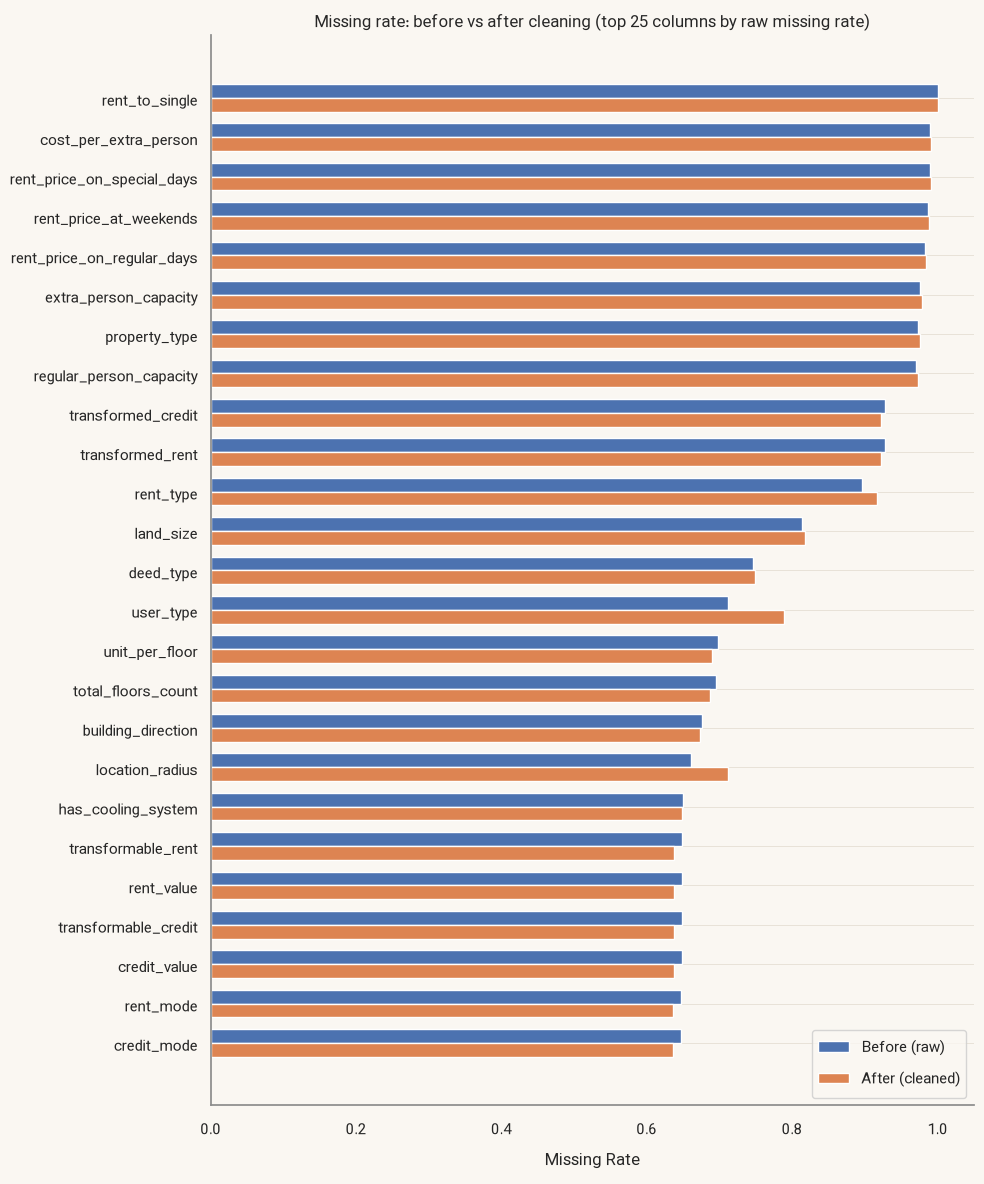

In [722]:
top_missing_cols = missing_comparison.head(25)

fig, ax = plt.subplots(figsize=(10, 12))
y_pos = np.arange(len(top_missing_cols))
bar_height = 0.35

ax.barh(y_pos - bar_height / 2, top_missing_cols["raw_missing_rate"], height=bar_height, label="Before (raw)")
ax.barh(y_pos + bar_height / 2, top_missing_cols["final_missing_rate"], height=bar_height, label="After (cleaned)")
ax.set_yticks(y_pos)
ax.set_yticklabels(top_missing_cols["column"])
ax.invert_yaxis()
ax.set_xlabel("Missing Rate")
ax.set_title("Missing rate: before vs after cleaning (top 25 columns by raw missing rate)")
ax.legend()
plt.tight_layout()
#plt.savefig(FIGURES_DIR / "missing_rate_before_after.png", dpi=150)
plt.show()

In [724]:
raw_numeric_describe_loaded = pd.read_csv(INTERIM_DATA_DIR / "raw_numeric_describe.csv", index_col=0)

logger.info("=== BEFORE (raw price_value, all regimes mixed) ===")
display(raw_numeric_describe_loaded.loc[["price_value", "rent_value", "credit_value", "building_size", "land_size"]])

logger.info("=== AFTER (final, regime-separated) ===")
final_price_area_describe = df_deduplicated.groupby("price_regime", observed=True).agg(
    n=("price_regime", "size"),
    sale_price_median=("sale_price", "median"),
    sale_price_mean=("sale_price", "mean"),
    deposit_amount_median=("deposit_amount", "median"),
    monthly_rent_median=("monthly_rent", "median"),
    building_size_median=("building_size_final", "median"),
    land_size_median=("land_size_final", "median"),
).reset_index()
display(final_price_area_describe)

final_price_area_describe.to_csv(INTERIM_DATA_DIR / "final_price_area_summary_by_regime.csv", index=False)

2026-08-14 00:44:53,356 | INFO | === BEFORE (raw price_value, all regimes mixed) ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price_value,568346.0,1.736537e+10,5.878739e+11,0.0,3400.0,260000000.0,1.400000e+09,2.840000e+09,5.900000e+09,2.100000e+10,8.500000e+10,1.000000e+14
rent_value,351322.0,4.102299e+10,3.807534e+12,0.0,0.0,0.0,1.111110e+05,5.000000e+06,1.200000e+07,5.500000e+07,2.200000e+08,1.000000e+15
credit_value,352095.0,4.872084e+10,4.341346e+12,0.0,1000000.0,15000000.0,1.000000e+08,2.500000e+08,5.000000e+08,1.650000e+09,5.000000e+09,1.000000e+15
building_size,980394.0,4.440648e+03,1.367118e+05,1.0,12.0,37.0,7.500000e+01,1.030000e+02,1.650000e+02,8.500000e+02,1.000000e+04,1.000000e+07
land_size,186396.0,4.165480e+03,1.218927e+05,1.0,40.0,60.0,1.100000e+02,1.950000e+02,2.800000e+02,1.000000e+03,4.320650e+03,1.000000e+07


2026-08-14 00:44:53,394 | INFO | === AFTER (final, regime-separated) ===


,price_regime,n,sale_price_median,sale_price_mean,deposit_amount_median,monthly_rent_median,building_size_median,land_size_median
0,daily_rent,11268,NaN,NaN,NaN,NaN,110.0,NaN
1,daily_rent_no_value,8056,NaN,NaN,NaN,NaN,110.0,NaN
2,deposit_and_rent,213012,NaN,NaN,200000000.0,7000000.0,91.0,140.0
3,full_deposit,45372,NaN,NaN,550000000.0,NaN,95.0,150.0
4,rent_negotiable,312,NaN,NaN,NaN,NaN,170.0,300.0
5,rent_no_deposit,5119,NaN,NaN,NaN,2000000.0,60.0,140.0
6,rent_no_value,89,NaN,NaN,NaN,NaN,150.0,NaN
7,sale,404697,2.950000e+09,1.668423e+10,NaN,NaN,110.0,221.0
8,sale_negotiable,2169,NaN,NaN,NaN,NaN,300.0,300.0
9,sale_no_value,21280,NaN,NaN,NaN,NaN,300.0,360.0


C:\Users\asus\AppData\Local\Temp\ipykernel_21824\3715911158.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(raw_size_data, tick_labels=raw_size_labels, vert=True)
C:\Users\asus\AppData\Local\Temp\ipykernel_21824\3715911158.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(final_size_data, tick_labels=final_size_labels, vert=True)


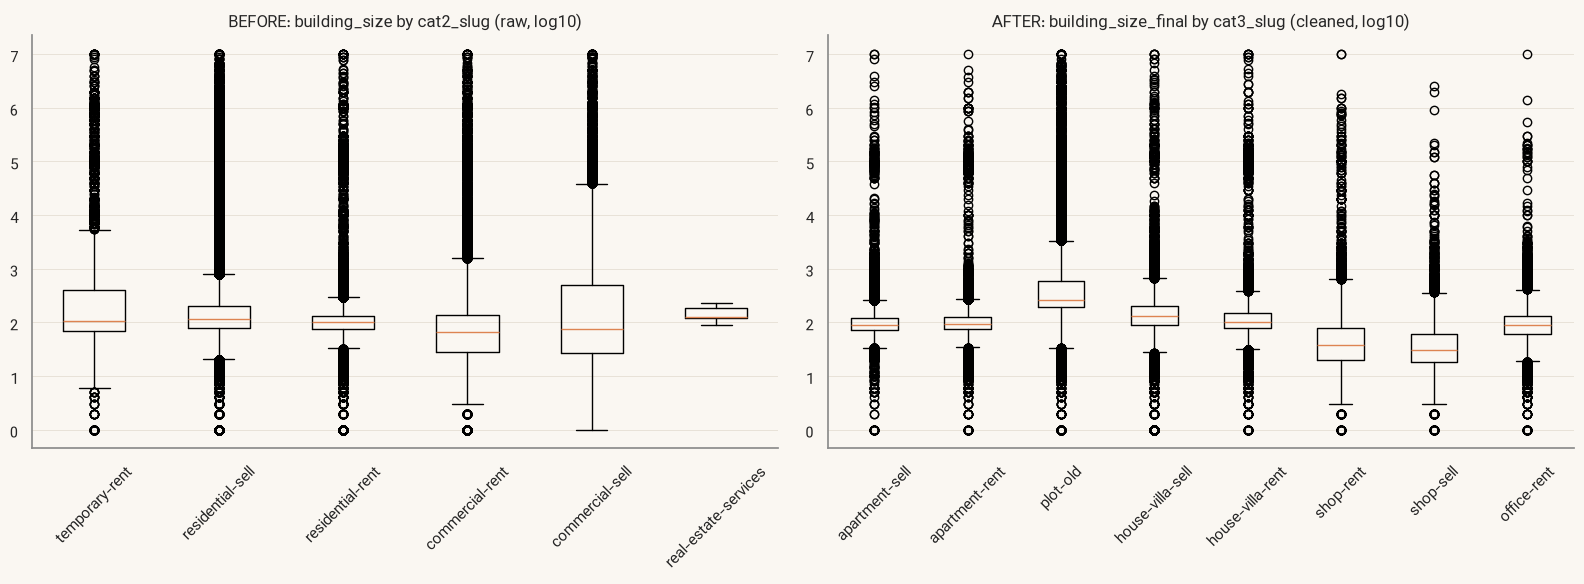

In [730]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

raw_size_data = []
raw_size_labels = []
for cat in df_raw["cat2_slug"].dropna().unique():
    vals = pd.to_numeric(df_raw.loc[df_raw["cat2_slug"] == cat, "building_size"], errors="coerce").dropna()
    vals = vals[vals > 0]
    if len(vals) > 0:
        raw_size_data.append(np.log10(vals))
        raw_size_labels.append(cat)
axes[0].boxplot(raw_size_data, tick_labels=raw_size_labels, vert=True)
axes[0].set_title("BEFORE: building_size by cat2_slug (raw, log10)")
axes[0].tick_params(axis="x", rotation=45)

final_size_data = []
final_size_labels = []
top_property_types = df_deduplicated["cat3_slug"].value_counts().head(8).index
for cat in top_property_types:
    vals = df_deduplicated.loc[df_deduplicated["cat3_slug"] == cat, "building_size_final"].dropna()
    vals = vals[vals > 0]
    if len(vals) > 0:
        final_size_data.append(np.log10(vals))
        final_size_labels.append(cat)
axes[1].boxplot(final_size_data, tick_labels=final_size_labels, vert=True)
axes[1].set_title("AFTER: building_size_final by cat3_slug (cleaned, log10)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
#plt.savefig(FIGURES_DIR / "building_size_boxplot_before_after.png", dpi=150)
plt.show()

In [344]:
def dataframe_profile(frame: pd.DataFrame) -> pd.DataFrame:
    """Generate a profile of DataFrame columns, missingness,
    uniqueness, and memory usage."""
    row_count = len(frame)

    profile = pd.DataFrame({
        "column": frame.columns,
        "dtype": [str(dtype) for dtype in frame.dtypes],
        "missing_count": frame.isna().sum().to_numpy(),
        "unique_count": frame.nunique(dropna=True).to_numpy(),
        "memory_bytes": [
            frame[c].memory_usage(deep=True)
            for c in frame.columns
        ],
    })

    profile["missing_rate"] = (
        profile["missing_count"] / row_count
        if row_count
        else 0
    )

    return profile.sort_values(
        by=["missing_rate", "memory_bytes"],
        ascending=[False, False],
    ).reset_index(drop=True)

In [345]:
clean_profile = dataframe_profile(df_eda)

pd.set_option("display.max_rows", 100)

display(clean_profile)

,column,dtype,missing_count,unique_count,memory_bytes,missing_rate
0,monthly_rent_per_sqm,float64,719871,1147,28508168,0.992939
1,daily_rent_special,float64,718637,207,28508168,0.991237
2,cost_per_extra_person,float64,718576,148,28508168,0.991153
3,rent_price_on_special_days,float64,718527,208,28508168,0.991085
4,daily_rent_weekend,float64,716473,224,28508168,0.988252
5,rent_price_at_weekends,float64,716357,225,28508168,0.988092
6,daily_rent_regular,float64,713816,262,28508168,0.984587
7,rent_price_on_regular_days,float64,713676,263,28508168,0.984394
8,extra_person_capacity_clean,float64,709399,31,28508168,0.978495
9,regular_person_capacity,float64,705673,48,28508168,0.973355


In [346]:
missing_comparison = (
    raw_profile[
        ["column", "missing_count", "missing_rate"]
    ]
    .rename(columns={
        "missing_count": "raw_missing_count",
        "missing_rate": "raw_missing_rate",
    })
    .merge(
        clean_profile[
            ["column", "missing_count", "missing_rate"]
        ].rename(columns={
            "missing_count": "clean_missing_count",
            "missing_rate": "clean_missing_rate",
        }),
        on="column",
        how="outer",
    )
)

missing_comparison["missing_rate_change"] = (
    missing_comparison["clean_missing_rate"]
    - missing_comparison["raw_missing_rate"]
)

display(
    missing_comparison.sort_values(
        "missing_rate_change"
    )
)

,column,raw_missing_count,raw_missing_rate,clean_missing_count,clean_missing_rate,missing_rate_change
66,location_longitude,344392.0,0.344392,227818.0,0.314236,-0.030156
65,location_latitude,344392.0,0.344392,227818.0,0.314236,-0.030156
95,transformable_rent,648752.0,0.648752,461932.0,0.637156,-0.011596
93,transformable_credit,647915.0,0.647915,461510.0,0.636574,-0.011341
7,construction_year,184172.0,0.184172,128015.0,0.176575,-0.007597
...,...,...,...,...,...,...
94,transformable_price,647106.0,0.647106,NaN,NaN,NaN
98,unit_per_floor,697717.0,0.697717,NaN,NaN,NaN
99,unit_per_floor_clean_final,NaN,NaN,499518.0,0.689000,NaN
100,user_type,711118.0,0.711118,NaN,NaN,NaN


In [347]:
display(
    missing_comparison
    .sort_values("missing_rate_change")
    .head(30)
)

,column,raw_missing_count,raw_missing_rate,clean_missing_count,clean_missing_rate,missing_rate_change
66,location_longitude,344392.0,0.344392,227818.0,0.314236,-0.030156
65,location_latitude,344392.0,0.344392,227818.0,0.314236,-0.030156
95,transformable_rent,648752.0,0.648752,461932.0,0.637156,-0.011596
93,transformable_credit,647915.0,0.647915,461510.0,0.636574,-0.011341
7,construction_year,184172.0,0.184172,128015.0,0.176575,-0.007597
97,transformed_rent,927591.0,0.927591,668286.0,0.921787,-0.005804
96,transformed_credit,927591.0,0.927591,668286.0,0.921787,-0.005804
70,neighborhood_slug,562861.0,0.562861,405452.0,0.559252,-0.003609
6,city_slug,2.0,0.000002,0.0,0.000000,-0.000002
5,cat3_slug,1.0,0.000001,0.0,0.000000,-0.000001


In [348]:
numeric_summary = df_eda[FINAL_NUMERIC_COLUMNS].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
).T

numeric_summary["missing_count"] = (
    df_eda[FINAL_NUMERIC_COLUMNS].isna().sum()
)

numeric_summary["missing_rate"] = (
    df_eda[FINAL_NUMERIC_COLUMNS].isna().mean()
)

display(numeric_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_count,missing_rate
building_size_final,715418.0,3.553560e+03,1.233911e+05,1.000000,1.300000e+01,3.800000e+01,7.500000e+01,1.000000e+02,1.600000e+02,7.011500e+02,7.500000e+03,1.000000e+07,9572,0.013203
construction_year_clean_final,596975.0,1.393771e+03,8.314498e+00,1369.000000,1.369000e+03,1.377000e+03,1.390000e+03,1.395000e+03,1.401000e+03,1.403000e+03,1.403000e+03,1.403000e+03,128015,0.176575
rooms_count_clean_final,616378.0,1.855503e+00,9.748635e-01,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,5.000000e+00,108612,0.149812
total_floors_count_clean_final,259419.0,4.761282e+00,3.196014e+00,2.000000,2.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,1.000000e+01,2.000000e+01,3.100000e+01,465571,0.642176
unit_per_floor_clean_final,225472.0,2.265878e+00,1.438494e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,8.000000e+00,9.000000e+00,499518,0.689000
land_size_final,226091.0,6.376913e+03,1.580462e+05,1.000000,4.000000e+01,6.500000e+01,1.320000e+02,2.030000e+02,3.500000e+02,2.000000e+03,2.000000e+04,1.000000e+07,498899,0.688146
sale_price,404697.0,1.668423e+10,5.263176e+11,1000000.000000,9.000000e+07,4.500000e+08,1.500000e+09,2.950000e+09,6.000000e+09,2.100000e+10,7.000000e+10,9.000000e+13,320293,0.441790
deposit_amount,258384.0,1.048216e+10,1.650834e+12,1000000.000000,1.000000e+07,3.500000e+07,1.000000e+08,2.500000e+08,5.000000e+08,1.600000e+09,5.000000e+09,5.000000e+14,466606,0.643603
monthly_rent,218131.0,1.753074e+10,2.251521e+12,1.000000,1.000000e+05,1.000000e+05,3.000000e+06,7.000000e+06,1.500000e+07,6.000000e+07,2.300000e+08,8.888889e+14,506859,0.699126
daily_rent_regular,11174.0,1.176025e+11,7.150767e+12,50000.000000,1.500000e+05,3.000000e+05,5.500000e+05,1.000000e+06,2.000000e+06,3.500000e+06,1.000000e+07,5.006007e+14,713816,0.984587


In [349]:
categorical_summary = pd.DataFrame({
    "column": FINAL_CATEGORICAL_COLUMNS,
    "missing_count": [
        df_eda[c].isna().sum()
        for c in FINAL_CATEGORICAL_COLUMNS
    ],
    "missing_rate": [
        df_eda[c].isna().mean()
        for c in FINAL_CATEGORICAL_COLUMNS
    ],
    "unique_count": [
        df_eda[c].nunique(dropna=True)
        for c in FINAL_CATEGORICAL_COLUMNS
    ],
})

display(
    categorical_summary.sort_values(
        "unique_count",
        ascending=False,
    )
)

,column,missing_count,missing_rate,unique_count
3,neighborhood_slug,405452,0.559252,1187
2,city_slug,0,0.000000,421
8,construction_year,128015,0.176575,34
1,cat3_slug,0,0.000000,16
10,has_heating_system_final,446899,0.616421,7
14,floor_material_final,389855,0.537738,7
0,cat2_slug,0,0.000000,6
4,created_at_month,0,0.000000,6
15,property_type_final,700842,0.966692,5
11,has_cooling_system_final,460113,0.634647,5


In [350]:
PLOT_CATEGORICAL_COLUMNS = [
    c
    for c in FINAL_CATEGORICAL_COLUMNS
    if df_eda[c].nunique(dropna=True) <= 30
]

logger.info(
    "Categorical columns selected for distribution plots: %d",
    len(PLOT_CATEGORICAL_COLUMNS),
)

2026-08-14 00:19:57,889 | INFO | Categorical columns selected for distribution plots: 16


2026-08-14 00:19:58,671 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 00:19:58,676 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


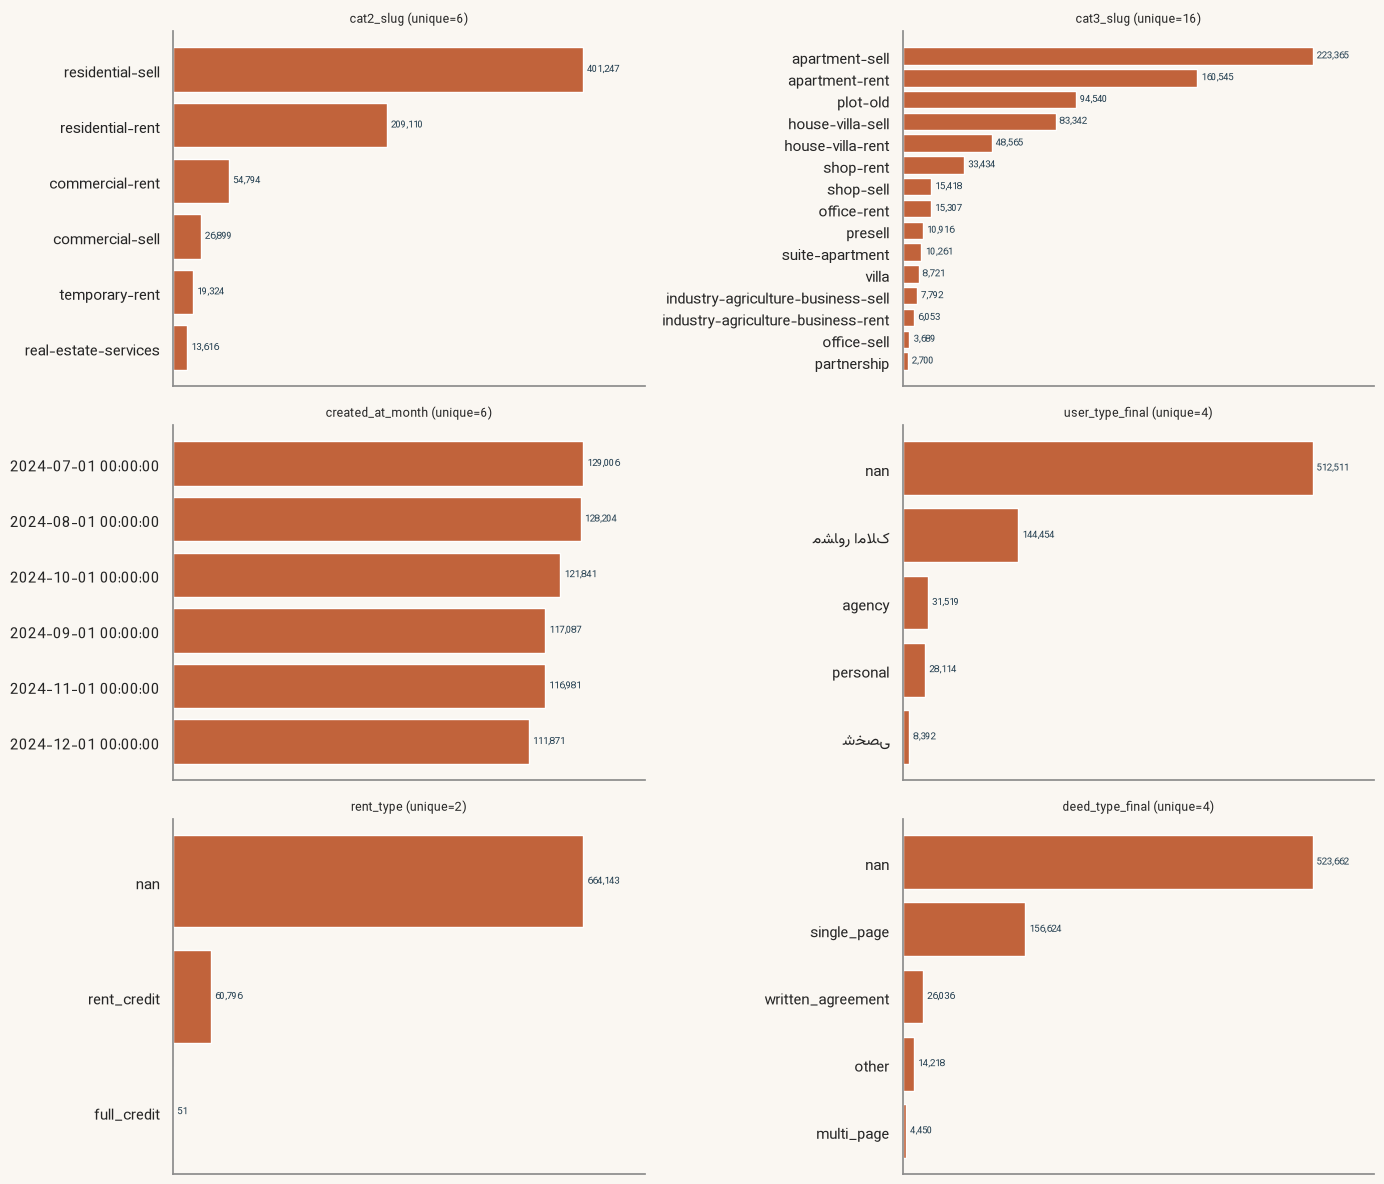

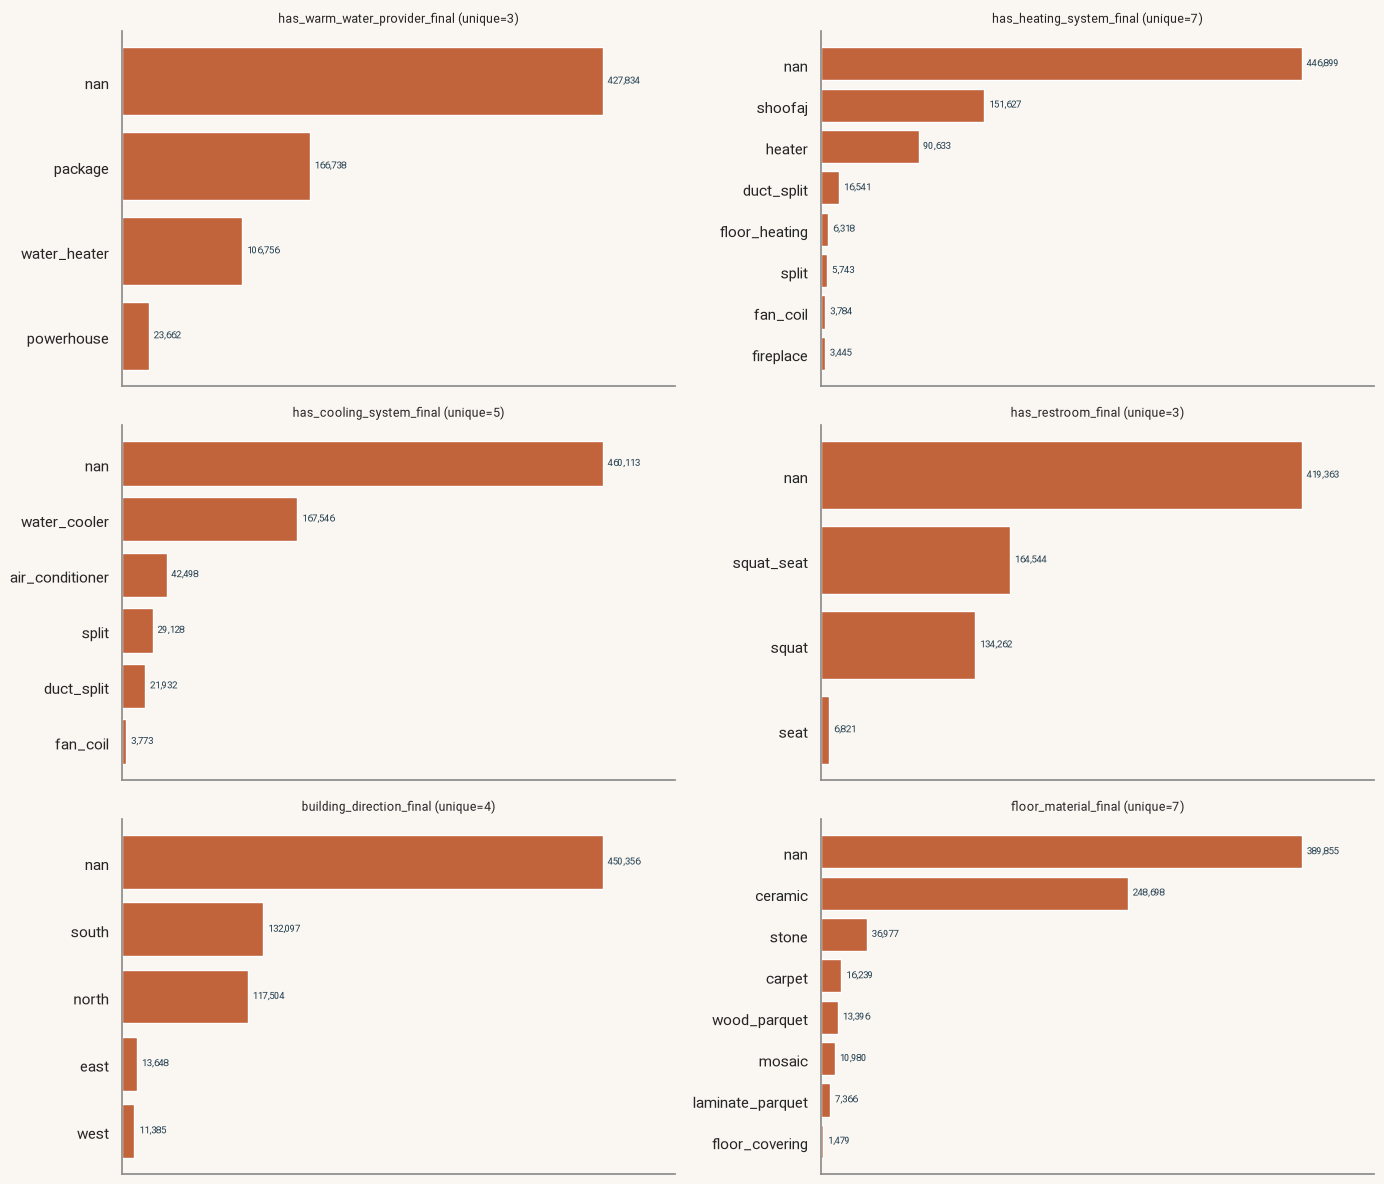

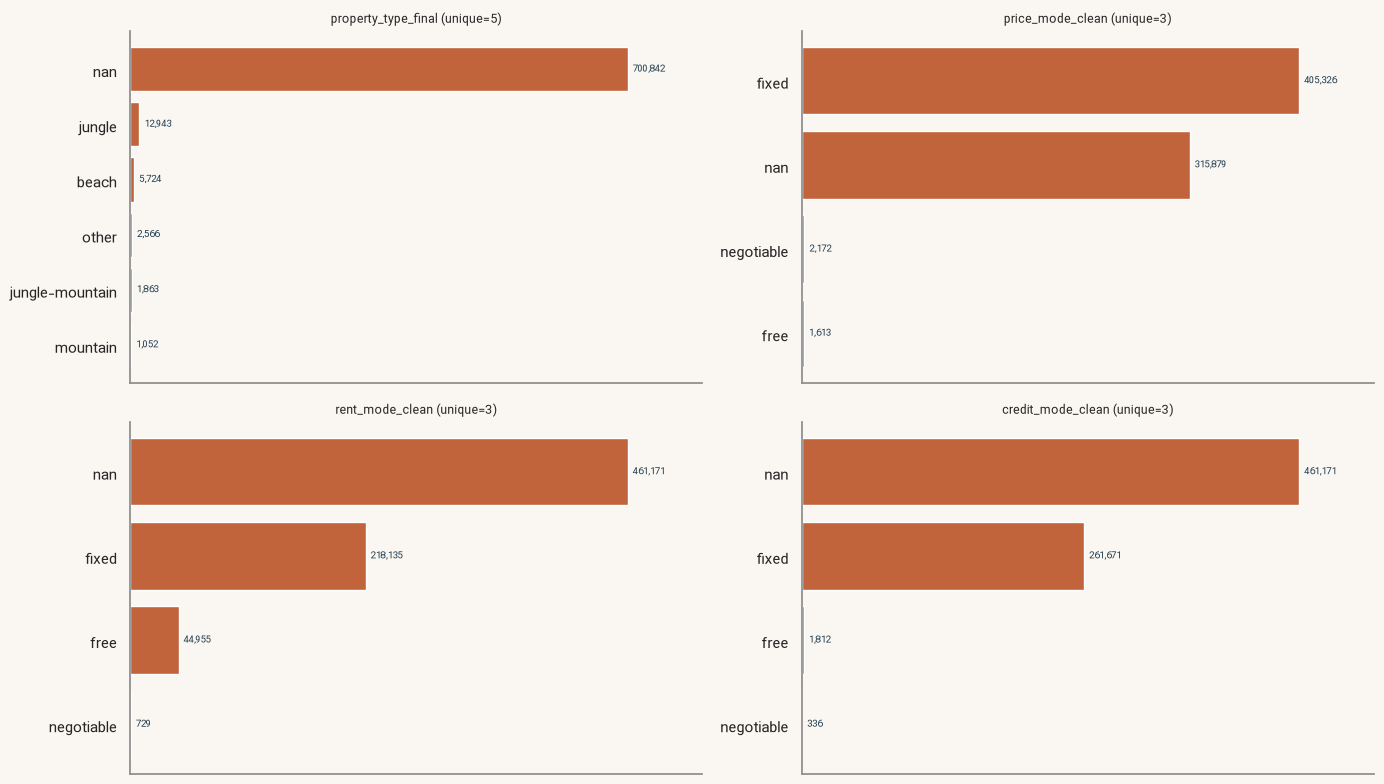

In [351]:
def plot_categorical_batch_clean(
    columns: list[str],
    batch_size: int = 6,
    prefix: str = "clean_cat",
) -> None:
    """Plot categorical value distributions (post-cleaning) in batches and
    save each batch as a figure.

    Args:
        columns: Column names to plot.
        batch_size: Number of columns per figure.
        prefix: Filename prefix for saved figures.
    """
    n_batches = -(-len(columns) // batch_size)
    for b in range(n_batches):
        batch_cols = columns[b * batch_size:(b + 1) * batch_size]
        n_rows = -(-len(batch_cols) // 2)
        fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 4))
        axes = np.asarray(axes).reshape(-1)

        for ax, col in zip(axes, batch_cols):
            vc = df_eda[col].value_counts(dropna=False).head(15)
            labels = [format_tick_label(str(v)) for v in vc.index]

            bars = ax.barh(labels, vc.values, color="#C1633B")
            ax.invert_yaxis()
            ax.set_title(f"{col} (unique={df_eda[col].nunique(dropna=True)})", fontsize=9)
            ax.grid(False)

            ax.set_xlim(0, vc.values.max() * 1.15)
            ax.set_xticks([])  

            for bar, value in zip(bars, vc.values):
                ax.text(
                    bar.get_width() + vc.values.max() * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f"{value:,}",
                    va="center",
                    ha="left",
                    fontsize=7,
                    color="#1F3B4D",
                )

        for ax in axes[len(batch_cols):]:
            ax.axis("off")

        plt.tight_layout()
        plt.savefig(FIGURES_CLEANED_DIR / f"{prefix}_batch_{b + 1}.png", dpi=150)
        plt.show()


plot_categorical_batch_clean(PLOT_CATEGORICAL_COLUMNS, batch_size=6)

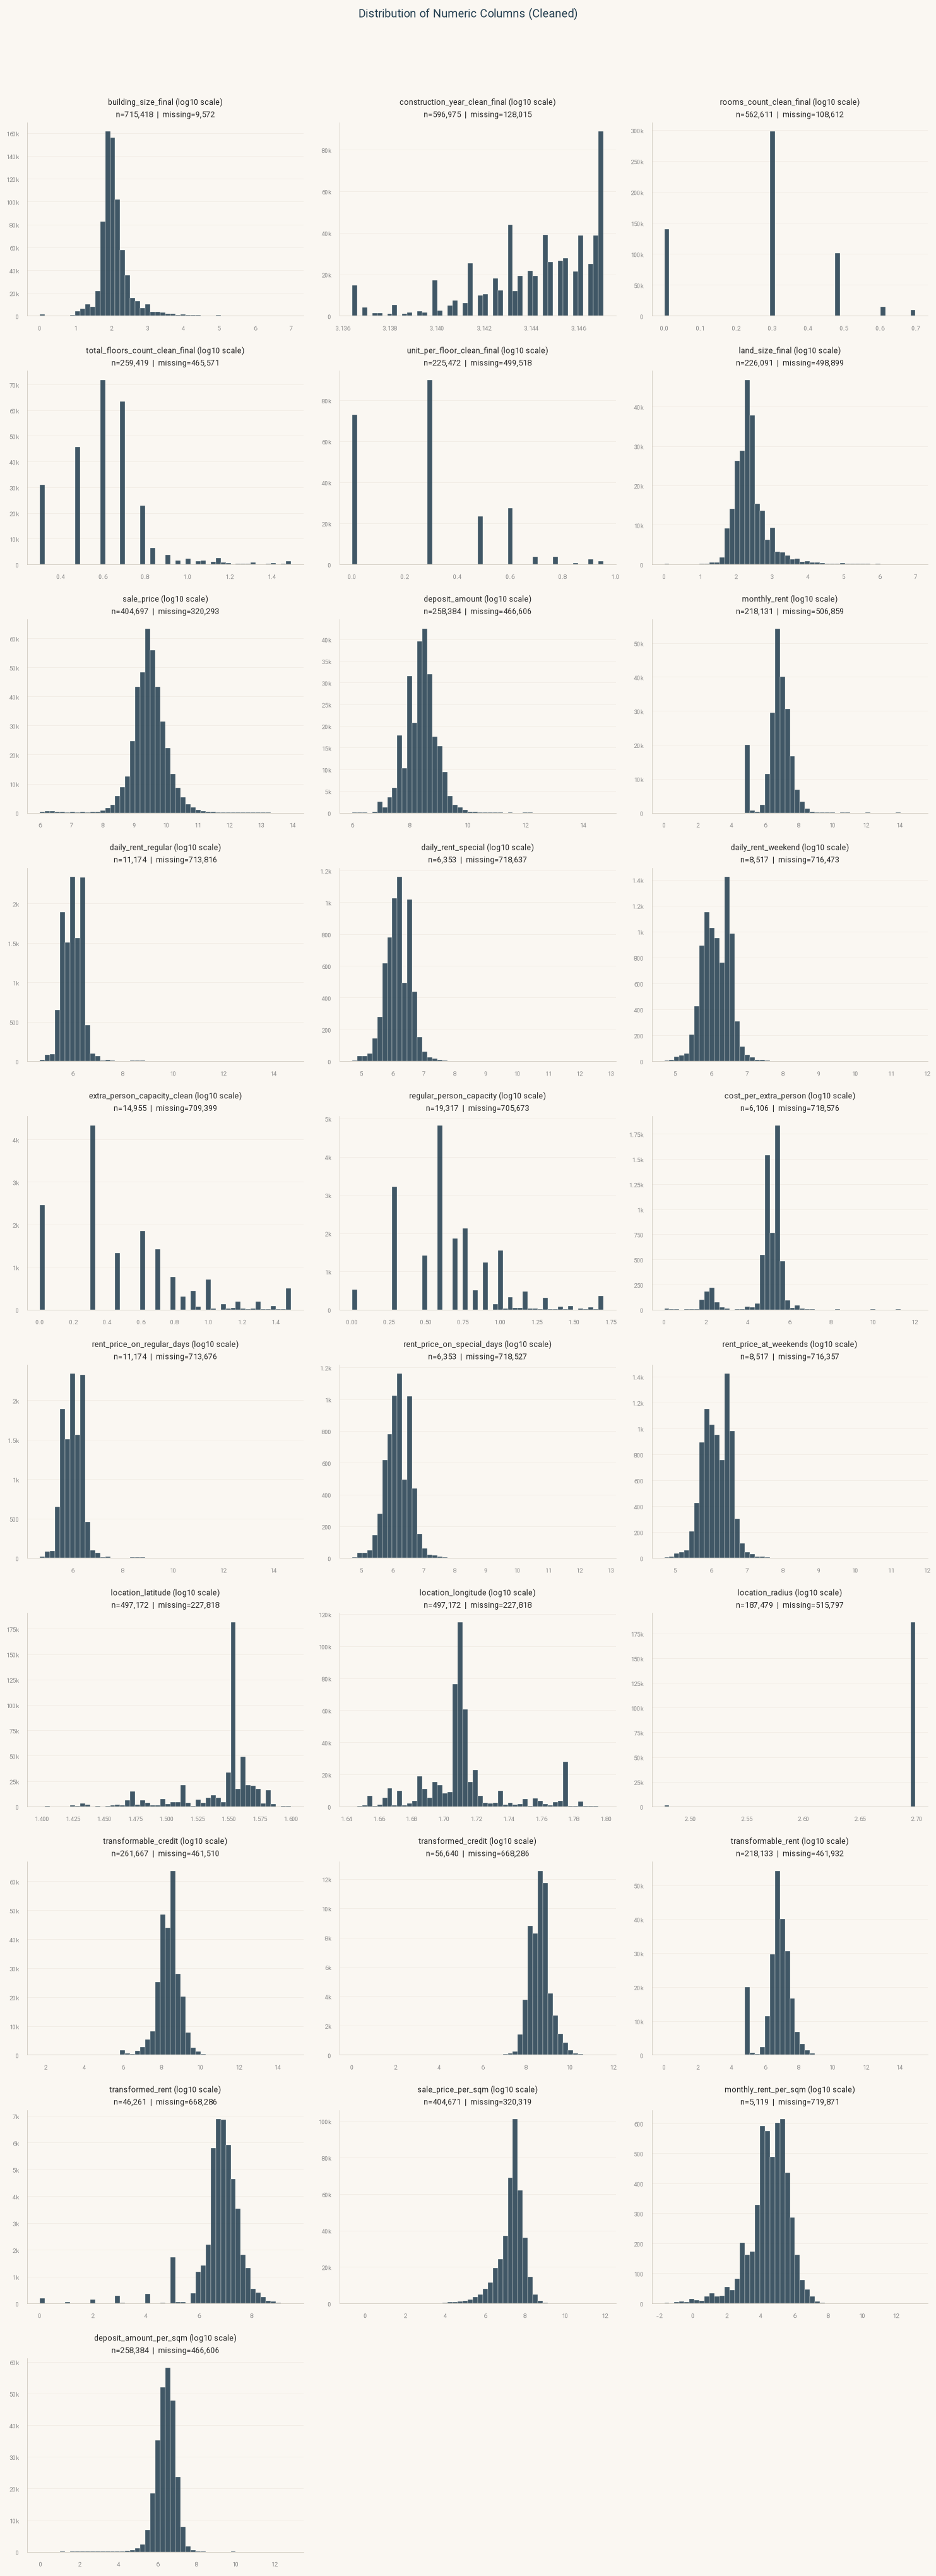

In [352]:
n_cols = 3
n_rows = -(-len(FINAL_NUMERIC_COLUMNS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = np.asarray(axes).flatten()

for ax, col in zip(axes, FINAL_NUMERIC_COLUMNS):
    data = df_eda[col].dropna()
    data_positive = data[data > 0]

    if len(data_positive) > 0:
        ax.hist(np.log10(data_positive), bins=50, color="#1F3B4D", alpha=0.85, edgecolor="#FAF7F2", linewidth=0.3)
        ax.set_title(
            f"{col} (log10 scale)\nn={len(data_positive):,}  |  missing={df_eda[col].isna().sum():,}",
            fontsize=9,
        )
    else:
        ax.set_title(f"{col}\n(no positive values)", fontsize=9, color="#8C8C8C")

    ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
    ax.tick_params(axis="both", labelsize=7, colors="#8C8C8C")

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("#C9C2B6")

    ax.grid(True, axis="y", color="#EFEAE1", linewidth=0.5)

for ax in axes[len(FINAL_NUMERIC_COLUMNS):]:
    ax.axis("off")

fig.suptitle("Distribution of Numeric Columns (Cleaned)", fontsize=13, color="#1F3B4D", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "clean_numeric_histograms_log.png", dpi=150)
plt.show()

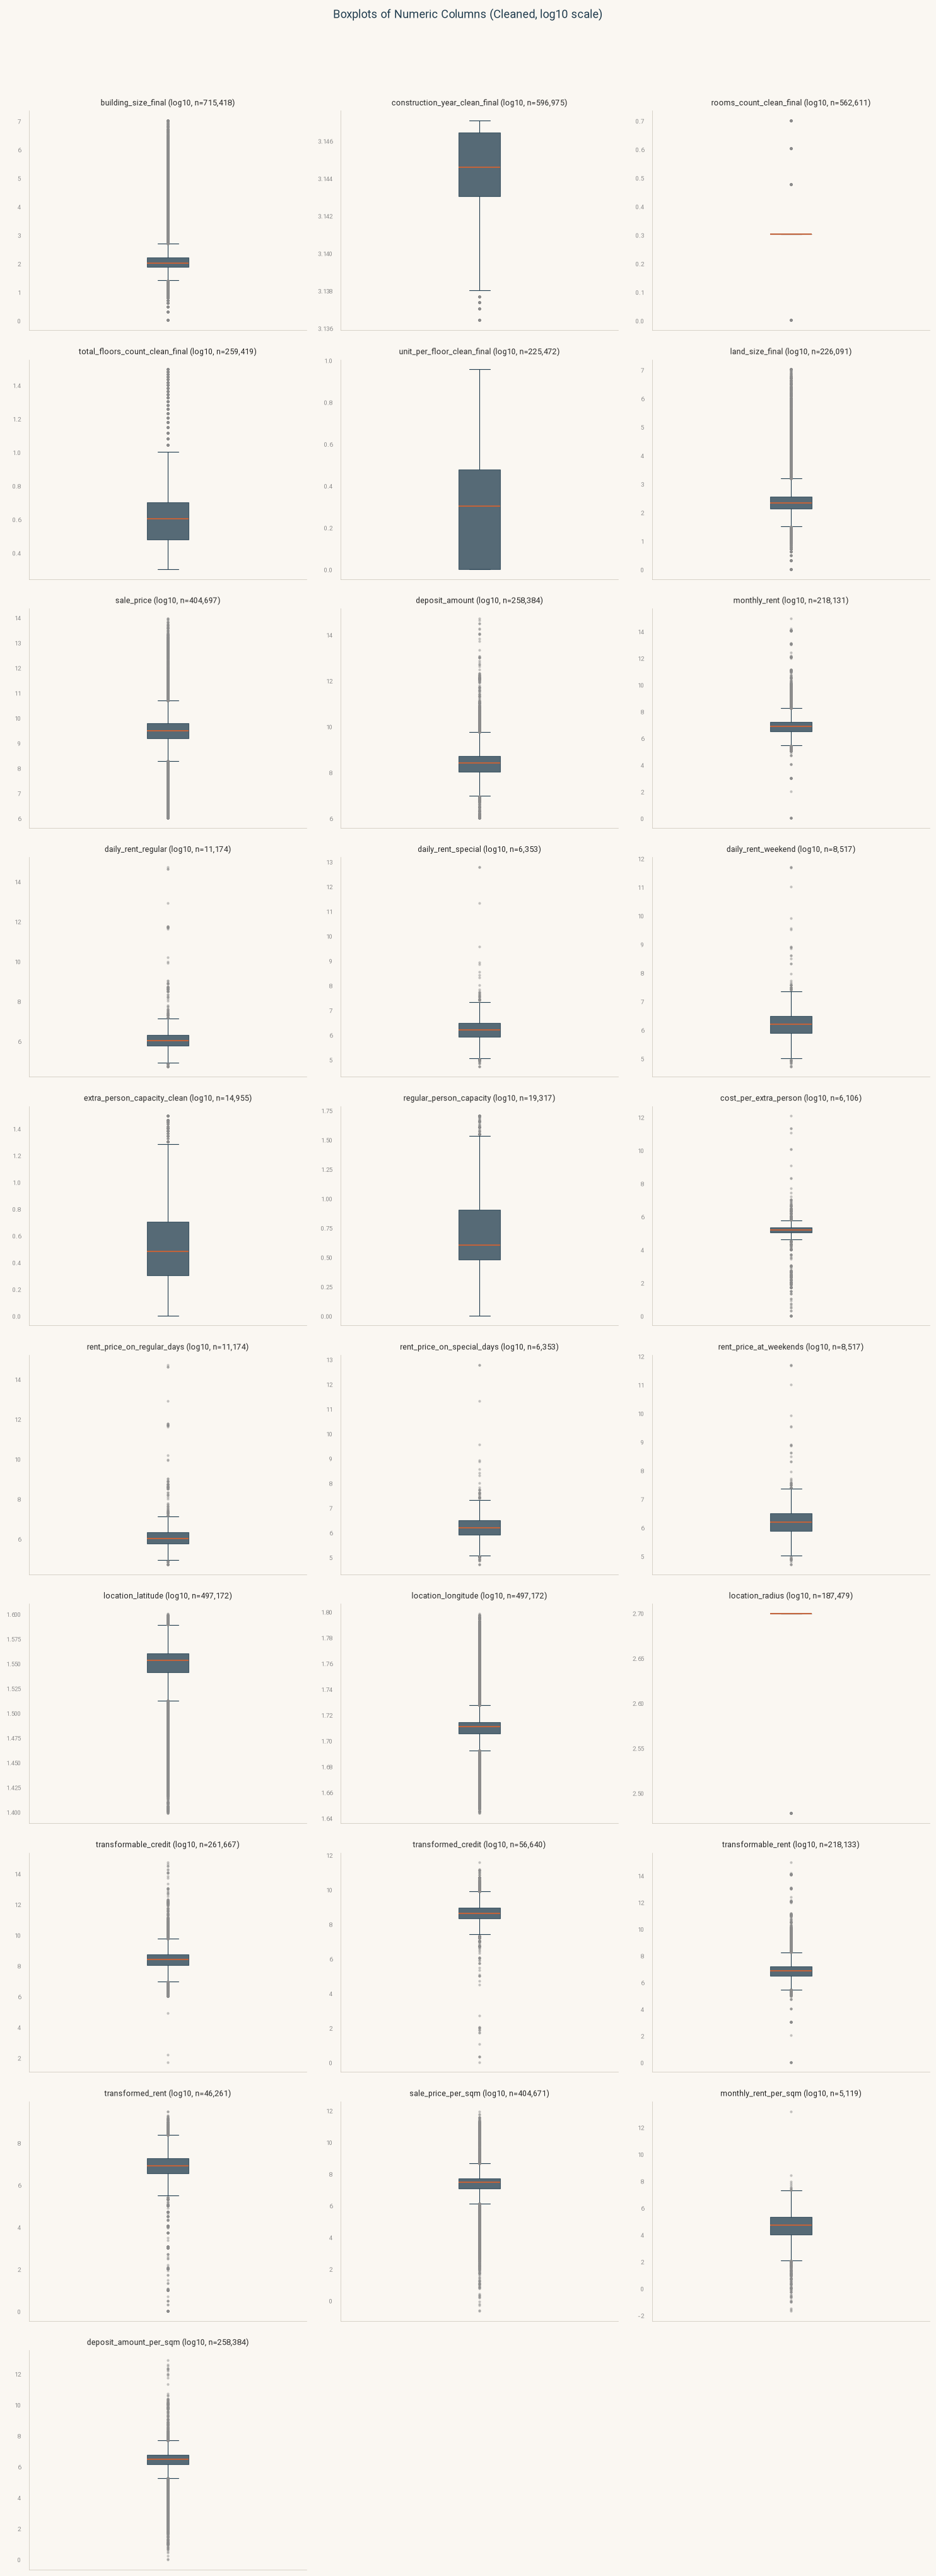

In [353]:
n_cols = 3
n_rows = -(-len(FINAL_NUMERIC_COLUMNS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = np.asarray(axes).flatten()

boxprops = dict(facecolor="#1F3B4D", alpha=0.75, edgecolor="#1F3B4D", linewidth=0.8)
medianprops = dict(color="#C1633B", linewidth=1.5)
whiskerprops = dict(color="#1F3B4D", linewidth=0.8)
capprops = dict(color="#1F3B4D", linewidth=0.8)
flierprops = dict(marker="o", markersize=3, markerfacecolor="#8C8C8C", markeredgecolor="none", alpha=0.5)

for ax, col in zip(axes, FINAL_NUMERIC_COLUMNS):
    data = df_eda[col].dropna()
    data_positive = data[data > 0]

    if len(data_positive) > 0:
        ax.boxplot(
            np.log10(data_positive),
            orientation="vertical",
            patch_artist=True,
            boxprops=boxprops,
            medianprops=medianprops,
            whiskerprops=whiskerprops,
            capprops=capprops,
            flierprops=flierprops,
        )
        ax.set_title(f"{col} (log10, n={len(data_positive):,})", fontsize=9)
    else:
        ax.set_title(f"{col}\n(no positive values)", fontsize=9, color="#8C8C8C")

    ax.grid(False)
    ax.set_xticks([])

    ax.tick_params(axis="y", labelsize=7, colors="#8C8C8C")
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("#C9C2B6")

for ax in axes[len(FINAL_NUMERIC_COLUMNS):]:
    ax.axis("off")

fig.suptitle("Boxplots of Numeric Columns (Cleaned, log10 scale)", fontsize=13, color="#1F3B4D", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "clean_numeric_boxplots_log.png", dpi=150)
plt.show()

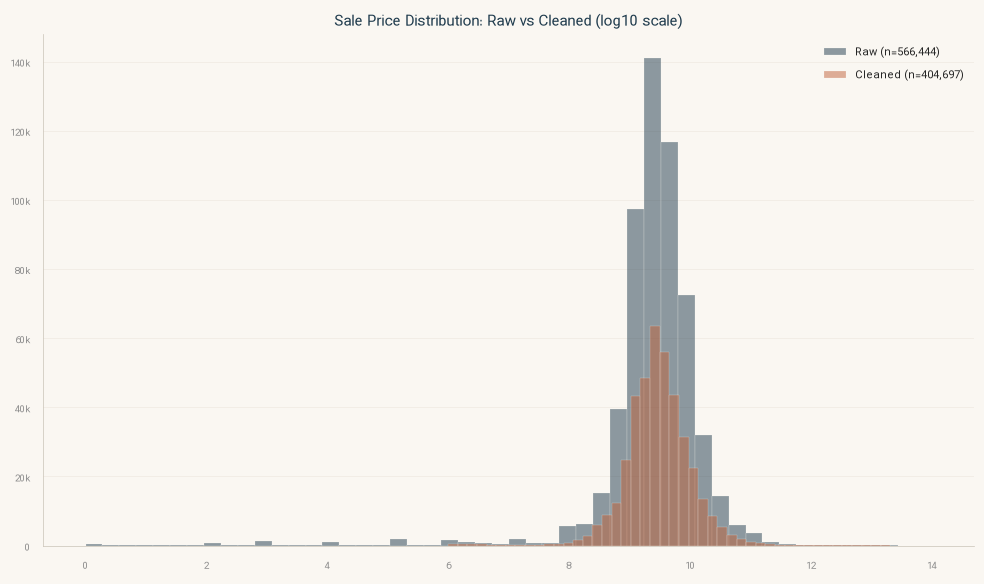

In [354]:
fig, ax = plt.subplots(figsize=(10, 6))

raw_sale = df_raw["price_value"].dropna()
raw_sale = raw_sale[raw_sale > 0]
clean_sale = df_eda["sale_price"].dropna()
clean_sale = clean_sale[clean_sale > 0]

ax.hist(
    np.log10(raw_sale),
    bins=50,
    alpha=0.5,
    color="#1F3B4D",
    edgecolor="#FAF7F2",
    linewidth=0.3,
    label=f"Raw (n={len(raw_sale):,})",
)
ax.hist(
    np.log10(clean_sale),
    bins=50,
    alpha=0.5,
    color="#C1633B",
    edgecolor="#FAF7F2",
    linewidth=0.3,
    label=f"Cleaned (n={len(clean_sale):,})",
)

ax.set_title("Sale Price Distribution: Raw vs Cleaned (log10 scale)", fontsize=11, color="#1F3B4D")

ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
ax.tick_params(axis="both", labelsize=7, colors="#8C8C8C")

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

ax.grid(True, axis="y", color="#EFEAE1", linewidth=0.5)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "sale_price_raw_vs_clean.png", dpi=150)
plt.show()

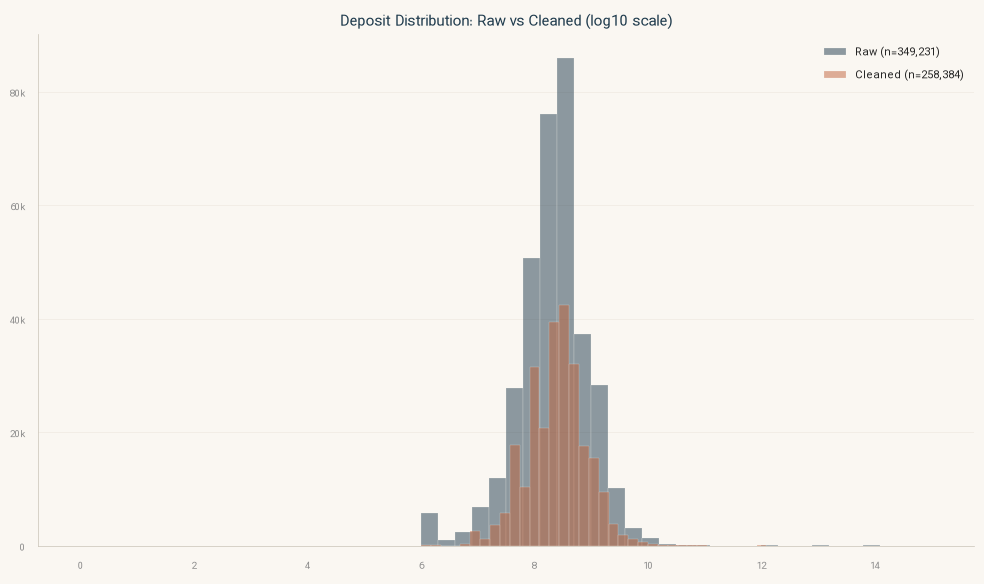

In [355]:
fig, ax = plt.subplots(figsize=(10, 6))

raw_deposit = df_raw["credit_value"].dropna()
raw_deposit = raw_deposit[raw_deposit > 0]
clean_deposit = df_eda["deposit_amount"].dropna()
clean_deposit = clean_deposit[clean_deposit > 0]

ax.hist(
    np.log10(raw_deposit),
    bins=50,
    alpha=0.5,
    color="#1F3B4D",
    edgecolor="#FAF7F2",
    linewidth=0.3,
    label=f"Raw (n={len(raw_deposit):,})",
)
ax.hist(
    np.log10(clean_deposit),
    bins=50,
    alpha=0.5,
    color="#C1633B",
    edgecolor="#FAF7F2",
    linewidth=0.3,
    label=f"Cleaned (n={len(clean_deposit):,})",
)

ax.set_title("Deposit Distribution: Raw vs Cleaned (log10 scale)", fontsize=11, color="#1F3B4D")

ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
ax.tick_params(axis="both", labelsize=7, colors="#8C8C8C")

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

ax.grid(True, axis="y", color="#EFEAE1", linewidth=0.5)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "deposit_raw_vs_clean.png", dpi=150)
plt.show()

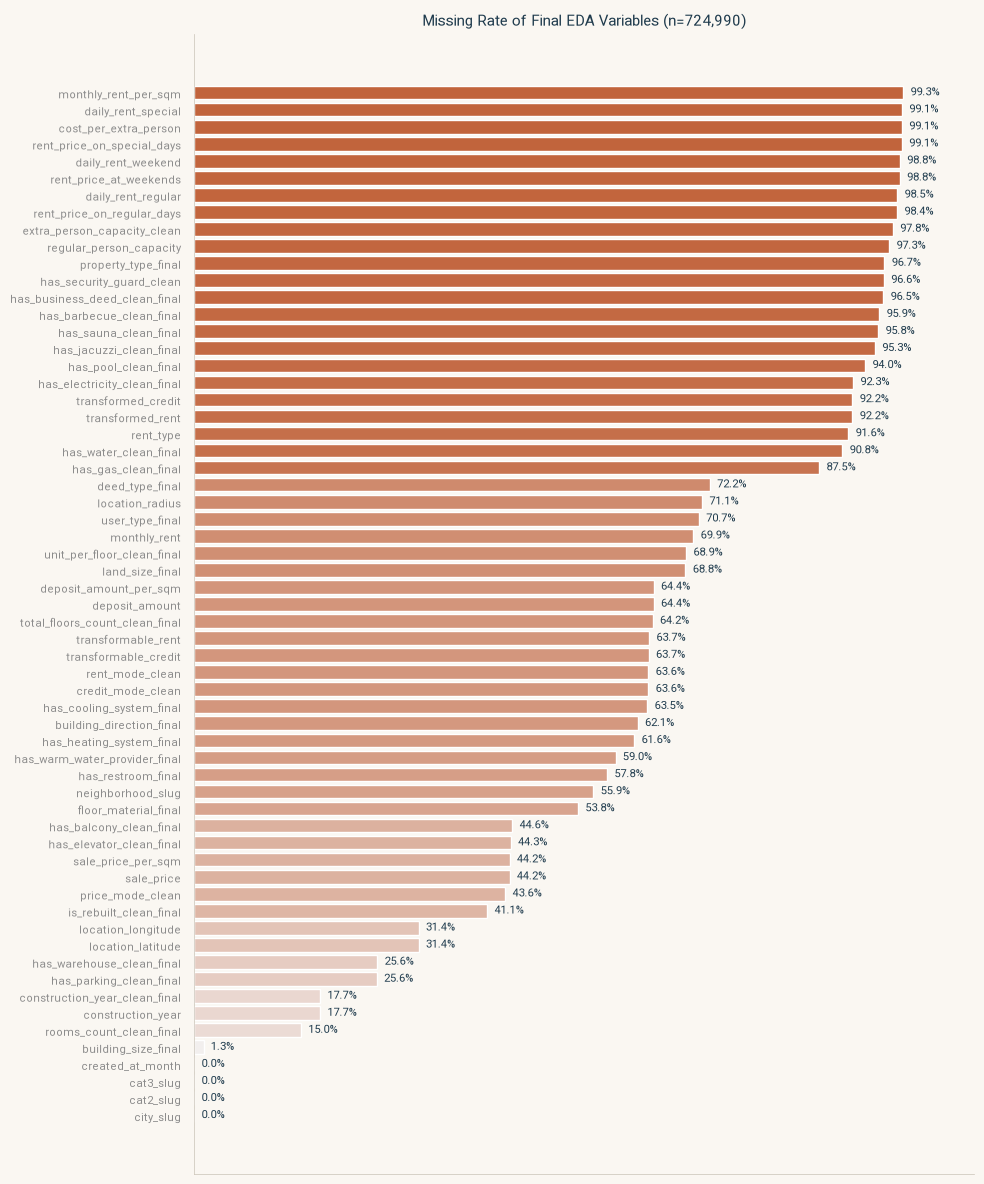

In [356]:
missing_rate_cmap = HOUSING_PALETTE_SEQUENTIAL
missing_matrix = df_eda.isna().mean().sort_values(ascending=False)
bar_colors = missing_rate_cmap(missing_matrix.values)

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(missing_matrix.index, missing_matrix.values, color=bar_colors)
ax.invert_yaxis()

ax.set_title(f"Missing Rate of Final EDA Variables (n={len(df_eda):,})", fontsize=11, color="#1F3B4D")

ax.grid(False)
ax.set_xlim(0, missing_matrix.max() * 1.1)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=8, colors="#8C8C8C")

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

for i, value in enumerate(missing_matrix.values):
    ax.text(
        value + missing_matrix.max() * 0.01,
        i,
        f"{value:.1%}",
        va="center",
        fontsize=8,
        color="#1F3B4D",
    )

plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "clean_missing_rate_final_variables.png", dpi=150)
plt.show()

In [357]:
CORRELATION_COLUMNS = [
    "building_size_final",
    "land_size_final",
    "rooms_count_clean_final",
    "total_floors_count_clean_final",
    "unit_per_floor_clean_final",
    "sale_price",
    "deposit_amount",
    "monthly_rent",
    "sale_price_per_sqm",
    "deposit_amount_per_sqm",
    "monthly_rent_per_sqm",
    "regular_person_capacity",
    "extra_person_capacity_clean",
    "cost_per_extra_person",
]

corr = df_eda[
    CORRELATION_COLUMNS
].corr(method="spearman")

display(corr)

,building_size_final,land_size_final,rooms_count_clean_final,total_floors_count_clean_final,unit_per_floor_clean_final,sale_price,deposit_amount,monthly_rent,sale_price_per_sqm,deposit_amount_per_sqm,monthly_rent_per_sqm,regular_person_capacity,extra_person_capacity_clean,cost_per_extra_person
building_size_final,1.000000,0.731789,0.658953,0.146658,-0.188208,0.216299,0.452387,0.270788,-0.294096,-0.022745,-0.623080,0.517889,0.455457,0.153178
land_size_final,0.731789,1.000000,0.409354,0.091673,-0.084632,0.199487,0.393387,0.327845,-0.413229,0.071894,-0.301668,NaN,NaN,NaN
rooms_count_clean_final,0.658953,0.409354,1.000000,0.199272,-0.119830,0.440357,0.483710,0.138451,0.102876,0.170858,-0.189069,0.470590,0.367809,0.185675
total_floors_count_clean_final,0.146658,0.091673,0.199272,1.000000,0.304383,0.248683,0.370499,0.194122,0.217066,0.344720,0.063963,NaN,NaN,NaN
unit_per_floor_clean_final,-0.188208,-0.084632,-0.119830,0.304383,1.000000,-0.200837,-0.006340,-0.044433,-0.145741,0.060272,0.000984,NaN,NaN,NaN
sale_price,0.216299,0.199487,0.440357,0.248683,-0.200837,1.000000,NaN,NaN,0.750925,NaN,NaN,NaN,NaN,NaN
deposit_amount,0.452387,0.393387,0.483710,0.370499,-0.006340,NaN,1.000000,0.185389,NaN,0.837784,NaN,NaN,NaN,NaN
monthly_rent,0.270788,0.327845,0.138451,0.194122,-0.044433,NaN,0.185389,1.000000,NaN,0.051349,0.719856,NaN,NaN,NaN
sale_price_per_sqm,-0.294096,-0.413229,0.102876,0.217066,-0.145741,0.750925,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
deposit_amount_per_sqm,-0.022745,0.071894,0.170858,0.344720,0.060272,NaN,0.837784,0.051349,NaN,1.000000,NaN,NaN,NaN,NaN


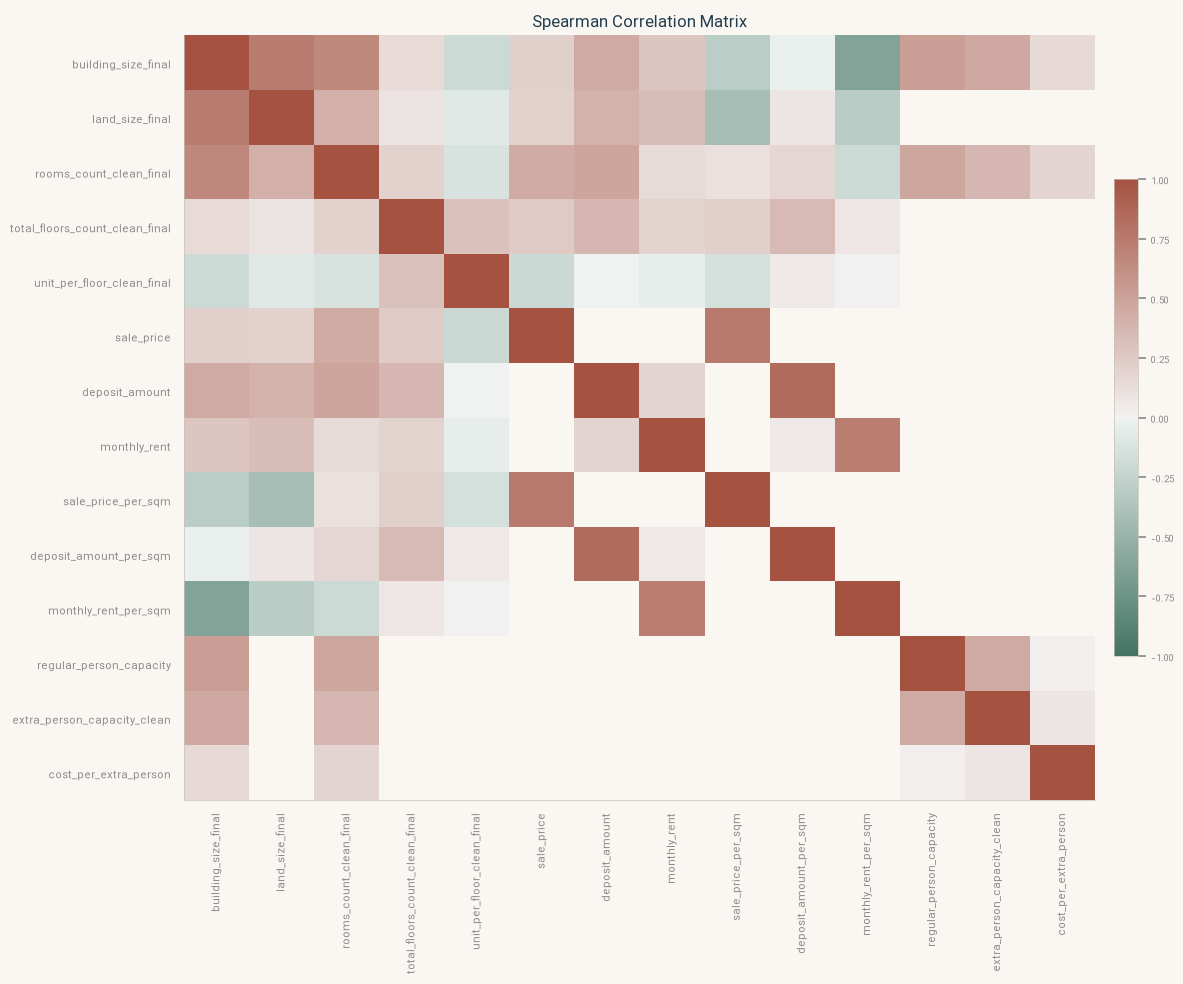

In [358]:
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr, aspect="auto", cmap=HOUSING_PALETTE_DIVERGING, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8, color="#8C8C8C")
ax.set_yticklabels(corr.columns, fontsize=8, color="#8C8C8C")

ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.outline.set_linewidth(0.5)
cbar.outline.set_edgecolor("#C9C2B6")
cbar.ax.tick_params(labelsize=7, colors="#8C8C8C")

ax.set_title("Spearman Correlation Matrix", fontsize=12, color="#1F3B4D")
plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "clean_spearman_correlation_heatmap.png", dpi=150)
plt.show()

In [359]:
sale_size = df_eda[
    [
        "building_size_final",
        "sale_price",
    ]
].dropna()

sale_size = sale_size[
    (sale_size["building_size_final"] > 0)
    & (sale_size["sale_price"] > 0)
]

sale_size["log_size"] = np.log10(
    sale_size["building_size_final"]
)

sale_size["log_price"] = np.log10(
    sale_size["sale_price"]
)

display(
    sale_size[
        ["log_size", "log_price"]
    ].corr(method="spearman")
)

,log_size,log_price
log_size,1.000000,0.216299
log_price,0.216299,1.000000


In [360]:
boolean_cols = [
    c for c in FINAL_BOOLEAN_COLUMNS
    if c in df_deduplicated.columns
]

boolean_summary = pd.DataFrame({
    "true": [
        df_deduplicated[c].eq(True).sum()
        for c in boolean_cols
    ],
    "false": [
        df_deduplicated[c].eq(False).sum()
        for c in boolean_cols
    ],
    "missing": [
        df_deduplicated[c].isna().sum()
        for c in boolean_cols
    ],
}, index=boolean_cols)

display(boolean_summary)

,true,false,missing
has_balcony_clean_final,333641,68308,323041
has_elevator_clean_final,272576,130917,321497
has_parking_clean_final,409912,129755,185323
has_warehouse_clean_final,431873,107207,185910
is_rebuilt_clean_final,137678,289678,297634
has_water_clean_final,52290,14629,658071
has_gas_clean_final,75347,15001,634642
has_electricity_clean_final,41341,14687,668962
has_sauna_clean_final,8041,22425,694524
has_jacuzzi_clean_final,11893,21924,691173


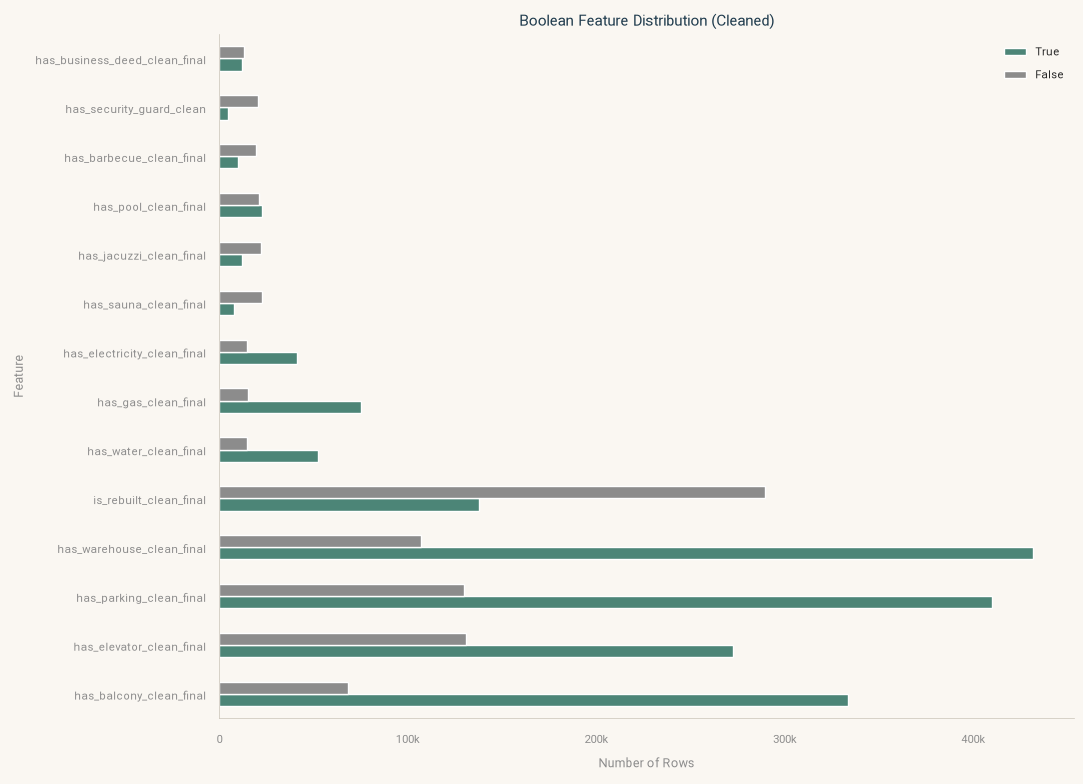

In [361]:
plot_data = boolean_summary[["true", "false"]]

fig, ax = plt.subplots(figsize=(11, 8))
plot_data.plot(
    kind="barh",
    ax=ax,
    color=["#4C8577", "#8C8C8C"],
)

ax.set_title("Boolean Feature Distribution (Cleaned)", fontsize=11, color="#1F3B4D")
ax.set_xlabel("Number of Rows", fontsize=9, color="#8C8C8C")
ax.set_ylabel("Feature", fontsize=9, color="#8C8C8C")

ax.xaxis.set_major_formatter(FuncFormatter(format_thousands))
ax.tick_params(axis="both", labelsize=8, colors="#8C8C8C")

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

ax.grid(False)
ax.legend(["True", "False"], fontsize=8, frameon=False, title=None)

plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "clean_boolean_feature_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

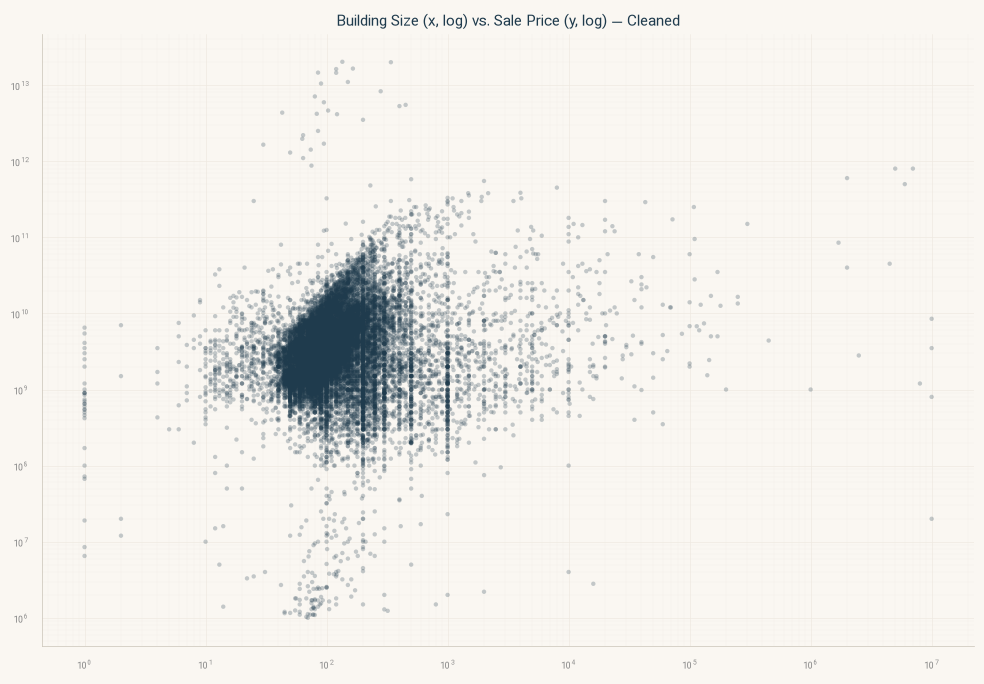

In [362]:
plot_data = df_deduplicated[
    df_deduplicated["building_size_final"].notna()
    & df_deduplicated["sale_price"].notna()
    & (df_deduplicated["building_size_final"] > 0)
    & (df_deduplicated["sale_price"] > 0)
].copy()
plot_data = plot_data.sample(min(20_000, len(plot_data)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    plot_data["building_size_final"],
    plot_data["sale_price"],
    alpha=0.25,
    s=10,
    color="#1F3B4D",
    edgecolors="none",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Building Size (x, log) vs. Sale Price (y, log) — Cleaned", fontsize=11, color="#1F3B4D")

ax.tick_params(axis="both", which="both", labelsize=7, colors="#8C8C8C")

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

ax.grid(True, which="major", color="#EFEAE1", linewidth=0.5)
ax.grid(True, which="minor", color="#EFEAE1", linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "clean_building_size_vs_sale_price.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_21824\1602583458.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


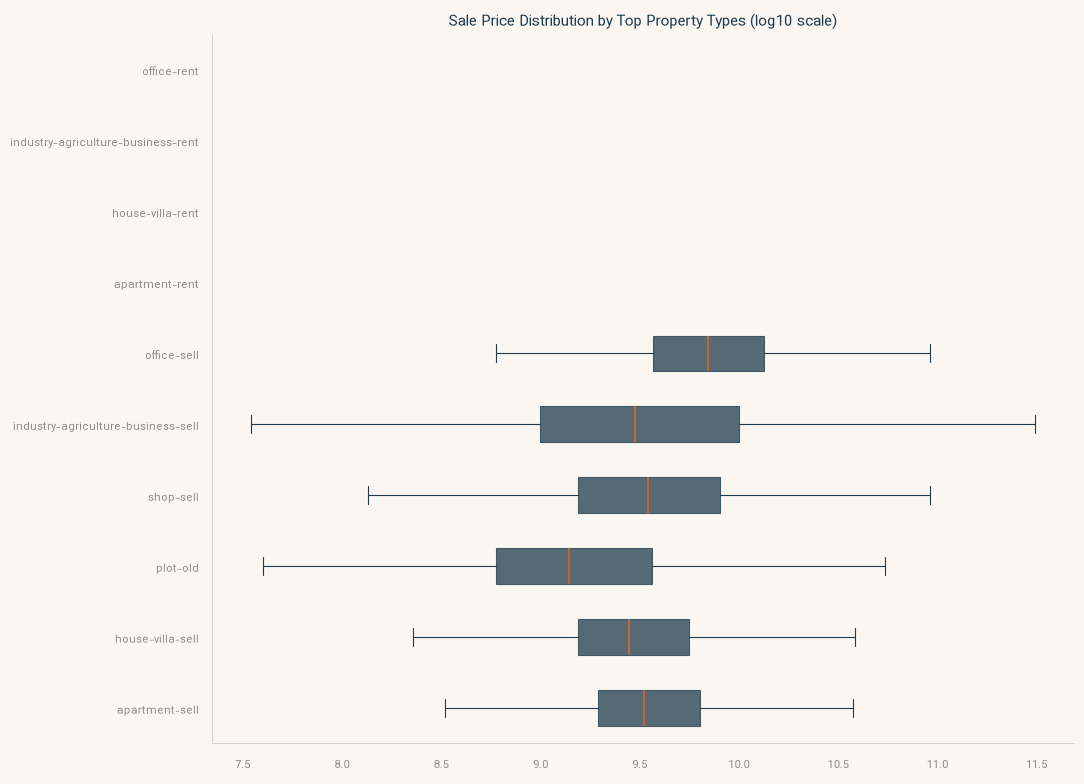

In [363]:
plot_data = df_deduplicated[
    df_deduplicated["sale_price"].notna()
    & (df_deduplicated["sale_price"] > 0)
].copy()
top_types = plot_data["cat3_slug"].value_counts().head(10).index
plot_data = plot_data[plot_data["cat3_slug"].isin(top_types)]
plot_data["log_sale_price"] = np.log10(plot_data["sale_price"])

fig, ax = plt.subplots(figsize=(11, 8))

boxprops = dict(facecolor="#1F3B4D", alpha=0.75, edgecolor="#1F3B4D", linewidth=0.8)
medianprops = dict(color="#C1633B", linewidth=1.5)
whiskerprops = dict(color="#1F3B4D", linewidth=0.8)
capprops = dict(color="#1F3B4D", linewidth=0.8)

grouped_data = [plot_data.loc[plot_data["cat3_slug"] == t, "log_sale_price"] for t in top_types]
ax.boxplot(
    grouped_data,
    tick_labels=list(top_types),
    vert=False,
    showfliers=False,
    patch_artist=True,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
)

ax.set_title("Sale Price Distribution by Top Property Types (log10 scale)", fontsize=11, color="#1F3B4D")

ax.tick_params(axis="both", labelsize=8, colors="#8C8C8C")
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "clean_sale_price_by_property_type.png", dpi=150, bbox_inches="tight")
plt.show()

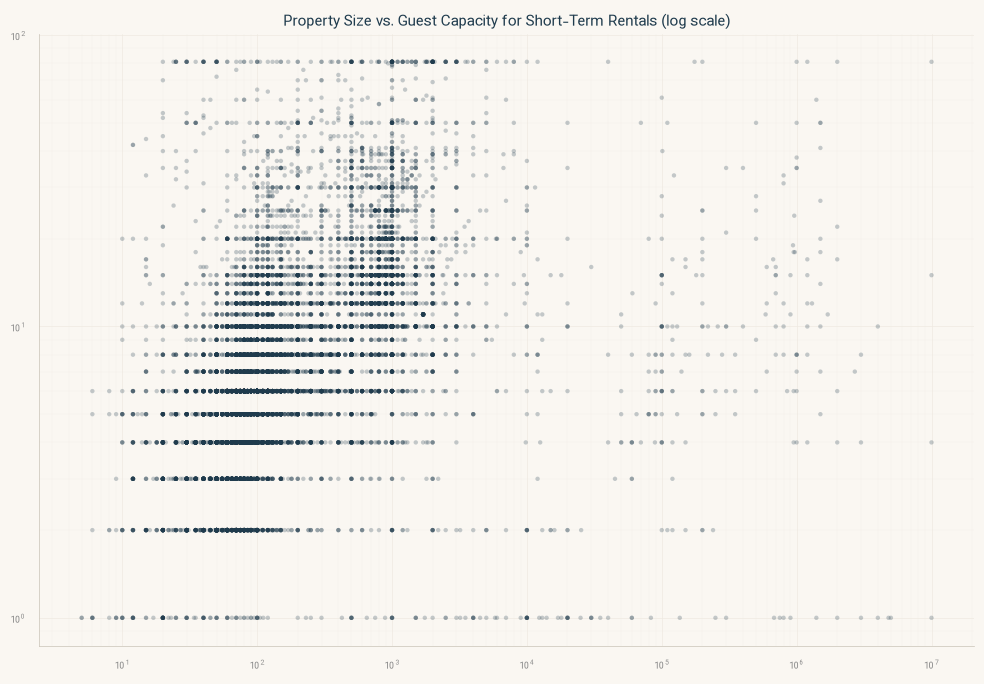

In [364]:
plot_data = df_deduplicated[
    df_deduplicated["building_size_final"].notna()
    & df_deduplicated["total_person_capacity"].notna()
    & (df_deduplicated["building_size_final"] >= 5)
    & (df_deduplicated["total_person_capacity"] > 0)
].copy()
plot_data = plot_data.sample(min(15_000, len(plot_data)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    plot_data["building_size_final"],
    plot_data["total_person_capacity"],
    alpha=0.25,
    s=10,
    color="#1F3B4D",
    edgecolors="none",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Property Size vs. Guest Capacity for Short-Term Rentals (log scale)", fontsize=11, color="#1F3B4D")

ax.tick_params(axis="both", which="both", labelsize=7, colors="#8C8C8C")
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color("#C9C2B6")

ax.grid(True, which="major", color="#EFEAE1", linewidth=0.5)
ax.grid(True, which="minor", color="#EFEAE1", linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_CLEANED_DIR / "clean_building_size_vs_capacity.png", dpi=150, bbox_inches="tight")
plt.show()

In [742]:
df_after_fake = df_deduplicated.copy()

In [743]:
PRICE_COMPARE_COLUMNS = [
    "sale_price",
    "deposit_amount",
    "monthly_rent",
    "daily_rent_regular",
    "daily_rent_special",
    "daily_rent_weekend",
]


rows=[]

for col in PRICE_COMPARE_COLUMNS:

    for name, frame in [
        ("before_cleaning", df_before_fake),
        ("after_cleaning", df_after_fake),
    ]:

        values = frame[col].dropna()

        rows.append({
            "column": col,
            "stage": name,
            "n": len(values),
            "mean": values.mean(),
            "median": values.median(),
            "q25": values.quantile(.25),
            "q75": values.quantile(.75),
            "p95": values.quantile(.95),
            "p99": values.quantile(.99),
        })


price_before_after_summary = pd.DataFrame(rows)

display(price_before_after_summary)

,column,stage,n,mean,median,q25,q75,p95,p99
0,sale_price,before_cleaning,420147,2.095442e+10,2.850000e+09,1.400000e+09,5.900000e+09,2.100000e+10,8.810800e+10
1,sale_price,after_cleaning,404697,1.668423e+10,2.950000e+09,1.500000e+09,6.000000e+09,2.100000e+10,7.000000e+10
2,deposit_amount,before_cleaning,263547,4.804775e+10,2.500000e+08,1.000000e+08,5.000000e+08,1.650000e+09,5.000000e+09
3,deposit_amount,after_cleaning,258384,1.048216e+10,2.500000e+08,1.000000e+08,5.000000e+08,1.600000e+09,5.000000e+09
4,monthly_rent,before_cleaning,226474,5.675485e+10,6.500000e+06,3.000000e+06,1.500000e+07,6.500000e+07,2.500000e+08
5,monthly_rent,after_cleaning,218131,1.753074e+10,7.000000e+06,3.000000e+06,1.500000e+07,6.000000e+07,2.300000e+08
6,daily_rent_regular,before_cleaning,13084,1.362270e+11,8.000000e+05,4.000000e+05,1.800000e+06,3.500000e+06,1.111112e+07
7,daily_rent_regular,after_cleaning,11174,1.176025e+11,1.000000e+06,5.500000e+05,2.000000e+06,3.500000e+06,1.000000e+07
8,daily_rent_special,before_cleaning,7474,3.297193e+10,1.200000e+06,6.000000e+05,2.700000e+06,6.000000e+06,2.000000e+07
9,daily_rent_special,after_cleaning,6353,1.862776e+09,1.500000e+06,8.000000e+05,3.000000e+06,6.000000e+06,1.348000e+07


In [748]:
DATE_COL = "created_at_month"

logger.info(
    "Creating monthly analysis period from '%s'.",
    DATE_COL,
)

df_time_filtered["_analysis_month"] = (
    pd.to_datetime(
        df_time_filtered[DATE_COL],
        errors="coerce",
    )
    .dt.to_period("M")
)

df_deduplicated["_analysis_month"] = (
    pd.to_datetime(
        df_deduplicated[DATE_COL],
        errors="coerce",
    )
    .dt.to_period("M")
)

logger.info(
    "Raw rows with valid analysis month: %d",
    df_time_filtered["_analysis_month"].notna().sum(),
)

logger.info(
    "Deduplicated rows with valid analysis month: %d",
    df_deduplicated["_analysis_month"].notna().sum(),
)

2026-08-14 12:45:17,473 | INFO | Creating monthly analysis period from 'created_at_month'.
2026-08-14 12:45:18,042 | INFO | Raw rows with valid analysis month: 751342
2026-08-14 12:45:18,053 | INFO | Deduplicated rows with valid analysis month: 724990


In [766]:
MONTHLY_MARKET_SUMMARY_PATH = (
    TABLES_CLEANED_DIR /
    "monthly_market_summary.csv"
)


def build_monthly_market_summary(
    df_raw_time_filtered: pd.DataFrame,
    df_deduplicated: pd.DataFrame,
) -> pd.DataFrame:

    logger.info("Building monthly market summary.")

    # -------------------------
    # Raw supply
    # -------------------------
    raw_supply = (
        df_raw_time_filtered
        .groupby("_analysis_month")
        .size()
        .reset_index(name="raw_listing_count")
    )

    # -------------------------
    # Deduplicated supply
    # -------------------------
    dedup_supply = (
        df_deduplicated
        .groupby("_analysis_month")
        .size()
        .reset_index(name="deduplicated_listing_count")
    )

    # -------------------------
    # Sale price statistics
    # -------------------------
    sale_price_df = df_deduplicated[
        df_deduplicated["sale_price_per_sqm"].notna()
    ].copy()

    price_summary = (
        sale_price_df
        .groupby("_analysis_month")["sale_price_per_sqm"]
        .agg(
            sale_price_per_sqm_median="median",
            sale_price_per_sqm_q1=lambda x: x.quantile(0.25),
            sale_price_per_sqm_q3=lambda x: x.quantile(0.75),
            sale_price_sample_count="count",
        )
        .reset_index()
    )

    price_summary["sale_price_per_sqm_iqr"] = (
        price_summary["sale_price_per_sqm_q3"]
        -
        price_summary["sale_price_per_sqm_q1"]
    )

    # -------------------------
    # Merge
    # -------------------------
    summary = (
        raw_supply
        .merge(
            dedup_supply,
            on="_analysis_month",
            how="left",
        )
        .merge(
            price_summary,
            on="_analysis_month",
            how="left",
        )
        .sort_values("_analysis_month")
        .reset_index(drop=True)
    )

    # -------------------------
    # MoM changes
    # -------------------------
    summary["raw_listing_mom_pct"] = (
        summary["raw_listing_count"]
        .pct_change()
        * 100
    )

    summary["deduplicated_listing_mom_pct"] = (
        summary["deduplicated_listing_count"]
        .pct_change()
        * 100
    )

    summary["sale_price_per_sqm_mom_pct"] = (
        summary["sale_price_per_sqm_median"]
        .pct_change()
        * 100
    )

    # -------------------------
    # Price sufficiency
    # -------------------------
    MIN_PRICE_SAMPLE = 100

    summary["price_data_sufficient"] = (
        summary["sale_price_sample_count"]
        >= MIN_PRICE_SAMPLE
    )

    summary["n_months_with_sufficient_price_data"] = (
        summary["price_data_sufficient"]
        .sum()
    )

    logger.info(
        "Monthly market summary generated for %d months.",
        len(summary),
    )

    logger.info(
        "Months with sufficient sale-price data: %d.",
        summary["price_data_sufficient"].sum(),
    )

    return summary



monthly_market_summary = build_monthly_market_summary(
    df_time_filtered,
    df_deduplicated,
)

2026-08-14 13:42:26,698 | INFO | Building monthly market summary.
2026-08-14 13:42:29,639 | INFO | Monthly market summary generated for 6 months.
2026-08-14 13:42:29,640 | INFO | Months with sufficient sale-price data: 6.


In [768]:
monthly_market_summary.to_csv(
    MONTHLY_MARKET_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

logger.info(
    "Saved monthly market summary: %s",
    MONTHLY_MARKET_SUMMARY_PATH,
)

2026-08-14 13:43:29,206 | INFO | Saved monthly market summary: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\monthly_market_summary.csv


In [771]:
monthly_market_summary

,_analysis_month,raw_listing_count,deduplicated_listing_count,sale_price_per_sqm_median,sale_price_per_sqm_q1,sale_price_per_sqm_q3,sale_price_sample_count,sale_price_per_sqm_iqr,raw_listing_mom_pct,deduplicated_listing_mom_pct,sale_price_per_sqm_mom_pct,price_data_sufficient,n_months_with_sufficient_price_data
0,2024-07,133219,129006,2.562500e+07,1.000000e+07,4.786172e+07,68290,3.786172e+07,NaN,NaN,NaN,True,6
1,2024-08,132396,128204,2.570000e+07,1.022601e+07,4.750000e+07,66820,3.727399e+07,-0.617780,-0.621677,0.292683,True,6
2,2024-09,121432,117087,2.631579e+07,1.087500e+07,4.902593e+07,61527,3.815093e+07,-8.281217,-8.671336,2.396068,True,6
3,2024-10,126387,121841,2.720530e+07,1.185612e+07,5.000000e+07,68816,3.814388e+07,4.080473,4.060229,3.380153,True,6
4,2024-11,121456,116981,2.812500e+07,1.239658e+07,5.142857e+07,70471,3.903199e+07,-3.901509,-3.988805,3.380578,True,6
5,2024-12,116452,111871,2.923077e+07,1.333333e+07,5.384615e+07,68747,4.051282e+07,-4.120011,-4.368231,3.931624,True,6


In [773]:
logger.info(
    "Monthly market summary shape: %s",
    monthly_market_summary.shape,
)

2026-08-14 13:44:20,539 | INFO | Monthly market summary shape: (6, 13)


2026-08-14 13:57:51,219 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 13:57:51,222 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 13:57:51,225 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 13:57:51,226 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


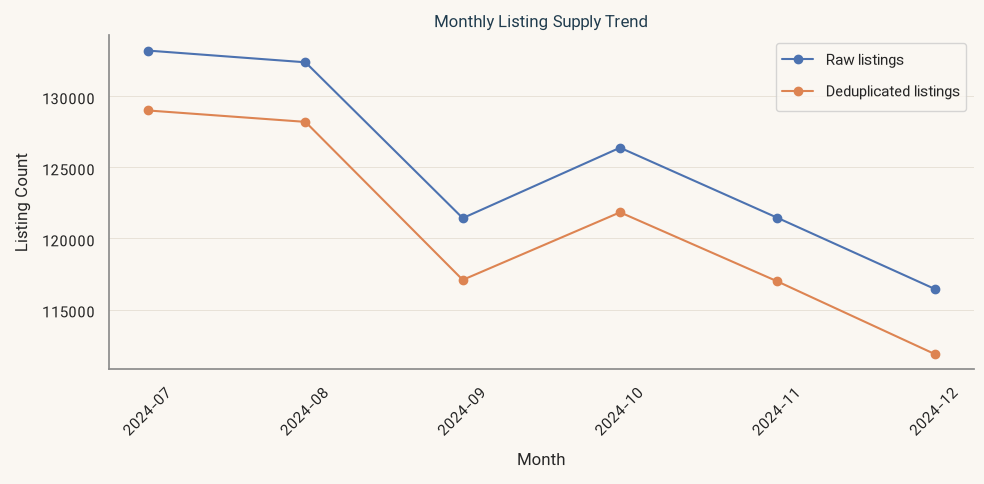

2026-08-14 13:57:51,500 | INFO | Saved monthly supply trend plot: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\monthly_supply_trend.png


In [791]:
SUPPLY_TREND_PATH = (
    FIGURES_CLEANED_DIR /
    "monthly_supply_trend.png"
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)

plot_month = monthly_market_summary["_analysis_month"].astype(str)

ax.plot(
    plot_month,
    monthly_market_summary["raw_listing_count"],
    marker="o",
    label="Raw listings",
)

ax.plot(
    plot_month,
    monthly_market_summary["deduplicated_listing_count"],
    marker="o",
    label="Deduplicated listings",
)

ax.set_title(
    "Monthly Listing Supply Trend",
    color="#1F3B4D",
)

ax.set_xlabel("Month")
ax.set_ylabel("Listing Count")

ax.tick_params(axis="x", rotation=45)

ax.legend()

plt.tight_layout()

plt.show()

plt.savefig(
    SUPPLY_TREND_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.close()

logger.info(
    "Saved monthly supply trend plot: %s",
    SUPPLY_TREND_PATH,
)

2026-08-14 13:57:08,096 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 13:57:08,098 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


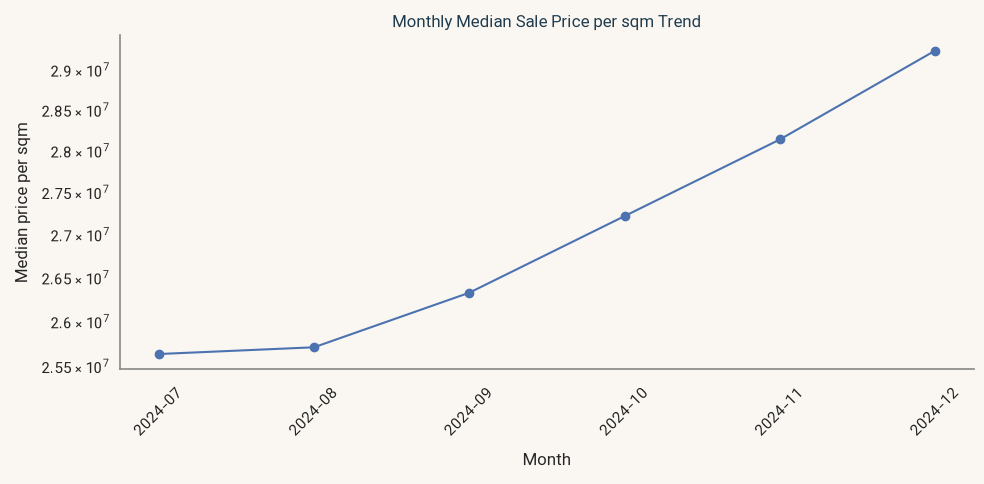

2026-08-14 13:57:08,566 | INFO | Saved monthly price trend plot: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\monthly_price_per_sqm_trend.png


In [789]:
PRICE_TREND_PATH = (
    FIGURES_CLEANED_DIR /
    "monthly_price_per_sqm_trend.png"
)

price_plot_df = monthly_market_summary[
    monthly_market_summary["price_data_sufficient"]
].copy()

fig, ax = plt.subplots(
    figsize=(10,5)
)

plot_month = price_plot_df["_analysis_month"].astype(str)

ax.plot(
    plot_month,
    price_plot_df["sale_price_per_sqm_median"],
    marker="o",
)

ax.set_yscale("log")

ax.set_title(
    "Monthly Median Sale Price per sqm Trend",
    color="#1F3B4D",
)

ax.set_xlabel("Month")
ax.set_ylabel("Median price per sqm")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

plt.savefig(
    PRICE_TREND_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.close()


logger.info(
    "Saved monthly price trend plot: %s",
    PRICE_TREND_PATH,
)

2026-08-14 13:55:47,422 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 13:55:47,424 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 13:55:47,426 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 13:55:47,428 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


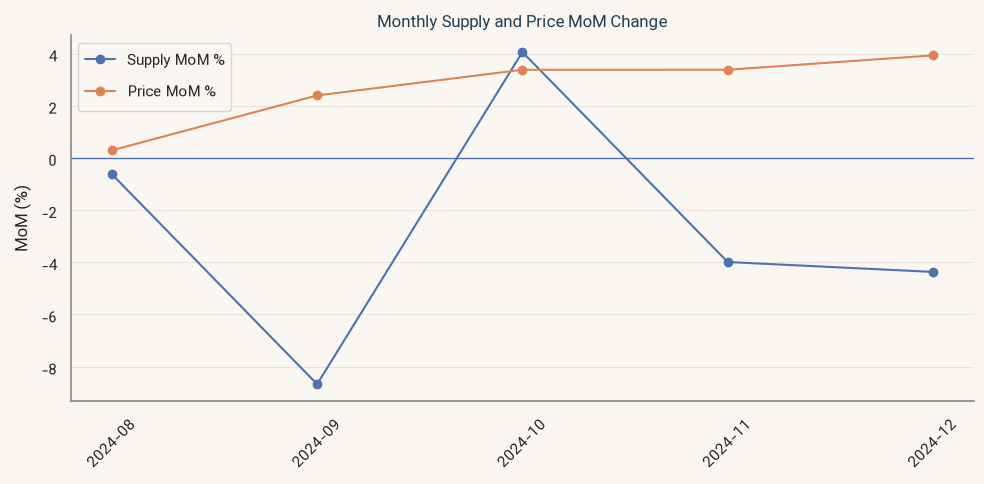

2026-08-14 13:55:47,877 | INFO | Saved monthly MoM trend plot: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\monthly_market_mom_change.png


In [787]:
MOM_TREND_PATH = (
    FIGURES_CLEANED_DIR /
    "monthly_market_mom_change.png"
)


plot_month = monthly_market_summary["_analysis_month"].astype(str)

fig, ax = plt.subplots(
    figsize=(10,5)
)

ax.plot(
    plot_month,
    monthly_market_summary["deduplicated_listing_mom_pct"],
    marker="o",
    label="Supply MoM %",
)

ax.plot(
    plot_month,
    monthly_market_summary["sale_price_per_sqm_mom_pct"],
    marker="o",
    label="Price MoM %",
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Monthly Supply and Price MoM Change",
    color="#1F3B4D",
)

ax.set_ylabel("MoM (%)")

ax.tick_params(axis="x", rotation=45)

ax.legend()

plt.tight_layout()

plt.show()

plt.savefig(
    MOM_TREND_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.close()


logger.info(
    "Saved monthly MoM trend plot: %s",
    MOM_TREND_PATH,
)

In [793]:
CITY_MONTH_MIN_LISTINGS = 200


logger.info(
    "Building city-month market summary."
)


city_monthly_summary = (
    df_deduplicated
    .groupby(
        [
            "_analysis_month",
            "city_slug",
        ]
    )
    .agg(
        deduplicated_listing_count=(
            "city_slug",
            "size"
        ),
        sale_price_sample_count=(
            "sale_price_per_sqm",
            "count"
        ),
        sale_price_per_sqm_median=(
            "sale_price_per_sqm",
            "median"
        ),
        sale_price_per_sqm_q1=(
            "sale_price_per_sqm",
            lambda x: x.quantile(0.25)
        ),
        sale_price_per_sqm_q3=(
            "sale_price_per_sqm",
            lambda x: x.quantile(0.75)
        ),
    )
    .reset_index()
)


city_monthly_summary["sale_price_per_sqm_iqr"] = (
    city_monthly_summary["sale_price_per_sqm_q3"]
    -
    city_monthly_summary["sale_price_per_sqm_q1"]
)


logger.info(
    "City-month summary generated: %d rows.",
    len(city_monthly_summary),
)

2026-08-14 13:58:56,169 | INFO | Building city-month market summary.
C:\Users\asus\AppData\Local\Temp\ipykernel_21824\1439409896.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(
2026-08-14 13:58:58,221 | INFO | City-month summary generated: 2526 rows.


In [795]:
city_total_volume = (
    city_monthly_summary
    .groupby("city_slug")
    ["deduplicated_listing_count"]
    .sum()
    .sort_values(
        ascending=False
    )
)


TOP_CITY_COUNT = 10


top_cities = (
    city_total_volume
    .head(TOP_CITY_COUNT)
    .index
    .tolist()
)


logger.info(
    "Selected top cities: %s",
    top_cities,
)

C:\Users\asus\AppData\Local\Temp\ipykernel_21824\2362220473.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("city_slug")
2026-08-14 13:59:13,555 | INFO | Selected top cities: ['tehran', 'mashhad', 'karaj', 'shiraz', 'isfahan', 'tabriz', 'andisheh-new-town', 'ahvaz', 'qom', 'rasht']


2026-08-14 14:02:12,480 | INFO | Plotting 10 cities.
2026-08-14 14:02:12,491 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:02:12,496 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:02:12,499 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:02:12,500 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:02:12,501 | INFO | Using categorical unit

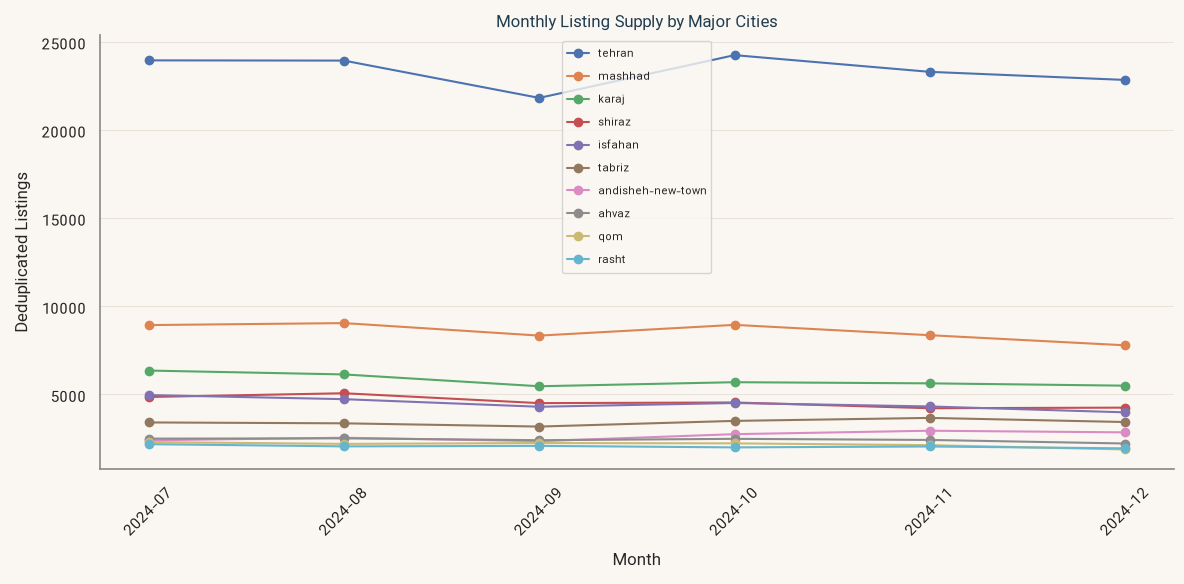

In [799]:
city_supply_plot_df = (
    city_monthly_summary
    [
        city_monthly_summary["city_slug"]
        .isin(top_cities)
    ]
    .copy()
)


logger.info(
    "Plotting %d cities.",
    city_supply_plot_df["city_slug"].nunique()
)


city_supply_plot_df["_analysis_month_str"] = (
    city_supply_plot_df["_analysis_month"]
    .astype(str)
)


fig, ax = plt.subplots(
    figsize=(12,6)
)


for city_name in top_cities:

    group = city_supply_plot_df[
        city_supply_plot_df["city_slug"] == city_name
    ].sort_values(
        "_analysis_month"
    )

    ax.plot(
        group["_analysis_month_str"],
        group["deduplicated_listing_count"],
        marker="o",
        label=city_name,
    )


ax.set_title(
    "Monthly Listing Supply by Major Cities",
    color="#1F3B4D",
)

ax.set_xlabel("Month")
ax.set_ylabel("Deduplicated Listings")

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.legend(
    fontsize=8
)

plt.tight_layout()

plt.show()

In [801]:
city_price_plot_df = (
    city_monthly_summary[
        city_monthly_summary["city_slug"]
        .isin(top_cities)
        &
        city_monthly_summary["sale_price_sample_count"]
        .ge(100)
    ]
    .copy()
)


logger.info(
    "Cities available for price trend: %d",
    city_price_plot_df["city_slug"].nunique(),
)


logger.info(
    "Price trend rows: %d",
    len(city_price_plot_df),
)

2026-08-14 14:06:50,922 | INFO | Cities available for price trend: 10
2026-08-14 14:06:50,922 | INFO | Price trend rows: 60


2026-08-14 14:12:23,592 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:12:23,594 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:12:23,597 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:12:23,598 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:12:23,600 | INFO | Using categorical units to plot a list of strings that are all parsable as 

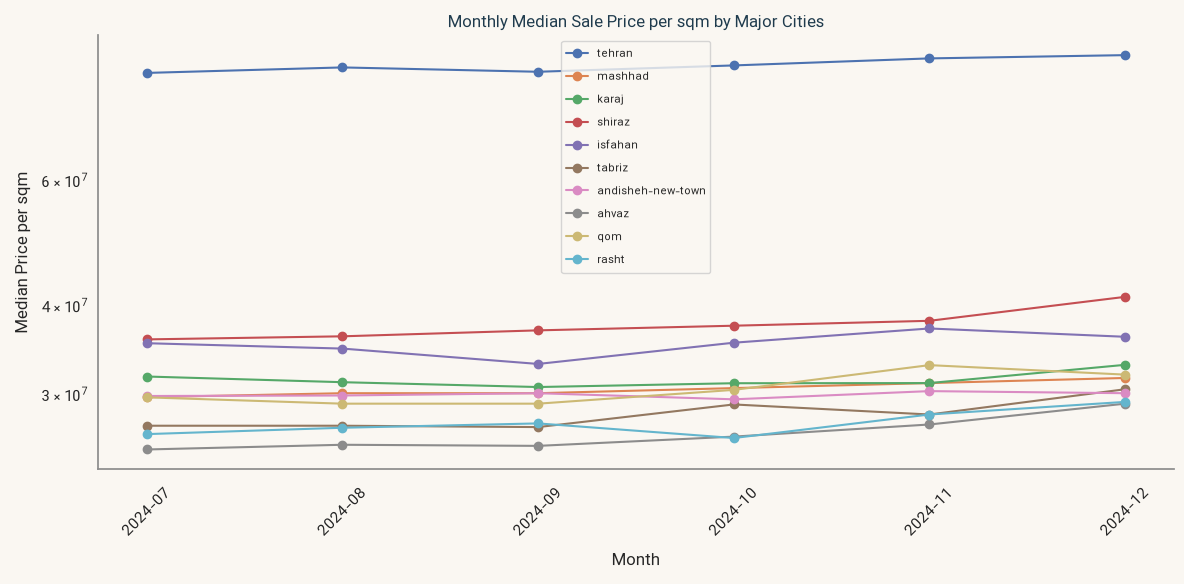

2026-08-14 14:12:24,765 | INFO | Saved city price trend: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\city_monthly_price_trend.png


In [805]:
CITY_PRICE_TREND_PATH = (
    FIGURES_CLEANED_DIR /
    "city_monthly_price_trend.png"
)


city_price_plot_df["_analysis_month_str"] = (
    city_price_plot_df["_analysis_month"]
    .astype(str)
)


fig, ax = plt.subplots(
    figsize=(12,6)
)


for city_name in top_cities:

    group = (
        city_price_plot_df[
            city_price_plot_df["city_slug"] == city_name
        ]
        .sort_values("_analysis_month")
    )

    if len(group) == 0:
        continue

    ax.plot(
        group["_analysis_month_str"],
        group["sale_price_per_sqm_median"],
        marker="o",
        label=city_name,
    )


ax.set_title(
    "Monthly Median Sale Price per sqm by Major Cities",
    color="#1F3B4D",
)


ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Median Price per sqm"
)

ax.set_yscale(
    "log"
)


ax.tick_params(
    axis="x",
    rotation=45,
)


ax.legend(
    fontsize=8
)


plt.tight_layout()


plt.savefig(
    CITY_PRICE_TREND_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()

plt.close()


logger.info(
    "Saved city price trend: %s",
    CITY_PRICE_TREND_PATH,
)

In [807]:
city_price_trend_df = city_monthly_summary[
    city_monthly_summary["city_slug"].isin(top_cities)
    & (city_monthly_summary["sale_price_sample_count"] >= 100)
].copy()

city_price_trend_df["_analysis_month_str"] = city_price_trend_df["_analysis_month"].astype(str)

logger.info(
    "Cities in price trend: %d",
    city_price_trend_df["city_slug"].nunique()
)

2026-08-14 14:14:03,251 | INFO | Cities in price trend: 10


2026-08-14 14:14:27,529 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:14:27,531 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:14:27,533 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:14:27,535 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:14:27,537 | INFO | Using categorical units to plot a list of strings that are all parsable as 

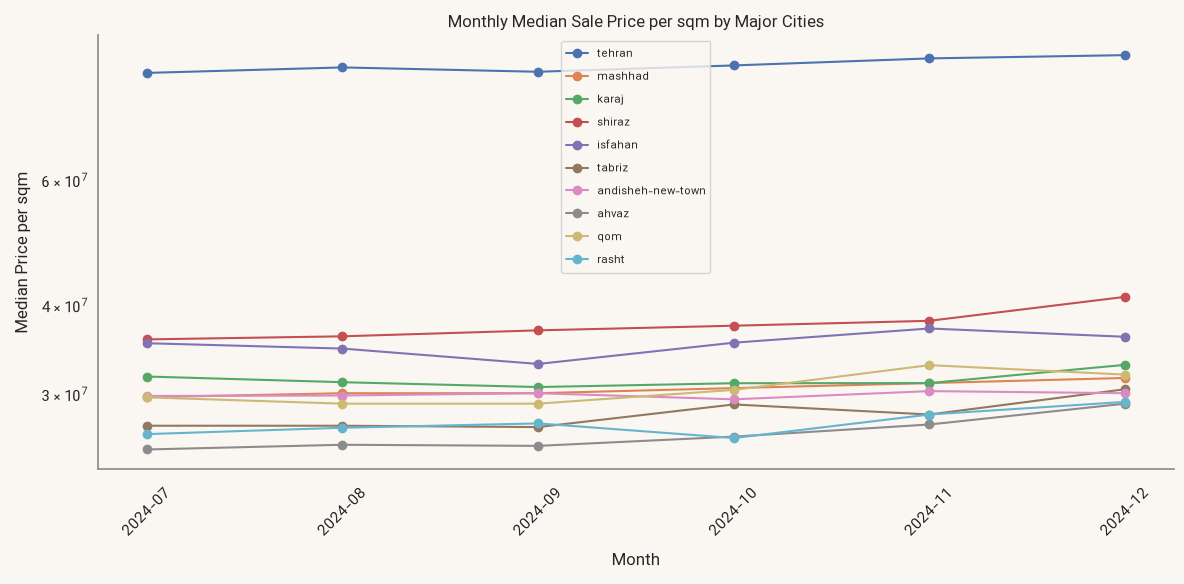

2026-08-14 14:14:29,048 | INFO | Saved city price trend: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\city_monthly_price_trend.png


In [809]:
CITY_PRICE_TREND_PATH = FIGURES_CLEANED_DIR / "city_monthly_price_trend.png"

fig, ax = plt.subplots(figsize=(12,6))

for city in top_cities:
    temp = city_price_trend_df[
        city_price_trend_df["city_slug"] == city
    ].sort_values("_analysis_month")

    if len(temp):
        ax.plot(
            temp["_analysis_month_str"],
            temp["sale_price_per_sqm_median"],
            marker="o",
            label=city
        )

ax.set_yscale("log")
ax.set_title("Monthly Median Sale Price per sqm by Major Cities")
ax.set_xlabel("Month")
ax.set_ylabel("Median Price per sqm")
ax.tick_params(axis="x",rotation=45)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(CITY_PRICE_TREND_PATH,dpi=300,bbox_inches="tight")
plt.show()
plt.close()

logger.info("Saved city price trend: %s",CITY_PRICE_TREND_PATH)

In [813]:
MIN_NEIGHBORHOOD_LISTINGS = 100

neighborhood_monthly_summary = (
    df_time_filtered
    .query("price_regime == 'sale'")
    .groupby(
        ["_analysis_month","city_slug","neighborhood_slug"],
        observed=True
    )
    .agg(
        listing_count=("sale_price_per_sqm","size"),
        sale_price_per_sqm_median=("sale_price_per_sqm","median"),
        sale_price_per_sqm_q1=("sale_price_per_sqm",lambda x:x.quantile(.25)),
        sale_price_per_sqm_q3=("sale_price_per_sqm",lambda x:x.quantile(.75))
    )
    .reset_index()
)

neighborhood_monthly_summary["sale_price_per_sqm_iqr"] = (
    neighborhood_monthly_summary["sale_price_per_sqm_q3"]
    -
    neighborhood_monthly_summary["sale_price_per_sqm_q1"]
)

logger.info(
    "Neighborhood monthly summary rows: %d",
    len(neighborhood_monthly_summary)
)

2026-08-14 14:18:59,396 | INFO | Neighborhood monthly summary rows: 6432


In [815]:
valid_neighborhoods = (
    neighborhood_monthly_summary
    .groupby(
        ["city_slug","neighborhood_slug"],
        observed=True
    )["listing_count"]
    .sum()
)

valid_neighborhoods = valid_neighborhoods[
    valid_neighborhoods >= MIN_NEIGHBORHOOD_LISTINGS
].index


neighborhood_monthly_summary = (
    neighborhood_monthly_summary.set_index(
        ["city_slug","neighborhood_slug"]
    )
    .loc[valid_neighborhoods]
    .reset_index()
)

logger.info(
    "Valid neighborhoods: %d",
    neighborhood_monthly_summary["neighborhood_slug"].nunique()
)

2026-08-14 14:19:25,975 | INFO | Valid neighborhoods: 430


In [817]:
top_neighborhoods = (
    neighborhood_monthly_summary
    .groupby(
        ["city_slug","neighborhood_slug"],
        observed=True
    )["listing_count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

2026-08-14 14:20:09,773 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:20:09,775 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:20:09,777 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:20:09,777 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:20:09,780 | INFO | Using categorical units to plot a list of strings that are all parsable as 

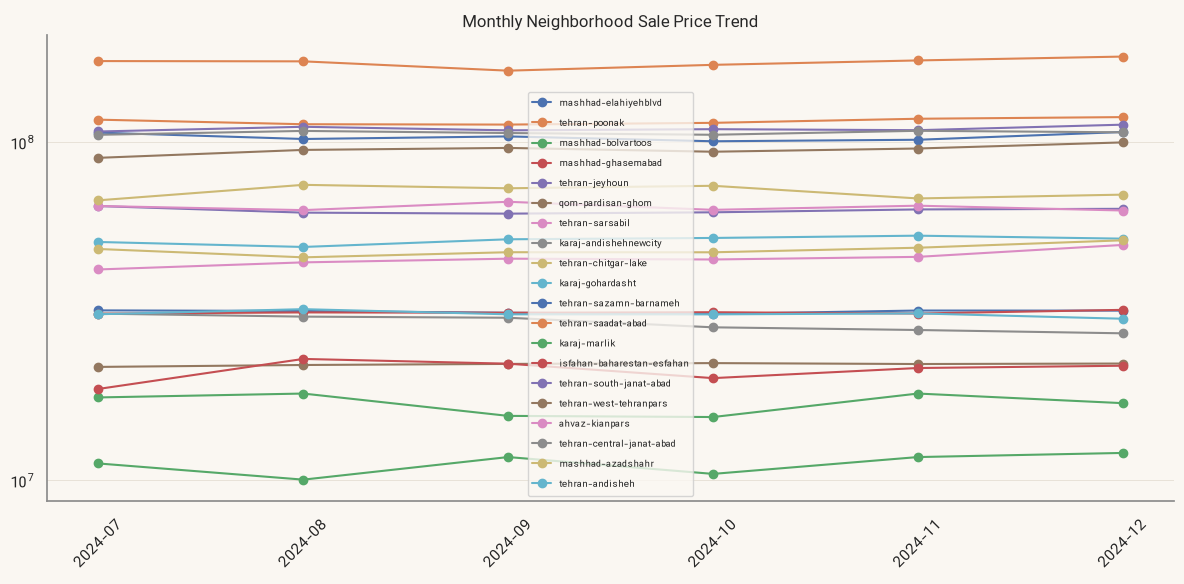

In [819]:
plot_df = (
    neighborhood_monthly_summary
    .set_index(["city_slug","neighborhood_slug"])
    .loc[top_neighborhoods]
    .reset_index()
)

plot_df["_analysis_month_str"] = plot_df["_analysis_month"].astype(str)

fig, ax = plt.subplots(figsize=(12,6))

for city, neighborhood in top_neighborhoods:
    temp = plot_df[
        (plot_df["city_slug"]==city)
        &
        (plot_df["neighborhood_slug"]==neighborhood)
    ].sort_values("_analysis_month")

    ax.plot(
        temp["_analysis_month_str"],
        temp["sale_price_per_sqm_median"],
        marker="o",
        label=f"{city}-{neighborhood}"
    )

ax.set_yscale("log")
ax.set_title("Monthly Neighborhood Sale Price Trend")
ax.tick_params(axis="x",rotation=45)
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [821]:
logger.info("Building property-type monthly summary.")

property_type_monthly_summary = (
    df_time_filtered
    .query("price_regime == 'sale'")
    .groupby(
        ["_analysis_month","cat3_slug"],
        observed=True
    )
    .agg(
        listing_count=("sale_price_per_sqm","size"),
        sale_price_per_sqm_median=("sale_price_per_sqm","median"),
        sale_price_per_sqm_q1=("sale_price_per_sqm",lambda x:x.quantile(.25)),
        sale_price_per_sqm_q3=("sale_price_per_sqm",lambda x:x.quantile(.75))
    )
    .reset_index()
)

property_type_monthly_summary["sale_price_per_sqm_iqr"] = (
    property_type_monthly_summary["sale_price_per_sqm_q3"]
    -
    property_type_monthly_summary["sale_price_per_sqm_q1"]
)

property_type_monthly_summary = (
    property_type_monthly_summary
    .sort_values("_analysis_month")
)

logger.info(
    "Property type monthly summary rows: %d",
    len(property_type_monthly_summary)
)

2026-08-14 14:24:28,286 | INFO | Building property-type monthly summary.
2026-08-14 14:24:29,148 | INFO | Property type monthly summary rows: 36


In [823]:
MIN_PROPERTY_TYPE_LISTINGS = 100

valid_property_types = (
    property_type_monthly_summary
    .groupby("cat3_slug")["listing_count"]
    .sum()
)

valid_property_types = valid_property_types[
    valid_property_types >= MIN_PROPERTY_TYPE_LISTINGS
].index

property_type_monthly_summary = (
    property_type_monthly_summary[
        property_type_monthly_summary["cat3_slug"]
        .isin(valid_property_types)
    ]
)

logger.info(
    "Valid property types: %d",
    property_type_monthly_summary["cat3_slug"].nunique()
)

2026-08-14 14:24:42,292 | INFO | Valid property types: 6


2026-08-14 14:24:55,600 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:24:55,602 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:24:55,604 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:24:55,606 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-14 14:24:55,608 | INFO | Using categorical units to plot a list of strings that are all parsable as 

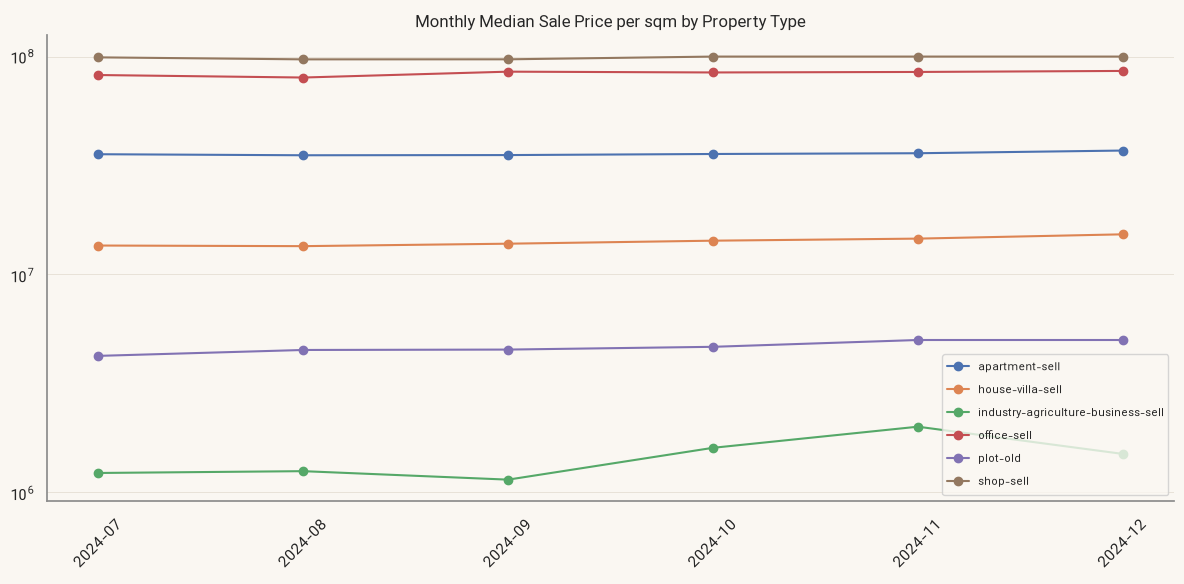

2026-08-14 14:24:56,752 | INFO | Saved property type price trend: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\property_type_price_trend.png


In [825]:
PROPERTY_TYPE_PRICE_PATH = FIGURES_CLEANED_DIR / "property_type_price_trend.png"

fig, ax = plt.subplots(figsize=(12,6))

for ptype in property_type_monthly_summary["cat3_slug"].unique():
    temp = property_type_monthly_summary[
        property_type_monthly_summary["cat3_slug"] == ptype
    ]

    ax.plot(
        temp["_analysis_month"].astype(str),
        temp["sale_price_per_sqm_median"],
        marker="o",
        label=ptype
    )

ax.set_yscale("log")
ax.set_title("Monthly Median Sale Price per sqm by Property Type")
ax.tick_params(axis="x",rotation=45)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROPERTY_TYPE_PRICE_PATH,dpi=300,bbox_inches="tight")
plt.show()
plt.close()

logger.info(
    "Saved property type price trend: %s",
    PROPERTY_TYPE_PRICE_PATH
)

In [365]:

cleaned_path = PROCESSED_DATA_DIR / "divar_real_estate_cleaned.csv"

df_deduplicated.to_csv(
    cleaned_path,
    index=False
)

logger.info("Saved cleaned dataset to: %s", cleaned_path)


2026-08-14 00:24:50,283 | INFO | Saved cleaned dataset to: C:\Users\asus\Downloads\iran_housing_market_intelligence\data\processed\divar_real_estate_cleaned.csv


In [366]:
logger.info(
    "Final dataset shape: rows=%s, columns=%s",
    df_deduplicated.shape[0],
    df_deduplicated.shape[1],
)

logger.info(
    "Final dataset file size: %.2f MB",
    cleaned_path.stat().st_size / (1024 ** 2),
)

2026-08-14 00:24:50,313 | INFO | Final dataset shape: rows=724990, columns=281
2026-08-14 00:24:50,317 | INFO | Final dataset file size: 1461.26 MB


In [367]:
print(cleaned_path.resolve())
print(cleaned_path.exists())

C:\Users\asus\Downloads\iran_housing_market_intelligence\data\processed\divar_real_estate_cleaned.csv
True
